In [1]:
import sys

print("Python do notebook:")
print(sys.executable)

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm

print("\nReportLab OK")

Python do notebook:
C:\Users\beelt\Documents\collections_case_candidate\.venv\Scripts\python.exe

ReportLab OK


In [2]:
from pathlib import Path
import json
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image,
)

warnings.filterwarnings("ignore")

In [3]:
ROOT = Path.cwd()

CANDIDATES = [
    ROOT / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT.parent / "05_bivariate_eda_collections_macro_analysis.ipynb",
    ROOT / "notebooks" / "05_bivariate_eda_collections_macro_analysis.ipynb",
]

BIVARIATE_NOTEBOOK = next((p for p in CANDIDATES if p.exists()), None)

if BIVARIATE_NOTEBOOK is None:
    raise FileNotFoundError(
        "Não encontrei 05_bivariate_eda_collections_macro_analysis.ipynb. "
        "Ajuste BIVARIATE_NOTEBOOK nesta célula."
    )

REPORT_DIR = ROOT / "reports"
CHART_DIR = REPORT_DIR / "collections_report_charts"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH = REPORT_DIR / "collections_macro_bivariate_analysis_report.pdf"

print("Notebook fonte :", BIVARIATE_NOTEBOOK.resolve())
print("PDF de saída   :", PDF_PATH.resolve())

Notebook fonte : C:\Users\beelt\Documents\collections_case_candidate\notebooks\05_bivariate_eda_collections_macro_analysis.ipynb
PDF de saída   : C:\Users\beelt\Documents\collections_case_candidate\notebooks\reports\collections_macro_bivariate_analysis_report.pdf


In [4]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("../data")
QUEUE_PATH = DATA_DIR / "raw" / "collections_queue_sep2026.csv"
WA_PATH = DATA_DIR / "raw" / "whatsapp_collections_history.csv"

if not QUEUE_PATH.exists():
    QUEUE_PATH = Path("/mnt/data/collections_queue_sep2026(1).csv")
if not WA_PATH.exists():
    WA_PATH = Path("/mnt/data/whatsapp_collections_history(2).csv")

queue = pd.read_csv(QUEUE_PATH)
wa = pd.read_csv(WA_PATH)

wa["sent_at"] = pd.to_datetime(wa["sent_at"], errors="coerce")
queue["in_collections_since"] = pd.to_datetime(queue["in_collections_since"], errors="coerce")

print("Queue:", queue.shape)
print("WhatsApp:", wa.shape)

Queue: (10658, 10)
WhatsApp: (75406, 17)


In [5]:
##_______________________________________________________________ "" ____________________________________________________________

SEPTEMBER QUEUE
Rows              : 10,658
Unique customers  : 10,658
Outstanding       : R$ 8,886,007.98

PRE-EXISTING vs NEW SEPTEMBER ENTRANTS
          entry_cohort  customers outstanding_brl avg_balance median_balance min_entry_date max_entry_date customer_share_pct balance_share_pct
New entrant during Sep       5000 R$ 4,284,358.42   R$ 856.87      R$ 747.92     2026-09-01     2026-09-30              46.9%             48.2%
 Pre-existing on Sep 1       5658 R$ 4,601,649.56   R$ 813.30      R$ 708.04     2026-07-04     2026-08-31              53.1%             51.8%

DPD DISTRIBUTION — SEPTEMBER 1
      dpd_bucket_sep01  customers outstanding_brl avg_balance customer_share_pct balance_share_pct
0 — Future Sep entrant   5,000.00 R$ 4,284,358.42   R$ 856.87              46.9%             48.2%
                 01–15   1,559.00 R$ 1,280,571.56   R$ 821.41              14.6%             14.4%
                 16–30   1,432.00 R$ 1,192,227.01   R$ 832.56              13.4%             

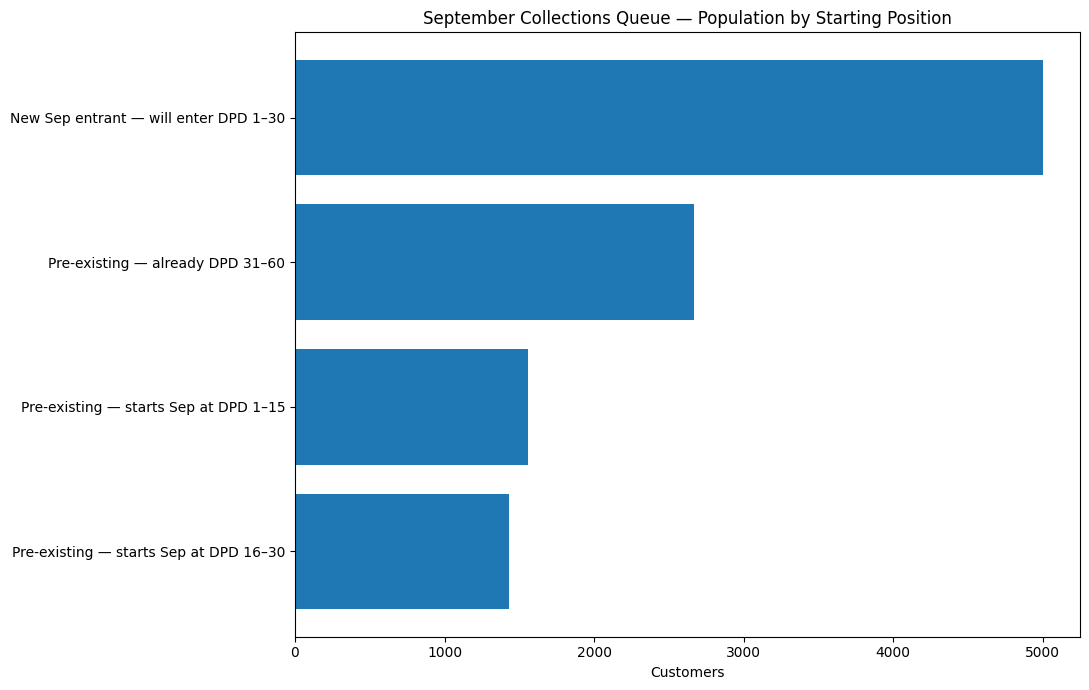

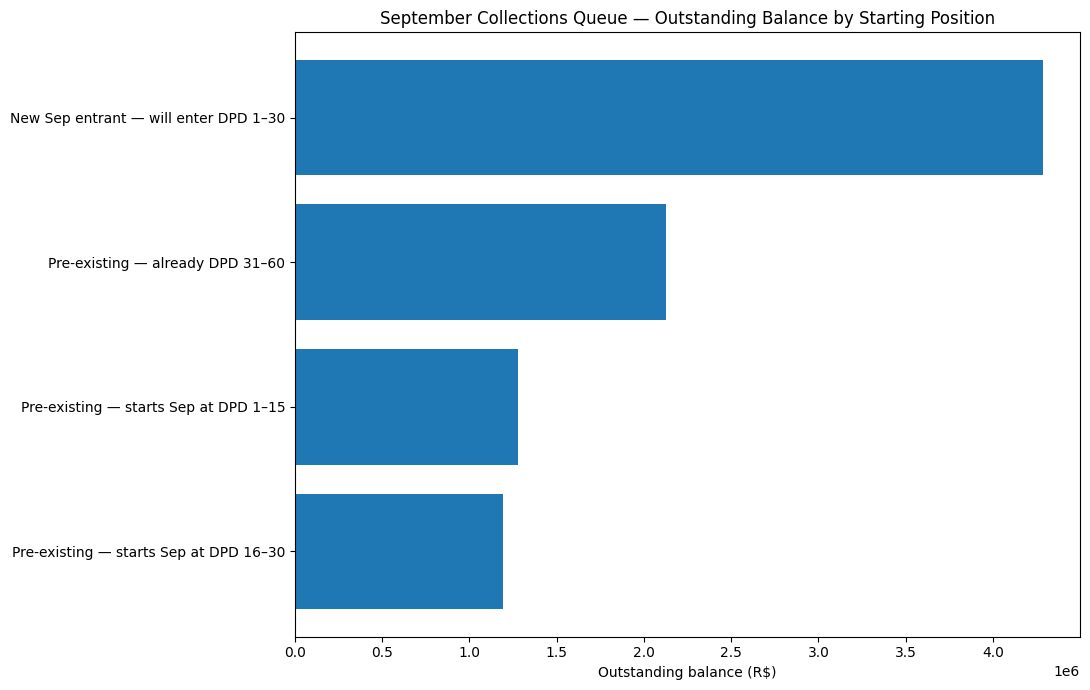

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SEPTEMBER QUEUE — TEMPORAL / DPD MAP
# ============================================================

q = queue.copy()

q["in_collections_since"] = pd.to_datetime(
    q["in_collections_since"]
)

SEP01 = pd.Timestamp("2026-09-01")
SEP30 = pd.Timestamp("2026-09-30")


# ============================================================
# 1. BASIC VALIDATION
# ============================================================

print("=" * 100)
print("SEPTEMBER QUEUE")
print("=" * 100)

print(f"Rows              : {len(q):,}")
print(f"Unique customers  : {q['customer_id'].nunique():,}")
print(
    f"Outstanding       : "
    f"R$ {q['outstanding_balance_brl'].sum():,.2f}"
)


# ============================================================
# 2. COHORT — PRE-EXISTING vs SEPTEMBER ENTRANTS
# ============================================================

q["entry_cohort"] = np.where(
    q["in_collections_since"] < SEP01,
    "Pre-existing on Sep 1",
    "New entrant during Sep"
)


cohort_summary = (
    q
    .groupby("entry_cohort", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_balance=("outstanding_balance_brl", "mean"),
        median_balance=("outstanding_balance_brl", "median"),
        min_entry_date=("in_collections_since", "min"),
        max_entry_date=("in_collections_since", "max")
    )
)


cohort_summary["customer_share_pct"] = (
    100
    * cohort_summary["customers"]
    / q["customer_id"].nunique()
)


cohort_summary["balance_share_pct"] = (
    100
    * cohort_summary["outstanding_brl"]
    / q["outstanding_balance_brl"].sum()
)


print()
print("=" * 100)
print("PRE-EXISTING vs NEW SEPTEMBER ENTRANTS")
print("=" * 100)

print(
    cohort_summary.to_string(
        index=False,
        formatters={
            "outstanding_brl":
                lambda x: f"R$ {x:,.2f}",
            "avg_balance":
                lambda x: f"R$ {x:,.2f}",
            "median_balance":
                lambda x: f"R$ {x:,.2f}",
            "customer_share_pct":
                lambda x: f"{x:.1f}%",
            "balance_share_pct":
                lambda x: f"{x:.1f}%"
        }
    )
)


# ============================================================
# 3. DPD AT START AND END OF SEPTEMBER
# ============================================================

q["dpd_sep01"] = (
    q["days_past_due_on_2026-09-01"]
    .astype(int)
)


# For customers already in collections on Sep 1:
# Sep30 = Sep1 DPD + 29
#
# For future September entrants:
# DPD grows from 0 at entry date.

q["dpd_sep30"] = np.where(
    q["in_collections_since"] < SEP01,

    q["dpd_sep01"] + 29,

    (SEP30 - q["in_collections_since"]).dt.days
)


q["dpd_sep30"] = (
    q["dpd_sep30"]
    .clip(lower=0)
    .astype(int)
)


# ============================================================
# 4. DPD BUCKET ON SEP 1
# ============================================================

def dpd_bucket(x):

    if x == 0:
        return "0 — Future Sep entrant"

    elif x <= 15:
        return "01–15"

    elif x <= 30:
        return "16–30"

    elif x <= 45:
        return "31–45"

    elif x <= 60:
        return "46–60"

    else:
        return "60+"


q["dpd_bucket_sep01"] = (
    q["dpd_sep01"]
    .apply(dpd_bucket)
)


bucket_order = [
    "0 — Future Sep entrant",
    "01–15",
    "16–30",
    "31–45",
    "46–60",
    "60+"
]


dpd_sep01_summary = (
    q
    .groupby(
        "dpd_bucket_sep01",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_balance=("outstanding_balance_brl", "mean")
    )
    .reindex(bucket_order)
    .fillna(0)
    .reset_index()
)


dpd_sep01_summary["customer_share_pct"] = (
    100
    * dpd_sep01_summary["customers"]
    / len(q)
)


dpd_sep01_summary["balance_share_pct"] = (
    100
    * dpd_sep01_summary["outstanding_brl"]
    / q["outstanding_balance_brl"].sum()
)


print()
print("=" * 110)
print("DPD DISTRIBUTION — SEPTEMBER 1")
print("=" * 110)

print(
    dpd_sep01_summary.to_string(
        index=False,
        formatters={
            "outstanding_brl":
                lambda x: f"R$ {x:,.2f}",
            "avg_balance":
                lambda x: f"R$ {x:,.2f}",
            "customer_share_pct":
                lambda x: f"{x:.1f}%",
            "balance_share_pct":
                lambda x: f"{x:.1f}%"
        }
    )
)


# ============================================================
# 5. WHERE DID PRE-EXISTING CUSTOMERS COME FROM?
# ============================================================

pre = q[
    q["in_collections_since"] < SEP01
].copy()


pre["entry_month"] = (
    pre["in_collections_since"]
    .dt.to_period("M")
    .astype(str)
)


origin_summary = (
    pre
    .groupby("entry_month", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_dpd_sep01=("dpd_sep01", "mean"),
        median_dpd_sep01=("dpd_sep01", "median"),
        min_dpd_sep01=("dpd_sep01", "min"),
        max_dpd_sep01=("dpd_sep01", "max")
    )
    .sort_values("entry_month")
)


origin_summary["customer_share_pct"] = (
    100
    * origin_summary["customers"]
    / len(pre)
)


print()
print("=" * 110)
print("PRE-EXISTING CUSTOMERS — ORIGINAL ENTRY MONTH")
print("=" * 110)

print(
    origin_summary.to_string(
        index=False,
        formatters={
            "outstanding_brl":
                lambda x: f"R$ {x:,.2f}",
            "avg_dpd_sep01":
                lambda x: f"{x:.1f}",
            "median_dpd_sep01":
                lambda x: f"{x:.0f}",
            "customer_share_pct":
                lambda x: f"{x:.1f}%"
        }
    )
)


# ============================================================
# 6. WHO WILL BE INSIDE DPD 1–30 DURING SEPTEMBER?
#
# Key question:
# Does the customer's September trajectory intersect [1,30]?
# ============================================================

q["days_available_in_sep"] = np.where(

    q["in_collections_since"] <= SEP30,

    (
        SEP30
        -
        q["in_collections_since"].clip(lower=SEP01)
    ).dt.days + 1,

    0
)


# ------------------------------------------------------------
# Number of September calendar days where customer is DPD 1–30
# ------------------------------------------------------------

def days_in_priority_window(row):

    start_date = max(
        row["in_collections_since"],
        SEP01
    )

    if start_date > SEP30:
        return 0

    dates = pd.date_range(
        start_date,
        SEP30,
        freq="D"
    )

    # For pre-existing:
    if row["in_collections_since"] < SEP01:

        dpds = (
            row["dpd_sep01"]
            +
            (dates - SEP01).days
        )

    # New entrant:
    else:

        dpds = (
            dates
            -
            row["in_collections_since"]
        ).days

    return int(
        ((dpds >= 1) & (dpds <= 30)).sum()
    )


q["days_in_dpd_1_30_sep"] = (
    q.apply(
        days_in_priority_window,
        axis=1
    )
)


q["touches_dpd_1_30_sep"] = (
    q["days_in_dpd_1_30_sep"] > 0
)


# ============================================================
# 7. PRIORITY WINDOW SUMMARY
# ============================================================

priority_summary = (
    q
    .groupby(
        [
            "entry_cohort",
            "touches_dpd_1_30_sep"
        ],
        as_index=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_days_in_dpd_1_30=(
            "days_in_dpd_1_30_sep",
            "mean"
        ),
        median_days_in_dpd_1_30=(
            "days_in_dpd_1_30_sep",
            "median"
        )
    )
)


print()
print("=" * 120)
print("WHO ENTERS / REMAINS IN DPD 1–30 DURING SEPTEMBER?")
print("=" * 120)

print(
    priority_summary.to_string(
        index=False,
        formatters={
            "outstanding_brl":
                lambda x: f"R$ {x:,.2f}",
            "avg_days_in_dpd_1_30":
                lambda x: f"{x:.1f}",
            "median_days_in_dpd_1_30":
                lambda x: f"{x:.0f}"
        }
    )
)


# ============================================================
# 8. MORE USEFUL OPERATIONAL SEGMENTS
# ============================================================

conditions = [

    # Future entrants
    (
        q["in_collections_since"] >= SEP01
    ),

    # Already early DPD
    (
        (q["dpd_sep01"] >= 1)
        &
        (q["dpd_sep01"] <= 15)
    ),

    # Mid DPD
    (
        (q["dpd_sep01"] >= 16)
        &
        (q["dpd_sep01"] <= 30)
    ),

    # Already beyond priority window
    (
        (q["dpd_sep01"] >= 31)
        &
        (q["dpd_sep01"] <= 60)
    ),

    (
        q["dpd_sep01"] > 60
    )
]


choices = [

    "New Sep entrant — will enter DPD 1–30",

    "Pre-existing — starts Sep at DPD 1–15",

    "Pre-existing — starts Sep at DPD 16–30",

    "Pre-existing — already DPD 31–60",

    "Pre-existing — already DPD 60+"
]


q["sep_operational_segment"] = np.select(
    conditions,
    choices,
    default="Other"
)


operational_summary = (
    q
    .groupby(
        "sep_operational_segment",
        as_index=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_balance=("outstanding_balance_brl", "mean"),
        avg_dpd_sep01=("dpd_sep01", "mean"),
        avg_days_in_priority_window=(
            "days_in_dpd_1_30_sep",
            "mean"
        )
    )
)


operational_summary["customer_share_pct"] = (
    100
    * operational_summary["customers"]
    / len(q)
)


operational_summary["balance_share_pct"] = (
    100
    * operational_summary["outstanding_brl"]
    / q["outstanding_balance_brl"].sum()
)


print()
print("=" * 140)
print("SEPTEMBER OPERATIONAL SEGMENTS")
print("=" * 140)

print(
    operational_summary.to_string(
        index=False,
        formatters={
            "outstanding_brl":
                lambda x: f"R$ {x:,.2f}",
            "avg_balance":
                lambda x: f"R$ {x:,.2f}",
            "avg_dpd_sep01":
                lambda x: f"{x:.1f}",
            "avg_days_in_priority_window":
                lambda x: f"{x:.1f}",
            "customer_share_pct":
                lambda x: f"{x:.1f}%",
            "balance_share_pct":
                lambda x: f"{x:.1f}%"
        }
    )
)


# ============================================================
# 9. CROSS-TAB: ENTRY MONTH × DPD ON SEP 1
# ============================================================

pre["dpd_bucket_sep01"] = (
    pre["dpd_sep01"]
    .apply(dpd_bucket)
)


origin_x_dpd = pd.crosstab(
    pre["entry_month"],
    pre["dpd_bucket_sep01"]
)


origin_x_dpd = (
    origin_x_dpd
    .reindex(
        columns=[
            "01–15",
            "16–30",
            "31–45",
            "46–60",
            "60+"
        ],
        fill_value=0
    )
)


print()
print("=" * 100)
print("ENTRY MONTH × DPD BUCKET ON SEP 1")
print("=" * 100)

print(origin_x_dpd)


# ============================================================
# 10. GRAPH — SEPTEMBER POPULATION
# ============================================================

plot_df = (
    operational_summary
    .sort_values(
        "customers",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)

plt.barh(
    plot_df[
        "sep_operational_segment"
    ],
    plot_df[
        "customers"
    ]
)

plt.xlabel(
    "Customers"
)

plt.ylabel(
    ""
)

plt.title(
    "September Collections Queue — Population by Starting Position"
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. GRAPH — BALANCE
# ============================================================

plt.figure(
    figsize=(11, 7)
)

plt.barh(
    plot_df[
        "sep_operational_segment"
    ],
    plot_df[
        "outstanding_brl"
    ]
)

plt.xlabel(
    "Outstanding balance (R$)"
)

plt.ylabel(
    ""
)

plt.title(
    "September Collections Queue — Outstanding Balance by Starting Position"
)

plt.tight_layout()

plt.show()

In [7]:
import pandas as pd
import numpy as np

# ============================================================
# CAMADA 1 — GUARDRAILS
# G1: LAST WHATSAPP STATUS = INVALID / BLOCKED
# ============================================================

queue = queue
wa = wa

# ------------------------------------------------------------
# 1. Parse dates
# ------------------------------------------------------------

wa["sent_at"] = pd.to_datetime(wa["sent_at"])

# Segurança temporal:
# plan de setembro só pode usar informação conhecida até 31/08
wa_pre_sep = wa[
    wa["sent_at"] < pd.Timestamp("2026-09-01")
].copy()


# ------------------------------------------------------------
# 2. Encontrar a mensagem MAIS RECENTE de cada cliente
# ------------------------------------------------------------

last_wa = (
    wa_pre_sep
    .sort_values(["customer_id", "sent_at"])
    .groupby("customer_id", as_index=False)
    .tail(1)
    [["customer_id", "sent_at", "delivery_status"]]
    .rename(columns={
        "sent_at": "last_wa_sent_at",
        "delivery_status": "last_wa_delivery_status"
    })
)


# ------------------------------------------------------------
# 3. Cruzar com a queue de setembro
# ------------------------------------------------------------

plan = queue.merge(
    last_wa,
    on="customer_id",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 4. Guardrail
# ------------------------------------------------------------

TERMINAL_STATUSES = [
    "failed_invalid_number",
    "failed_blocked"
]

plan["no_contact_sep"] = (
    plan["last_wa_delivery_status"]
    .isin(TERMINAL_STATUSES)
    .astype("int8")
)


# ------------------------------------------------------------
# 5. Motivo do guardrail
# ------------------------------------------------------------

plan["no_contact_reason"] = np.select(
    [
        plan["last_wa_delivery_status"].eq("failed_invalid_number"),
        plan["last_wa_delivery_status"].eq("failed_blocked")
    ],
    [
        "latest_status_invalid_number",
        "latest_status_blocked"
    ],
    default=pd.NA
)


# ------------------------------------------------------------
# 6. Flag de cliente sem histórico
# Importante para os novos clientes
# ------------------------------------------------------------

plan["has_prior_wa_history"] = (
    plan["last_wa_sent_at"].notna()
).astype("int8")


# ============================================================
# QA
# ============================================================

print("=" * 80)
print("GUARDRAIL G1 — INVALID / BLOCKED ON LAST OBSERVED CONTACT")
print("=" * 80)

print(f"Queue customers : {plan['customer_id'].nunique():,}")
print(f"With WA history : {plan['has_prior_wa_history'].sum():,}")
print(f"No WA history   : {(plan['has_prior_wa_history'] == 0).sum():,}")
print(f"No contact Sep  : {plan['no_contact_sep'].sum():,}")

print("\nBreakdown:")
print(
    plan.loc[plan["no_contact_sep"].eq(1), "no_contact_reason"]
    .value_counts(dropna=False)
)

print("\nLatest delivery status:")
print(
    plan["last_wa_delivery_status"]
    .value_counts(dropna=False)
)


# ============================================================
# SANITY CHECKS
# ============================================================

assert len(plan) == len(queue)

assert plan["customer_id"].nunique() == queue["customer_id"].nunique()

assert (
    plan.loc[
        plan["no_contact_sep"].eq(1),
        "last_wa_delivery_status"
    ]
    .isin(TERMINAL_STATUSES)
    .all()
)

assert (
    plan.loc[
        plan["last_wa_delivery_status"].isin(TERMINAL_STATUSES),
        "no_contact_sep"
    ]
    .eq(1)
    .all()
)

print("\nPASS — Guardrail G1 successfully applied.")

GUARDRAIL G1 — INVALID / BLOCKED ON LAST OBSERVED CONTACT
Queue customers : 10,658
With WA history : 5,382
No WA history   : 5,276
No contact Sep  : 894

Breakdown:
no_contact_reason
latest_status_blocked           490
latest_status_invalid_number    404
Name: count, dtype: int64

Latest delivery status:
last_wa_delivery_status
NaN                      5276
delivered                4309
failed_blocked            490
failed_invalid_number     404
failed_unreachable        179
Name: count, dtype: int64

PASS — Guardrail G1 successfully applied.


In [8]:
# ============================================================
# QA
# ============================================================

print("=" * 80)
print("GUARDRAIL G1 — INVALID / BLOCKED ON LAST OBSERVED CONTACT")
print("=" * 80)

print(f"Queue customers : {plan['customer_id'].nunique():,}")
print(f"With WA history : {plan['has_prior_wa_history'].sum():,}")
print(f"No WA history   : {(plan['has_prior_wa_history'] == 0).sum():,}")
print(f"No contact Sep  : {plan['no_contact_sep'].sum():,}")

# ============================================================
# OUTSTANDING BALANCE — CLIENTES SUPRIMIDOS
# ============================================================

no_contact = plan.loc[
    plan["no_contact_sep"].eq(1)
].copy()

print("\n" + "-" * 80)
print("OUTSTANDING BALANCE — NO CONTACT SEP")
print("-" * 80)

print(
    f"Customers                : "
    f"{no_contact['customer_id'].nunique():,}"
)

print(
    f"Outstanding balance      : "
    f"R$ {no_contact['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"Avg outstanding balance  : "
    f"R$ {no_contact['outstanding_balance_brl'].mean():,.2f}"
)

print(
    f"Median outstanding balance: "
    f"R$ {no_contact['outstanding_balance_brl'].median():,.2f}"
)


# ============================================================
# BREAKDOWN POR MOTIVO
# ============================================================

guardrail_summary = (
    no_contact
    .groupby("no_contact_reason", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance_brl=("outstanding_balance_brl", "sum"),
        avg_balance_brl=("outstanding_balance_brl", "mean"),
        median_balance_brl=("outstanding_balance_brl", "median")
    )
)

guardrail_summary["pct_customers"] = (
    100
    * guardrail_summary["customers"]
    / no_contact["customer_id"].nunique()
)

guardrail_summary["pct_outstanding_balance"] = (
    100
    * guardrail_summary["outstanding_balance_brl"]
    / no_contact["outstanding_balance_brl"].sum()
)

print("\nBreakdown by guardrail reason:")
print(
    guardrail_summary.to_string(
        index=False,
        formatters={
            "outstanding_balance_brl": lambda x: f"R$ {x:,.2f}",
            "avg_balance_brl": lambda x: f"R$ {x:,.2f}",
            "median_balance_brl": lambda x: f"R$ {x:,.2f}",
            "pct_customers": lambda x: f"{x:.2f}%",
            "pct_outstanding_balance": lambda x: f"{x:.2f}%"
        }
    )
)


# ============================================================
# LATEST DELIVERY STATUS
# ============================================================

print("\nLatest delivery status:")
print(
    plan["last_wa_delivery_status"]
    .value_counts(dropna=False)
)


# ============================================================
# SANITY CHECKS
# ============================================================

assert len(plan) == len(queue)

assert plan["customer_id"].nunique() == queue["customer_id"].nunique()

assert (
    plan.loc[
        plan["no_contact_sep"].eq(1),
        "last_wa_delivery_status"
    ]
    .isin(TERMINAL_STATUSES)
    .all()
)

assert (
    plan.loc[
        plan["last_wa_delivery_status"].isin(TERMINAL_STATUSES),
        "no_contact_sep"
    ]
    .eq(1)
    .all()
)

print("\nPASS — Guardrail G1 successfully applied.")

GUARDRAIL G1 — INVALID / BLOCKED ON LAST OBSERVED CONTACT
Queue customers : 10,658
With WA history : 5,382
No WA history   : 5,276
No contact Sep  : 894

--------------------------------------------------------------------------------
OUTSTANDING BALANCE — NO CONTACT SEP
--------------------------------------------------------------------------------
Customers                : 894
Outstanding balance      : R$ 764,423.24
Avg outstanding balance  : R$ 855.06
Median outstanding balance: R$ 761.90

Breakdown by guardrail reason:
           no_contact_reason  customers outstanding_balance_brl avg_balance_brl median_balance_brl pct_customers pct_outstanding_balance
       latest_status_blocked        490           R$ 401,459.34       R$ 819.30          R$ 728.45        54.81%                  52.52%
latest_status_invalid_number        404           R$ 362,963.90       R$ 898.43          R$ 801.86        45.19%                  47.48%

Latest delivery status:
last_wa_delivery_status
NaN     

In [9]:
# ============================================================
# SEGMENTAÇÃO DA BASE DE SETEMBRO
#
# 1. NÃO ELEGÍVEL — invalid / blocked
# 2. DPD 01-30
# 3. DPD 31-60
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Garantir tipos
# ------------------------------------------------------------

plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

plan["days_past_due_on_2026-09-01"] = pd.to_numeric(
    plan["days_past_due_on_2026-09-01"],
    errors="coerce"
)


# ------------------------------------------------------------
# 2. Identificar origem da carteira
#
# REMAINING = já estava em collections em 01/09
# NEW_SEP   = entra em collections durante setembro
# ------------------------------------------------------------

plan["portfolio_origin"] = np.where(
    plan["in_collections_since"] < pd.Timestamp("2026-09-01"),
    "REMAINING",
    "NEW_SEP"
)


# ------------------------------------------------------------
# 3. DPD relevante para segmentação
#
# Para remanescentes:
#     usamos DPD em 01/09.
#
# Para novos:
#     DPD em 01/09 = 0, mas eles entram em DPD 1 durante setembro.
#     Portanto pertencem à população DPD 01-30 da estratégia mensal.
# ------------------------------------------------------------

plan["sep_dpd_segment"] = np.select(

    [
        # ---------------------------------------------
        # 1. NÃO ELEGÍVEL
        # ---------------------------------------------
        plan["no_contact_sep"].eq(1),

        # ---------------------------------------------
        # 2. NOVOS DE SETEMBRO
        # Entrarão em DPD 1-30 durante setembro
        # ---------------------------------------------
        (
            plan["no_contact_sep"].eq(0)
            & plan["portfolio_origin"].eq("NEW_SEP")
        ),

        # ---------------------------------------------
        # 3. REMANESCENTES — DPD 01-30
        # ---------------------------------------------
        (
            plan["no_contact_sep"].eq(0)
            & plan["portfolio_origin"].eq("REMAINING")
            & plan["days_past_due_on_2026-09-01"].between(
                1, 30,
                inclusive="both"
            )
        ),

        # ---------------------------------------------
        # 4. REMANESCENTES — DPD 31-60
        # ---------------------------------------------
        (
            plan["no_contact_sep"].eq(0)
            & plan["portfolio_origin"].eq("REMAINING")
            & plan["days_past_due_on_2026-09-01"].between(
                31, 60,
                inclusive="both"
            )
        )
    ],

    [
        "NOT_ELIGIBLE",
        "DPD_01_30",
        "DPD_01_30",
        "DPD_31_60"
    ],

    default="CHECK"
)


# ============================================================
# 4. SUBSEGMENTO
#
# Isso preserva uma informação importante:
# dentro de DPD 01-30, quem é novo e quem já veio de agosto.
# ============================================================

plan["sep_subsegment"] = np.select(

    [
        plan["sep_dpd_segment"].eq("NOT_ELIGIBLE"),

        (
            plan["sep_dpd_segment"].eq("DPD_01_30")
            & plan["portfolio_origin"].eq("NEW_SEP")
        ),

        (
            plan["sep_dpd_segment"].eq("DPD_01_30")
            & plan["portfolio_origin"].eq("REMAINING")
        ),

        plan["sep_dpd_segment"].eq("DPD_31_60")
    ],

    [
        "NOT_ELIGIBLE_INVALID_BLOCKED",
        "DPD_01_30_NEW_SEP",
        "DPD_01_30_REMAINING",
        "DPD_31_60_REMAINING"
    ],

    default="CHECK"
)


# ============================================================
# 5. RESUMO PRINCIPAL
# ============================================================

segment_summary = (
    plan
    .groupby(
        "sep_dpd_segment",
        as_index=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
)


segment_summary["pct_customers"] = (
    100
    * segment_summary["customers"]
    / plan["customer_id"].nunique()
)

segment_summary["pct_outstanding_balance"] = (
    100
    * segment_summary["outstanding_balance_brl"]
    / plan["outstanding_balance_brl"].sum()
)


# Ordem de negócio
segment_order = {
    "NOT_ELIGIBLE": 1,
    "DPD_01_30": 2,
    "DPD_31_60": 3,
    "CHECK": 4
}

segment_summary["_order"] = (
    segment_summary["sep_dpd_segment"]
    .map(segment_order)
)

segment_summary = (
    segment_summary
    .sort_values("_order")
    .drop(columns="_order")
)


print("\n" + "=" * 100)
print("SEPTEMBER PORTFOLIO SEGMENTATION")
print("=" * 100)

print(
    segment_summary.to_string(
        index=False,
        formatters={
            "outstanding_balance_brl":
                lambda x: f"R$ {x:,.2f}",

            "pct_customers":
                lambda x: f"{x:.2f}%",

            "pct_outstanding_balance":
                lambda x: f"{x:.2f}%"
        }
    )
)


# ============================================================
# 6. DETALHE — NOVOS VS REMANESCENTES
# ============================================================

subsegment_summary = (
    plan
    .groupby(
        [
            "sep_dpd_segment",
            "sep_subsegment"
        ],
        as_index=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance_brl=(
            "outstanding_balance_brl",
            "sum"
        ),
        avg_balance_brl=(
            "outstanding_balance_brl",
            "mean"
        ),
        median_balance_brl=(
            "outstanding_balance_brl",
            "median"
        )
    )
)


subsegment_summary["pct_portfolio"] = (
    100
    * subsegment_summary["customers"]
    / plan["customer_id"].nunique()
)


print("\n" + "=" * 100)
print("DETAIL — NEW VS REMAINING")
print("=" * 100)

print(
    subsegment_summary.to_string(
        index=False,
        formatters={
            "outstanding_balance_brl":
                lambda x: f"R$ {x:,.2f}",

            "avg_balance_brl":
                lambda x: f"R$ {x:,.2f}",

            "median_balance_brl":
                lambda x: f"R$ {x:,.2f}",

            "pct_portfolio":
                lambda x: f"{x:.2f}%"
        }
    )
)


# ============================================================
# 7. CROSS-TAB — VISÃO MAIS SIMPLES
# ============================================================

print("\n" + "=" * 100)
print("CUSTOMERS BY SEGMENT / ORIGIN")
print("=" * 100)

print(
    pd.crosstab(
        plan["sep_dpd_segment"],
        plan["portfolio_origin"],
        margins=True
    )
)


# ============================================================
# 8. QA — NÃO ELEGÍVEIS
# ============================================================

print("\n" + "=" * 100)
print("QA — NOT ELIGIBLE")
print("=" * 100)

not_eligible = plan[
    plan["sep_dpd_segment"].eq("NOT_ELIGIBLE")
]

print(
    f"Not eligible customers : "
    f"{not_eligible['customer_id'].nunique():,}"
)

print("\nReasons:")

print(
    not_eligible["no_contact_reason"]
    .value_counts(dropna=False)
)


# ============================================================
# 9. QA — DISTRIBUIÇÃO DO DPD DOS REMANESCENTES
# ============================================================

print("\n" + "=" * 100)
print("QA — REMAINING CUSTOMERS BY DPD")
print("=" * 100)

remaining = plan[
    plan["portfolio_origin"].eq("REMAINING")
]

print(
    remaining[
        "days_past_due_on_2026-09-01"
    ]
    .describe()
)


# ============================================================
# 10. SANITY CHECKS
# ============================================================

# Uma linha por cliente
assert (
    plan["customer_id"].nunique()
    == len(plan)
), "ERROR — duplicated customers in plan"


# Todos os guardrails devem estar como NOT_ELIGIBLE
assert (
    plan.loc[
        plan["no_contact_sep"].eq(1),
        "sep_dpd_segment"
    ]
    .eq("NOT_ELIGIBLE")
    .all()
), "ERROR — guardrail customer outside NOT_ELIGIBLE"


# Nenhum não elegível pode aparecer nos buckets elegíveis
assert not (
    plan.loc[
        plan["no_contact_sep"].eq(1),
        "sep_dpd_segment"
    ]
    .isin(["DPD_01_30", "DPD_31_60"])
    .any()
), "ERROR — suppressed customer classified as eligible"


# Novos de setembro devem estar em DPD 01-30
assert (
    plan.loc[
        (
            plan["portfolio_origin"].eq("NEW_SEP")
            & plan["no_contact_sep"].eq(0)
        ),
        "sep_dpd_segment"
    ]
    .eq("DPD_01_30")
    .all()
), "ERROR — September entrant outside DPD 01-30"


# Verificar clientes sem classificação
n_check = (
    plan["sep_dpd_segment"]
    .eq("CHECK")
    .sum()
)

print(
    f"\nCustomers requiring CHECK : {n_check:,}"
)


# ============================================================
# 11. RESULTADO FINAL
# ============================================================

if n_check == 0:

    print(
        "\nPASS — September portfolio fully segmented."
    )

else:

    print(
        "\nWARNING — Some customers are outside the expected "
        "DPD 01-60 universe."
    )

    print(
        plan.loc[
            plan["sep_dpd_segment"].eq("CHECK"),
            [
                "customer_id",
                "in_collections_since",
                "days_past_due_on_2026-09-01",
                "no_contact_sep",
                "outstanding_balance_brl"
            ]
        ]
        .sort_values(
            "days_past_due_on_2026-09-01"
        )
        .to_string(index=False)
    )


SEPTEMBER PORTFOLIO SEGMENTATION
sep_dpd_segment  customers outstanding_balance_brl pct_customers pct_outstanding_balance
   NOT_ELIGIBLE        894           R$ 764,423.24         8.39%                   8.60%
      DPD_01_30       7676         R$ 6,484,635.27        72.02%                  72.98%
      DPD_31_60       2088         R$ 1,636,949.47        19.59%                  18.42%

DETAIL — NEW VS REMAINING
sep_dpd_segment               sep_subsegment  customers outstanding_balance_brl avg_balance_brl median_balance_brl pct_portfolio
      DPD_01_30            DPD_01_30_NEW_SEP       5000         R$ 4,284,358.42       R$ 856.87          R$ 747.92        46.91%
      DPD_01_30          DPD_01_30_REMAINING       2676         R$ 2,200,276.85       R$ 822.23          R$ 710.66        25.11%
      DPD_31_60          DPD_31_60_REMAINING       2088         R$ 1,636,949.47       R$ 783.98          R$ 681.11        19.59%
   NOT_ELIGIBLE NOT_ELIGIBLE_INVALID_BLOCKED        894           R

In [10]:
# ============================================================
# FIND DPD COLUMN
# ============================================================

[c for c in plan.columns if "dpd" in c.lower()]

['sep_dpd_segment']

In [11]:
# ============================================================
# LIST ALL COLUMNS
# ============================================================

for i, col in enumerate(plan.columns, 1):
    print(f"{i:03d} | {col}")

001 | customer_id
002 | in_collections_since
003 | days_past_due_on_2026-09-01
004 | outstanding_balance_brl
005 | monthly_salary_brl
006 | payday_day_of_month
007 | n_prior_transactions
008 | account_age_months
009 | days_since_last_app_login
010 | state_uf
011 | last_wa_sent_at
012 | last_wa_delivery_status
013 | no_contact_sep
014 | no_contact_reason
015 | has_prior_wa_history
016 | portfolio_origin
017 | sep_dpd_segment
018 | sep_subsegment


In [12]:
# ============================================================
# STEP 2 — DPD AT PAYDAY
# ============================================================

SEPTEMBER_START = pd.Timestamp("2026-09-01")


# ------------------------------------------------------------
# 1. Days between Sep 1 and payday
# ------------------------------------------------------------

plan["days_until_payday"] = (
    plan["payday_sep"] - SEPTEMBER_START
).dt.days


# ------------------------------------------------------------
# 2. Project DPD at payday
# ------------------------------------------------------------

plan["dpd_at_payday"] = (
    plan["days_past_due_on_2026-09-01"]
    + plan["days_until_payday"]
)


# ============================================================
# QA
# ============================================================

print("=" * 80)
print("STEP 2 — DPD AT PAYDAY")
print("=" * 80)

print(f"Customers              : {plan['customer_id'].nunique():,}")
print(f"Missing DPD Sep 01     : {plan['days_past_due_on_2026-09-01'].isna().sum():,}")
print(f"Missing payday         : {plan['payday_sep'].isna().sum():,}")
print(f"Missing DPD at payday  : {plan['dpd_at_payday'].isna().sum():,}")


# ------------------------------------------------------------
# Distribution
# ------------------------------------------------------------

print("\nDPD at payday — summary:")
print(
    plan["dpd_at_payday"]
    .describe()
)


# ------------------------------------------------------------
# QA sample
# ------------------------------------------------------------

display(
    plan[
        [
            "customer_id",
            "days_past_due_on_2026-09-01",
            "payday_day_of_month",
            "payday_sep",
            "days_until_payday",
            "dpd_at_payday",
            "outstanding_balance_brl"
        ]
    ]
    .sort_values(
        ["payday_sep", "days_past_due_on_2026-09-01"]
    )
    .head(30)
)

KeyError: 'payday_sep'

In [ ]:
# ============================================================
# STEP 2A — NEXT PAYDAY AFTER ENTERING COLLECTIONS
# ============================================================

# ------------------------------------------------------------
# 1. Ensure date type
# ------------------------------------------------------------

plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

plan["payday_sep"] = pd.to_datetime(
    plan["payday_sep"]
)


# ------------------------------------------------------------
# 2. Start with September payday
# ------------------------------------------------------------

plan["next_payday_date"] = plan["payday_sep"]


# ------------------------------------------------------------
# 3. Customers who entered collections AFTER September payday
#
# For them, the relevant payday is October.
# ------------------------------------------------------------

after_payday = (
    plan["in_collections_since"]
    > plan["payday_sep"]
)


# ------------------------------------------------------------
# 4. Create October payday
# ------------------------------------------------------------

plan.loc[
    after_payday,
    "next_payday_date"
] = pd.to_datetime(
    {
        "year": 2026,
        "month": 10,
        "day": plan.loc[
            after_payday,
            "payday_day_of_month"
        ]
    }
)


# ============================================================
# QA
# ============================================================

print("=" * 90)
print("STEP 2A — NEXT PAYDAY AFTER ENTERING COLLECTIONS")
print("=" * 90)

print(
    f"Customers                         : "
    f"{plan['customer_id'].nunique():,}"
)

print(
    f"September payday still valid      : "
    f"{(~after_payday).sum():,}"
)

print(
    f"September payday already passed   : "
    f"{after_payday.sum():,}"
)

print(
    f"Next payday in September          : "
    f"{(plan['next_payday_date'].dt.month == 9).sum():,}"
)

print(
    f"Next payday in October            : "
    f"{(plan['next_payday_date'].dt.month == 10).sum():,}"
)

print(
    f"Missing next payday               : "
    f"{plan['next_payday_date'].isna().sum():,}"
)


# ------------------------------------------------------------
# Distribution of next payday
# ------------------------------------------------------------

print("\nNext payday distribution:")

print(
    plan["next_payday_date"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# QA sample — customers whose Sep payday had already passed
# ------------------------------------------------------------

print("\n" + "-" * 90)
print("SAMPLE — ENTERED COLLECTIONS AFTER SEPTEMBER PAYDAY")
print("-" * 90)

display(
    plan.loc[
        after_payday,
        [
            "customer_id",
            "in_collections_since",
            "payday_day_of_month",
            "payday_sep",
            "next_payday_date",
            "days_past_due_on_2026-09-01",
            "outstanding_balance_brl"
        ]
    ]
    .sort_values(
        ["in_collections_since", "payday_day_of_month"]
    )
    .head(30)
)

In [ ]:
# ============================================================
# NEXT PAYDAY DATE
# ============================================================

plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

plan["payday_sep"] = pd.to_datetime(
    plan["payday_sep"]
)


# ------------------------------------------------------------
# Default:
# payday de setembro continua sendo o próximo payday
# ------------------------------------------------------------

plan["next_payday_date"] = plan["payday_sep"]


# ------------------------------------------------------------
# Se entrou em collections DEPOIS do payday de setembro,
# próximo payday será no mês seguinte (outubro)
# ------------------------------------------------------------

mask_next_month = (
    plan["in_collections_since"]
    > plan["payday_sep"]
)


plan.loc[
    mask_next_month,
    "next_payday_date"
] = pd.to_datetime(
    {
        "year": 2026,
        "month": 10,
        "day": plan.loc[
            mask_next_month,
            "payday_day_of_month"
        ].astype(int)
    }
)


# ============================================================
# QA
# ============================================================

print("=" * 80)
print("NEXT PAYDAY DATE")
print("=" * 80)

print(f"Customers              : {len(plan):,}")

print(
    f"Payday in September    : "
    f"{(plan['next_payday_date'].dt.month == 9).sum():,}"
)

print(
    f"Payday moved to October: "
    f"{(plan['next_payday_date'].dt.month == 10).sum():,}"
)

print("\nDistribution:")

print(
    plan["next_payday_date"]
    .value_counts()
    .sort_index()
)


# ------------------------------------------------------------
# Visual validation
# ------------------------------------------------------------

display(
    plan[
        [
            "customer_id",
            "in_collections_since",
            "payday_day_of_month",
            "payday_sep",
            "next_payday_date"
        ]
    ]
    .sort_values(
        ["in_collections_since", "payday_day_of_month"]
    )
    .head(50)
)

In [ ]:
# ============================================================
# DPD AT NEXT PAYDAY
# ============================================================

plan["DPD_na_payday"] = (
    plan["next_payday_date"]
    - plan["in_collections_since"]
).dt.days


# ============================================================
# QA
# ============================================================

print("=" * 80)
print("DPD AT NEXT PAYDAY")
print("=" * 80)

print(f"Customers          : {len(plan):,}")
print(f"Missing DPD        : {plan['DPD_na_payday'].isna().sum():,}")
print(f"Minimum DPD        : {plan['DPD_na_payday'].min():,.0f}")
print(f"Maximum DPD        : {plan['DPD_na_payday'].max():,.0f}")
print(f"Median DPD         : {plan['DPD_na_payday'].median():,.0f}")


# ------------------------------------------------------------
# Distribution
# ------------------------------------------------------------

print("\nDPD distribution:")

print(
    plan["DPD_na_payday"]
    .describe()
)


# ------------------------------------------------------------
# Visual QA
# ------------------------------------------------------------

display(
    plan[
        [
            "customer_id",
            "in_collections_since",
            "payday_day_of_month",
            "payday_sep",
            "next_payday_date",
            "DPD_na_payday",
            "outstanding_balance_brl"
        ]
    ]
    .sort_values("DPD_na_payday")
    .head(50)
)

In [18]:
# ============================================================
# DPD BUCKET × NEXT PAYDAY MONTH
# ============================================================

# ------------------------------------------------------------
# 1. Create DPD bucket
# ------------------------------------------------------------

plan["DPD_bucket_payday"] = pd.cut(
    plan["DPD_na_payday"],
    bins=[-np.inf, 7, 15, 30, np.inf],
    labels=[
        "01-07",
        "08-15",
        "16-30",
        "31+"
    ]
)


# ------------------------------------------------------------
# 2. Month of next payday
# ------------------------------------------------------------

plan["payday_month"] = (
    plan["next_payday_date"]
    .dt.month
    .map({
        9: "Setembro",
        10: "Outubro"
    })
)


# ============================================================
# 3. CUSTOMER COUNT
# ============================================================

customers = pd.crosstab(
    plan["DPD_bucket_payday"],
    plan["payday_month"],
    values=plan["customer_id"],
    aggfunc="nunique",
    margins=True,
    margins_name="Total"
).fillna(0).astype(int)


print("=" * 80)
print("CUSTOMERS — DPD AT NEXT PAYDAY × PAYDAY MONTH")
print("=" * 80)

display(customers)


# ============================================================
# 4. OUTSTANDING BALANCE
# ============================================================

balance = pd.pivot_table(
    plan,
    index="DPD_bucket_payday",
    columns="payday_month",
    values="outstanding_balance_brl",
    aggfunc="sum",
    margins=True,
    margins_name="Total",
    observed=False
).fillna(0)


print("\n" + "=" * 80)
print("OUTSTANDING BALANCE — DPD AT NEXT PAYDAY × PAYDAY MONTH")
print("=" * 80)

display(
    balance.style.format(
        "R$ {:,.2f}"
    )
)


# ============================================================
# 5. LONG FORMAT — EASIER TO READ / EXPORT
# ============================================================

summary = (
    plan
    .groupby(
        [
            "payday_month",
            "DPD_bucket_payday"
        ],
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)


# Share inside each payday month
summary["customer_share_month"] = (
    summary["customers"]
    / summary.groupby("payday_month")["customers"].transform("sum")
)

summary["balance_share_month"] = (
    summary["outstanding_balance_brl"]
    / summary.groupby("payday_month")[
        "outstanding_balance_brl"
    ].transform("sum")
)


print("\n" + "=" * 80)
print("DETAILED SUMMARY")
print("=" * 80)

display(
    summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_balance_brl": "R$ {:,.2f}",
        "customer_share_month": "{:.1%}",
        "balance_share_month": "{:.1%}"
    })
)

CUSTOMERS — DPD AT NEXT PAYDAY × PAYDAY MONTH


payday_month,Outubro,Setembro,Total
DPD_bucket_payday,,,
01-07,274,1261,1535
08-15,725,1169,1894
16-30,1805,1683,3488
31+,0,3741,3741
Total,2804,7854,10658



OUTSTANDING BALANCE — DPD AT NEXT PAYDAY × PAYDAY MONTH


payday_month,Outubro,Setembro,Total
DPD_bucket_payday,,,
01-07,"R$ 232,172.57","R$ 1,076,192.32","R$ 1,308,364.89"
08-15,"R$ 603,494.41","R$ 1,002,273.82","R$ 1,605,768.23"
16-30,"R$ 1,559,764.85","R$ 1,404,588.71","R$ 2,964,353.56"
31+,R$ 0.00,"R$ 3,007,521.30","R$ 3,007,521.30"
Total,"R$ 2,395,431.83","R$ 6,490,576.15","R$ 8,886,007.98"



DETAILED SUMMARY


,payday_month,DPD_bucket_payday,customers,outstanding_balance_brl,customer_share_month,balance_share_month
0,Outubro,01-07,274,"R$ 232,172.57",9.8%,9.7%
1,Outubro,08-15,725,"R$ 603,494.41",25.9%,25.2%
2,Outubro,16-30,"1,805","R$ 1,559,764.85",64.4%,65.1%
3,Setembro,01-07,"1,261","R$ 1,076,192.32",16.1%,16.6%
4,Setembro,08-15,"1,169","R$ 1,002,273.82",14.9%,15.4%
5,Setembro,16-30,"1,683","R$ 1,404,588.71",21.4%,21.6%
6,Setembro,31+,"3,741","R$ 3,007,521.30",47.6%,46.3%


In [19]:
# ============================================================
# SANITY CHECK — NEXT PAYDAY LOGIC
# ============================================================

# ------------------------------------------------------------
# 1. Fundamental condition:
# next payday can NEVER be before collections entry
# ------------------------------------------------------------

invalid_before_entry = (
    plan["next_payday_date"]
    < plan["in_collections_since"]
)

print("=" * 90)
print("SANITY CHECK — NEXT PAYDAY")
print("=" * 90)

print(
    f"Next payday BEFORE collections entry : "
    f"{invalid_before_entry.sum():,}"
)

assert invalid_before_entry.sum() == 0


# ------------------------------------------------------------
# 2. If customer entered BEFORE or ON September payday,
# next payday MUST be September payday
# ------------------------------------------------------------

entered_before_or_on_payday = (
    plan["in_collections_since"]
    <= plan["payday_sep"]
)

wrong_sep = (
    entered_before_or_on_payday
    & (plan["next_payday_date"] != plan["payday_sep"])
)

print(
    f"Wrong payday — should remain Sep     : "
    f"{wrong_sep.sum():,}"
)

assert wrong_sep.sum() == 0


# ------------------------------------------------------------
# 3. If customer entered AFTER September payday,
# next payday MUST be October
# ------------------------------------------------------------

entered_after_payday = (
    plan["in_collections_since"]
    > plan["payday_sep"]
)

wrong_oct = (
    entered_after_payday
    & (plan["next_payday_date"].dt.month != 10)
)

print(
    f"Wrong payday — should move to Oct    : "
    f"{wrong_oct.sum():,}"
)

assert wrong_oct.sum() == 0


# ------------------------------------------------------------
# 4. Payday DAY must remain the same
#
# Example:
# payday Sep 05 -> next payday Oct 05
# ------------------------------------------------------------

wrong_day = (
    plan["next_payday_date"].dt.day
    != plan["payday_day_of_month"]
)

print(
    f"Payday day changed incorrectly       : "
    f"{wrong_day.sum():,}"
)

assert wrong_day.sum() == 0


# ------------------------------------------------------------
# 5. Recalculate DPD independently
# ------------------------------------------------------------

dpd_check = (
    plan["next_payday_date"]
    - plan["in_collections_since"]
).dt.days

wrong_dpd = (
    plan["DPD_na_payday"]
    != dpd_check
)

print(
    f"Incorrect DPD at payday              : "
    f"{wrong_dpd.sum():,}"
)

assert wrong_dpd.sum() == 0


# ------------------------------------------------------------
# 6. DPD can never be negative
# ------------------------------------------------------------

negative_dpd = (
    plan["DPD_na_payday"] < 0
)

print(
    f"Negative DPD at payday               : "
    f"{negative_dpd.sum():,}"
)

assert negative_dpd.sum() == 0


print("\n" + "=" * 90)
print("ALL SANITY CHECKS PASSED")
print("=" * 90)

SANITY CHECK — NEXT PAYDAY
Next payday BEFORE collections entry : 0
Wrong payday — should remain Sep     : 0
Wrong payday — should move to Oct    : 0
Payday day changed incorrectly       : 0
Incorrect DPD at payday              : 0
Negative DPD at payday               : 0

ALL SANITY CHECKS PASSED


In [20]:
# ============================================================
# VISUAL SANITY CHECK
# ============================================================

check_cols = [
    "customer_id",
    "in_collections_since",
    "payday_day_of_month",
    "payday_sep",
    "next_payday_date",
    "DPD_na_payday"
]


# ------------------------------------------------------------
# A. Entered BEFORE September payday
# ------------------------------------------------------------

print("A — ENTERED BEFORE SEPTEMBER PAYDAY")

display(
    plan.loc[
        plan["in_collections_since"] < plan["payday_sep"],
        check_cols
    ]
    .sample(
        min(
            10,
            (
                plan["in_collections_since"]
                < plan["payday_sep"]
            ).sum()
        ),
        random_state=42
    )
)


# ------------------------------------------------------------
# B. Entered EXACTLY ON payday
# ------------------------------------------------------------

print("\nB — ENTERED EXACTLY ON PAYDAY")

display(
    plan.loc[
        plan["in_collections_since"] == plan["payday_sep"],
        check_cols
    ]
    .head(10)
)


# ------------------------------------------------------------
# C. Entered AFTER September payday
# ------------------------------------------------------------

print("\nC — ENTERED AFTER SEPTEMBER PAYDAY")

display(
    plan.loc[
        plan["in_collections_since"] > plan["payday_sep"],
        check_cols
    ]
    .sample(
        min(
            10,
            (
                plan["in_collections_since"]
                > plan["payday_sep"]
            ).sum()
        ),
        random_state=42
    )
)

A — ENTERED BEFORE SEPTEMBER PAYDAY


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday
4240,C008945,2026-07-16,5,2026-09-05,2026-09-05,51
1832,C003924,2026-08-29,30,2026-09-30,2026-09-30,32
9432,C015775,2026-09-09,30,2026-09-30,2026-09-30,21
3707,C007834,2026-07-23,20,2026-09-20,2026-09-20,59
5366,C011357,2026-07-09,5,2026-09-05,2026-09-05,58
6672,C013015,2026-09-20,30,2026-09-30,2026-09-30,10
487,C001013,2026-07-20,10,2026-09-10,2026-09-10,52
9523,C015866,2026-09-02,15,2026-09-15,2026-09-15,13
5216,C011037,2026-08-09,15,2026-09-15,2026-09-15,37
3837,C008089,2026-07-16,20,2026-09-20,2026-09-20,66



B — ENTERED EXACTLY ON PAYDAY


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday
5681,C012024,2026-09-05,5,2026-09-05,2026-09-05,0
5735,C012078,2026-09-25,25,2026-09-25,2026-09-25,0
5794,C012137,2026-09-05,5,2026-09-05,2026-09-05,0
5806,C012149,2026-09-20,20,2026-09-20,2026-09-20,0
5819,C012162,2026-09-20,20,2026-09-20,2026-09-20,0
5866,C012209,2026-09-30,30,2026-09-30,2026-09-30,0
5902,C012245,2026-09-30,30,2026-09-30,2026-09-30,0
5963,C012306,2026-09-20,20,2026-09-20,2026-09-20,0
6011,C012354,2026-09-25,25,2026-09-25,2026-09-25,0
6014,C012357,2026-09-10,10,2026-09-10,2026-09-10,0



C — ENTERED AFTER SEPTEMBER PAYDAY


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday
7621,C013964,2026-09-05,1,2026-09-01,2026-10-01,26
7527,C013870,2026-09-26,20,2026-09-20,2026-10-20,24
8397,C014740,2026-09-24,5,2026-09-05,2026-10-05,11
10122,C016465,2026-09-14,5,2026-09-05,2026-10-05,21
8390,C014733,2026-09-15,5,2026-09-05,2026-10-05,20
6923,C013266,2026-09-12,5,2026-09-05,2026-10-05,23
6022,C012365,2026-09-27,10,2026-09-10,2026-10-10,13
7278,C013621,2026-09-28,25,2026-09-25,2026-10-25,27
10329,C016672,2026-09-28,20,2026-09-20,2026-10-20,22
10344,C016687,2026-09-28,5,2026-09-05,2026-10-05,7


In [21]:
# ============================================================
# DPD AT NEXT PAYDAY
#
# IMPORTANT:
# in_collections_since already represents DPD = 1
# ============================================================

plan["DPD_na_payday"] = (
    (
        plan["next_payday_date"]
        - plan["in_collections_since"]
    ).dt.days
    + 1
)

In [22]:
# ============================================================
# SANITY CHECK — DPD AT NEXT PAYDAY
# ============================================================

dpd_check = (
    (
        plan["next_payday_date"]
        - plan["in_collections_since"]
    ).dt.days
    + 1
)


print("=" * 80)
print("SANITY CHECK — DPD AT NEXT PAYDAY")
print("=" * 80)

print(
    "Incorrect DPD calculation :",
    (plan["DPD_na_payday"] != dpd_check).sum()
)

print(
    "DPD < 1                   :",
    (plan["DPD_na_payday"] < 1).sum()
)

print(
    "Minimum DPD               :",
    plan["DPD_na_payday"].min()
)

print(
    "Maximum DPD               :",
    plan["DPD_na_payday"].max()
)


assert (
    plan["DPD_na_payday"] == dpd_check
).all()

assert (
    plan["DPD_na_payday"] >= 1
).all()

print("\nALL DPD CHECKS PASSED")

SANITY CHECK — DPD AT NEXT PAYDAY
Incorrect DPD calculation : 0
DPD < 1                   : 0
Minimum DPD               : 1
Maximum DPD               : 89

ALL DPD CHECKS PASSED


In [23]:
import pandas as pd

# ============================================================
# DPD NO PRIMEIRO CONTATO DE CADA CLIENTE
# ============================================================

df = wa.copy()

df["sent_at"] = pd.to_datetime(df["sent_at"])

# ------------------------------------------------------------
# 1. Primeira mensagem observada de cada cliente
# ------------------------------------------------------------

first_msg = (
    df
    .sort_values(["customer_id", "sent_at"])
    .groupby("customer_id", as_index=False)
    .first()
)

# ------------------------------------------------------------
# 2. Menor DPD observado no primeiro contato
# ------------------------------------------------------------

print("=" * 80)
print("DPD NO PRIMEIRO CONTATO")
print("=" * 80)

print(f"Clientes analisados : {first_msg['customer_id'].nunique():,}")
print(f"Menor DPD observado : {first_msg['days_past_due'].min():,.0f}")
print(f"Maior DPD observado : {first_msg['days_past_due'].max():,.0f}")
print(f"Mediana              : {first_msg['days_past_due'].median():,.0f}")


# ------------------------------------------------------------
# 3. Quantos clientes tiveram primeiro contato em cada DPD
# ------------------------------------------------------------

dpd_first = (
    first_msg
    .groupby("days_past_due")
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
    .sort_values("days_past_due")
)

dpd_first["pct_customers"] = (
    100 * dpd_first["customers"] / first_msg["customer_id"].nunique()
)

print("\n" + "=" * 80)
print("DISTRIBUIÇÃO DO PRIMEIRO CONTATO POR DPD")
print("=" * 80)

print(
    dpd_first.head(30).to_string(
        index=False,
        formatters={
            "pct_customers": lambda x: f"{x:.2f}%"
        }
    )
)


# ------------------------------------------------------------
# 4. Resposta direta: DPD 1, 2, 3...
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("PRIMEIRO CONTATO — DPD 1 A 15")
print("=" * 80)

for dpd in range(1, 16):

    n = (
        first_msg["days_past_due"]
        .eq(dpd)
        .sum()
    )

    pct = 100 * n / len(first_msg)

    print(
        f"DPD {dpd:>2}: "
        f"{n:>5,} clientes "
        f"({pct:>6.2f}%)"
    )

DPD NO PRIMEIRO CONTATO
Clientes analisados : 11,724
Menor DPD observado : 1
Maior DPD observado : 32
Mediana              : 2

DISTRIBUIÇÃO DO PRIMEIRO CONTATO POR DPD
 days_past_due  customers pct_customers
             1       3841        32.76%
             2       2482        21.17%
             3       1745        14.88%
             4       1241        10.59%
             5        822         7.01%
             6        558         4.76%
             7        330         2.81%
             8        228         1.94%
             9        162         1.38%
            10        101         0.86%
            11         79         0.67%
            12         51         0.44%
            13         35         0.30%
            14         16         0.14%
            15          5         0.04%
            16          6         0.05%
            17          5         0.04%
            18          4         0.03%
            19          4         0.03%
            20          3      

In [24]:
# ============================================================
# RECALCULATE DPD AT NEXT PAYDAY
#
# in_collections_since = DPD 1
# ============================================================

plan["DPD_na_payday"] = (
    plan["next_payday_date"]
    - plan["in_collections_since"]
).dt.days + 1


# ============================================================
# QA
# ============================================================

print("=" * 80)
print("RECALCULATED DPD AT NEXT PAYDAY")
print("=" * 80)

print(f"Customers       : {len(plan):,}")
print(f"Missing DPD     : {plan['DPD_na_payday'].isna().sum():,}")
print(f"Minimum DPD     : {plan['DPD_na_payday'].min():,.0f}")
print(f"Maximum DPD     : {plan['DPD_na_payday'].max():,.0f}")
print(f"Median DPD      : {plan['DPD_na_payday'].median():,.0f}")

print("\nDPD distribution:")

print(
    plan["DPD_na_payday"]
    .describe()
)


# ============================================================
# SANITY CHECK
# ============================================================

assert (plan["DPD_na_payday"] >= 1).all()

print("\n✓ No customer has DPD < 1")


# ============================================================
# EXAMPLES
# ============================================================

display(
    plan[
        [
            "customer_id",
            "in_collections_since",
            "payday_day_of_month",
            "payday_sep",
            "next_payday_date",
            "DPD_na_payday",
            "outstanding_balance_brl"
        ]
    ]
    .sort_values(
        ["next_payday_date", "DPD_na_payday"]
    )
    .head(30)
)

RECALCULATED DPD AT NEXT PAYDAY
Customers       : 10,658
Missing DPD     : 0
Minimum DPD     : 1
Maximum DPD     : 89
Median DPD      : 24

DPD distribution:
count   10,658.00
mean        29.12
std         20.20
min          1.00
25%         13.00
50%         24.00
75%         43.00
max         89.00
Name: DPD_na_payday, dtype: float64

✓ No customer has DPD < 1


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday,outstanding_balance_brl
6118,C012461,2026-09-01,1,2026-09-01,2026-09-01,1,494.48
6452,C012795,2026-09-01,1,2026-09-01,2026-09-01,1,"1,446.69"
7335,C013678,2026-09-01,1,2026-09-01,2026-09-01,1,466.06
7989,C014332,2026-09-01,1,2026-09-01,2026-09-01,1,894.19
8218,C014561,2026-09-01,1,2026-09-01,2026-09-01,1,451.96
8394,C014737,2026-09-01,1,2026-09-01,2026-09-01,1,"1,414.84"
8945,C015288,2026-09-01,1,2026-09-01,2026-09-01,1,250.52
8947,C015290,2026-09-01,1,2026-09-01,2026-09-01,1,651.26
9391,C015734,2026-09-01,1,2026-09-01,2026-09-01,1,684.19
9593,C015936,2026-09-01,1,2026-09-01,2026-09-01,1,539.71


In [25]:
# ============================================================
# CREATE SENT_AT + TEMPLATE
# ============================================================

# Start empty
plan["sent_at"] = pd.NaT
plan["template"] = pd.NA


# ============================================================
# RULE 1 — DPD 1-7
# Payday D+0
# Template: friendly reminder
# ============================================================

mask_01_07 = (
    plan["DPD_na_payday"]
    .between(1, 7)
)

plan.loc[
    mask_01_07,
    "sent_at"
] = (
    plan.loc[
        mask_01_07,
        "next_payday_date"
    ]
)

plan.loc[
    mask_01_07,
    "template"
] = "friendly_reminder"


# ============================================================
# RULE 2 — DPD 8-15
# Payday D+2
# Template: pix link
# ============================================================

mask_08_15 = (
    plan["DPD_na_payday"]
    .between(8, 15)
)

plan.loc[
    mask_08_15,
    "sent_at"
] = (
    plan.loc[
        mask_08_15,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)

plan.loc[
    mask_08_15,
    "template"
] = "pix_link"


# ============================================================
# RULE 3 — DPD 16-30
# Payday D+0
# Template: pix link
# ============================================================

mask_16_30 = (
    plan["DPD_na_payday"]
    .between(16, 30)
)

plan.loc[
    mask_16_30,
    "sent_at"
] = (
    plan.loc[
        mask_16_30,
        "next_payday_date"
    ]
)

plan.loc[
    mask_16_30,
    "template"
] = "pix_link"


# ============================================================
# QA
# ============================================================

print("=" * 90)
print("CONTACT RULES — SENT_AT + TEMPLATE")
print("=" * 90)

print(
    f"DPD 01-07 | D+0 | friendly_reminder : "
    f"{mask_01_07.sum():,}"
)

print(
    f"DPD 08-15 | D+2 | pix_link          : "
    f"{mask_08_15.sum():,}"
)

print(
    f"DPD 16-30 | D+0 | pix_link          : "
    f"{mask_16_30.sum():,}"
)

print(
    f"DPD 31+   | no rule                 : "
    f"{(plan['DPD_na_payday'] > 30).sum():,}"
)

print(
    f"\nCustomers with sent_at              : "
    f"{plan['sent_at'].notna().sum():,}"
)

print(
    f"Customers without sent_at           : "
    f"{plan['sent_at'].isna().sum():,}"
)


# ============================================================
# TEMPLATE DISTRIBUTION
# ============================================================

print("\n" + "-" * 90)
print("TEMPLATE DISTRIBUTION")
print("-" * 90)

print(
    plan["template"]
    .value_counts(dropna=False)
)


# ============================================================
# VISUAL QA
# ============================================================

display(
    plan[
        [
            "customer_id",
            "in_collections_since",
            "payday_day_of_month",
            "next_payday_date",
            "DPD_na_payday",
            "sent_at",
            "template",
            "outstanding_balance_brl"
        ]
    ]
    .sort_values(
        ["DPD_na_payday", "next_payday_date"]
    )
    .head(50)
)

CONTACT RULES — SENT_AT + TEMPLATE
DPD 01-07 | D+0 | friendly_reminder : 1,287
DPD 08-15 | D+2 | pix_link          : 1,920
DPD 16-30 | D+0 | pix_link          : 3,619
DPD 31+   | no rule                 : 3,832

Customers with sent_at              : 6,826
Customers without sent_at           : 3,832

------------------------------------------------------------------------------------------
TEMPLATE DISTRIBUTION
------------------------------------------------------------------------------------------
template
pix_link             5539
<NA>                 3832
friendly_reminder    1287
Name: count, dtype: int64


,customer_id,in_collections_since,payday_day_of_month,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl
6118,C012461,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,494.48
6452,C012795,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,"1,446.69"
7335,C013678,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,466.06
7989,C014332,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,894.19
8218,C014561,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,451.96
8394,C014737,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,"1,414.84"
8945,C015288,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,250.52
8947,C015290,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,651.26
9391,C015734,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,684.19
9593,C015936,2026-09-01,1,2026-09-01,1,2026-09-01,friendly_reminder,539.71


In [26]:
# ============================================================
# SANITY CHECK — CONTACT POLICY
# ============================================================

# DPD 1-7 must be exactly D+0
assert (
    plan.loc[mask_01_07, "sent_at"]
    ==
    plan.loc[mask_01_07, "next_payday_date"]
).all()

# DPD 1-7 must receive friendly reminder
assert (
    plan.loc[mask_01_07, "template"]
    == "friendly_reminder"
).all()


# DPD 8-15 must be exactly D+2
assert (
    plan.loc[mask_08_15, "sent_at"]
    ==
    plan.loc[mask_08_15, "next_payday_date"]
    + pd.Timedelta(days=2)
).all()

# DPD 8-15 must receive pix link
assert (
    plan.loc[mask_08_15, "template"]
    == "pix_link"
).all()


# DPD 16-30 must be exactly D+0
assert (
    plan.loc[mask_16_30, "sent_at"]
    ==
    plan.loc[mask_16_30, "next_payday_date"]
).all()

# DPD 16-30 must receive pix link
assert (
    plan.loc[mask_16_30, "template"]
    == "pix_link"
).all()


print("✓ ALL CONTACT POLICY CHECKS PASSED")

✓ ALL CONTACT POLICY CHECKS PASSED


In [27]:
# ============================================================
# VISUAL SANITY CHECK — FULL CONTACT LOGIC
# ============================================================

check_cols = [
    "customer_id",
    "in_collections_since",
    "payday_day_of_month",
    "payday_sep",
    "next_payday_date",
    "DPD_na_payday",
    "sent_at",
    "template",
    "outstanding_balance_brl"
]


# ============================================================
# CASE 1
# Entered BEFORE payday
# Next payday remains in September
# ============================================================

print("=" * 100)
print("CASE 1 — ENTERED BEFORE SEPTEMBER PAYDAY")
print("Expected: next_payday_date = payday_sep")
print("=" * 100)

case_1 = plan.loc[
    plan["in_collections_since"] < plan["payday_sep"],
    check_cols
].copy()

display(
    case_1
    .sort_values(
        ["payday_sep", "in_collections_since"]
    )
    .head(20)
)


# ============================================================
# CASE 2
# Entered EXACTLY ON payday
#
# Since in_collections_since = DPD 1:
# DPD_na_payday MUST = 1
#
# Therefore:
# sent_at = payday D+0
# template = friendly_reminder
# ============================================================

print("\n" + "=" * 100)
print("CASE 2 — ENTERED EXACTLY ON PAYDAY")
print("Expected: DPD = 1 | D+0 | friendly_reminder")
print("=" * 100)

case_2 = plan.loc[
    plan["in_collections_since"] == plan["payday_sep"],
    check_cols
].copy()

display(
    case_2
    .sort_values("payday_sep")
    .head(20)
)


# ============================================================
# CASE 3
# Entered AFTER September payday
#
# Next payday MUST move to October
# ============================================================

print("\n" + "=" * 100)
print("CASE 3 — ENTERED AFTER SEPTEMBER PAYDAY")
print("Expected: next_payday_date moves to October")
print("=" * 100)

case_3 = plan.loc[
    plan["in_collections_since"] > plan["payday_sep"],
    check_cols
].copy()

display(
    case_3
    .sort_values(
        ["payday_sep", "in_collections_since"]
    )
    .head(20)
)


# ============================================================
# CASE 4
# DPD 1-7
#
# Expected:
# D+0
# friendly_reminder
# ============================================================

print("\n" + "=" * 100)
print("CASE 4 — DPD 1-7")
print("Expected: sent_at = next_payday_date | friendly_reminder")
print("=" * 100)

case_4 = plan.loc[
    plan["DPD_na_payday"].between(1, 7),
    check_cols
].copy()

display(
    case_4
    .sort_values("DPD_na_payday")
    .head(20)
)


# ============================================================
# CASE 5
# DPD 8-15
#
# Expected:
# D+2
# pix_link
# ============================================================

print("\n" + "=" * 100)
print("CASE 5 — DPD 8-15")
print("Expected: sent_at = next_payday_date + 2 days | pix_link")
print("=" * 100)

case_5 = plan.loc[
    plan["DPD_na_payday"].between(8, 15),
    check_cols
].copy()

display(
    case_5
    .sort_values("DPD_na_payday")
    .head(20)
)


# ============================================================
# CASE 6
# DPD 16-30
#
# Expected:
# D+0
# pix_link
# ============================================================

print("\n" + "=" * 100)
print("CASE 6 — DPD 16-30")
print("Expected: sent_at = next_payday_date | pix_link")
print("=" * 100)

case_6 = plan.loc[
    plan["DPD_na_payday"].between(16, 30),
    check_cols
].copy()

display(
    case_6
    .sort_values("DPD_na_payday")
    .head(20)
)


# ============================================================
# CASE 7
# DPD 31+
#
# Expected:
# NO sent_at
# NO template
# ============================================================

print("\n" + "=" * 100)
print("CASE 7 — DPD 31+")
print("Expected: no contact under current policy")
print("=" * 100)

case_7 = plan.loc[
    plan["DPD_na_payday"] >= 31,
    check_cols
].copy()

display(
    case_7
    .sort_values("DPD_na_payday")
    .head(20)
)


# ============================================================
# CASE 8
# BOUNDARY VALUES
#
# Most important QA:
# DPD 7 / 8
# DPD 15 / 16
# DPD 30 / 31
# ============================================================

print("\n" + "=" * 100)
print("CASE 8 — BUCKET BOUNDARIES")
print("Checking DPD 1, 7, 8, 15, 16, 30, 31")
print("=" * 100)

boundary_values = [
    1,
    7,
    8,
    15,
    16,
    30,
    31
]

case_8 = plan.loc[
    plan["DPD_na_payday"].isin(boundary_values),
    check_cols
].copy()

display(
    case_8
    .sort_values(
        [
            "DPD_na_payday",
            "next_payday_date"
        ]
    )
    .groupby(
        "DPD_na_payday",
        group_keys=False
    )
    .head(5)
)

CASE 1 — ENTERED BEFORE SEPTEMBER PAYDAY
Expected: next_payday_date = payday_sep


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl
982,C002058,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,446.27
2286,C004911,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,"1,710.67"
3192,C006808,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,984.12
4013,C008491,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,823.65
4409,C009325,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,369.91
4450,C009408,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,103.74
4760,C010055,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,825.80
5462,C011567,2026-07-04,1,2026-09-01,2026-09-01,60,NaT,<NA>,"2,000.00"
2757,C005875,2026-07-05,1,2026-09-01,2026-09-01,59,NaT,<NA>,526.46
3155,C006723,2026-07-05,1,2026-09-01,2026-09-01,59,NaT,<NA>,841.33



CASE 2 — ENTERED EXACTLY ON PAYDAY
Expected: DPD = 1 | D+0 | friendly_reminder


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl
6118,C012461,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,494.48
8945,C015288,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,250.52
7335,C013678,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,466.06
6452,C012795,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,"1,446.69"
8394,C014737,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,"1,414.84"
9593,C015936,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,539.71
7989,C014332,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,894.19
9391,C015734,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,684.19
8947,C015290,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,651.26
8218,C014561,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,451.96



CASE 3 — ENTERED AFTER SEPTEMBER PAYDAY
Expected: next_payday_date moves to October


...

,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl
7616,C013959,2026-09-05,20,2026-09-20,2026-09-20,16,2026-09-20,pix_link,"1,939.46"
10592,C016935,2026-09-25,10,2026-09-10,2026-10-10,16,2026-10-10,pix_link,"1,065.91"
6476,C012819,2026-09-15,30,2026-09-30,2026-09-30,16,2026-09-30,pix_link,476.56
8366,C014709,2026-09-05,20,2026-09-20,2026-09-20,16,2026-09-20,pix_link,887.54
6684,C013027,2026-09-20,5,2026-09-05,2026-10-05,16,2026-10-05,pix_link,484.33
8211,C014554,2026-09-30,15,2026-09-15,2026-10-15,16,2026-10-15,pix_link,680.10
8407,C014750,2026-09-15,30,2026-09-30,2026-09-30,16,2026-09-30,pix_link,"1,657.48"
8415,C014758,2026-09-16,1,2026-09-01,2026-10-01,16,2026-10-01,pix_link,"1,378.00"
8435,C014778,2026-09-05,20,2026-09-20,2026-09-20,16,2026-09-20,pix_link,471.46
10400,C016743,2026-09-30,15,2026-09-15,2026-10-15,16,2026-10-15,pix_link,600.57



CASE 7 — DPD 31+
Expected: no contact under current policy


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl
2614,C005584,2026-08-16,15,2026-09-15,2026-09-15,31,NaT,<NA>,"1,404.05"
5545,C011766,2026-08-21,20,2026-09-20,2026-09-20,31,NaT,<NA>,"1,465.81"
2186,C004691,2026-08-16,15,2026-09-15,2026-09-15,31,NaT,<NA>,526.02
4109,C008673,2026-08-31,30,2026-09-30,2026-09-30,31,NaT,<NA>,"1,101.32"
3748,C007918,2026-08-26,25,2026-09-25,2026-09-25,31,NaT,<NA>,386.90
997,C002094,2026-08-16,15,2026-09-15,2026-09-15,31,NaT,<NA>,702.00
3508,C007447,2026-08-21,20,2026-09-20,2026-09-20,31,NaT,<NA>,"1,208.98"
1917,C004126,2026-08-21,20,2026-09-20,2026-09-20,31,NaT,<NA>,904.25
1785,C003798,2026-08-16,15,2026-09-15,2026-09-15,31,NaT,<NA>,250.35
5409,C011448,2026-08-06,5,2026-09-05,2026-09-05,31,NaT,<NA>,955.21



CASE 8 — BUCKET BOUNDARIES
Checking DPD 1, 7, 8, 15, 16, 30, 31


,customer_id,in_collections_since,payday_day_of_month,payday_sep,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl
6118,C012461,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,494.48
6452,C012795,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,"1,446.69"
7335,C013678,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,466.06
7989,C014332,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,894.19
8218,C014561,2026-09-01,1,2026-09-01,2026-09-01,1,2026-09-01,friendly_reminder,451.96
328,C000709,2026-08-26,1,2026-09-01,2026-09-01,7,2026-09-01,friendly_reminder,"2,000.00"
435,C000914,2026-08-26,1,2026-09-01,2026-09-01,7,2026-09-01,friendly_reminder,554.41
559,C001185,2026-08-26,1,2026-09-01,2026-09-01,7,2026-09-01,friendly_reminder,659.06
560,C001189,2026-08-26,1,2026-09-01,2026-09-01,7,2026-09-01,friendly_reminder,504.39
893,C001874,2026-08-26,1,2026-09-01,2026-09-01,7,2026-09-01,friendly_reminder,250.46


In [28]:
# ============================================================
# SANITY CHECK — CASE COUNTS
# ============================================================

print("\n" + "=" * 100)
print("SANITY CHECK — CASE COUNTS")
print("=" * 100)

print(
    f"Entered before Sep payday : "
    f"{len(case_1):,}"
)

print(
    f"Entered exactly on payday : "
    f"{len(case_2):,}"
)

print(
    f"Entered after Sep payday  : "
    f"{len(case_3):,}"
)

print("-" * 100)

print(
    f"DPD 01-07 | Friendly D+0 : "
    f"{len(case_4):,}"
)

print(
    f"DPD 08-15 | Pix D+2      : "
    f"{len(case_5):,}"
)

print(
    f"DPD 16-30 | Pix D+0      : "
    f"{len(case_6):,}"
)

print(
    f"DPD 31+   | No contact   : "
    f"{len(case_7):,}"
)

print("-" * 100)

print(
    f"TOTAL                     : "
    f"{len(plan):,}"
)


SANITY CHECK — CASE COUNTS
Entered before Sep payday : 7,695
Entered exactly on payday : 159
Entered after Sep payday  : 2,804
----------------------------------------------------------------------------------------------------
DPD 01-07 | Friendly D+0 : 1,287
DPD 08-15 | Pix D+2      : 1,920
DPD 16-30 | Pix D+0      : 3,619
DPD 31+   | No contact   : 3,832
----------------------------------------------------------------------------------------------------
TOTAL                     : 10,658


In [29]:
# ============================================================
# SEPTEMBER / OCTOBER PLAN — SUMMARY
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. DPD BUCKET AT PAYDAY
# ============================================================

plan["DPD_bucket_payday"] = pd.cut(
    plan["DPD_na_payday"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01-07",
        "08-15",
        "16-30",
        "31-45",
        "46-60",
        "61+"
    ]
)


dpd_summary = (
    plan
    .groupby(
        "DPD_bucket_payday",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

dpd_summary["customer_share"] = (
    dpd_summary["customers"]
    / plan["customer_id"].nunique()
)

dpd_summary["balance_share"] = (
    dpd_summary["outstanding_brl"]
    / plan["outstanding_balance_brl"].sum()
)


print("=" * 100)
print("1. CUSTOMERS BY DPD AT PAYDAY")
print("=" * 100)

display(
    dpd_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "customer_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 2. MESSAGES PER DAY
#
# Only customers with a planned sent_at
# ============================================================

contacts = plan.loc[
    plan["sent_at"].notna()
].copy()


daily_messages = (
    contacts
    .groupby("sent_at")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
    .sort_values("sent_at")
)


print("\n" + "=" * 100)
print("2. MESSAGES PER DAY")
print("=" * 100)

display(
    daily_messages.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}"
    })
)


# ============================================================
# 3. MESSAGES BY TEMPLATE
# ============================================================

template_summary = (
    contacts
    .groupby("template")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

template_summary["message_share"] = (
    template_summary["messages"]
    / template_summary["messages"].sum()
)

template_summary["balance_share"] = (
    template_summary["outstanding_brl"]
    / template_summary["outstanding_brl"].sum()
)


print("\n" + "=" * 100)
print("3. MESSAGES BY TEMPLATE")
print("=" * 100)

display(
    template_summary.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 4. TEMPLATE × DPD BUCKET
# ============================================================

template_dpd = (
    contacts
    .groupby(
        [
            "DPD_bucket_payday",
            "template"
        ],
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)


print("\n" + "=" * 100)
print("4. TEMPLATE × DPD AT PAYDAY")
print("=" * 100)

display(
    template_dpd.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}"
    })
)


# ============================================================
# 5. MATRIX — TEMPLATE × DPD
# ============================================================

template_dpd_matrix = pd.crosstab(
    contacts["DPD_bucket_payday"],
    contacts["template"],
    margins=True,
    margins_name="TOTAL"
)


print("\n" + "=" * 100)
print("5. MESSAGE MATRIX — DPD × TEMPLATE")
print("=" * 100)

display(template_dpd_matrix)


# ============================================================
# 6. DPD 31-60 — POPULATION OUTSIDE CURRENT POLICY
# ============================================================

dpd_31_60 = plan.loc[
    plan["DPD_na_payday"].between(31, 60)
].copy()


print("\n" + "=" * 100)
print("6. DPD 31-60 — OUTSIDE CURRENT CONTACT POLICY")
print("=" * 100)

print(
    f"Customers              : "
    f"{dpd_31_60['customer_id'].nunique():,}"
)

print(
    f"Outstanding balance    : "
    f"R$ {dpd_31_60['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"Avg balance            : "
    f"R$ {dpd_31_60['outstanding_balance_brl'].mean():,.2f}"
)

print(
    f"Median balance         : "
    f"R$ {dpd_31_60['outstanding_balance_brl'].median():,.2f}"
)

print(
    f"% of queue customers   : "
    f"{dpd_31_60['customer_id'].nunique() / plan['customer_id'].nunique():.1%}"
)

print(
    f"% of queue balance     : "
    f"{dpd_31_60['outstanding_balance_brl'].sum() / plan['outstanding_balance_brl'].sum():.1%}"
)


# ============================================================
# 7. DPD 31-45 vs 46-60
# ============================================================

late_summary = (
    dpd_31_60
    .groupby(
        "DPD_bucket_payday",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_balance_brl=("outstanding_balance_brl", "mean"),
        median_balance_brl=("outstanding_balance_brl", "median")
    )
    .reset_index()
)

late_summary["customer_share"] = (
    late_summary["customers"]
    / late_summary["customers"].sum()
)

late_summary["balance_share"] = (
    late_summary["outstanding_brl"]
    / late_summary["outstanding_brl"].sum()
)


print("\n" + "-" * 100)
print("DPD 31-60 BREAKDOWN")
print("-" * 100)

display(
    late_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "avg_balance_brl": "R$ {:,.2f}",
        "median_balance_brl": "R$ {:,.2f}",
        "customer_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 8. FINAL PLAN ECONOMICS
# ============================================================

n_messages = len(contacts)
contact_balance = contacts["outstanding_balance_brl"].sum()

print("\n" + "=" * 100)
print("8. CURRENT CONTACT PLAN — EXECUTIVE SUMMARY")
print("=" * 100)

print(f"""
TOTAL QUEUE
Customers                 : {plan['customer_id'].nunique():,}
Outstanding               : R$ {plan['outstanding_balance_brl'].sum():,.2f}

CURRENT PLAN — DPD 1-30
Customers contacted       : {contacts['customer_id'].nunique():,}
Messages                  : {n_messages:,}
Outstanding covered       : R$ {contact_balance:,.2f}

COVERAGE
Customer coverage         : {contacts['customer_id'].nunique() / plan['customer_id'].nunique():.1%}
Balance coverage          : {contact_balance / plan['outstanding_balance_brl'].sum():.1%}

WHATSAPP COST
Cost per message          : R$ 1.00
Planned cost              : R$ {n_messages:,.2f}
Budget                    : R$ 10,000.00
Budget utilization        : {n_messages / 10_000:.1%}
Budget remaining          : R$ {10_000 - n_messages:,.2f}
""")

1. CUSTOMERS BY DPD AT PAYDAY


,DPD_bucket_payday,customers,outstanding_brl,customer_share,balance_share
0,01-07,"1,287","R$ 1,090,654.93",12.1%,12.3%
1,08-15,"1,920","R$ 1,631,807.32",18.0%,18.4%
2,16-30,"3,619","R$ 3,077,077.47",34.0%,34.6%
3,31-45,"1,430","R$ 1,184,994.06",13.4%,13.3%
4,46-60,"1,391","R$ 1,125,119.83",13.1%,12.7%
5,61+,"1,011","R$ 776,354.37",9.5%,8.7%



2. MESSAGES PER DAY


,sent_at,messages,customers,outstanding_brl
0,2026-09-01 00:00:00,180,180,"R$ 149,013.13"
1,2026-09-03 00:00:00,63,63,"R$ 54,918.54"
2,2026-09-05 00:00:00,914,914,"R$ 768,145.72"
3,2026-09-07 00:00:00,364,364,"R$ 300,361.51"
4,2026-09-10 00:00:00,303,303,"R$ 250,949.00"
5,2026-09-12 00:00:00,143,143,"R$ 120,727.44"
6,2026-09-15 00:00:00,286,286,"R$ 236,578.53"
7,2026-09-17 00:00:00,145,145,"R$ 127,669.04"
8,2026-09-20 00:00:00,419,419,"R$ 363,174.33"
9,2026-09-22 00:00:00,209,209,"R$ 190,192.12"



3. MESSAGES BY TEMPLATE


...


5. MESSAGE MATRIX — DPD × TEMPLATE


template,friendly_reminder,pix_link,TOTAL
DPD_bucket_payday,,,
01-07,1287,0,1287
08-15,0,1920,1920
16-30,0,3619,3619
TOTAL,1287,5539,6826



6. DPD 31-60 — OUTSIDE CURRENT CONTACT POLICY
Customers              : 2,821
Outstanding balance    : R$ 2,310,113.89
Avg balance            : R$ 818.90
Median balance         : R$ 719.87
% of queue customers   : 26.5%
% of queue balance     : 26.0%

----------------------------------------------------------------------------------------------------
DPD 31-60 BREAKDOWN
----------------------------------------------------------------------------------------------------


,DPD_bucket_payday,customers,outstanding_brl,avg_balance_brl,median_balance_brl,customer_share,balance_share
0,31-45,"1,430","R$ 1,184,994.06",R$ 828.67,R$ 727.48,50.7%,51.3%
1,46-60,"1,391","R$ 1,125,119.83",R$ 808.86,R$ 711.89,49.3%,48.7%



8. CURRENT CONTACT PLAN — EXECUTIVE SUMMARY

TOTAL QUEUE
Customers                 : 10,658
Outstanding               : R$ 8,886,007.98

CURRENT PLAN — DPD 1-30
Customers contacted       : 6,826
Messages                  : 6,826
Outstanding covered       : R$ 5,799,539.72

COVERAGE
Customer coverage         : 64.0%
Balance coverage          : 65.3%

WHATSAPP COST
Cost per message          : R$ 1.00
Planned cost              : R$ 6,826.00
Budget                    : R$ 10,000.00
Budget utilization        : 68.3%
Budget remaining          : R$ 3,174.00



In [30]:
# ============================================================
# MESSAGES EFFECTIVELY SENT IN SEPTEMBER
# ============================================================

sep_messages = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()


# ============================================================
# TOTAL
# ============================================================

print("=" * 90)
print("MESSAGES EFFECTIVELY PLANNED FOR SEPTEMBER")
print("=" * 90)

print(
    f"Messages in September : "
    f"{len(sep_messages):,}"
)

print(
    f"Unique customers      : "
    f"{sep_messages['customer_id'].nunique():,}"
)

print(
    f"Outstanding covered   : "
    f"R$ {sep_messages['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"WhatsApp cost         : "
    f"R$ {len(sep_messages):,.2f}"
)

print(
    f"Budget utilization    : "
    f"{len(sep_messages) / 10_000:.1%}"
)

print(
    f"Budget remaining      : "
    f"R$ {10_000 - len(sep_messages):,.2f}"
)


# ============================================================
# MESSAGES BY DAY
# ============================================================

print("\n" + "=" * 90)
print("MESSAGES BY DAY — SEPTEMBER")
print("=" * 90)

sep_daily = (
    sep_messages
    .groupby("sent_at")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
    .sort_values("sent_at")
)

display(
    sep_daily.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}"
    })
)


# ============================================================
# MESSAGES BY TEMPLATE
# ============================================================

print("\n" + "=" * 90)
print("MESSAGES BY TEMPLATE — SEPTEMBER")
print("=" * 90)

sep_template = (
    sep_messages
    .groupby("template")
    .agg(
        messages=("customer_id", "size"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

display(
    sep_template.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}"
    })
)

MESSAGES EFFECTIVELY PLANNED FOR SEPTEMBER
Messages in September : 3,877
Unique customers      : 3,877
Outstanding covered   : R$ 3,280,897.92
WhatsApp cost         : R$ 3,877.00
Budget utilization    : 38.8%
Budget remaining      : R$ 6,123.00

MESSAGES BY DAY — SEPTEMBER


,sent_at,messages,customers,outstanding_brl
0,2026-09-01 00:00:00,180,180,"R$ 149,013.13"
1,2026-09-03 00:00:00,63,63,"R$ 54,918.54"
2,2026-09-05 00:00:00,914,914,"R$ 768,145.72"
3,2026-09-07 00:00:00,364,364,"R$ 300,361.51"
4,2026-09-10 00:00:00,303,303,"R$ 250,949.00"
5,2026-09-12 00:00:00,143,143,"R$ 120,727.44"
6,2026-09-15 00:00:00,286,286,"R$ 236,578.53"
7,2026-09-17 00:00:00,145,145,"R$ 127,669.04"
8,2026-09-20 00:00:00,419,419,"R$ 363,174.33"
9,2026-09-22 00:00:00,209,209,"R$ 190,192.12"



MESSAGES BY TEMPLATE — SEPTEMBER


,template,messages,outstanding_brl
0,friendly_reminder,"1,096","R$ 930,559.19"
1,pix_link,"2,781","R$ 2,350,338.73"


In [31]:
# ============================================================
# CREATE SENT_AT + TEMPLATE
# ============================================================

# Start empty
plan["sent_at"] = pd.NaT
plan["template"] = pd.NA


# ============================================================
# RULE 1 — DPD 1-7
# Payday D+0
# Template: friendly reminder
# ============================================================

mask_01_07 = (
    plan["DPD_na_payday"]
    .between(1, 7)
)

plan.loc[
    mask_01_07,
    "sent_at"
] = (
    plan.loc[
        mask_01_07,
        "next_payday_date"
    ]
)

plan.loc[
    mask_01_07,
    "template"
] = "friendly_reminder"


# ============================================================
# RULE 2 — DPD 8-15
# Payday D+2
# Template: pix link
# ============================================================

mask_08_15 = (
    plan["DPD_na_payday"]
    .between(8, 15)
)

plan.loc[
    mask_08_15,
    "sent_at"
] = (
    plan.loc[
        mask_08_15,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)

plan.loc[
    mask_08_15,
    "template"
] = "pix_link"


# ============================================================
# RULE 3 — DPD 16-30
#
# Random 50/50 split:
# Half -> Payday D+0
# Half -> Payday D+1
#
# Template: pix link for both groups
# ============================================================

mask_16_30 = (
    plan["DPD_na_payday"]
    .between(16, 30)
)

idx_16_30 = plan.index[mask_16_30]

# Randomize order — fixed seed for reproducibility
idx_random = (
    plan.loc[idx_16_30]
    .sample(
        frac=1,
        random_state=42
    )
    .index
)

# Split as close to 50/50 as mathematically possible
half = len(idx_random) // 2

idx_d0 = idx_random[:half]
idx_d1 = idx_random[half:]


# ------------------------------------------------------------
# D+0
# ------------------------------------------------------------

plan.loc[
    idx_d0,
    "sent_at"
] = (
    plan.loc[
        idx_d0,
        "next_payday_date"
    ]
)


# ------------------------------------------------------------
# D+1
# ------------------------------------------------------------

plan.loc[
    idx_d1,
    "sent_at"
] = (
    plan.loc[
        idx_d1,
        "next_payday_date"
    ]
    + pd.Timedelta(days=1)
)


# ------------------------------------------------------------
# Same template for both
# ------------------------------------------------------------

plan.loc[
    mask_16_30,
    "template"
] = "pix_link"


# ============================================================
# QA
# ============================================================

print("=" * 90)
print("CONTACT RULES — SENT_AT + TEMPLATE")
print("=" * 90)

print(
    f"DPD 01-07 | D+0 | friendly_reminder : "
    f"{mask_01_07.sum():,}"
)

print(
    f"DPD 08-15 | D+2 | pix_link          : "
    f"{mask_08_15.sum():,}"
)

print(
    f"DPD 16-30 | TOTAL | pix_link        : "
    f"{mask_16_30.sum():,}"
)

print(
    f"           | D+0                     : "
    f"{len(idx_d0):,}"
)

print(
    f"           | D+1                     : "
    f"{len(idx_d1):,}"
)

print(
    f"DPD 31+   | no rule                 : "
    f"{(plan['DPD_na_payday'] > 30).sum():,}"
)

print(
    f"\nCustomers with sent_at              : "
    f"{plan['sent_at'].notna().sum():,}"
)

print(
    f"Customers without sent_at           : "
    f"{plan['sent_at'].isna().sum():,}"
)


# ============================================================
# QA — RANDOM SPLIT 16-30
# ============================================================

check_16_30 = plan.loc[
    mask_16_30,
    [
        "customer_id",
        "next_payday_date",
        "DPD_na_payday",
        "sent_at",
        "template"
    ]
].copy()

check_16_30["send_offset_days"] = (
    check_16_30["sent_at"]
    - check_16_30["next_payday_date"]
).dt.days


print("\n" + "-" * 90)
print("DPD 16-30 — RANDOM D+0 / D+1 SPLIT")
print("-" * 90)

print(
    check_16_30["send_offset_days"]
    .value_counts()
    .sort_index()
)

print("\nPercentage:")

print(
    check_16_30["send_offset_days"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


# ============================================================
# ASSERTIONS
# ============================================================

assert set(
    check_16_30["send_offset_days"].unique()
) <= {0, 1}

assert (
    check_16_30["template"]
    == "pix_link"
).all()

assert abs(
    len(idx_d0) - len(idx_d1)
) <= 1

print("\n✓ DPD 16-30 correctly randomized 50/50 between D+0 and D+1")


# ============================================================
# VISUAL QA — DPD 16-30
# ============================================================

display(
    check_16_30
    .sort_values(
        [
            "next_payday_date",
            "send_offset_days",
            "DPD_na_payday"
        ]
    )
    .head(50)
)

CONTACT RULES — SENT_AT + TEMPLATE
DPD 01-07 | D+0 | friendly_reminder : 1,287
DPD 08-15 | D+2 | pix_link          : 1,920
DPD 16-30 | TOTAL | pix_link        : 3,619
           | D+0                     : 1,809
           | D+1                     : 1,810
DPD 31+   | no rule                 : 3,832

Customers with sent_at              : 6,826
Customers without sent_at           : 3,832

------------------------------------------------------------------------------------------
DPD 16-30 — RANDOM D+0 / D+1 SPLIT
------------------------------------------------------------------------------------------
send_offset_days
0    1809
1    1810
Name: count, dtype: int64

Percentage:
send_offset_days
0   49.99
1   50.01
Name: proportion, dtype: float64

✓ DPD 16-30 correctly randomized 50/50 between D+0 and D+1


,customer_id,next_payday_date,DPD_na_payday,sent_at,template,send_offset_days
121,C000276,2026-09-01,16,2026-09-01,pix_link,0
901,C001892,2026-09-01,16,2026-09-01,pix_link,0
974,C002037,2026-09-01,16,2026-09-01,pix_link,0
2366,C005064,2026-09-01,16,2026-09-01,pix_link,0
2723,C005794,2026-09-01,16,2026-09-01,pix_link,0
3982,C008418,2026-09-01,16,2026-09-01,pix_link,0
5543,C011758,2026-09-01,16,2026-09-01,pix_link,0
1504,C003173,2026-09-01,17,2026-09-01,pix_link,0
2644,C005631,2026-09-01,17,2026-09-01,pix_link,0
2946,C006268,2026-09-01,17,2026-09-01,pix_link,0


In [32]:
# ============================================================
# SANITY CHECK — DPD 16-30 | RANDOM D+0 vs D+1
# ============================================================

check = plan.loc[
    plan["DPD_na_payday"].between(16, 30),
    [
        "customer_id",
        "in_collections_since",
        "payday_day_of_month",
        "next_payday_date",
        "DPD_na_payday",
        "sent_at",
        "template",
        "outstanding_balance_brl"
    ]
].copy()


# ============================================================
# 1. CALCULATE OBSERVED OFFSET
# ============================================================

check["send_offset_days"] = (
    check["sent_at"]
    - check["next_payday_date"]
).dt.days

check["experiment_group"] = check["send_offset_days"].map({
    0: "D+0",
    1: "D+1"
})


print("=" * 100)
print("SANITY CHECK — DPD 16-30 | D+0 vs D+1")
print("=" * 100)

print(f"Total customers : {len(check):,}")
print()


# ============================================================
# 2. BASIC VALIDATIONS
# ============================================================

print("-" * 100)
print("BASIC VALIDATIONS")
print("-" * 100)

print(
    "Missing sent_at              :",
    check["sent_at"].isna().sum()
)

print(
    "Missing template             :",
    check["template"].isna().sum()
)

print(
    "Template != pix_link         :",
    (check["template"] != "pix_link").sum()
)

print(
    "Invalid offset (!= 0 or 1)   :",
    (~check["send_offset_days"].isin([0, 1])).sum()
)

print(
    "DPD outside 16-30            :",
    (~check["DPD_na_payday"].between(16, 30)).sum()
)


# ============================================================
# 3. RANDOMIZATION — TOTAL
# ============================================================

print("\n" + "-" * 100)
print("RANDOM SPLIT — TOTAL")
print("-" * 100)

split_total = (
    check["experiment_group"]
    .value_counts()
    .rename_axis("group")
    .reset_index(name="customers")
)

split_total["share"] = (
    split_total["customers"]
    / split_total["customers"].sum()
)

display(
    split_total.style.format({
        "customers": "{:,.0f}",
        "share": "{:.2%}"
    })
)


# ============================================================
# 4. RANDOMIZATION BY NEXT PAYDAY DATE
#
# Important if we want the experiment balanced
# within each payday cohort.
# ============================================================

print("\n" + "-" * 100)
print("D+0 vs D+1 — BY NEXT PAYDAY DATE")
print("-" * 100)

split_payday = pd.crosstab(
    check["next_payday_date"],
    check["experiment_group"],
    margins=True,
    margins_name="TOTAL"
)

display(split_payday)


# ============================================================
# 5. RANDOMIZATION BY DPD
#
# Lets us see whether one arm accidentally contains
# systematically older customers.
# ============================================================

print("\n" + "-" * 100)
print("D+0 vs D+1 — BY EXACT DPD")
print("-" * 100)

split_dpd = pd.crosstab(
    check["DPD_na_payday"],
    check["experiment_group"],
    margins=True,
    margins_name="TOTAL"
)

display(split_dpd)


# ============================================================
# 6. PROFILE BALANCE
#
# The two experimental groups should look similar BEFORE
# treatment.
# ============================================================

print("\n" + "-" * 100)
print("PROFILE BALANCE — D+0 vs D+1")
print("-" * 100)

balance = (
    check
    .groupby("experiment_group")
    .agg(
        customers=("customer_id", "nunique"),
        avg_DPD=("DPD_na_payday", "mean"),
        median_DPD=("DPD_na_payday", "median"),
        avg_balance=("outstanding_balance_brl", "mean"),
        median_balance=("outstanding_balance_brl", "median"),
        total_balance=("outstanding_balance_brl", "sum")
    )
)

display(
    balance.style.format({
        "customers": "{:,.0f}",
        "avg_DPD": "{:.2f}",
        "median_DPD": "{:.1f}",
        "avg_balance": "R$ {:,.2f}",
        "median_balance": "R$ {:,.2f}",
        "total_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# 7. VISUAL CHECK — REAL CUSTOMERS
# ============================================================

print("\n" + "=" * 100)
print("REAL EXAMPLES — D+0")
print("=" * 100)

display(
    check.loc[
        check["experiment_group"] == "D+0"
    ]
    .sort_values(
        ["next_payday_date", "DPD_na_payday"]
    )
    .head(15)
)


print("\n" + "=" * 100)
print("REAL EXAMPLES — D+1")
print("=" * 100)

display(
    check.loc[
        check["experiment_group"] == "D+1"
    ]
    .sort_values(
        ["next_payday_date", "DPD_na_payday"]
    )
    .head(15)
)


# ============================================================
# 8. HARD ASSERTIONS
# ============================================================

assert check["sent_at"].notna().all()

assert (
    check["template"] == "pix_link"
).all()

assert (
    check["send_offset_days"].isin([0, 1])
).all()

assert (
    check["DPD_na_payday"].between(16, 30)
).all()

n_d0 = (check["send_offset_days"] == 0).sum()
n_d1 = (check["send_offset_days"] == 1).sum()

assert abs(n_d0 - n_d1) <= 1


print("\n" + "=" * 100)
print("✓ ALL DPD 16-30 EXPERIMENT CHECKS PASSED")
print("=" * 100)

print(f"D+0 : {n_d0:,} customers ({n_d0 / len(check):.2%})")
print(f"D+1 : {n_d1:,} customers ({n_d1 / len(check):.2%})")

SANITY CHECK — DPD 16-30 | D+0 vs D+1
Total customers : 3,619

----------------------------------------------------------------------------------------------------
BASIC VALIDATIONS
----------------------------------------------------------------------------------------------------
Missing sent_at              : 0
Missing template             : 0
Template != pix_link         : 0
Invalid offset (!= 0 or 1)   : 0
DPD outside 16-30            : 0

----------------------------------------------------------------------------------------------------
RANDOM SPLIT — TOTAL
----------------------------------------------------------------------------------------------------


,group,customers,share
0,D+1,"1,810",50.01%
1,D+0,"1,809",49.99%



----------------------------------------------------------------------------------------------------
D+0 vs D+1 — BY NEXT PAYDAY DATE
----------------------------------------------------------------------------------------------------


experiment_group,D+0,D+1,TOTAL
next_payday_date,,,
2026-09-01 00:00:00,71,47,118
2026-09-05 00:00:00,278,259,537
2026-09-10 00:00:00,66,83,149
2026-09-15 00:00:00,74,104,178
2026-09-20 00:00:00,116,128,244
2026-09-25 00:00:00,114,93,207
2026-09-30 00:00:00,136,141,277
2026-10-01 00:00:00,91,110,201
2026-10-05 00:00:00,421,415,836



----------------------------------------------------------------------------------------------------
D+0 vs D+1 — BY EXACT DPD
----------------------------------------------------------------------------------------------------


...


REAL EXAMPLES — D+0


,customer_id,in_collections_since,payday_day_of_month,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl,send_offset_days,experiment_group
121,C000276,2026-08-17,1,2026-09-01,16,2026-09-01,pix_link,250.72,0,D+0
901,C001892,2026-08-17,1,2026-09-01,16,2026-09-01,pix_link,917.31,0,D+0
974,C002037,2026-08-17,1,2026-09-01,16,2026-09-01,pix_link,"1,683.44",0,D+0
2366,C005064,2026-08-17,1,2026-09-01,16,2026-09-01,pix_link,591.58,0,D+0
2723,C005794,2026-08-17,1,2026-09-01,16,2026-09-01,pix_link,"1,016.46",0,D+0
3982,C008418,2026-08-17,1,2026-09-01,16,2026-09-01,pix_link,598.53,0,D+0
5543,C011758,2026-08-17,1,2026-09-01,16,2026-09-01,pix_link,"1,243.83",0,D+0
1504,C003173,2026-08-16,1,2026-09-01,17,2026-09-01,pix_link,936.12,0,D+0
2644,C005631,2026-08-16,1,2026-09-01,17,2026-09-01,pix_link,"1,440.32",0,D+0
2946,C006268,2026-08-16,1,2026-09-01,17,2026-09-01,pix_link,838.08,0,D+0



REAL EXAMPLES — D+1


,customer_id,in_collections_since,payday_day_of_month,next_payday_date,DPD_na_payday,sent_at,template,outstanding_balance_brl,send_offset_days,experiment_group
3134,C006661,2026-08-17,1,2026-09-01,16,2026-09-02,pix_link,"1,139.40",1,D+1
3685,C007788,2026-08-17,1,2026-09-01,16,2026-09-02,pix_link,467.55,1,D+1
4874,C010275,2026-08-17,1,2026-09-01,16,2026-09-02,pix_link,368.69,1,D+1
587,C001247,2026-08-16,1,2026-09-01,17,2026-09-02,pix_link,"1,710.79",1,D+1
4191,C008838,2026-08-16,1,2026-09-01,17,2026-09-02,pix_link,530.26,1,D+1
4381,C009258,2026-08-16,1,2026-09-01,17,2026-09-02,pix_link,"1,516.82",1,D+1
872,C001830,2026-08-15,1,2026-09-01,18,2026-09-02,pix_link,267.71,1,D+1
962,C002011,2026-08-15,1,2026-09-01,18,2026-09-02,pix_link,812.59,1,D+1
1086,C002266,2026-08-15,1,2026-09-01,18,2026-09-02,pix_link,877.23,1,D+1
3840,C008100,2026-08-15,1,2026-09-01,18,2026-09-02,pix_link,547.32,1,D+1



✓ ALL DPD 16-30 EXPERIMENT CHECKS PASSED
D+0 : 1,809 customers (49.99%)
D+1 : 1,810 customers (50.01%)


In [33]:
# ============================================================
# SEPTEMBER ONLY — MESSAGE PLAN SUMMARY
# ============================================================

sep = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()


# ============================================================
# DPD BUCKET
# ============================================================

sep["DPD_bucket"] = pd.cut(
    sep["DPD_na_payday"],
    bins=[0, 7, 15, 30],
    labels=[
        "01-07",
        "08-15",
        "16-30"
    ]
)


# ============================================================
# SEND OFFSET — D+0 / D+1 / D+2
# ============================================================

sep["send_offset_days"] = (
    sep["sent_at"]
    - sep["next_payday_date"]
).dt.days

sep["send_timing"] = (
    "D+"
    + sep["send_offset_days"].astype(str)
)


# ============================================================
# 1. EXECUTIVE SUMMARY
# ============================================================

n_messages = len(sep)
n_customers = sep["customer_id"].nunique()
balance = sep["outstanding_balance_brl"].sum()

print("=" * 100)
print("SEPTEMBER 2026 — MESSAGE PLAN")
print("=" * 100)

print(f"Messages                : {n_messages:,}")
print(f"Unique customers        : {n_customers:,}")
print(f"Outstanding covered     : R$ {balance:,.2f}")

print("\nWHATSAPP BUDGET")
print("-" * 100)

print(f"Cost                     : R$ {n_messages:,.2f}")
print(f"Budget                   : R$ 10,000.00")
print(f"Budget utilization       : {n_messages / 10_000:.1%}")
print(f"Budget remaining         : R$ {10_000 - n_messages:,.2f}")


# ============================================================
# 2. MESSAGES BY DAY
# ============================================================

daily = (
    sep
    .groupby("sent_at")
    .agg(
        messages=("customer_id", "size"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
    .sort_values("sent_at")
)

daily["share_messages"] = (
    daily["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("MESSAGES BY DAY — SEPTEMBER")
print("=" * 100)

display(
    daily.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "share_messages": "{:.1%}"
    })
)


# ============================================================
# 3. MESSAGES BY DPD BUCKET
# ============================================================

by_dpd = (
    sep
    .groupby(
        "DPD_bucket",
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_dpd["message_share"] = (
    by_dpd["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("MESSAGES BY DPD AT PAYDAY — SEPTEMBER")
print("=" * 100)

display(
    by_dpd.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 4. MESSAGES BY TEMPLATE
# ============================================================

by_template = (
    sep
    .groupby("template")
    .agg(
        messages=("customer_id", "size"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_template["message_share"] = (
    by_template["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("MESSAGES BY TEMPLATE — SEPTEMBER")
print("=" * 100)

display(
    by_template.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 5. TEMPLATE × DPD BUCKET
# ============================================================

template_dpd = (
    sep
    .groupby(
        ["DPD_bucket", "template"],
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

template_dpd["message_share"] = (
    template_dpd["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("TEMPLATE × DPD — SEPTEMBER")
print("=" * 100)

display(
    template_dpd.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 6. SEND TIMING — D+0 / D+1 / D+2
# ============================================================

by_timing = (
    sep
    .groupby("send_timing")
    .agg(
        messages=("customer_id", "size"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_timing["message_share"] = (
    by_timing["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("SEND TIMING — SEPTEMBER")
print("=" * 100)

display(
    by_timing.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 7. DPD × TIMING
# Especially important for DPD 16-30 experiment
# ============================================================

dpd_timing = pd.crosstab(
    sep["DPD_bucket"],
    sep["send_timing"],
    margins=True,
    margins_name="TOTAL"
)

print("\n" + "=" * 100)
print("DPD × SEND TIMING — SEPTEMBER")
print("=" * 100)

display(dpd_timing)


# ============================================================
# 8. DAILY × TEMPLATE
# ============================================================

daily_template = pd.crosstab(
    sep["sent_at"],
    sep["template"],
    margins=True,
    margins_name="TOTAL"
)

print("\n" + "=" * 100)
print("DAILY × TEMPLATE — SEPTEMBER")
print("=" * 100)

display(daily_template)

SEPTEMBER 2026 — MESSAGE PLAN
Messages                : 3,736
Unique customers        : 3,736
Outstanding covered     : R$ 3,166,472.62

WHATSAPP BUDGET
----------------------------------------------------------------------------------------------------
Cost                     : R$ 3,736.00
Budget                   : R$ 10,000.00
Budget utilization       : 37.4%
Budget remaining         : R$ 6,264.00

MESSAGES BY DAY — SEPTEMBER


,sent_at,messages,outstanding_brl,share_messages
0,2026-09-01 00:00:00,133,"R$ 109,239.01",3.6%
1,2026-09-02 00:00:00,47,"R$ 39,774.12",1.3%
2,2026-09-03 00:00:00,63,"R$ 54,918.54",1.7%
3,2026-09-05 00:00:00,655,"R$ 543,325.35",17.5%
4,2026-09-06 00:00:00,259,"R$ 224,820.37",6.9%
5,2026-09-07 00:00:00,364,"R$ 300,361.51",9.7%
6,2026-09-10 00:00:00,220,"R$ 183,646.76",5.9%
7,2026-09-11 00:00:00,83,"R$ 67,302.24",2.2%
8,2026-09-12 00:00:00,143,"R$ 120,727.44",3.8%
9,2026-09-15 00:00:00,182,"R$ 157,004.97",4.9%



MESSAGES BY DPD AT PAYDAY — SEPTEMBER


,DPD_bucket,messages,outstanding_brl,message_share
0,01-07,"1,096","R$ 930,559.19",29.3%
1,08-15,"1,071","R$ 922,671.44",28.7%
2,16-30,"1,569","R$ 1,313,241.99",42.0%



MESSAGES BY TEMPLATE — SEPTEMBER


...

,send_timing,messages,outstanding_brl,message_share
0,D+0,"1,951","R$ 1,644,198.51",52.2%
1,D+1,714,"R$ 599,602.67",19.1%
2,D+2,"1,071","R$ 922,671.44",28.7%



DPD × SEND TIMING — SEPTEMBER


send_timing,D+0,D+1,D+2,TOTAL
DPD_bucket,,,,
01-07,1096,0,0,1096
08-15,0,0,1071,1071
16-30,855,714,0,1569
TOTAL,1951,714,1071,3736



DAILY × TEMPLATE — SEPTEMBER


template,friendly_reminder,pix_link,TOTAL
sent_at,,,
2026-09-01 00:00:00,62,71,133
2026-09-02 00:00:00,0,47,47
2026-09-03 00:00:00,0,63,63
2026-09-05 00:00:00,377,278,655
2026-09-06 00:00:00,0,259,259
2026-09-07 00:00:00,0,364,364
2026-09-10 00:00:00,154,66,220
2026-09-11 00:00:00,0,83,83
2026-09-12 00:00:00,0,143,143


In [34]:
# ============================================================
# POPULATION GUARDRAIL
# EXCLUDE CUSTOMERS WHOSE LAST WA STATUS IS
# FAILED_INVALID_NUMBER OR FAILED_BLOCKED
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Ensure sent_at is datetime
# ------------------------------------------------------------

wa["sent_at"] = pd.to_datetime(
    wa["sent_at"]
)


# ------------------------------------------------------------
# 2. Only information available BEFORE September
#
# Important:
# September plan cannot use future September information.
# ------------------------------------------------------------

wa_pre_sep = wa.loc[
    wa["sent_at"] < pd.Timestamp("2026-09-01")
].copy()


# ------------------------------------------------------------
# 3. Find LAST observed WhatsApp message per customer
# ------------------------------------------------------------

last_wa = (
    wa_pre_sep
    .sort_values(
        ["customer_id", "sent_at"]
    )
    .groupby(
        "customer_id",
        as_index=False
    )
    .tail(1)
    [
        [
            "customer_id",
            "sent_at",
            "delivery_status"
        ]
    ]
    .rename(
        columns={
            "sent_at": "last_wa_sent_at",
            "delivery_status": "last_wa_delivery_status"
        }
    )
)


# ------------------------------------------------------------
# 4. Join with September queue
# ------------------------------------------------------------

queue_with_last_wa = (
    queue
    .merge(
        last_wa,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# 5. Identify customers to exclude
# ------------------------------------------------------------

exclude_status = [
    "failed_invalid_number",
    "failed_blocked"
]

queue_with_last_wa["exclude_last_wa_status"] = (
    queue_with_last_wa[
        "last_wa_delivery_status"
    ]
    .isin(exclude_status)
)


# ============================================================
# QA — BEFORE EXCLUSION
# ============================================================

print("=" * 100)
print("POPULATION GUARDRAIL — LAST WHATSAPP STATUS")
print("=" * 100)

print(
    f"Original queue                     : "
    f"{queue['customer_id'].nunique():,}"
)

print(
    f"Customers with prior WA history    : "
    f"{queue_with_last_wa['last_wa_delivery_status'].notna().sum():,}"
)

print(
    f"Customers without prior WA history : "
    f"{queue_with_last_wa['last_wa_delivery_status'].isna().sum():,}"
)


# ------------------------------------------------------------
# Status distribution
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("LAST WA DELIVERY STATUS")
print("-" * 100)

print(
    queue_with_last_wa[
        "last_wa_delivery_status"
    ]
    .value_counts(
        dropna=False
    )
)


# ------------------------------------------------------------
# Excluded customers by reason
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("CUSTOMERS EXCLUDED")
print("-" * 100)

excluded = queue_with_last_wa.loc[
    queue_with_last_wa[
        "exclude_last_wa_status"
    ]
].copy()

print(
    excluded[
        "last_wa_delivery_status"
    ]
    .value_counts()
)

print(
    f"\nTotal excluded                    : "
    f"{excluded['customer_id'].nunique():,}"
)


# ============================================================
# 6. LITERALLY REMOVE THEM FROM THE POPULATION
# ============================================================

plan = queue_with_last_wa.loc[
    ~queue_with_last_wa[
        "exclude_last_wa_status"
    ]
].copy()

plan = plan.reset_index(drop=True)


# ============================================================
# FINAL QA
# ============================================================

print("\n" + "=" * 100)
print("FINAL ELIGIBLE POPULATION")
print("=" * 100)

print(
    f"Original population : "
    f"{queue['customer_id'].nunique():,}"
)

print(
    f"Excluded            : "
    f"{excluded['customer_id'].nunique():,}"
)

print(
    f"Final population    : "
    f"{plan['customer_id'].nunique():,}"
)

print(
    f"Rows                : "
    f"{len(plan):,}"
)


# ------------------------------------------------------------
# Hard checks
# ------------------------------------------------------------

assert (
    plan["customer_id"].nunique()
    ==
    len(plan)
), "Duplicated customers found in plan"

assert (
    ~plan["last_wa_delivery_status"]
    .isin(exclude_status)
).all(), "Invalid/blocked customer still exists in plan"

assert (
    plan["customer_id"].nunique()
    == 9_764
), (
    "Expected final population = 9,764, "
    f"found {plan['customer_id'].nunique():,}"
)

print("\n✓ FINAL POPULATION = 9,764")
print("✓ NO LAST-STATUS INVALID/BLOCKED CUSTOMERS REMAIN")

POPULATION GUARDRAIL — LAST WHATSAPP STATUS
Original queue                     : 10,658
Customers with prior WA history    : 5,382
Customers without prior WA history : 5,276

----------------------------------------------------------------------------------------------------
LAST WA DELIVERY STATUS
----------------------------------------------------------------------------------------------------
last_wa_delivery_status
NaN                      5276
delivered                4309
failed_blocked            490
failed_invalid_number     404
failed_unreachable        179
Name: count, dtype: int64

----------------------------------------------------------------------------------------------------
CUSTOMERS EXCLUDED
----------------------------------------------------------------------------------------------------
last_wa_delivery_status
failed_blocked           490
failed_invalid_number    404
Name: count, dtype: int64

Total excluded                    : 894

FINAL ELIGIBLE POPULATION
O

In [36]:
# ============================================================
# REBUILD CONTACT PLAN
# AFTER INVALID / BLOCKED EXCLUSION
#
# Eligible population = 9,764
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 0. QA POPULATION
# ============================================================

assert plan["customer_id"].nunique() == 9_764

print("=" * 100)
print("REBUILDING PLAN — ELIGIBLE POPULATION")
print("=" * 100)

print(f"Customers : {plan['customer_id'].nunique():,}")


# ============================================================
# 1. DATE TYPES
# ============================================================

plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

plan["payday_day_of_month"] = pd.to_numeric(
    plan["payday_day_of_month"],
    errors="coerce"
)


# ============================================================
# 2. SEPTEMBER PAYDAY
# ============================================================

plan["payday_sep"] = pd.to_datetime(
    {
        "year": 2026,
        "month": 9,
        "day": plan["payday_day_of_month"]
    },
    errors="coerce"
)


# ============================================================
# 3. NEXT VALID PAYDAY
#
# If customer entered collections before/on Sep payday:
# -> September payday
#
# If customer entered after Sep payday:
# -> October payday
# ============================================================

plan["next_payday_date"] = plan["payday_sep"]

mask_october = (
    plan["in_collections_since"]
    > plan["payday_sep"]
)

plan.loc[
    mask_october,
    "next_payday_date"
] = pd.to_datetime(
    {
        "year": 2026,
        "month": 10,
        "day": plan.loc[
            mask_october,
            "payday_day_of_month"
        ].astype(int)
    }
)


# ============================================================
# 4. DPD AT NEXT PAYDAY
#
# IMPORTANT:
# in_collections_since already means DPD = 1
# Therefore +1
# ============================================================

plan["DPD_na_payday"] = (
    plan["next_payday_date"]
    - plan["in_collections_since"]
).dt.days + 1


# ============================================================
# 5. INITIALIZE CONTACT VARIABLES
# ============================================================

plan["sent_at"] = pd.NaT
plan["template"] = pd.NA


# ============================================================
# RULE 1 — DPD 1-7
#
# D+0
# friendly_reminder
# ============================================================

mask_01_07 = (
    plan["DPD_na_payday"]
    .between(1, 7)
)

plan.loc[
    mask_01_07,
    "sent_at"
] = plan.loc[
    mask_01_07,
    "next_payday_date"
]

plan.loc[
    mask_01_07,
    "template"
] = "friendly_reminder"


# ============================================================
# RULE 2 — DPD 8-15
#
# D+2
# pix_link
# ============================================================

mask_08_15 = (
    plan["DPD_na_payday"]
    .between(8, 15)
)

plan.loc[
    mask_08_15,
    "sent_at"
] = (
    plan.loc[
        mask_08_15,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)

plan.loc[
    mask_08_15,
    "template"
] = "pix_link"


# ============================================================
# RULE 3 — DPD 16-30
#
# Random 50/50:
# D+0 vs D+1
#
# Both receive pix_link
# ============================================================

mask_16_30 = (
    plan["DPD_na_payday"]
    .between(16, 30)
)

idx_16_30 = plan.index[
    mask_16_30
]

idx_random = (
    plan.loc[
        idx_16_30
    ]
    .sample(
        frac=1,
        random_state=42
    )
    .index
)

half = len(idx_random) // 2

idx_d0 = idx_random[:half]
idx_d1 = idx_random[half:]


# D+0
plan.loc[
    idx_d0,
    "sent_at"
] = plan.loc[
    idx_d0,
    "next_payday_date"
]


# D+1
plan.loc[
    idx_d1,
    "sent_at"
] = (
    plan.loc[
        idx_d1,
        "next_payday_date"
    ]
    + pd.Timedelta(days=1)
)


# Same template
plan.loc[
    mask_16_30,
    "template"
] = "pix_link"


# ============================================================
# 6. QA
# ============================================================

print("\n" + "=" * 100)
print("CONTACT PLAN REBUILT")
print("=" * 100)

print(
    f"Eligible population              : "
    f"{plan['customer_id'].nunique():,}"
)

print(
    f"DPD 01-07 | Friendly | D+0       : "
    f"{mask_01_07.sum():,}"
)

print(
    f"DPD 08-15 | Pix      | D+2       : "
    f"{mask_08_15.sum():,}"
)

print(
    f"DPD 16-30 | Pix      | Total     : "
    f"{mask_16_30.sum():,}"
)

print(
    f"           | D+0                 : "
    f"{len(idx_d0):,}"
)

print(
    f"           | D+1                 : "
    f"{len(idx_d1):,}"
)

print(
    f"DPD 31+   | No current rule      : "
    f"{(plan['DPD_na_payday'] >= 31).sum():,}"
)

print(
    f"\nCustomers with planned message   : "
    f"{plan['sent_at'].notna().sum():,}"
)

print(
    f"Customers without planned message: "
    f"{plan['sent_at'].isna().sum():,}"
)


# ============================================================
# 7. HARD QA
# ============================================================

assert plan["customer_id"].nunique() == 9_764

assert plan["DPD_na_payday"].ge(1).all()

assert (
    plan.loc[
        mask_01_07,
        "sent_at"
    ]
    ==
    plan.loc[
        mask_01_07,
        "next_payday_date"
    ]
).all()

assert (
    plan.loc[
        mask_01_07,
        "template"
    ]
    == "friendly_reminder"
).all()

assert (
    plan.loc[
        mask_08_15,
        "sent_at"
    ]
    ==
    plan.loc[
        mask_08_15,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
).all()

assert (
    plan.loc[
        mask_08_15,
        "template"
    ]
    == "pix_link"
).all()

assert (
    plan.loc[
        mask_16_30,
        "template"
    ]
    == "pix_link"
).all()


offset_16_30 = (
    plan.loc[
        mask_16_30,
        "sent_at"
    ]
    -
    plan.loc[
        mask_16_30,
        "next_payday_date"
    ]
).dt.days

assert offset_16_30.isin([0, 1]).all()

assert abs(
    (offset_16_30 == 0).sum()
    -
    (offset_16_30 == 1).sum()
) <= 1


print("\n✓ ALL CONTACT PLAN CHECKS PASSED")

REBUILDING PLAN — ELIGIBLE POPULATION
Customers : 9,764

CONTACT PLAN REBUILT
Eligible population              : 9,764
DPD 01-07 | Friendly | D+0       : 1,281
DPD 08-15 | Pix      | D+2       : 1,882
DPD 16-30 | Pix      | Total     : 3,492
           | D+0                 : 1,746
           | D+1                 : 1,746
DPD 31+   | No current rule      : 3,109

Customers with planned message   : 6,655
Customers without planned message: 3,109

✓ ALL CONTACT PLAN CHECKS PASSED


In [37]:
plan.columns.tolist()

['customer_id',
 'in_collections_since',
 'days_past_due_on_2026-09-01',
 'outstanding_balance_brl',
 'monthly_salary_brl',
 'payday_day_of_month',
 'n_prior_transactions',
 'account_age_months',
 'days_since_last_app_login',
 'state_uf',
 'last_wa_sent_at',
 'last_wa_delivery_status',
 'exclude_last_wa_status',
 'payday_sep',
 'next_payday_date',
 'DPD_na_payday',
 'sent_at',
 'template']

In [38]:
# ============================================================
# SEPTEMBER 2026 — MESSAGE PLAN
# NEW ELIGIBLE POPULATION = 9,764
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# SEPTEMBER ONLY
# ============================================================

sep = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()


# ============================================================
# DPD BUCKET
# ============================================================

sep["DPD_bucket"] = pd.cut(
    sep["DPD_na_payday"],
    bins=[0, 7, 15, 30],
    labels=[
        "01-07",
        "08-15",
        "16-30"
    ],
    include_lowest=True
)


# ============================================================
# SEND TIMING
# ============================================================

sep["send_offset_days"] = (
    sep["sent_at"]
    - sep["next_payday_date"]
).dt.days

sep["send_timing"] = (
    "D+"
    + sep["send_offset_days"].astype(str)
)


# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

n_messages = len(sep)
n_customers = sep["customer_id"].nunique()

outstanding_covered = (
    sep["outstanding_balance_brl"]
    .sum()
)

budget = 10_000
cost = n_messages


print("=" * 100)
print("SEPTEMBER 2026 — MESSAGE PLAN")
print("=" * 100)

print(
    f"Messages                : "
    f"{n_messages:,}"
)

print(
    f"Unique customers        : "
    f"{n_customers:,}"
)

print(
    f"Outstanding covered     : "
    f"R$ {outstanding_covered:,.2f}"
)


print("\nWHATSAPP BUDGET")
print("-" * 100)

print(
    f"Cost                     : "
    f"R$ {cost:,.2f}"
)

print(
    f"Budget                   : "
    f"R$ {budget:,.2f}"
)

print(
    f"Budget utilization       : "
    f"{cost / budget:.1%}"
)

print(
    f"Budget remaining         : "
    f"R$ {budget - cost:,.2f}"
)


# ============================================================
# MESSAGES BY DAY — SEPTEMBER
# ============================================================

daily = (
    sep
    .groupby("sent_at")
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values("sent_at")
)

daily["share_messages"] = (
    daily["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("MESSAGES BY DAY — SEPTEMBER")
print("=" * 100)

display(
    daily.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "share_messages": "{:.1%}"
    })
)


# ============================================================
# MESSAGES BY DPD AT PAYDAY — SEPTEMBER
# ============================================================

by_dpd = (
    sep
    .groupby(
        "DPD_bucket",
        observed=True
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

by_dpd["message_share"] = (
    by_dpd["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("MESSAGES BY DPD AT PAYDAY — SEPTEMBER")
print("=" * 100)

display(
    by_dpd.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# MESSAGES BY TEMPLATE — SEPTEMBER
# ============================================================

by_template = (
    sep
    .groupby("template")
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

by_template["message_share"] = (
    by_template["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("MESSAGES BY TEMPLATE — SEPTEMBER")
print("=" * 100)

display(
    by_template.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# TEMPLATE × DPD — SEPTEMBER
# ============================================================

template_dpd = (
    sep
    .groupby(
        [
            "DPD_bucket",
            "template"
        ],
        observed=True
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

template_dpd["message_share"] = (
    template_dpd["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("TEMPLATE × DPD — SEPTEMBER")
print("=" * 100)

display(
    template_dpd.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# SEND TIMING — SEPTEMBER
# ============================================================

by_timing = (
    sep
    .groupby("send_timing")
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

by_timing["message_share"] = (
    by_timing["messages"]
    / n_messages
)


print("\n" + "=" * 100)
print("SEND TIMING — SEPTEMBER")
print("=" * 100)

display(
    by_timing.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# DPD × SEND TIMING — SEPTEMBER
# ============================================================

dpd_timing = pd.crosstab(
    sep["DPD_bucket"],
    sep["send_timing"],
    margins=True,
    margins_name="TOTAL"
)


print("\n" + "=" * 100)
print("DPD × SEND TIMING — SEPTEMBER")
print("=" * 100)

display(
    dpd_timing
)


# ============================================================
# DAILY × TEMPLATE — SEPTEMBER
# ============================================================

daily_template = pd.crosstab(
    sep["sent_at"],
    sep["template"],
    margins=True,
    margins_name="TOTAL"
)


print("\n" + "=" * 100)
print("DAILY × TEMPLATE — SEPTEMBER")
print("=" * 100)

display(
    daily_template
)

SEPTEMBER 2026 — MESSAGE PLAN
Messages                : 3,558
Unique customers        : 3,558
Outstanding covered     : R$ 3,008,797.67

WHATSAPP BUDGET
----------------------------------------------------------------------------------------------------
Cost                     : R$ 3,558.00
Budget                   : R$ 10,000.00
Budget utilization       : 35.6%
Budget remaining         : R$ 6,442.00

MESSAGES BY DAY — SEPTEMBER


,sent_at,messages,outstanding_brl,share_messages
0,2026-09-01 00:00:00,98,"R$ 75,412.01",2.8%
1,2026-09-02 00:00:00,58,"R$ 50,242.88",1.6%
2,2026-09-03 00:00:00,56,"R$ 49,040.04",1.6%
3,2026-09-05 00:00:00,604,"R$ 512,913.31",17.0%
4,2026-09-06 00:00:00,231,"R$ 189,958.41",6.5%
5,2026-09-07 00:00:00,338,"R$ 281,372.93",9.5%
6,2026-09-10 00:00:00,224,"R$ 181,243.08",6.3%
7,2026-09-11 00:00:00,68,"R$ 58,866.25",1.9%
8,2026-09-12 00:00:00,138,"R$ 117,855.93",3.9%
9,2026-09-15 00:00:00,204,"R$ 169,856.62",5.7%



MESSAGES BY DPD AT PAYDAY — SEPTEMBER


,DPD_bucket,messages,outstanding_brl,message_share
0,01-07,"1,090","R$ 923,857.63",30.6%
1,08-15,"1,033","R$ 894,932.85",29.0%
2,16-30,"1,435","R$ 1,190,007.19",40.3%



MESSAGES BY TEMPLATE — SEPTEMBER


...

,send_timing,messages,outstanding_brl,message_share
0,D+0,"1,884","R$ 1,578,562.45",53.0%
1,D+1,641,"R$ 535,302.37",18.0%
2,D+2,"1,033","R$ 894,932.85",29.0%



DPD × SEND TIMING — SEPTEMBER


send_timing,D+0,D+1,D+2,TOTAL
DPD_bucket,,,,
01-07,1090,0,0,1090
08-15,0,0,1033,1033
16-30,794,641,0,1435
TOTAL,1884,641,1033,3558



DAILY × TEMPLATE — SEPTEMBER


template,friendly_reminder,pix_link,TOTAL
sent_at,,,
2026-09-01 00:00:00,59,39,98
2026-09-02 00:00:00,0,58,58
2026-09-03 00:00:00,0,56,56
2026-09-05 00:00:00,374,230,604
2026-09-06 00:00:00,0,231,231
2026-09-07 00:00:00,0,338,338
2026-09-10 00:00:00,154,70,224
2026-09-11 00:00:00,0,68,68
2026-09-12 00:00:00,0,138,138


In [39]:
# ============================================================
# CUSTOMERS WHOSE NEXT PAYDAY IS ONLY IN OCTOBER
# ============================================================

next_payday_oct = plan.loc[
    plan["next_payday_date"].dt.month.eq(10)
].copy()

print("=" * 90)
print("NEXT PAYDAY IN OCTOBER")
print("=" * 90)

print(
    f"Eligible population          : "
    f"{plan['customer_id'].nunique():,}"
)

print(
    f"Next payday in September     : "
    f"{plan.loc[plan['next_payday_date'].dt.month.eq(9), 'customer_id'].nunique():,}"
)

print(
    f"Next payday only in October  : "
    f"{next_payday_oct['customer_id'].nunique():,}"
)

print(
    f"% of eligible population     : "
    f"{next_payday_oct['customer_id'].nunique() / plan['customer_id'].nunique():.1%}"
)

print(
    f"Outstanding balance          : "
    f"R$ {next_payday_oct['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"% of eligible balance        : "
    f"{next_payday_oct['outstanding_balance_brl'].sum() / plan['outstanding_balance_brl'].sum():.1%}"
)

NEXT PAYDAY IN OCTOBER
Eligible population          : 9,764
Next payday in September     : 6,960
Next payday only in October  : 2,804
% of eligible population     : 28.7%
Outstanding balance          : R$ 2,395,431.83
% of eligible balance        : 29.5%


In [40]:
n_sep = plan.loc[
    plan["next_payday_date"].dt.month.eq(9),
    "customer_id"
].nunique()

n_oct = plan.loc[
    plan["next_payday_date"].dt.month.eq(10),
    "customer_id"
].nunique()

print("\nRECONCILIATION")
print("-" * 90)

print(f"September payday : {n_sep:,}")
print(f"October payday   : {n_oct:,}")
print(f"Total            : {n_sep + n_oct:,}")

assert n_sep + n_oct == 9_764

print("\n✓ September + October = 9,764")


RECONCILIATION
------------------------------------------------------------------------------------------
September payday : 6,960
October payday   : 2,804
Total            : 9,764

✓ September + October = 9,764


In [41]:
# ============================================================
# DPD 31-60 — NEW CONTACT RULES
#
# IMPORTANT:
# - Preserve ALL existing DPD 1-30 rules
# - Historical payment information only from WA < 2026-09-01
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. HISTORICAL WA ONLY — NO FUTURE INFORMATION
# ============================================================

wa["sent_at"] = pd.to_datetime(
    wa["sent_at"]
)

wa_pre_sep = wa.loc[
    wa["sent_at"] < pd.Timestamp("2026-09-01")
].copy()


# ============================================================
# 2. CUSTOMER EVER HAD A PAYMENT
#
# has_prior_payment = 1
# if customer has ANY historical amount_paid_brl > 0
# ============================================================

wa_pre_sep["has_payment_record"] = (
    pd.to_numeric(
        wa_pre_sep["amount_paid_brl"],
        errors="coerce"
    )
    .fillna(0)
    .gt(0)
)


payment_history = (
    wa_pre_sep
    .groupby(
        "customer_id",
        as_index=False
    )
    .agg(
        has_prior_payment=(
            "has_payment_record",
            "max"
        ),
        prior_amount_paid_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


# ============================================================
# 3. BRING PAYMENT HISTORY TO PLAN
# ============================================================

# Safety in case cell is rerun
plan = plan.drop(
    columns=[
        "has_prior_payment",
        "prior_amount_paid_brl"
    ],
    errors="ignore"
)


plan = (
    plan
    .merge(
        payment_history,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)


# No WA payment record = no observed prior payment
plan["has_prior_payment"] = (
    plan["has_prior_payment"]
    .fillna(False)
    .astype(bool)
)

plan["prior_amount_paid_brl"] = (
    plan["prior_amount_paid_brl"]
    .fillna(0)
)


# ============================================================
# 4. DPD 31-45
# ============================================================

mask_31_45 = (
    plan["DPD_na_payday"]
    .between(31, 45)
)


# ------------------------------------------------------------
# 4A. DPD 31-45 + PRIOR PAYMENT
#
# Payday D+2
# pix_link
# ------------------------------------------------------------

mask_31_45_paid = (
    mask_31_45
    &
    plan["has_prior_payment"]
)


plan.loc[
    mask_31_45_paid,
    "sent_at"
] = (
    plan.loc[
        mask_31_45_paid,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)


plan.loc[
    mask_31_45_paid,
    "template"
] = "pix_link"


# ------------------------------------------------------------
# 4B. DPD 31-45 + NO PRIOR PAYMENT
#
# Payday D+0
# discount_offer
# ------------------------------------------------------------

mask_31_45_no_paid = (
    mask_31_45
    &
    ~plan["has_prior_payment"]
)


plan.loc[
    mask_31_45_no_paid,
    "sent_at"
] = plan.loc[
    mask_31_45_no_paid,
    "next_payday_date"
]


plan.loc[
    mask_31_45_no_paid,
    "template"
] = "discount_offer"


# ============================================================
# 5. DPD 46-60
#
# Regardless of payment history
# Payday D+2
# urgent_reminder
# ============================================================

mask_46_60 = (
    plan["DPD_na_payday"]
    .between(46, 60)
)


plan.loc[
    mask_46_60,
    "sent_at"
] = (
    plan.loc[
        mask_46_60,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)


plan.loc[
    mask_46_60,
    "template"
] = "urgent_reminder"


# ============================================================
# 6. SUMMARY
# ============================================================

print("=" * 100)
print("DPD 31-60 — NEW CONTACT RULES")
print("=" * 100)

print(
    f"DPD 31-45 total                         : "
    f"{mask_31_45.sum():,}"
)

print(
    f"  Prior payment → Pix D+2               : "
    f"{mask_31_45_paid.sum():,}"
)

print(
    f"  No prior payment → Discount D+0       : "
    f"{mask_31_45_no_paid.sum():,}"
)

print()

print(
    f"DPD 46-60 → Urgent D+2                  : "
    f"{mask_46_60.sum():,}"
)


# ============================================================
# 7. QA
# ============================================================

assert (
    mask_31_45_paid.sum()
    +
    mask_31_45_no_paid.sum()
    ==
    mask_31_45.sum()
)

assert (
    plan.loc[
        mask_31_45_paid,
        "template"
    ]
    == "pix_link"
).all()

assert (
    plan.loc[
        mask_31_45_no_paid,
        "template"
    ]
    == "discount_offer"
).all()

assert (
    plan.loc[
        mask_46_60,
        "template"
    ]
    == "urgent_reminder"
).all()


# Timing QA

assert (
    (
        plan.loc[
            mask_31_45_paid,
            "sent_at"
        ]
        -
        plan.loc[
            mask_31_45_paid,
            "next_payday_date"
        ]
    ).dt.days
    == 2
).all()


assert (
    (
        plan.loc[
            mask_31_45_no_paid,
            "sent_at"
        ]
        -
        plan.loc[
            mask_31_45_no_paid,
            "next_payday_date"
        ]
    ).dt.days
    == 0
).all()


assert (
    (
        plan.loc[
            mask_46_60,
            "sent_at"
        ]
        -
        plan.loc[
            mask_46_60,
            "next_payday_date"
        ]
    ).dt.days
    == 2
).all()


print("\n✓ ALL DPD 31-60 RULES PASSED")

DPD 31-60 — NEW CONTACT RULES
DPD 31-45 total                         : 1,221
  Prior payment → Pix D+2               : 204
  No prior payment → Discount D+0       : 1,017

DPD 46-60 → Urgent D+2                  : 1,103

✓ ALL DPD 31-60 RULES PASSED


In [42]:
# ============================================================
# SEPTEMBER CONTACT PLAN — COMPLETE POLICY
#
# BASE POPULATION:
#   10,658 queue customers
#
# GUARDRAIL:
#   Exclude customers whose LAST WA status before Sep is:
#   - failed_invalid_number
#   - failed_blocked
#
# EXPECTED ELIGIBLE POPULATION:
#   9,764 customers
#
# CONTACT POLICY:
#
# DPD 01-07
#   -> Friendly Reminder
#   -> Payday D+0
#
# DPD 08-15
#   -> Pix Link
#   -> Payday D+2
#
# DPD 16-30
#   -> Pix Link
#   -> 50% D+0 / 50% D+1
#
# DPD 31-45 + prior payment
#   -> Pix Link
#   -> D+2
#
# DPD 31-45 + NO prior payment
#   -> Discount Offer
#   -> D+0
#
# DPD 46-60
#   -> Urgent Reminder
#   -> D+2
#
# DPD 61+
#   -> No rule / no contact
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. PREPARE DATES
# ============================================================

queue = queue.copy()
wa = wa.copy()

queue["in_collections_since"] = pd.to_datetime(
    queue["in_collections_since"]
)

queue["payday_day_of_month"] = pd.to_numeric(
    queue["payday_day_of_month"],
    errors="coerce"
)

wa["sent_at"] = pd.to_datetime(
    wa["sent_at"]
)


# ============================================================
# 2. HISTORICAL WA ONLY
#
# Everything used for September decisions must be known
# before 2026-09-01.
# ============================================================

wa_pre_sep = wa.loc[
    wa["sent_at"] < pd.Timestamp("2026-09-01")
].copy()


# ============================================================
# 3. LAST OBSERVED WA STATUS
# ============================================================

last_wa = (
    wa_pre_sep
    .sort_values(
        ["customer_id", "sent_at"]
    )
    .groupby(
        "customer_id",
        as_index=False
    )
    .tail(1)
    [
        [
            "customer_id",
            "sent_at",
            "delivery_status"
        ]
    ]
    .rename(
        columns={
            "sent_at": "last_wa_sent_at",
            "delivery_status":
                "last_wa_delivery_status"
        }
    )
)


# ============================================================
# 4. MERGE LAST STATUS INTO QUEUE
# ============================================================

plan = (
    queue
    .merge(
        last_wa,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# 5. GUARDRAIL
#
# Remove invalid / blocked
# ============================================================

exclude_status = [
    "failed_invalid_number",
    "failed_blocked"
]

plan["exclude_last_wa_status"] = (
    plan["last_wa_delivery_status"]
    .isin(exclude_status)
)


excluded = plan.loc[
    plan["exclude_last_wa_status"]
].copy()


plan = (
    plan.loc[
        ~plan["exclude_last_wa_status"]
    ]
    .copy()
    .reset_index(drop=True)
)


# ============================================================
# 6. POPULATION QA
# ============================================================

print("=" * 100)
print("ELIGIBLE POPULATION")
print("=" * 100)

print(
    f"Original queue       : "
    f"{queue['customer_id'].nunique():,}"
)

print(
    f"Excluded             : "
    f"{excluded['customer_id'].nunique():,}"
)

print(
    f"Eligible population  : "
    f"{plan['customer_id'].nunique():,}"
)


assert (
    queue["customer_id"].nunique()
    == 10_658
)

assert (
    excluded["customer_id"].nunique()
    == 894
)

assert (
    plan["customer_id"].nunique()
    == 9_764
)


# ============================================================
# 7. HISTORICAL PAYMENT FLAG
#
# Any amount_paid_brl > 0 before September
# ============================================================

wa_pre_sep["amount_paid_brl"] = pd.to_numeric(
    wa_pre_sep["amount_paid_brl"],
    errors="coerce"
).fillna(0)


wa_pre_sep["has_payment_record"] = (
    wa_pre_sep["amount_paid_brl"] > 0
)


payment_history = (
    wa_pre_sep
    .groupby(
        "customer_id",
        as_index=False
    )
    .agg(
        has_prior_payment=(
            "has_payment_record",
            "max"
        ),
        prior_amount_paid_brl=(
            "amount_paid_brl",
            "sum"
        )
    )
)


plan = (
    plan
    .merge(
        payment_history,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)


plan["has_prior_payment"] = (
    plan["has_prior_payment"]
    .fillna(False)
    .astype(bool)
)

plan["prior_amount_paid_brl"] = (
    plan["prior_amount_paid_brl"]
    .fillna(0)
)


# ============================================================
# 8. SEPTEMBER PAYDAY
# ============================================================

plan["payday_sep"] = pd.to_datetime(
    {
        "year": 2026,
        "month": 9,
        "day":
            plan["payday_day_of_month"]
    },
    errors="coerce"
)


# ============================================================
# 9. NEXT PAYDAY
#
# If September payday has not passed when customer enters:
#   -> September
#
# Otherwise:
#   -> October
# ============================================================

plan["next_payday_date"] = (
    plan["payday_sep"]
)


mask_october = (
    plan["in_collections_since"]
    >
    plan["payday_sep"]
)


plan.loc[
    mask_october,
    "next_payday_date"
] = pd.to_datetime(
    {
        "year": 2026,
        "month": 10,
        "day":
            plan.loc[
                mask_october,
                "payday_day_of_month"
            ].astype(int)
    }
)


# ============================================================
# 10. DPD AT NEXT PAYDAY
#
# in_collections_since = DPD 1
# ============================================================

plan["DPD_na_payday"] = (
    plan["next_payday_date"]
    -
    plan["in_collections_since"]
).dt.days + 1


# ============================================================
# 11. INITIALIZE POLICY
# ============================================================

plan["sent_at"] = pd.NaT
plan["template"] = pd.NA


# ============================================================
# RULE 1
# DPD 01-07
#
# Friendly Reminder
# D+0
# ============================================================

mask_01_07 = (
    plan["DPD_na_payday"]
    .between(1, 7)
)


plan.loc[
    mask_01_07,
    "sent_at"
] = plan.loc[
    mask_01_07,
    "next_payday_date"
]


plan.loc[
    mask_01_07,
    "template"
] = "friendly_reminder"


# ============================================================
# RULE 2
# DPD 08-15
#
# Pix Link
# D+2
# ============================================================

mask_08_15 = (
    plan["DPD_na_payday"]
    .between(8, 15)
)


plan.loc[
    mask_08_15,
    "sent_at"
] = (
    plan.loc[
        mask_08_15,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)


plan.loc[
    mask_08_15,
    "template"
] = "pix_link"


# ============================================================
# RULE 3
# DPD 16-30
#
# Pix Link
# Random 50/50:
#   D+0
#   D+1
# ============================================================

mask_16_30 = (
    plan["DPD_na_payday"]
    .between(16, 30)
)


idx_16_30 = (
    plan.index[
        mask_16_30
    ]
)


idx_random = (
    plan.loc[
        idx_16_30
    ]
    .sample(
        frac=1,
        random_state=42
    )
    .index
)


half = (
    len(idx_random)
    // 2
)


idx_d0 = (
    idx_random[:half]
)

idx_d1 = (
    idx_random[half:]
)


# D+0

plan.loc[
    idx_d0,
    "sent_at"
] = plan.loc[
    idx_d0,
    "next_payday_date"
]


# D+1

plan.loc[
    idx_d1,
    "sent_at"
] = (
    plan.loc[
        idx_d1,
        "next_payday_date"
    ]
    + pd.Timedelta(days=1)
)


plan.loc[
    mask_16_30,
    "template"
] = "pix_link"


# ============================================================
# RULE 4
# DPD 31-45
#
# WITH prior payment:
#   Pix Link
#   D+2
#
# WITHOUT prior payment:
#   Discount Offer
#   D+0
# ============================================================

mask_31_45 = (
    plan["DPD_na_payday"]
    .between(31, 45)
)


mask_31_45_paid = (
    mask_31_45
    &
    plan["has_prior_payment"]
)


mask_31_45_no_paid = (
    mask_31_45
    &
    ~plan["has_prior_payment"]
)


# ------------------------------------------------------------
# Prior payment
# Pix D+2
# ------------------------------------------------------------

plan.loc[
    mask_31_45_paid,
    "sent_at"
] = (
    plan.loc[
        mask_31_45_paid,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)


plan.loc[
    mask_31_45_paid,
    "template"
] = "pix_link"


# ------------------------------------------------------------
# No prior payment
# Discount D+0
# ------------------------------------------------------------

plan.loc[
    mask_31_45_no_paid,
    "sent_at"
] = plan.loc[
    mask_31_45_no_paid,
    "next_payday_date"
]


plan.loc[
    mask_31_45_no_paid,
    "template"
] = "discount_offer"


# ============================================================
# RULE 5
# DPD 46-60
#
# Urgent Reminder
# D+2
# ============================================================

mask_46_60 = (
    plan["DPD_na_payday"]
    .between(46, 60)
)


plan.loc[
    mask_46_60,
    "sent_at"
] = (
    plan.loc[
        mask_46_60,
        "next_payday_date"
    ]
    + pd.Timedelta(days=2)
)


plan.loc[
    mask_46_60,
    "template"
] = "urgent_reminder"


# ============================================================
# 12. DPD BUCKET
# ============================================================

plan["DPD_bucket_payday"] = pd.cut(
    plan["DPD_na_payday"],
    bins=[
        0,
        7,
        15,
        30,
        45,
        60,
        np.inf
    ],
    labels=[
        "01-07",
        "08-15",
        "16-30",
        "31-45",
        "46-60",
        "61+"
    ]
)


# ============================================================
# 13. SEND TIMING
# ============================================================

plan["send_offset_days"] = (
    plan["sent_at"]
    -
    plan["next_payday_date"]
).dt.days


plan["send_timing"] = (
    plan["send_offset_days"]
    .map({
        0: "D+0",
        1: "D+1",
        2: "D+2"
    })
)


# ============================================================
# 14. COMPLETE POLICY SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("COMPLETE CONTACT POLICY")
print("=" * 100)

print(
    f"DPD 01-07 | Friendly | D+0                  : "
    f"{mask_01_07.sum():,}"
)

print(
    f"DPD 08-15 | Pix      | D+2                  : "
    f"{mask_08_15.sum():,}"
)

print(
    f"DPD 16-30 | Pix      | Total                : "
    f"{mask_16_30.sum():,}"
)

print(
    f"           | D+0                            : "
    f"{len(idx_d0):,}"
)

print(
    f"           | D+1                            : "
    f"{len(idx_d1):,}"
)

print(
    f"DPD 31-45 | Prior payment | Pix      | D+2  : "
    f"{mask_31_45_paid.sum():,}"
)

print(
    f"DPD 31-45 | No payment    | Discount | D+0  : "
    f"{mask_31_45_no_paid.sum():,}"
)

print(
    f"DPD 46-60 | Urgent   | D+2                  : "
    f"{mask_46_60.sum():,}"
)

print(
    f"DPD 61+   | No contact                       : "
    f"{(plan['DPD_na_payday'] > 60).sum():,}"
)


# ============================================================
# 15. HARD QA
# ============================================================

assert (
    plan["customer_id"].nunique()
    == 9_764
)

assert (
    plan["DPD_na_payday"]
    .ge(1)
    .all()
)


# ------------------------------------------------------------
# DPD 1-7
# ------------------------------------------------------------

assert (
    plan.loc[
        mask_01_07,
        "template"
    ]
    == "friendly_reminder"
).all()

assert (
    plan.loc[
        mask_01_07,
        "send_offset_days"
    ]
    == 0
).all()


# ------------------------------------------------------------
# DPD 8-15
# ------------------------------------------------------------

assert (
    plan.loc[
        mask_08_15,
        "template"
    ]
    == "pix_link"
).all()

assert (
    plan.loc[
        mask_08_15,
        "send_offset_days"
    ]
    == 2
).all()


# ------------------------------------------------------------
# DPD 16-30
# ------------------------------------------------------------

assert (
    plan.loc[
        mask_16_30,
        "template"
    ]
    == "pix_link"
).all()

assert (
    plan.loc[
        mask_16_30,
        "send_offset_days"
    ]
    .isin([0, 1])
    .all()
)

assert (
    abs(
        (
            plan.loc[
                mask_16_30,
                "send_offset_days"
            ]
            == 0
        ).sum()
        -
        (
            plan.loc[
                mask_16_30,
                "send_offset_days"
            ]
            == 1
        ).sum()
    )
    <= 1
)


# ------------------------------------------------------------
# DPD 31-45 — prior payment
# ------------------------------------------------------------

assert (
    plan.loc[
        mask_31_45_paid,
        "template"
    ]
    == "pix_link"
).all()

assert (
    plan.loc[
        mask_31_45_paid,
        "send_offset_days"
    ]
    == 2
).all()


# ------------------------------------------------------------
# DPD 31-45 — no prior payment
# ------------------------------------------------------------

assert (
    plan.loc[
        mask_31_45_no_paid,
        "template"
    ]
    == "discount_offer"
).all()

assert (
    plan.loc[
        mask_31_45_no_paid,
        "send_offset_days"
    ]
    == 0
).all()


# ------------------------------------------------------------
# DPD 46-60
# ------------------------------------------------------------

assert (
    plan.loc[
        mask_46_60,
        "template"
    ]
    == "urgent_reminder"
).all()

assert (
    plan.loc[
        mask_46_60,
        "send_offset_days"
    ]
    == 2
).all()


# ------------------------------------------------------------
# DPD 61+
# ------------------------------------------------------------

mask_61_plus = (
    plan["DPD_na_payday"] > 60
)

assert (
    plan.loc[
        mask_61_plus,
        "sent_at"
    ]
    .isna()
    .all()
)


print("\n✓ ALL POLICY RULES PASSED")

ELIGIBLE POPULATION
Original queue       : 10,658
Excluded             : 894
Eligible population  : 9,764

COMPLETE CONTACT POLICY
DPD 01-07 | Friendly | D+0                  : 1,281
DPD 08-15 | Pix      | D+2                  : 1,882
DPD 16-30 | Pix      | Total                : 3,492
           | D+0                            : 1,746
           | D+1                            : 1,746
DPD 31-45 | Prior payment | Pix      | D+2  : 204
DPD 31-45 | No payment    | Discount | D+0  : 1,017
DPD 46-60 | Urgent   | D+2                  : 1,103
DPD 61+   | No contact                       : 785

✓ ALL POLICY RULES PASSED


In [43]:
# ============================================================
# SANITY CHECK — COMPLETE CONTACT POLICY
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# HELPER — SHOW REAL EXAMPLES
# ============================================================

cols_check = [
    "customer_id",
    "in_collections_since",
    "payday_day_of_month",
    "next_payday_date",
    "DPD_na_payday",
    "has_prior_payment",
    "prior_amount_paid_brl",
    "sent_at",
    "template",
    "send_offset_days",
    "send_timing",
    "outstanding_balance_brl"
]


# ============================================================
# RULE 1 — DPD 01-07
# FRIENDLY | D+0
# ============================================================

check_01_07 = plan.loc[
    plan["DPD_na_payday"].between(1, 7),
    cols_check
].copy()


print("=" * 120)
print("RULE 1 — DPD 01-07 | FRIENDLY REMINDER | D+0")
print("=" * 120)

print(f"Customers : {len(check_01_07):,}")

print("\nDPD distribution:")
display(
    check_01_07[
        "DPD_na_payday"
    ]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

print("\nTemplate:")
display(
    check_01_07[
        "template"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nTiming:")
display(
    check_01_07[
        "send_timing"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nExamples:")
display(
    check_01_07
    .sort_values(
        "DPD_na_payday"
    )
    .head(10)
)


assert check_01_07["DPD_na_payday"].between(1, 7).all()
assert (check_01_07["template"] == "friendly_reminder").all()
assert (check_01_07["send_offset_days"] == 0).all()

print("✓ RULE 1 PASSED")


# ============================================================
# RULE 2 — DPD 08-15
# PIX | D+2
# ============================================================

check_08_15 = plan.loc[
    plan["DPD_na_payday"].between(8, 15),
    cols_check
].copy()


print("\n\n" + "=" * 120)
print("RULE 2 — DPD 08-15 | PIX LINK | D+2")
print("=" * 120)

print(f"Customers : {len(check_08_15):,}")

print("\nDPD distribution:")
display(
    check_08_15[
        "DPD_na_payday"
    ]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

print("\nTemplate:")
display(
    check_08_15[
        "template"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nTiming:")
display(
    check_08_15[
        "send_timing"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nExamples:")
display(
    check_08_15
    .sort_values(
        "DPD_na_payday"
    )
    .head(10)
)


assert check_08_15["DPD_na_payday"].between(8, 15).all()
assert (check_08_15["template"] == "pix_link").all()
assert (check_08_15["send_offset_days"] == 2).all()

print("✓ RULE 2 PASSED")


# ============================================================
# RULE 3 — DPD 16-30
# PIX | 50% D+0 / 50% D+1
# ============================================================

check_16_30 = plan.loc[
    plan["DPD_na_payday"].between(16, 30),
    cols_check
].copy()


print("\n\n" + "=" * 120)
print("RULE 3 — DPD 16-30 | PIX LINK | 50% D+0 / 50% D+1")
print("=" * 120)

print(f"Customers : {len(check_16_30):,}")

print("\nTiming split:")
display(
    check_16_30[
        "send_timing"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis("timing")
    .to_frame("customers")
    .assign(
        share=lambda x:
            x["customers"]
            / x["customers"].sum()
    )
    .style.format({
        "share": "{:.1%}"
    })
)


print("\nTiming × exact DPD:")
display(
    pd.crosstab(
        check_16_30["DPD_na_payday"],
        check_16_30["send_timing"],
        margins=True
    )
)


print("\nTiming × next payday:")
display(
    pd.crosstab(
        check_16_30["next_payday_date"],
        check_16_30["send_timing"],
        margins=True
    )
)


print("\nProfile balance:")
display(
    check_16_30
    .groupby("send_timing")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        avg_dpd=(
            "DPD_na_payday",
            "mean"
        ),
        median_dpd=(
            "DPD_na_payday",
            "median"
        ),
        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),
        median_balance=(
            "outstanding_balance_brl",
            "median"
        ),
        total_balance=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .style.format({
        "avg_dpd": "{:.2f}",
        "median_dpd": "{:.1f}",
        "avg_balance": "R$ {:,.2f}",
        "median_balance": "R$ {:,.2f}",
        "total_balance": "R$ {:,.2f}"
    })
)


print("\nExamples:")
display(
    check_16_30
    .sort_values(
        [
            "send_timing",
            "DPD_na_payday"
        ]
    )
    .groupby(
        "send_timing",
        group_keys=False
    )
    .head(5)
)


n_d0 = (
    check_16_30[
        "send_offset_days"
    ]
    .eq(0)
    .sum()
)

n_d1 = (
    check_16_30[
        "send_offset_days"
    ]
    .eq(1)
    .sum()
)


assert check_16_30["DPD_na_payday"].between(16, 30).all()
assert (check_16_30["template"] == "pix_link").all()
assert check_16_30["send_offset_days"].isin([0, 1]).all()
assert abs(n_d0 - n_d1) <= 1

print(
    f"✓ RULE 3 PASSED — "
    f"D+0={n_d0:,} | D+1={n_d1:,}"
)


# ============================================================
# RULE 4A — DPD 31-45
# PRIOR PAYMENT | PIX | D+2
# ============================================================

check_31_45_paid = plan.loc[
    plan["DPD_na_payday"].between(31, 45)
    &
    plan["has_prior_payment"],
    cols_check
].copy()


print("\n\n" + "=" * 120)
print("RULE 4A — DPD 31-45 | PRIOR PAYMENT | PIX LINK | D+2")
print("=" * 120)

print(
    f"Customers : "
    f"{len(check_31_45_paid):,}"
)

print(
    f"Total prior payment observed : "
    f"R$ {check_31_45_paid['prior_amount_paid_brl'].sum():,.2f}"
)

print("\nTemplate:")
display(
    check_31_45_paid[
        "template"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nTiming:")
display(
    check_31_45_paid[
        "send_timing"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nExamples:")
display(
    check_31_45_paid
    .sort_values(
        "prior_amount_paid_brl",
        ascending=False
    )
    .head(10)
)


assert check_31_45_paid["DPD_na_payday"].between(31, 45).all()
assert check_31_45_paid["has_prior_payment"].all()
assert (check_31_45_paid["prior_amount_paid_brl"] > 0).all()
assert (check_31_45_paid["template"] == "pix_link").all()
assert (check_31_45_paid["send_offset_days"] == 2).all()

print("✓ RULE 4A PASSED")


# ============================================================
# RULE 4B — DPD 31-45
# NO PRIOR PAYMENT | DISCOUNT | D+0
# ============================================================

check_31_45_no_paid = plan.loc[
    plan["DPD_na_payday"].between(31, 45)
    &
    ~plan["has_prior_payment"],
    cols_check
].copy()


print("\n\n" + "=" * 120)
print("RULE 4B — DPD 31-45 | NO PRIOR PAYMENT | DISCOUNT OFFER | D+0")
print("=" * 120)

print(
    f"Customers : "
    f"{len(check_31_45_no_paid):,}"
)

print("\nTemplate:")
display(
    check_31_45_no_paid[
        "template"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nTiming:")
display(
    check_31_45_no_paid[
        "send_timing"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nExamples:")
display(
    check_31_45_no_paid
    .sort_values(
        "DPD_na_payday"
    )
    .head(10)
)


assert check_31_45_no_paid["DPD_na_payday"].between(31, 45).all()
assert (~check_31_45_no_paid["has_prior_payment"]).all()
assert (check_31_45_no_paid["prior_amount_paid_brl"] == 0).all()
assert (check_31_45_no_paid["template"] == "discount_offer").all()
assert (check_31_45_no_paid["send_offset_days"] == 0).all()

print("✓ RULE 4B PASSED")


# ============================================================
# RECONCILIATION — DPD 31-45
#
# Every customer MUST be in exactly one branch:
# prior payment OR no prior payment
# ============================================================

check_31_45_all = plan.loc[
    plan["DPD_na_payday"].between(31, 45)
].copy()


print("\n" + "-" * 120)
print("DPD 31-45 RECONCILIATION")
print("-" * 120)

print(
    f"Total DPD 31-45       : "
    f"{len(check_31_45_all):,}"
)

print(
    f"Prior payment         : "
    f"{len(check_31_45_paid):,}"
)

print(
    f"No prior payment      : "
    f"{len(check_31_45_no_paid):,}"
)

print(
    f"Sum branches          : "
    f"{len(check_31_45_paid) + len(check_31_45_no_paid):,}"
)


assert (
    len(check_31_45_paid)
    +
    len(check_31_45_no_paid)
    ==
    len(check_31_45_all)
)

print("✓ DPD 31-45 FULLY RECONCILED")


# ============================================================
# RULE 5 — DPD 46-60
# URGENT | D+2
# ============================================================

check_46_60 = plan.loc[
    plan["DPD_na_payday"].between(46, 60),
    cols_check
].copy()


print("\n\n" + "=" * 120)
print("RULE 5 — DPD 46-60 | URGENT REMINDER | D+2")
print("=" * 120)

print(
    f"Customers : "
    f"{len(check_46_60):,}"
)

print("\nDPD distribution:")
display(
    check_46_60[
        "DPD_na_payday"
    ]
    .value_counts()
    .sort_index()
    .to_frame("customers")
)

print("\nTemplate:")
display(
    check_46_60[
        "template"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nTiming:")
display(
    check_46_60[
        "send_timing"
    ]
    .value_counts(
        dropna=False
    )
    .to_frame("customers")
)

print("\nPayment-history composition:")
display(
    check_46_60[
        "has_prior_payment"
    ]
    .value_counts(
        dropna=False
    )
    .rename(
        index={
            True: "Prior payment",
            False: "No prior payment"
        }
    )
    .to_frame("customers")
)

print("\nExamples:")
display(
    check_46_60
    .sort_values(
        "DPD_na_payday"
    )
    .head(10)
)


assert check_46_60["DPD_na_payday"].between(46, 60).all()
assert (check_46_60["template"] == "urgent_reminder").all()
assert (check_46_60["send_offset_days"] == 2).all()

print("✓ RULE 5 PASSED")


# ============================================================
# RULE 6 — DPD 61+
# NO CONTACT
# ============================================================

check_61_plus = plan.loc[
    plan["DPD_na_payday"] > 60,
    cols_check
].copy()


print("\n\n" + "=" * 120)
print("RULE 6 — DPD 61+ | NO CONTACT")
print("=" * 120)

print(
    f"Customers : "
    f"{len(check_61_plus):,}"
)

print(
    f"With sent_at populated : "
    f"{check_61_plus['sent_at'].notna().sum():,}"
)

print(
    f"With template populated: "
    f"{check_61_plus['template'].notna().sum():,}"
)

print("\nExamples:")
display(
    check_61_plus
    .sort_values(
        "DPD_na_payday"
    )
    .head(10)
)


assert check_61_plus["sent_at"].isna().all()
assert check_61_plus["template"].isna().all()

print("✓ RULE 6 PASSED")


# ============================================================
# BOUNDARY CHECK
#
# Most important exact DPD boundaries
# ============================================================

boundary_dpd = [
    1, 7,
    8, 15,
    16, 30,
    31, 45,
    46, 60,
    61
]


boundary_check = (
    plan.loc[
        plan["DPD_na_payday"].isin(
            boundary_dpd
        ),
        cols_check
    ]
    .sort_values(
        [
            "DPD_na_payday",
            "has_prior_payment"
        ]
    )
)


print("\n\n" + "=" * 120)
print("BOUNDARY CHECK")
print("=" * 120)

display(
    boundary_check
    .groupby(
        [
            "DPD_na_payday",
            "has_prior_payment",
            "template",
            "send_timing"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="customers"
    )
)


# ============================================================
# FINAL POLICY CROSS-TAB
# ============================================================

print("\n\n" + "=" * 120)
print("FINAL POLICY — DPD × PAYMENT HISTORY × TEMPLATE × TIMING")
print("=" * 120)

final_policy_check = (
    plan
    .groupby(
        [
            "DPD_bucket_payday",
            "has_prior_payment",
            "template",
            "send_timing"
        ],
        observed=True,
        dropna=False
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)


display(
    final_policy_check
    .style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}"
    })
)


# ============================================================
# GLOBAL QA
# ============================================================

print("\n\n" + "=" * 120)
print("GLOBAL QA")
print("=" * 120)

print(
    f"Eligible population : "
    f"{plan['customer_id'].nunique():,}"
)

print(
    f"With contact rule   : "
    f"{plan['sent_at'].notna().sum():,}"
)

print(
    f"Without contact     : "
    f"{plan['sent_at'].isna().sum():,}"
)

print(
    f"Total               : "
    f"{len(plan):,}"
)


assert plan["customer_id"].nunique() == 9_764

assert (
    plan["sent_at"].notna().sum()
    +
    plan["sent_at"].isna().sum()
    ==
    9_764
)

print("\n✓ ALL SANITY CHECKS PASSED")

RULE 1 — DPD 01-07 | FRIENDLY REMINDER | D+0
Customers : 1,281

DPD distribution:


,customers
DPD_na_payday,
1,159
2,175
3,188
4,172
5,179
6,181
7,227



Template:


,customers
template,
friendly_reminder,1281



Timing:


...

✓ RULE 6 PASSED


BOUNDARY CHECK


,DPD_na_payday,has_prior_payment,template,send_timing,customers
0,1,False,friendly_reminder,D+0,159
1,7,False,friendly_reminder,D+0,225
2,7,True,friendly_reminder,D+0,2
3,8,False,pix_link,D+2,244
4,8,True,pix_link,D+2,3
5,15,False,pix_link,D+2,201
6,15,True,pix_link,D+2,7
7,16,False,pix_link,D+0,110
8,16,False,pix_link,D+1,101
9,16,True,pix_link,D+0,2




FINAL POLICY — DPD × PAYMENT HISTORY × TEMPLATE × TIMING


,DPD_bucket_payday,has_prior_payment,template,send_timing,customers,outstanding_brl
0,01-07,False,friendly_reminder,D+0,"1,279","R$ 1,083,316.80"
1,01-07,True,friendly_reminder,D+0,2,R$ 636.57
2,08-15,False,pix_link,D+2,"1,851","R$ 1,593,153.91"
3,08-15,True,pix_link,D+2,31,"R$ 10,914.82"
4,16-30,False,pix_link,D+0,"1,689","R$ 1,453,278.43"
5,16-30,False,pix_link,D+1,"1,689","R$ 1,471,526.31"
6,16-30,True,pix_link,D+0,57,"R$ 22,573.69"
7,16-30,True,pix_link,D+1,57,"R$ 21,847.96"
8,31-45,False,discount_offer,D+0,"1,017","R$ 911,396.63"
9,31-45,True,pix_link,D+2,204,"R$ 90,497.98"




GLOBAL QA
Eligible population : 9,764
With contact rule   : 8,979
Without contact     : 785
Total               : 9,764

✓ ALL SANITY CHECKS PASSED


In [67]:
# ============================================================
# SEPTEMBER 2026 — COMPLETE MESSAGE PLAN SUMMARY
#
# Population already filtered:
# 9,764 eligible customers
#
# IMPORTANT:
# Only messages whose SENT_AT falls in September are counted.
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. SEPTEMBER MESSAGES ONLY
# ============================================================

sep = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()


# ============================================================
# BASIC VARIABLES
# ============================================================

sep["sent_at"] = pd.to_datetime(
    sep["sent_at"]
)

sep["next_payday_date"] = pd.to_datetime(
    sep["next_payday_date"]
)


# ============================================================
# DPD BUCKET
# ============================================================

sep["DPD_bucket"] = pd.cut(
    sep["DPD_na_payday"],
    bins=[
        0,
        7,
        15,
        30,
        45,
        60
    ],
    labels=[
        "01-07",
        "08-15",
        "16-30",
        "31-45",
        "46-60"
    ],
    include_lowest=True
)


# ============================================================
# SEND TIMING
# ============================================================

sep["send_offset_days"] = (
    sep["sent_at"]
    -
    sep["next_payday_date"]
).dt.days

sep["send_timing"] = (
    "D+"
    +
    sep["send_offset_days"]
    .astype(int)
    .astype(str)
)


# ============================================================
# 2. EXECUTIVE SUMMARY
# ============================================================

n_messages = len(sep)

n_customers = (
    sep["customer_id"]
    .nunique()
)

outstanding_covered = (
    sep["outstanding_balance_brl"]
    .sum()
)

budget = 10_000
cost_per_message = 1
cost = n_messages * cost_per_message

budget_remaining = (
    budget - cost
)


print("=" * 110)
print("SEPTEMBER 2026 — COMPLETE MESSAGE PLAN")
print("=" * 110)

print(
    f"Eligible population      : "
    f"{plan['customer_id'].nunique():,}"
)

print(
    f"Messages in September    : "
    f"{n_messages:,}"
)

print(
    f"Unique customers         : "
    f"{n_customers:,}"
)

print(
    f"Outstanding covered      : "
    f"R$ {outstanding_covered:,.2f}"
)

print(
    f"Avg balance / message    : "
    f"R$ {sep['outstanding_balance_brl'].mean():,.2f}"
)


print("\nWHATSAPP BUDGET")
print("-" * 110)

print(
    f"Cost                     : "
    f"R$ {cost:,.2f}"
)

print(
    f"Budget                   : "
    f"R$ {budget:,.2f}"
)

print(
    f"Budget utilization       : "
    f"{cost / budget:.1%}"
)

print(
    f"Budget remaining         : "
    f"R$ {budget_remaining:,.2f}"
)


# ============================================================
# 3. MESSAGES BY SENT_AT
# ============================================================

by_day = (
    sep
    .groupby("sent_at")
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values("sent_at")
)

by_day["message_share"] = (
    by_day["messages"]
    / n_messages
)


print("\n" + "=" * 110)
print("MESSAGES BY SENT_AT — SEPTEMBER")
print("=" * 110)

display(
    by_day.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 4. MESSAGES BY DPD BUCKET
# ============================================================

by_bucket = (
    sep
    .groupby(
        "DPD_bucket",
        observed=True
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

by_bucket["message_share"] = (
    by_bucket["messages"]
    / n_messages
)

by_bucket["balance_share"] = (
    by_bucket["outstanding_brl"]
    / outstanding_covered
)


print("\n" + "=" * 110)
print("MESSAGES BY DPD BUCKET — SEPTEMBER")
print("=" * 110)

display(
    by_bucket.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 5. MESSAGES BY EXACT DPD
# ============================================================

by_dpd = (
    sep
    .groupby(
        "DPD_na_payday"
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "DPD_na_payday"
    )
)

by_dpd["message_share"] = (
    by_dpd["messages"]
    / n_messages
)


print("\n" + "=" * 110)
print("MESSAGES BY EXACT DPD AT PAYDAY — SEPTEMBER")
print("=" * 110)

display(
    by_dpd.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 6. MESSAGES BY NEXT PAYDAY
# ============================================================

by_payday = (
    sep
    .groupby(
        "next_payday_date"
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "next_payday_date"
    )
)

by_payday["message_share"] = (
    by_payday["messages"]
    / n_messages
)


print("\n" + "=" * 110)
print("MESSAGES BY NEXT PAYDAY — SEPTEMBER")
print("=" * 110)

display(
    by_payday.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 7. MESSAGES BY PAYDAY DAY OF MONTH
# ============================================================

by_payday_day = (
    sep
    .groupby(
        "payday_day_of_month"
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "payday_day_of_month"
    )
)

by_payday_day["message_share"] = (
    by_payday_day["messages"]
    / n_messages
)


print("\n" + "=" * 110)
print("MESSAGES BY PAYDAY DAY — SEPTEMBER")
print("=" * 110)

display(
    by_payday_day.style.format({
        "payday_day_of_month": "{:.0f}",
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 8. MESSAGES BY TEMPLATE
# ============================================================

by_template = (
    sep
    .groupby(
        "template"
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

by_template["message_share"] = (
    by_template["messages"]
    / n_messages
)

by_template["balance_share"] = (
    by_template["outstanding_brl"]
    / outstanding_covered
)


print("\n" + "=" * 110)
print("MESSAGES BY TEMPLATE — SEPTEMBER")
print("=" * 110)

display(
    by_template.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 9. MESSAGES BY SEND TIMING
# ============================================================

by_timing = (
    sep
    .groupby(
        "send_timing"
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

by_timing["message_share"] = (
    by_timing["messages"]
    / n_messages
)


print("\n" + "=" * 110)
print("MESSAGES BY SEND TIMING — SEPTEMBER")
print("=" * 110)

display(
    by_timing.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 10. DPD BUCKET × TEMPLATE
# ============================================================

bucket_template = (
    sep
    .groupby(
        [
            "DPD_bucket",
            "template"
        ],
        observed=True
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

bucket_template["message_share"] = (
    bucket_template["messages"]
    / n_messages
)


print("\n" + "=" * 110)
print("DPD BUCKET × TEMPLATE — SEPTEMBER")
print("=" * 110)

display(
    bucket_template.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 11. DPD BUCKET × SEND TIMING
# ============================================================

bucket_timing = pd.crosstab(
    sep["DPD_bucket"],
    sep["send_timing"],
    margins=True,
    margins_name="TOTAL"
)


print("\n" + "=" * 110)
print("DPD BUCKET × SEND TIMING — SEPTEMBER")
print("=" * 110)

display(
    bucket_timing
)


# ============================================================
# 12. PAYDAY × DPD BUCKET
# ============================================================

payday_bucket = pd.crosstab(
    sep["next_payday_date"],
    sep["DPD_bucket"],
    margins=True,
    margins_name="TOTAL"
)


print("\n" + "=" * 110)
print("PAYDAY × DPD BUCKET — SEPTEMBER")
print("=" * 110)

display(
    payday_bucket
)


# ============================================================
# 13. SENT_AT × TEMPLATE
# ============================================================

day_template = pd.crosstab(
    sep["sent_at"],
    sep["template"],
    margins=True,
    margins_name="TOTAL"
)


print("\n" + "=" * 110)
print("SENT_AT × TEMPLATE — SEPTEMBER")
print("=" * 110)

display(
    day_template
)


# ============================================================
# 14. SENT_AT × DPD BUCKET
# ============================================================

day_bucket = pd.crosstab(
    sep["sent_at"],
    sep["DPD_bucket"],
    margins=True,
    margins_name="TOTAL"
)


print("\n" + "=" * 110)
print("SENT_AT × DPD BUCKET — SEPTEMBER")
print("=" * 110)

display(
    day_bucket
)


# ============================================================
# 15. COMPLETE POLICY VIEW
#
# DPD + payment history + template + timing
# ============================================================

policy_summary = (
    sep
    .groupby(
        [
            "DPD_bucket",
            "has_prior_payment",
            "template",
            "send_timing"
        ],
        observed=True,
        dropna=False
    )
    .agg(
        messages=(
            "customer_id",
            "size"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)

policy_summary["message_share"] = (
    policy_summary["messages"]
    / n_messages
)


print("\n" + "=" * 110)
print("COMPLETE POLICY VIEW — SEPTEMBER")
print("=" * 110)

display(
    policy_summary.style.format({
        "messages": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "message_share": "{:.1%}"
    })
)


# ============================================================
# 16. RECONCILIATION
# ============================================================

print("\n" + "=" * 110)
print("FINAL RECONCILIATION")
print("=" * 110)

print(
    f"September messages       : "
    f"{n_messages:,}"
)

print(
    f"Sum by day               : "
    f"{by_day['messages'].sum():,}"
)

print(
    f"Sum by bucket            : "
    f"{by_bucket['messages'].sum():,}"
)

print(
    f"Sum by exact DPD         : "
    f"{by_dpd['messages'].sum():,}"
)

print(
    f"Sum by payday            : "
    f"{by_payday['messages'].sum():,}"
)

print(
    f"Sum by template          : "
    f"{by_template['messages'].sum():,}"
)

print(
    f"Sum by timing            : "
    f"{by_timing['messages'].sum():,}"
)


assert (
    by_day["messages"].sum()
    == n_messages
)

assert (
    by_bucket["messages"].sum()
    == n_messages
)

assert (
    by_dpd["messages"].sum()
    == n_messages
)

assert (
    by_payday["messages"].sum()
    == n_messages
)

assert (
    by_template["messages"].sum()
    == n_messages
)

assert (
    by_timing["messages"].sum()
    == n_messages
)

assert (
    n_messages
    <= budget
)


print("\n✓ ALL SEPTEMBER MESSAGE COUNTS RECONCILE")
print("✓ SEPTEMBER PLAN IS WITHIN WHATSAPP BUDGET")

KeyError: 'DPD_na_payday'

In [66]:
# ============================================================
# DEEP DIVE — CUSTOMERS NOT COVERED IN SEPTEMBER
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. DEFINE SEPTEMBER COVERAGE
# ============================================================

plan["covered_sep"] = (
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
)


covered_sep = (
    plan.loc[
        plan["covered_sep"]
    ]
    .copy()
)


not_covered_sep = (
    plan.loc[
        ~plan["covered_sep"]
    ]
    .copy()
)


# ============================================================
# 2. CLASSIFY WHY CUSTOMER IS NOT COVERED
# ============================================================

conditions = [

    # --------------------------------------------------------
    # Has a valid policy rule, but planned send is in October
    # --------------------------------------------------------
    (
        not_covered_sep["sent_at"].notna()
        &
        not_covered_sep["sent_at"].ge(
            pd.Timestamp("2026-10-01")
        )
    ),

    # --------------------------------------------------------
    # No current rule because DPD > 60
    # --------------------------------------------------------
    (
        not_covered_sep["DPD_na_payday"] > 60
    ),

    # --------------------------------------------------------
    # Safety bucket — anything else
    # --------------------------------------------------------
    (
        not_covered_sep["sent_at"].isna()
    )
]


choices = [
    "RULE_EXISTS_BUT_SEND_IN_OCTOBER",
    "DPD_61_PLUS_NO_RULE",
    "OTHER_NO_RULE"
]


not_covered_sep["not_covered_reason"] = np.select(
    conditions,
    choices,
    default="OTHER"
)


# ============================================================
# 3. HIGH-LEVEL RECONCILIATION
# ============================================================

n_eligible = (
    plan["customer_id"]
    .nunique()
)

n_covered = (
    covered_sep["customer_id"]
    .nunique()
)

n_not_covered = (
    not_covered_sep["customer_id"]
    .nunique()
)


print("=" * 100)
print("SEPTEMBER COVERAGE — ELIGIBLE POPULATION")
print("=" * 100)

print(
    f"Eligible population       : "
    f"{n_eligible:,}"
)

print(
    f"Covered in September      : "
    f"{n_covered:,} "
    f"({n_covered / n_eligible:.1%})"
)

print(
    f"NOT covered in September  : "
    f"{n_not_covered:,} "
    f"({n_not_covered / n_eligible:.1%})"
)


print("\nOUTSTANDING BALANCE")
print("-" * 100)

total_balance = (
    plan["outstanding_balance_brl"]
    .sum()
)

covered_balance = (
    covered_sep["outstanding_balance_brl"]
    .sum()
)

not_covered_balance = (
    not_covered_sep["outstanding_balance_brl"]
    .sum()
)


print(
    f"Eligible balance          : "
    f"R$ {total_balance:,.2f}"
)

print(
    f"Covered balance           : "
    f"R$ {covered_balance:,.2f} "
    f"({covered_balance / total_balance:.1%})"
)

print(
    f"NOT covered balance       : "
    f"R$ {not_covered_balance:,.2f} "
    f"({not_covered_balance / total_balance:.1%})"
)


# ============================================================
# 4. WHY ARE THEY NOT COVERED?
# ============================================================

reason_summary = (
    not_covered_sep
    .groupby(
        "not_covered_reason"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),
        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),
        median_balance=(
            "outstanding_balance_brl",
            "median"
        ),
        avg_dpd_payday=(
            "DPD_na_payday",
            "mean"
        ),
        median_dpd_payday=(
            "DPD_na_payday",
            "median"
        )
    )
    .reset_index()
)


reason_summary["share_not_covered"] = (
    reason_summary["customers"]
    / n_not_covered
)

reason_summary["share_eligible"] = (
    reason_summary["customers"]
    / n_eligible
)

reason_summary["balance_share_not_covered"] = (
    reason_summary["outstanding_brl"]
    / not_covered_balance
)


print("\n" + "=" * 100)
print("WHY ARE CUSTOMERS NOT COVERED IN SEPTEMBER?")
print("=" * 100)

display(
    reason_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "avg_balance": "R$ {:,.2f}",
        "median_balance": "R$ {:,.2f}",
        "avg_dpd_payday": "{:.1f}",
        "median_dpd_payday": "{:.1f}",
        "share_not_covered": "{:.1%}",
        "share_eligible": "{:.1%}",
        "balance_share_not_covered": "{:.1%}"
    })
)


# ============================================================
# 5. NEXT PAYDAY MONTH
# ============================================================

not_covered_sep["next_payday_month"] = (
    not_covered_sep["next_payday_date"]
    .dt.to_period("M")
    .astype(str)
)


payday_month_summary = (
    not_covered_sep
    .groupby(
        "next_payday_month"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)


payday_month_summary["customer_share"] = (
    payday_month_summary["customers"]
    / n_not_covered
)


print("\n" + "=" * 100)
print("NOT COVERED — NEXT PAYDAY MONTH")
print("=" * 100)

display(
    payday_month_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "customer_share": "{:.1%}"
    })
)


# ============================================================
# 6. DPD DISTRIBUTION — NOT COVERED
# ============================================================

not_covered_sep["DPD_bucket_deep_dive"] = pd.cut(
    not_covered_sep["DPD_na_payday"],
    bins=[
        0,
        7,
        15,
        30,
        45,
        60,
        90,
        120,
        np.inf
    ],
    labels=[
        "01-07",
        "08-15",
        "16-30",
        "31-45",
        "46-60",
        "61-90",
        "91-120",
        "120+"
    ]
)


dpd_summary = (
    not_covered_sep
    .groupby(
        "DPD_bucket_deep_dive",
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),
        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        )
    )
    .reset_index()
)


dpd_summary["customer_share"] = (
    dpd_summary["customers"]
    / n_not_covered
)

dpd_summary["balance_share"] = (
    dpd_summary["outstanding_brl"]
    / not_covered_balance
)


print("\n" + "=" * 100)
print("NOT COVERED — DPD DISTRIBUTION")
print("=" * 100)

display(
    dpd_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "avg_balance": "R$ {:,.2f}",
        "customer_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 7. PAYMENT HISTORY
# ============================================================

payment_summary = (
    not_covered_sep
    .groupby(
        "has_prior_payment"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),
        prior_paid_brl=(
            "prior_amount_paid_brl",
            "sum"
        )
    )
    .reset_index()
)


payment_summary["customer_share"] = (
    payment_summary["customers"]
    / n_not_covered
)


print("\n" + "=" * 100)
print("NOT COVERED — PRIOR PAYMENT HISTORY")
print("=" * 100)

display(
    payment_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "prior_paid_brl": "R$ {:,.2f}",
        "customer_share": "{:.1%}"
    })
)


# ============================================================
# 8. PROFILE — COVERED VS NOT COVERED
# ============================================================

plan["coverage_group"] = np.where(
    plan["covered_sep"],
    "COVERED_SEP",
    "NOT_COVERED_SEP"
)


profile_comparison = (
    plan
    .groupby(
        "coverage_group"
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),

        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),

        median_balance=(
            "outstanding_balance_brl",
            "median"
        ),

        avg_salary=(
            "monthly_salary_brl",
            "mean"
        ),

        median_salary=(
            "monthly_salary_brl",
            "median"
        ),

        avg_dpd_payday=(
            "DPD_na_payday",
            "mean"
        ),

        median_dpd_payday=(
            "DPD_na_payday",
            "median"
        ),

        avg_prior_transactions=(
            "n_prior_transactions",
            "mean"
        ),

        avg_account_age_months=(
            "account_age_months",
            "mean"
        ),

        avg_days_since_login=(
            "days_since_last_app_login",
            "mean"
        ),

        prior_payment_rate=(
            "has_prior_payment",
            "mean"
        )
    )
)


print("\n" + "=" * 100)
print("PROFILE — COVERED VS NOT COVERED")
print("=" * 100)

display(
    profile_comparison.style.format({
        "customers": "{:,.0f}",
        "avg_balance": "R$ {:,.2f}",
        "median_balance": "R$ {:,.2f}",
        "avg_salary": "R$ {:,.2f}",
        "median_salary": "R$ {:,.2f}",
        "avg_dpd_payday": "{:.1f}",
        "median_dpd_payday": "{:.1f}",
        "avg_prior_transactions": "{:.2f}",
        "avg_account_age_months": "{:.1f}",
        "avg_days_since_login": "{:.1f}",
        "prior_payment_rate": "{:.1%}"
    })
)


# ============================================================
# 9. HARD RECONCILIATION
# ============================================================

print("\n" + "=" * 100)
print("RECONCILIATION")
print("=" * 100)

print(
    f"Covered       : "
    f"{n_covered:,}"
)

print(
    f"Not covered   : "
    f"{n_not_covered:,}"
)

print(
    f"Total         : "
    f"{n_covered + n_not_covered:,}"
)


assert (
    n_covered
    +
    n_not_covered
    ==
    9_764
)

assert (
    reason_summary["customers"].sum()
    ==
    n_not_covered
)

print("\n✓ COVERED + NOT COVERED = 9,764")
print("✓ ALL NOT-COVERED CUSTOMERS HAVE A REASON")

KeyError: 'DPD_na_payday'

In [46]:
# ============================================================
# DEEP DIVE — DPD 61+ AT NEXT PAYDAY
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. ISOLATE POPULATION
# ============================================================

dpd_61_plus = (
    plan.loc[
        plan["DPD_na_payday"] > 60
    ]
    .copy()
)


print("=" * 100)
print("DPD 61+ AT NEXT PAYDAY — POPULATION")
print("=" * 100)

print(
    f"Customers               : "
    f"{dpd_61_plus['customer_id'].nunique():,}"
)

print(
    f"% eligible population   : "
    f"{dpd_61_plus['customer_id'].nunique() / plan['customer_id'].nunique():.1%}"
)

print(
    f"Outstanding balance     : "
    f"R$ {dpd_61_plus['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"% eligible balance      : "
    f"{dpd_61_plus['outstanding_balance_brl'].sum() / plan['outstanding_balance_brl'].sum():.1%}"
)


# ============================================================
# 2. DPD DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("DPD AT PAYDAY — DISTRIBUTION")
print("=" * 100)

print(
    dpd_61_plus["DPD_na_payday"]
    .describe(
        percentiles=[
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
)


# ============================================================
# 3. MORE GRANULAR DPD BUCKETS
# ============================================================

dpd_61_plus["DPD_61plus_bucket"] = pd.cut(
    dpd_61_plus["DPD_na_payday"],
    bins=[
        60,
        65,
        70,
        75,
        80,
        90,
        120,
        np.inf
    ],
    labels=[
        "61-65",
        "66-70",
        "71-75",
        "76-80",
        "81-90",
        "91-120",
        "120+"
    ]
)


dpd_distribution = (
    dpd_61_plus
    .groupby(
        "DPD_61plus_bucket",
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),
        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        ),
        median_balance=(
            "outstanding_balance_brl",
            "median"
        )
    )
    .reset_index()
)


dpd_distribution["customer_share"] = (
    dpd_distribution["customers"]
    / len(dpd_61_plus)
)

dpd_distribution["balance_share"] = (
    dpd_distribution["outstanding_brl"]
    / dpd_61_plus["outstanding_balance_brl"].sum()
)


display(
    dpd_distribution.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "avg_balance": "R$ {:,.2f}",
        "median_balance": "R$ {:,.2f}",
        "customer_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 4. EXACT DPD
# ============================================================

exact_dpd = (
    dpd_61_plus
    .groupby("DPD_na_payday")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values("DPD_na_payday")
)


print("\n" + "=" * 100)
print("EXACT DPD")
print("=" * 100)

display(
    exact_dpd.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}"
    })
)


# ============================================================
# 5. NEXT PAYDAY
# ============================================================

by_payday = (
    dpd_61_plus
    .groupby("next_payday_date")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
    .sort_values("next_payday_date")
)


by_payday["customer_share"] = (
    by_payday["customers"]
    / len(dpd_61_plus)
)


print("\n" + "=" * 100)
print("DPD 61+ — NEXT PAYDAY")
print("=" * 100)

display(
    by_payday.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "customer_share": "{:.1%}"
    })
)


# ============================================================
# 6. COLLECTION ENTRY DATE
# ============================================================

entry_summary = (
    dpd_61_plus
    .groupby(
        dpd_61_plus["in_collections_since"]
        .dt.to_period("M")
        .astype(str)
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        )
    )
    .reset_index()
)


entry_summary["customer_share"] = (
    entry_summary["customers"]
    / len(dpd_61_plus)
)


print("\n" + "=" * 100)
print("DPD 61+ — COLLECTION ENTRY COHORT")
print("=" * 100)

display(
    entry_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "customer_share": "{:.1%}"
    })
)


# ============================================================
# 7. BALANCE PROFILE
# ============================================================

print("\n" + "=" * 100)
print("DPD 61+ — BALANCE PROFILE")
print("=" * 100)

display(
    dpd_61_plus[
        "outstanding_balance_brl"
    ]
    .describe(
        percentiles=[
            .10,
            .25,
            .50,
            .75,
            .90,
            .95,
            .99
        ]
    )
    .to_frame("outstanding_balance_brl")
    .style.format(
        "R$ {:,.2f}"
    )
)


# ============================================================
# 8. AFFORDABILITY
#
# balance / monthly salary
# ============================================================

dpd_61_plus["balance_salary_ratio"] = (
    dpd_61_plus["outstanding_balance_brl"]
    /
    dpd_61_plus["monthly_salary_brl"]
)


dpd_61_plus["affordability_bucket"] = pd.cut(
    dpd_61_plus["balance_salary_ratio"],
    bins=[
        -np.inf,
        .10,
        .25,
        .50,
        1,
        np.inf
    ],
    labels=[
        "<=10%",
        "10-25%",
        "25-50%",
        "50-100%",
        ">100%"
    ]
)


affordability = (
    dpd_61_plus
    .groupby(
        "affordability_bucket",
        observed=True
    )
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),
        avg_salary=(
            "monthly_salary_brl",
            "mean"
        )
    )
    .reset_index()
)


affordability["customer_share"] = (
    affordability["customers"]
    / len(dpd_61_plus)
)


print("\n" + "=" * 100)
print("DPD 61+ — AFFORDABILITY")
print("=" * 100)

display(
    affordability.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "avg_salary": "R$ {:,.2f}",
        "customer_share": "{:.1%}"
    })
)


# ============================================================
# 9. PRIOR PAYMENT HISTORY
# ============================================================

payment_history_61 = (
    dpd_61_plus
    .groupby("has_prior_payment")
    .agg(
        customers=(
            "customer_id",
            "nunique"
        ),
        outstanding_brl=(
            "outstanding_balance_brl",
            "sum"
        ),
        prior_paid_brl=(
            "prior_amount_paid_brl",
            "sum"
        ),
        avg_balance=(
            "outstanding_balance_brl",
            "mean"
        )
    )
    .reset_index()
)


payment_history_61["customer_share"] = (
    payment_history_61["customers"]
    / len(dpd_61_plus)
)


print("\n" + "=" * 100)
print("DPD 61+ — PRIOR PAYMENT HISTORY")
print("=" * 100)

display(
    payment_history_61.style.format({
        "customers": "{:,.0f}",
        "outstanding_brl": "R$ {:,.2f}",
        "prior_paid_brl": "R$ {:,.2f}",
        "avg_balance": "R$ {:,.2f}",
        "customer_share": "{:.1%}"
    })
)


# ============================================================
# 10. CUSTOMER PROFILE
# ============================================================

profile_61 = pd.DataFrame({
    "metric": [
        "Customers",
        "Outstanding",
        "Avg balance",
        "Median balance",
        "Avg salary",
        "Median salary",
        "Avg prior transactions",
        "Avg account age (months)",
        "Avg days since login",
        "Prior payment rate"
    ],

    "value": [
        len(dpd_61_plus),

        dpd_61_plus[
            "outstanding_balance_brl"
        ].sum(),

        dpd_61_plus[
            "outstanding_balance_brl"
        ].mean(),

        dpd_61_plus[
            "outstanding_balance_brl"
        ].median(),

        dpd_61_plus[
            "monthly_salary_brl"
        ].mean(),

        dpd_61_plus[
            "monthly_salary_brl"
        ].median(),

        dpd_61_plus[
            "n_prior_transactions"
        ].mean(),

        dpd_61_plus[
            "account_age_months"
        ].mean(),

        dpd_61_plus[
            "days_since_last_app_login"
        ].mean(),

        dpd_61_plus[
            "has_prior_payment"
        ].mean()
    ]
})


print("\n" + "=" * 100)
print("DPD 61+ — CUSTOMER PROFILE")
print("=" * 100)

display(profile_61)


# ============================================================
# 11. SANITY CHECK
# ============================================================

assert (
    dpd_61_plus["customer_id"].nunique()
    == 785
)

assert (
    dpd_61_plus["DPD_na_payday"] > 60
).all()

assert (
    dpd_61_plus["sent_at"]
    .isna()
    .all()
)

print("\n✓ DPD 61+ POPULATION = 785")
print("✓ ALL HAVE DPD > 60 AT NEXT PAYDAY")
print("✓ ALL CURRENTLY HAVE NO CONTACT RULE")

DPD 61+ AT NEXT PAYDAY — POPULATION
Customers               : 785
% eligible population   : 8.0%
Outstanding balance     : R$ 595,238.42
% eligible balance      : 7.3%

DPD AT PAYDAY — DISTRIBUTION
count   785.00
mean     70.57
std       7.28
min      61.00
10%      62.00
25%      64.00
50%      69.00
75%      76.00
90%      81.00
95%      83.80
99%      88.00
max      89.00
Name: DPD_na_payday, dtype: float64


,DPD_61plus_bucket,customers,outstanding_brl,avg_balance,median_balance,customer_share,balance_share
0,61-65,257,"R$ 182,449.11",R$ 709.92,R$ 608.80,32.7%,30.7%
1,66-70,171,"R$ 129,024.30",R$ 754.53,R$ 640.51,21.8%,21.7%
2,71-75,146,"R$ 123,285.58",R$ 844.42,R$ 744.76,18.6%,20.7%
3,76-80,116,"R$ 89,943.18",R$ 775.37,R$ 641.55,14.8%,15.1%
4,81-90,95,"R$ 70,536.25",R$ 742.49,R$ 642.77,12.1%,11.9%



EXACT DPD


,DPD_na_payday,customers,outstanding_brl
0,61,54,"R$ 40,312.36"
1,62,56,"R$ 38,350.21"
2,63,54,"R$ 37,513.10"
3,64,59,"R$ 41,685.14"
4,65,34,"R$ 24,588.30"
5,66,33,"R$ 25,073.50"
6,67,34,"R$ 23,808.61"
7,68,44,"R$ 37,567.40"
8,69,33,"R$ 23,757.07"
9,70,27,"R$ 18,817.72"



DPD 61+ — NEXT PAYDAY


...


DPD 61+ — PRIOR PAYMENT HISTORY


,has_prior_payment,customers,outstanding_brl,prior_paid_brl,avg_balance,customer_share
0,False,626,"R$ 535,807.54",R$ 0.00,R$ 855.92,79.7%
1,True,159,"R$ 59,430.88","R$ 66,174.67",R$ 373.78,20.3%



DPD 61+ — CUSTOMER PROFILE


,metric,value
0,Customers,785.00
1,Outstanding,"595,238.42"
2,Avg balance,758.27
3,Median balance,654.28
4,Avg salary,"2,562.70"
5,Median salary,"2,290.00"
6,Avg prior transactions,8.28
7,Avg account age (months),8.63
8,Avg days since login,35.42
9,Prior payment rate,0.20



✓ DPD 61+ POPULATION = 785
✓ ALL HAVE DPD > 60 AT NEXT PAYDAY
✓ ALL CURRENTLY HAVE NO CONTACT RULE


In [47]:
# ============================================================
# CAMADA 2 — RESCUE DPD 45–60
# Construção das features PIT em 01/09/2026
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Identificar quem JÁ foi coberto pela Camada 1 em setembro
# ------------------------------------------------------------

covered_layer1 = plan["sent_at"].between(
    pd.Timestamp("2026-09-01"),
    pd.Timestamp("2026-09-30")
)

# ------------------------------------------------------------
# 2. População candidata à Camada 2
#
# - elegível após guardrail
# - NÃO coberto pela Camada 1 em setembro
# - DPD real em 01/09 entre 45 e 60
# ------------------------------------------------------------

layer2 = plan.loc[
    (~covered_layer1)
    & plan["days_past_due_on_2026-09-01"].between(45, 60)
].copy()


# ------------------------------------------------------------
# 3. Histórico WA conhecido até 31/08
# ------------------------------------------------------------

wa["sent_at"] = pd.to_datetime(wa["sent_at"])

wa_pre_sep = wa.loc[
    wa["sent_at"] < pd.Timestamp("2026-09-01")
].copy()


# ------------------------------------------------------------
# 4. Número de contatos nos últimos 14 dias
#
# Janela definida:
# 17/08/2026 até 31/08/2026
# ------------------------------------------------------------

wa_last_14d = wa_pre_sep.loc[
    wa_pre_sep["sent_at"] >= pd.Timestamp("2026-08-17")
].copy()

contacts_14d = (
    wa_last_14d
    .groupby("customer_id")
    .size()
    .rename("n_msgs_last_14d_rescue")
    .reset_index()
)


# ------------------------------------------------------------
# 5. Qualquer engajamento histórico anterior
#
# Basta existir pelo menos uma interaction != "none"
# ------------------------------------------------------------

interaction_clean = (
    wa_pre_sep["interaction"]
    .astype("string")
    .str.strip()
    .str.lower()
)

wa_pre_sep["engaged_flag"] = (
    interaction_clean.notna()
    & interaction_clean.ne("none")
)

engagement_history = (
    wa_pre_sep
    .groupby("customer_id", as_index=False)
    .agg(
        has_prior_engagement=("engaged_flag", "max")
    )
)


# ------------------------------------------------------------
# 6. Trazer as duas features para a população da Camada 2
# ------------------------------------------------------------

layer2 = (
    layer2
    .merge(
        contacts_14d,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        engagement_history,
        on="customer_id",
        how="left",
        validate="one_to_one"
    )
)

layer2["n_msgs_last_14d_rescue"] = (
    layer2["n_msgs_last_14d_rescue"]
    .fillna(0)
    .astype(int)
)

layer2["has_prior_engagement"] = (
    layer2["has_prior_engagement"]
    .fillna(False)
    .astype(bool)
)


# ------------------------------------------------------------
# 7. Classificar regra — SEM alterar o plano ainda
# ------------------------------------------------------------

layer2["layer2_rule"] = "NO_SEND_NO_ENGAGEMENT"

mask_discount = (
    layer2["has_prior_engagement"]
    & layer2["n_msgs_last_14d_rescue"].eq(0)
)

mask_urgent = (
    layer2["has_prior_engagement"]
    & layer2["n_msgs_last_14d_rescue"].gt(0)
)

layer2.loc[
    mask_discount,
    "layer2_rule"
] = "RESCUE_DISCOUNT"

layer2.loc[
    mask_urgent,
    "layer2_rule"
] = "RESCUE_URGENT"


# ------------------------------------------------------------
# 8. QA
# ------------------------------------------------------------

print("=" * 90)
print("CAMADA 2 — RESCUE DPD 45–60 EM 01/09")
print("=" * 90)

print(f"Eligible population               : {len(plan):,}")
print(f"Covered by Layer 1 in September   : {covered_layer1.sum():,}")
print(f"Not covered by Layer 1            : {(~covered_layer1).sum():,}")
print(f"DPD 45–60 among not covered       : {len(layer2):,}")

print("\n" + "-" * 90)
print("RESCUE RULES")
print("-" * 90)

qa = (
    layer2
    .groupby("layer2_rule", dropna=False)
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_dpd=("days_past_due_on_2026-09-01", "mean"),
        avg_contacts_14d=("n_msgs_last_14d_rescue", "mean")
    )
)

qa["share"] = qa["customers"] / len(layer2)

print(qa)

print("\n" + "-" * 90)
print("RECONCILIATION")
print("-" * 90)

print(f"Layer 2 population : {len(layer2):,}")
print(f"Rules total        : {qa['customers'].sum():,}")

assert qa["customers"].sum() == len(layer2)
assert layer2["customer_id"].is_unique

print("\n✓ Layer 2 reconciled")

CAMADA 2 — RESCUE DPD 45–60 EM 01/09
Eligible population               : 9,764
Covered by Layer 1 in September   : 5,753
Not covered by Layer 1            : 4,011
DPD 45–60 among not covered       : 629

------------------------------------------------------------------------------------------
RESCUE RULES
------------------------------------------------------------------------------------------
                       customers  outstanding_brl  avg_dpd  avg_contacts_14d  \
layer2_rule                                                                    
NO_SEND_NO_ENGAGEMENT         18        13,546.91    53.50              1.11   
RESCUE_DISCOUNT              113        90,589.35    54.10              0.00   
RESCUE_URGENT                498       384,518.77    53.70              1.80   

                       share  
layer2_rule                   
NO_SEND_NO_ENGAGEMENT   0.03  
RESCUE_DISCOUNT         0.18  
RESCUE_URGENT           0.79  

--------------------------------------------

In [48]:
# ============================================================
# APLICAR CAMADA 2 AO PLANO
# ============================================================

# ------------------------------------------------------------
# 1. Identificar clientes selecionados para rescue
# ------------------------------------------------------------

rescue = layer2.loc[
    layer2["layer2_rule"].isin([
        "RESCUE_DISCOUNT",
        "RESCUE_URGENT"
    ])
].copy()

print(f"Customers selected for rescue: {len(rescue):,}")


# ------------------------------------------------------------
# 2. Criar mapa de decisão
# ------------------------------------------------------------

rescue["rescue_sent_at"] = pd.Timestamp("2026-09-01")

rescue["rescue_template"] = np.where(
    rescue["layer2_rule"].eq("RESCUE_DISCOUNT"),
    "discount_offer",
    "urgent_reminder"
)


# ------------------------------------------------------------
# 3. Marcar origem das decisões já existentes
#
# Tudo que já tinha sent_at veio da Camada 1 — Payday
# ------------------------------------------------------------

plan["strategy_layer"] = pd.NA

plan.loc[
    plan["sent_at"].notna(),
    "strategy_layer"
] = "L1_PAYDAY"


# ------------------------------------------------------------
# 4. Trazer decisão da Camada 2 para o plan
# ------------------------------------------------------------

rescue_map = rescue[
    [
        "customer_id",
        "rescue_sent_at",
        "rescue_template",
        "layer2_rule"
    ]
].copy()

plan = plan.merge(
    rescue_map,
    on="customer_id",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 5. Aplicar somente onde existe decisão de rescue
# ------------------------------------------------------------

mask_rescue = plan["rescue_sent_at"].notna()

# Segurança:
# ninguém da Camada 2 pode já ter envio em setembro
assert ~plan.loc[
    mask_rescue,
    "sent_at"
].between(
    pd.Timestamp("2026-09-01"),
    pd.Timestamp("2026-09-30")
).any()


plan.loc[
    mask_rescue,
    "sent_at"
] = plan.loc[
    mask_rescue,
    "rescue_sent_at"
]

plan.loc[
    mask_rescue,
    "template"
] = plan.loc[
    mask_rescue,
    "rescue_template"
]

plan.loc[
    mask_rescue,
    "strategy_layer"
] = "L2_RESCUE"


# ------------------------------------------------------------
# 6. Limpeza das colunas auxiliares
# ------------------------------------------------------------

plan = plan.drop(
    columns=[
        "rescue_sent_at",
        "rescue_template"
    ]
)


# ------------------------------------------------------------
# 7. QA FINAL DA APLICAÇÃO
# ------------------------------------------------------------

sep_updated = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()

print("=" * 90)
print("SEPTEMBER PLAN — AFTER LAYER 2")
print("=" * 90)

print(f"Eligible population          : {len(plan):,}")
print(f"Layer 1 — Payday             : {(sep_updated['strategy_layer'] == 'L1_PAYDAY').sum():,}")
print(f"Layer 2 — Rescue             : {(sep_updated['strategy_layer'] == 'L2_RESCUE').sum():,}")
print(f"Total September messages     : {len(sep_updated):,}")
print(f"Unique customers             : {sep_updated['customer_id'].nunique():,}")

print("\n" + "-" * 90)
print("LAYER 2 — TEMPLATE")
print("-" * 90)

print(
    sep_updated.loc[
        sep_updated["strategy_layer"].eq("L2_RESCUE")
    ]
    .groupby("template")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum")
    )
)

print("\n" + "-" * 90)
print("EXPECTED RECONCILIATION")
print("-" * 90)

print("Layer 1 expected : 5,753")
print("Layer 2 expected :   611")
print("Total expected   : 6,364")

assert (
    sep_updated["customer_id"].nunique()
    == 5_753 + 611
)

print("\n✓ Layer 1 + Layer 2 reconciled")

Customers selected for rescue: 611
SEPTEMBER PLAN — AFTER LAYER 2
Eligible population          : 9,764
Layer 1 — Payday             : 5,753
Layer 2 — Rescue             : 611
Total September messages     : 6,364
Unique customers             : 6,364

------------------------------------------------------------------------------------------
LAYER 2 — TEMPLATE
------------------------------------------------------------------------------------------
                 customers  outstanding_brl
template                                   
discount_offer         113        90,589.35
urgent_reminder        498       384,518.77

------------------------------------------------------------------------------------------
EXPECTED RECONCILIATION
------------------------------------------------------------------------------------------
Layer 1 expected : 5,753
Layer 2 expected :   611
Total expected   : 6,364

✓ Layer 1 + Layer 2 reconciled


In [49]:
# ============================================================
# SANITY CHECK — DPD EM 01/09 vs DPD NO PAYDAY
# ============================================================

import pandas as pd
import numpy as np

REF_DATE = pd.Timestamp("2026-09-01")

# ------------------------------------------------------------
# 1. Recalcular DPD em 01/09 a partir da entrada em collections
#
# in_collections_since = DPD 1
# ------------------------------------------------------------

plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

plan["dpd_sep01_calculated"] = (
    REF_DATE - plan["in_collections_since"]
).dt.days + 1


# ------------------------------------------------------------
# 2. Comparar com a coluna original
# ------------------------------------------------------------

plan["dpd_sep01_diff"] = (
    plan["dpd_sep01_calculated"]
    - plan["days_past_due_on_2026-09-01"]
)

print("=" * 100)
print("1. VALIDATION — DPD EM 01/09")
print("=" * 100)

print(
    plan[
        [
            "days_past_due_on_2026-09-01",
            "dpd_sep01_calculated",
            "dpd_sep01_diff"
        ]
    ].describe()
)

print("\nExact matches:")
print(
    (
        plan["dpd_sep01_calculated"]
        == plan["days_past_due_on_2026-09-01"]
    ).value_counts(dropna=False)
)

print("\nMaximum absolute difference:")
print(plan["dpd_sep01_diff"].abs().max())


# ------------------------------------------------------------
# 3. Reconstruir cobertura da Camada 1
# ------------------------------------------------------------

covered_layer1 = plan["sent_at"].between(
    pd.Timestamp("2026-09-01"),
    pd.Timestamp("2026-09-30")
)

not_covered_layer1 = ~covered_layer1


# ------------------------------------------------------------
# 4. Reproduzir os 785
#
# Estes são clientes cuja DPD NO PRÓXIMO PAYDAY
# já será > 60
# ------------------------------------------------------------

mask_payday_61_plus = (
    not_covered_layer1
    & plan["DPD_na_payday"].gt(60)
)

print("\n" + "=" * 100)
print("2. POPULAÇÃO ORIGINAL — DPD > 60 NO PRÓXIMO PAYDAY")
print("=" * 100)

print(f"Customers: {mask_payday_61_plus.sum():,}")

print(
    plan.loc[
        mask_payday_61_plus,
        [
            "dpd_sep01_calculated",
            "days_past_due_on_2026-09-01",
            "DPD_na_payday"
        ]
    ].describe()
)


# ------------------------------------------------------------
# 5. População da Camada 2
#
# Não cobertos pela L1 e DPD 45–60 EM 01/09
# ------------------------------------------------------------

mask_dpd_45_60_sep01 = (
    not_covered_layer1
    & plan["dpd_sep01_calculated"].between(45, 60)
)

print("\n" + "=" * 100)
print("3. CAMADA 2 — DPD 45–60 EM 01/09")
print("=" * 100)

print(f"Customers: {mask_dpd_45_60_sep01.sum():,}")


# ------------------------------------------------------------
# 6. Interseção
#
# Dos 785 que chegarão ao payday >60,
# quantos estão em DPD45–60 em 01/09?
# ------------------------------------------------------------

intersection = (
    mask_payday_61_plus
    & plan["dpd_sep01_calculated"].between(45, 60)
)

print("\n" + "=" * 100)
print("4. INTERSEÇÃO")
print("=" * 100)

print(f"DPD >60 at payday                    : {mask_payday_61_plus.sum():,}")
print(f"DPD 45–60 on Sep/01                  : {mask_dpd_45_60_sep01.sum():,}")
print(f"Both conditions                      : {intersection.sum():,}")


# ------------------------------------------------------------
# 7. Explicar os 785 por DPD EM 01/09
# ------------------------------------------------------------

tmp = plan.loc[
    mask_payday_61_plus
].copy()

tmp["dpd_sep01_bucket"] = pd.cut(
    tmp["dpd_sep01_calculated"],
    bins=[
        -np.inf,
        44,
        60,
        np.inf
    ],
    labels=[
        "<45",
        "45–60",
        "61+"
    ]
)

reconciliation = (
    tmp
    .groupby(
        "dpd_sep01_bucket",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_dpd_sep01=("dpd_sep01_calculated", "mean"),
        avg_dpd_payday=("DPD_na_payday", "mean")
    )
)

reconciliation["share"] = (
    reconciliation["customers"]
    / reconciliation["customers"].sum()
)

print("\n" + "=" * 100)
print("5. ONDE ESTÃO OS 785 EM 01/09?")
print("=" * 100)

print(reconciliation)

print("\nReconciliation:")
print(f"Total: {reconciliation['customers'].sum():,}")

assert reconciliation["customers"].sum() == mask_payday_61_plus.sum()


# ------------------------------------------------------------
# 8. Ver se os 629 são SUBCONJUNTO dos 785
# ------------------------------------------------------------

layer2_ids = set(
    plan.loc[
        mask_dpd_45_60_sep01,
        "customer_id"
    ]
)

payday61_ids = set(
    plan.loc[
        mask_payday_61_plus,
        "customer_id"
    ]
)

print("\n" + "=" * 100)
print("6. SET RECONCILIATION")
print("=" * 100)

print(f"Layer 2 IDs                         : {len(layer2_ids):,}")
print(f"Payday >60 IDs                      : {len(payday61_ids):,}")
print(f"Intersection                        : {len(layer2_ids & payday61_ids):,}")
print(f"Layer 2 but NOT payday >60          : {len(layer2_ids - payday61_ids):,}")
print(f"Payday >60 but NOT Layer 2          : {len(payday61_ids - layer2_ids):,}")

1. VALIDATION — DPD EM 01/09
       days_past_due_on_2026-09-01  dpd_sep01_calculated  dpd_sep01_diff
count                     9,764.00              9,764.00        9,764.00
mean                         13.70                  6.78           -6.92
std                          18.53                 24.83            9.13
min                           0.00                -28.00          -28.00
25%                           0.00                -14.00          -14.00
50%                           0.00                  1.00            0.00
75%                          26.00                 26.00            0.00
max                          60.00                 60.00            1.00

Exact matches:
True     4927
False    4837
Name: count, dtype: int64

Maximum absolute difference:
28

2. POPULAÇÃO ORIGINAL — DPD > 60 NO PRÓXIMO PAYDAY
Customers: 174
       dpd_sep01_calculated  days_past_due_on_2026-09-01  DPD_na_payday
count                174.00                       174.00         174.00


In [50]:
# ============================================================
# SANITY CHECK CORRETO
# DPD 01/09 + RECONSTRUÇÃO DA CAMADA 1 ORIGINAL
# ============================================================

import pandas as pd
import numpy as np

REF_DATE = pd.Timestamp("2026-09-01")

# ============================================================
# 1. RECALCULAR DPD EM 01/09
# ============================================================

plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

# Se ainda não entrou em collections em 01/09 → DPD = 0
plan["dpd_sep01_calculated"] = np.where(
    plan["in_collections_since"] > REF_DATE,
    0,
    (REF_DATE - plan["in_collections_since"]).dt.days + 1
)

plan["dpd_sep01_calculated"] = (
    plan["dpd_sep01_calculated"]
    .astype(int)
)


# ============================================================
# 2. VALIDAR CONTRA A COLUNA ORIGINAL
# ============================================================

plan["dpd_sep01_diff"] = (
    plan["dpd_sep01_calculated"]
    - plan["days_past_due_on_2026-09-01"]
)

print("=" * 100)
print("1. DPD EM 01/09 — RECONCILIAÇÃO")
print("=" * 100)

print(
    plan["dpd_sep01_diff"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nExact matches:")
print(
    (
        plan["dpd_sep01_calculated"]
        == plan["days_past_due_on_2026-09-01"]
    ).value_counts(dropna=False)
)

print("\nMax absolute difference:")
print(plan["dpd_sep01_diff"].abs().max())


# ============================================================
# 3. RECUPERAR EXATAMENTE A CAMADA 1
#
# IMPORTANTE:
# não podemos mais usar apenas sent_at,
# pois o plan já contém os rescues da Camada 2.
# ============================================================

covered_layer1 = (
    plan["strategy_layer"]
    .eq("L1_PAYDAY")
    &
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
)

not_covered_layer1 = ~covered_layer1


print("\n" + "=" * 100)
print("2. COBERTURA ORIGINAL — CAMADA 1")
print("=" * 100)

print(f"Eligible                 : {len(plan):,}")
print(f"Covered Layer 1          : {covered_layer1.sum():,}")
print(f"Not covered Layer 1      : {not_covered_layer1.sum():,}")

assert covered_layer1.sum() == 5_753
assert not_covered_layer1.sum() == 4_011


# ============================================================
# 4. RECUPERAR OS 785
#
# Sem regra porque no próximo payday já estariam DPD > 60
# ============================================================

payday_61_plus = (
    not_covered_layer1
    & plan["DPD_na_payday"].gt(60)
)

print("\n" + "=" * 100)
print("3. CLIENTES QUE NÃO PODEM ESPERAR O PAYDAY")
print("=" * 100)

print(f"Customers : {payday_61_plus.sum():,}")
print(
    f"Balance   : R$ "
    f"{plan.loc[payday_61_plus, 'outstanding_balance_brl'].sum():,.2f}"
)


# ============================================================
# 5. ONDE ESSES 785 ESTAVAM EM 01/09?
# ============================================================

tmp = plan.loc[
    payday_61_plus
].copy()

tmp["dpd_sep01_bucket"] = pd.cut(
    tmp["dpd_sep01_calculated"],
    bins=[-1, 0, 44, 60, np.inf],
    labels=[
        "DPD 0 / ainda não entrou",
        "DPD 01–44",
        "DPD 45–60",
        "DPD 61+"
    ]
)

reconciliation = (
    tmp
    .groupby(
        "dpd_sep01_bucket",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_dpd_sep01=("dpd_sep01_calculated", "mean"),
        avg_dpd_payday=("DPD_na_payday", "mean")
    )
)

reconciliation["share"] = (
    reconciliation["customers"]
    / reconciliation["customers"].sum()
)

print("\n" + "=" * 100)
print("4. DOS 785: QUAL ERA A DPD EM 01/09?")
print("=" * 100)

print(reconciliation)

print("\nTotal:")
print(reconciliation["customers"].sum())

assert reconciliation["customers"].sum() == payday_61_plus.sum()


# ============================================================
# 6. POPULAÇÃO POTENCIAL DA CAMADA 2 EM 01/09
# ============================================================

layer2_candidate = (
    payday_61_plus
    & plan["dpd_sep01_calculated"].between(45, 60)
)

print("\n" + "=" * 100)
print("5. POPULAÇÃO POTENCIAL — RESCUE EM 01/09")
print("=" * 100)

print(
    f"DPD >60 no próximo payday : "
    f"{payday_61_plus.sum():,}"
)

print(
    f"Destes, DPD45–60 em 01/09 : "
    f"{layer2_candidate.sum():,}"
)

print(
    f"Saldo DPD45–60             : R$ "
    f"{plan.loc[layer2_candidate, 'outstanding_balance_brl'].sum():,.2f}"
)

1. DPD EM 01/09 — RECONCILIAÇÃO
dpd_sep01_diff
0    9619
1     145
Name: count, dtype: int64

Exact matches:
True     9619
False     145
Name: count, dtype: int64

Max absolute difference:
1

2. COBERTURA ORIGINAL — CAMADA 1
Eligible                 : 9,764
Covered Layer 1          : 5,753
Not covered Layer 1      : 4,011

3. CLIENTES QUE NÃO PODEM ESPERAR O PAYDAY
Customers : 785
Balance   : R$ 595,238.42

4. DOS 785: QUAL ERA A DPD EM 01/09?
                  customers  outstanding_brl  avg_dpd_sep01  avg_dpd_payday  \
dpd_sep01_bucket                                                              
DPD 01–44               156       106,583.39          39.57           65.85   
DPD 45–60               629       488,655.03          53.76           71.74   

                  share  
dpd_sep01_bucket         
DPD 01–44          0.20  
DPD 45–60          0.80  

Total:
785

5. POPULAÇÃO POTENCIAL — RESCUE EM 01/09
DPD >60 no próximo payday : 785
Destes, DPD45–60 em 01/09 : 629
Saldo DPD45–6

In [51]:
# ============================================================
# CAMADA 2 — RESUMO EXECUTIVO DE COBERTURA
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Recuperar população que NÃO pode esperar pelo payday
#
# Camada 1 = estratégia de payday
# ------------------------------------------------------------

covered_layer1 = (
    plan["strategy_layer"].eq("L1_PAYDAY")
    & plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
)

not_covered_layer1 = ~covered_layer1

cannot_wait_payday = (
    not_covered_layer1
    & plan["DPD_na_payday"].gt(60)
)

cannot_wait = plan.loc[cannot_wait_payday].copy()


# ------------------------------------------------------------
# 2. Separar estado desses clientes em 01/09
# ------------------------------------------------------------

cannot_wait["status_sep01"] = np.where(
    cannot_wait["dpd_sep01_calculated"].between(45, 60),
    "DPD_45_60_RESCUE_NOW",
    "DPD_01_44_REEVALUATE_LATER"
)


# ------------------------------------------------------------
# 3. RESUMO — UNIVERSO DA CAMADA 2
# ------------------------------------------------------------

print("=" * 100)
print("CAMADA 2 — RESUMO DE COBERTURA")
print("=" * 100)

print(f"Clientes que não podem esperar payday : {len(cannot_wait):,}")
print(
    f"Saldo em aberto                       : "
    f"R$ {cannot_wait['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"DPD médio em 01/09                    : "
    f"{cannot_wait['dpd_sep01_calculated'].mean():.1f}"
)

print(
    f"DPD médio no próximo payday           : "
    f"{cannot_wait['DPD_na_payday'].mean():.1f}"
)


# ------------------------------------------------------------
# 4. DECOMPOSIÇÃO — ESTADO EM 01/09
# ------------------------------------------------------------

status_summary = (
    cannot_wait
    .groupby("status_sep01")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_dpd_sep01=("dpd_sep01_calculated", "mean"),
        median_dpd_sep01=("dpd_sep01_calculated", "median"),
        avg_dpd_payday=("DPD_na_payday", "mean")
    )
    .reset_index()
)

status_summary["customer_share"] = (
    status_summary["customers"]
    / status_summary["customers"].sum()
)

status_summary["balance_share"] = (
    status_summary["outstanding_brl"]
    / status_summary["outstanding_brl"].sum()
)

print("\n" + "-" * 100)
print("ESTADO EM 01/09")
print("-" * 100)

print(status_summary.to_string(index=False))


# ------------------------------------------------------------
# 5. POPULAÇÃO RESCUE AGORA — DPD 45–60
# ------------------------------------------------------------

rescue_now = layer2.copy()

print("\n" + "=" * 100)
print("RESCUE IMEDIATO — DPD 45–60 EM 01/09")
print("=" * 100)

print(f"Clientes             : {len(rescue_now):,}")
print(
    f"Saldo em aberto      : "
    f"R$ {rescue_now['outstanding_balance_brl'].sum():,.2f}"
)
print(
    f"DPD médio em 01/09   : "
    f"{rescue_now['days_past_due_on_2026-09-01'].mean():.1f}"
)
print(
    f"DPD mediano em 01/09 : "
    f"{rescue_now['days_past_due_on_2026-09-01'].median():.0f}"
)


# ------------------------------------------------------------
# 6. RESUMO DAS REGRAS
# ------------------------------------------------------------

rule_summary = (
    rescue_now
    .groupby("layer2_rule")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_brl=("outstanding_balance_brl", "sum"),
        avg_balance=("outstanding_balance_brl", "mean"),
        avg_dpd=("days_past_due_on_2026-09-01", "mean"),
        median_dpd=("days_past_due_on_2026-09-01", "median"),
        avg_contacts_14d=("n_msgs_last_14d_rescue", "mean")
    )
    .reset_index()
)

rule_summary["customer_share"] = (
    rule_summary["customers"]
    / rule_summary["customers"].sum()
)

rule_summary["balance_share"] = (
    rule_summary["outstanding_brl"]
    / rule_summary["outstanding_brl"].sum()
)

print("\n" + "-" * 100)
print("REGRAS DA CAMADA 2")
print("-" * 100)

print(rule_summary.to_string(index=False))


# ------------------------------------------------------------
# 7. QUEM SERÁ CONTACTADO
# ------------------------------------------------------------

will_contact = rescue_now[
    rescue_now["layer2_rule"].isin([
        "RESCUE_DISCOUNT",
        "RESCUE_URGENT"
    ])
].copy()

no_contact = rescue_now[
    rescue_now["layer2_rule"].eq(
        "NO_SEND_NO_ENGAGEMENT"
    )
].copy()


print("\n" + "=" * 100)
print("DECISÃO DE CONTATO")
print("=" * 100)

print(
    f"Recebem rescue        : "
    f"{len(will_contact):,} clientes"
)

print(
    f"Saldo coberto         : "
    f"R$ {will_contact['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"% população DPD45–60 : "
    f"{len(will_contact) / len(rescue_now):.1%}"
)

print(
    f"% saldo DPD45–60     : "
    f"{will_contact['outstanding_balance_brl'].sum() / rescue_now['outstanding_balance_brl'].sum():.1%}"
)


# ------------------------------------------------------------
# 8. NÃO CONTACTADOS — SEM ENGAJAMENTO
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("NÃO CONTACTADOS — SEM ENGAJAMENTO PRÉVIO")
print("=" * 100)

print(
    f"Clientes              : "
    f"{len(no_contact):,}"
)

print(
    f"Saldo não coberto     : "
    f"R$ {no_contact['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"% população DPD45–60 : "
    f"{len(no_contact) / len(rescue_now):.1%}"
)

print(
    f"% saldo DPD45–60     : "
    f"{no_contact['outstanding_balance_brl'].sum() / rescue_now['outstanding_balance_brl'].sum():.1%}"
)


# ------------------------------------------------------------
# 9. AINDA NÃO ELEGÍVEIS AO RESCUE EM 01/09
# ------------------------------------------------------------

reevaluate = cannot_wait[
    cannot_wait["status_sep01"].eq(
        "DPD_01_44_REEVALUATE_LATER"
    )
].copy()

print("\n" + "=" * 100)
print("AINDA NÃO ELEGÍVEIS AO RESCUE EM 01/09")
print("=" * 100)

print(
    f"Clientes          : "
    f"{len(reevaluate):,}"
)

print(
    f"Saldo em aberto   : "
    f"R$ {reevaluate['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"DPD médio 01/09   : "
    f"{reevaluate['dpd_sep01_calculated'].mean():.1f}"
)

print(
    f"DPD mínimo/máximo : "
    f"{reevaluate['dpd_sep01_calculated'].min():.0f} / "
    f"{reevaluate['dpd_sep01_calculated'].max():.0f}"
)


# ------------------------------------------------------------
# 10. RECONCILIAÇÃO FINAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RECONCILIAÇÃO")
print("=" * 100)

print(f"Não podem esperar payday : {len(cannot_wait):,}")
print(f"├─ DPD45–60 em 01/09      : {len(rescue_now):,}")
print(f"│  ├─ Discount            : {(rescue_now['layer2_rule'] == 'RESCUE_DISCOUNT').sum():,}")
print(f"│  ├─ Urgent              : {(rescue_now['layer2_rule'] == 'RESCUE_URGENT').sum():,}")
print(f"│  └─ No send             : {(rescue_now['layer2_rule'] == 'NO_SEND_NO_ENGAGEMENT').sum():,}")
print(f"└─ DPD01–44 / reavaliar   : {len(reevaluate):,}")

assert len(cannot_wait) == 785
assert len(rescue_now) == 629
assert len(reevaluate) == 156

assert (
    len(will_contact)
    + len(no_contact)
    == len(rescue_now)
)

assert (
    len(rescue_now)
    + len(reevaluate)
    == len(cannot_wait)
)

print("\n✓ Camada 2 completamente reconciliada")

CAMADA 2 — RESUMO DE COBERTURA
Clientes que não podem esperar payday : 785
Saldo em aberto                       : R$ 595,238.42
DPD médio em 01/09                    : 50.9
DPD médio no próximo payday           : 70.6

----------------------------------------------------------------------------------------------------
ESTADO EM 01/09
----------------------------------------------------------------------------------------------------
              status_sep01  customers  outstanding_brl  avg_dpd_sep01  median_dpd_sep01  avg_dpd_payday  customer_share  balance_share
DPD_01_44_REEVALUATE_LATER        156       106,583.39          39.57             40.00           65.85            0.20           0.18
      DPD_45_60_RESCUE_NOW        629       488,655.03          53.76             54.00           71.74            0.80           0.82

RESCUE IMEDIATO — DPD 45–60 EM 01/09
Clientes             : 629
Saldo em aberto      : R$ 488,655.03
DPD médio em 01/09   : 53.8
DPD mediano em 01/09 : 54



In [53]:
print(queue.columns.tolist())

['customer_id', 'in_collections_since', 'days_past_due_on_2026-09-01', 'outstanding_balance_brl', 'monthly_salary_brl', 'payday_day_of_month', 'n_prior_transactions', 'account_age_months', 'days_since_last_app_login', 'state_uf']


In [54]:
# ============================================================
# SEPTEMBER 2026 — MESSAGE PLAN
#
# STEP 1 — Queue + último delivery status do WhatsApp
# STEP 2 — Construir next_payday_date
# STEP 3 — Calcular DPD_at_next_payday
#
# REGRA:
# in_collections_since = DPD 1
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 0. BASES
# ============================================================

plan = queue.copy()
wa_hist = wa.copy()

# Datas
plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

wa_hist["sent_at"] = pd.to_datetime(
    wa_hist["sent_at"]
)


print("=" * 90)
print("0. INPUT")
print("=" * 90)

print(f"Queue rows      : {len(plan):,}")
print(f"Queue customers : {plan['customer_id'].nunique():,}")
print(f"WA rows         : {len(wa_hist):,}")
print(f"WA customers    : {wa_hist['customer_id'].nunique():,}")


# ============================================================
# 1. ÚLTIMO DELIVERY STATUS OBSERVADO NO WHATSAPP
# ============================================================
#
# IMPORTANTE:
# Da base WA trazemos SOMENTE:
# - customer_id
# - data do último contato
# - último delivery_status
#
# payday_day_of_month continua vindo da QUEUE.
# ============================================================

last_wa = (
    wa_hist
    .sort_values(
        ["customer_id", "sent_at"]
    )
    .groupby(
        "customer_id",
        as_index=False
    )
    .tail(1)
    [
        [
            "customer_id",
            "sent_at",
            "delivery_status"
        ]
    ]
    .rename(
        columns={
            "sent_at": "last_wa_sent_at",
            "delivery_status": "last_delivery_status"
        }
    )
)


# ------------------------------------------------------------
# Merge com queue
# ------------------------------------------------------------

plan = plan.merge(
    last_wa,
    on="customer_id",
    how="left",
    validate="1:1"
)


# Flag: possui histórico de WhatsApp?
plan["has_prior_wa_history"] = (
    plan["last_wa_sent_at"]
    .notna()
    .astype(int)
)


# ============================================================
# 1A. GUARDRAIL — INVALID / BLOCKED
# ============================================================

BAD_STATUS = [
    "failed_invalid_number",
    "failed_blocked"
]

plan["excluded_invalid_blocked"] = (
    plan["last_delivery_status"]
    .isin(BAD_STATUS)
    .astype(int)
)


# ------------------------------------------------------------
# SANITY CHECK — antes da exclusão
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("1. LAST DELIVERY STATUS — BEFORE FILTER")
print("=" * 90)

print(f"Queue customers       : {plan['customer_id'].nunique():,}")
print(f"With WA history       : {plan['has_prior_wa_history'].sum():,}")
print(
    f"No WA history         : "
    f"{(plan['has_prior_wa_history'] == 0).sum():,}"
)

print(
    f"Invalid / blocked     : "
    f"{plan['excluded_invalid_blocked'].sum():,}"
)

print("\nLast delivery status:")
print(
    plan["last_delivery_status"]
    .fillna("NO_WA_HISTORY")
    .value_counts(dropna=False)
)


# ============================================================
# 1B. EXCLUIR INVALID / BLOCKED
# ============================================================

plan = (
    plan.loc[
        plan["excluded_invalid_blocked"].eq(0)
    ]
    .copy()
)


print("\n" + "=" * 90)
print("1B. ELIGIBLE AFTER INVALID / BLOCKED FILTER")
print("=" * 90)

print(f"Eligible rows      : {len(plan):,}")
print(f"Eligible customers : {plan['customer_id'].nunique():,}")

# Resultado esperado:
# 10,658 - 894 = 9,764


# ============================================================
# 2. PAYDAY
# ============================================================
#
# payday_day_of_month vem DIRETAMENTE DA QUEUE.
#
# Construiremos:
# - payday_sep
# - payday_oct
# - next_payday_date
# ============================================================

plan["payday_day_of_month"] = pd.to_numeric(
    plan["payday_day_of_month"],
    errors="coerce"
).astype("Int64")


# ------------------------------------------------------------
# 2A. PAYDAY DE SETEMBRO
# ------------------------------------------------------------

plan["payday_sep"] = pd.to_datetime(
    "2026-09-"
    + plan["payday_day_of_month"]
        .astype("string")
        .str.zfill(2),
    errors="coerce"
)


# ------------------------------------------------------------
# 2B. PAYDAY DE OUTUBRO
# ------------------------------------------------------------

plan["payday_oct"] = pd.to_datetime(
    "2026-10-"
    + plan["payday_day_of_month"]
        .astype("string")
        .str.zfill(2),
    errors="coerce"
)


# ============================================================
# 2C. NEXT PAYDAY
# ============================================================
#
# REGRA:
#
# in_collections_since <= payday setembro
#     -> next payday = setembro
#
# in_collections_since > payday setembro
#     -> next payday = outubro
#
# Se entrou EXATAMENTE no payday:
# payday é o próprio dia e DPD = 1.
# ============================================================

plan["next_payday_date"] = plan["payday_sep"]

mask_october = (
    plan["in_collections_since"]
    > plan["payday_sep"]
)

plan.loc[
    mask_october,
    "next_payday_date"
] = plan.loc[
    mask_october,
    "payday_oct"
]


# Garantir datetime
plan["next_payday_date"] = pd.to_datetime(
    plan["next_payday_date"]
)


# ============================================================
# 3. DPD NO NEXT PAYDAY
# ============================================================
#
# DEFINIÇÃO:
#
# in_collections_since = DPD 1
#
# Portanto:
#
# payday no mesmo dia      -> DPD 1
# payday 1 dia depois      -> DPD 2
# payday 9 dias depois     -> DPD 10
#
# Fórmula:
#
# DPD = diferença em dias + 1
# ============================================================

plan["DPD_at_next_payday"] = (
    (
        plan["next_payday_date"]
        - plan["in_collections_since"]
    ).dt.days
    + 1
).astype("Int64")


# ============================================================
# SANITY CHECK 1
# POPULAÇÃO
# ============================================================

print("\n" + "=" * 90)
print("SANITY CHECK 1 — POPULATION")
print("=" * 90)

print(f"Eligible population : {len(plan):,}")

assert (
    len(plan)
    == plan["customer_id"].nunique()
), "ERRO: existem clientes duplicados na plan."


# ============================================================
# SANITY CHECK 2
# PAYDAY MISSING
# ============================================================

print("\n" + "=" * 90)
print("SANITY CHECK 2 — PAYDAY")
print("=" * 90)

print(
    f"Missing payday_day_of_month : "
    f"{plan['payday_day_of_month'].isna().sum():,}"
)

print(
    f"Missing payday_sep          : "
    f"{plan['payday_sep'].isna().sum():,}"
)

print(
    f"Missing next_payday_date    : "
    f"{plan['next_payday_date'].isna().sum():,}"
)


# ============================================================
# SANITY CHECK 3
# SEPTEMBER vs OCTOBER
# ============================================================

is_sep = (
    plan["next_payday_date"]
    .dt.to_period("M")
    .eq(pd.Period("2026-09"))
)

is_oct = (
    plan["next_payday_date"]
    .dt.to_period("M")
    .eq(pd.Period("2026-10"))
)

n_sep = is_sep.sum()
n_oct = is_oct.sum()


print("\n" + "=" * 90)
print("SANITY CHECK 3 — NEXT PAYDAY MONTH")
print("=" * 90)

print(f"Next payday September : {n_sep:,}")
print(f"Next payday October   : {n_oct:,}")
print("-" * 90)
print(f"Total                 : {n_sep + n_oct:,}")


# ============================================================
# SANITY CHECK 4
# RECONCILIATION
# ============================================================

print("\n" + "=" * 90)
print("SANITY CHECK 4 — RECONCILIATION")
print("=" * 90)

print(f"Eligible       : {len(plan):,}")
print(f"Sep + Oct      : {n_sep + n_oct:,}")

if n_sep + n_oct == len(plan):
    print("✓ September + October = eligible population")
else:
    print("✗ WARNING — population does not reconcile")


# ============================================================
# SANITY CHECK 5
# NEXT PAYDAY NUNCA PODE SER ANTES DA ENTRADA EM COLLECTIONS
# ============================================================

invalid_payday = (
    plan["next_payday_date"]
    < plan["in_collections_since"]
)

print("\n" + "=" * 90)
print("SANITY CHECK 5 — NEXT PAYDAY >= COLLECTIONS START")
print("=" * 90)

print(
    f"Invalid next payday : "
    f"{invalid_payday.sum():,}"
)

if invalid_payday.sum() == 0:
    print("✓ All next paydays occur on/after collections entry")
else:
    print("✗ WARNING — next payday before collections entry")


# ============================================================
# SANITY CHECK 6
# DPD AT PAYDAY
# ============================================================

print("\n" + "=" * 90)
print("SANITY CHECK 6 — DPD AT NEXT PAYDAY")
print("=" * 90)

print(
    plan["DPD_at_next_payday"]
    .describe()
)

print(
    f"\nDPD <= 0 : "
    f"{(plan['DPD_at_next_payday'] <= 0).sum():,}"
)

print(
    f"DPD = 1  : "
    f"{(plan['DPD_at_next_payday'] == 1).sum():,}"
)


# ============================================================
# SANITY CHECK 7
# MANUAL EXAMPLES
# ============================================================

print("\n" + "=" * 90)
print("SANITY CHECK 7 — SAMPLE")
print("=" * 90)

display(
    plan[
        [
            "customer_id",
            "in_collections_since",
            "days_past_due_on_2026-09-01",
            "payday_day_of_month",
            "payday_sep",
            "payday_oct",
            "next_payday_date",
            "DPD_at_next_payday",
            "last_delivery_status"
        ]
    ]
    .sort_values(
        [
            "in_collections_since",
            "payday_day_of_month"
        ]
    )
    .head(30)
)


# ============================================================
# FINAL EXPECTED RECONCILIATION
# ============================================================

print("\n" + "=" * 90)
print("FINAL CHECK")
print("=" * 90)

print(f"""
Queue initial             : {len(queue):,}
Eligible after guardrail  : {len(plan):,}

Next payday September     : {n_sep:,}
Next payday October       : {n_oct:,}
Total                     : {n_sep + n_oct:,}
""")

0. INPUT
Queue rows      : 10,658
Queue customers : 10,658
WA rows         : 75,406
WA customers    : 11,724

1. LAST DELIVERY STATUS — BEFORE FILTER
Queue customers       : 10,658
With WA history       : 5,382
No WA history         : 5,276
Invalid / blocked     : 894

Last delivery status:
last_delivery_status
NO_WA_HISTORY            5276
delivered                4309
failed_blocked            490
failed_invalid_number     404
failed_unreachable        179
Name: count, dtype: int64

1B. ELIGIBLE AFTER INVALID / BLOCKED FILTER
Eligible rows      : 9,764
Eligible customers : 9,764

SANITY CHECK 1 — POPULATION
Eligible population : 9,764

SANITY CHECK 2 — PAYDAY
Missing payday_day_of_month : 0
Missing payday_sep          : 0
Missing next_payday_date    : 0

SANITY CHECK 3 — NEXT PAYDAY MONTH
Next payday September : 6,960
Next payday October   : 2,804
------------------------------------------------------------------------------------------
Total                 : 9,764

SANITY CHECK 4 —

,customer_id,in_collections_since,days_past_due_on_2026-09-01,payday_day_of_month,payday_sep,payday_oct,next_payday_date,DPD_at_next_payday,last_delivery_status
982,C002058,2026-07-04,60,1,2026-09-01,2026-10-01,2026-09-01,60,delivered
2286,C004911,2026-07-04,60,1,2026-09-01,2026-10-01,2026-09-01,60,failed_unreachable
3192,C006808,2026-07-04,60,1,2026-09-01,2026-10-01,2026-09-01,60,delivered
4013,C008491,2026-07-04,60,1,2026-09-01,2026-10-01,2026-09-01,60,delivered
4409,C009325,2026-07-04,60,1,2026-09-01,2026-10-01,2026-09-01,60,delivered
4450,C009408,2026-07-04,60,1,2026-09-01,2026-10-01,2026-09-01,60,delivered
970,C002028,2026-07-04,60,5,2026-09-05,2026-10-05,2026-09-05,64,delivered
1205,C002521,2026-07-04,60,5,2026-09-05,2026-10-05,2026-09-05,64,delivered
1435,C003021,2026-07-04,60,5,2026-09-05,2026-10-05,2026-09-05,64,delivered
1719,C003652,2026-07-04,60,5,2026-09-05,2026-10-05,2026-09-05,64,delivered



FINAL CHECK

Queue initial             : 10,658
Eligible after guardrail  : 9,764

Next payday September     : 6,960
Next payday October       : 2,804
Total                     : 9,764



In [55]:
# ============================================================
# SANITY CHECK — DPD AT NEXT PAYDAY
# ============================================================

# ------------------------------------------------------------
# 1. VALIDAÇÕES BÁSICAS
# ------------------------------------------------------------

print("=" * 90)
print("DPD AT NEXT PAYDAY — SANITY CHECK")
print("=" * 90)

print(f"Population              : {len(plan):,}")
print(f"Missing DPD             : {plan['DPD_at_next_payday'].isna().sum():,}")
print(f"DPD <= 0                : {(plan['DPD_at_next_payday'] <= 0).sum():,}")
print(f"Min DPD                 : {plan['DPD_at_next_payday'].min()}")
print(f"Max DPD                 : {plan['DPD_at_next_payday'].max()}")


# ------------------------------------------------------------
# 2. CRIAR BUCKET DO DPD NO PAYDAY
# ------------------------------------------------------------

plan["DPD_at_payday_bucket"] = pd.cut(
    plan["DPD_at_next_payday"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 3. DISTRIBUIÇÃO
# ------------------------------------------------------------

dpd_summary = (
    plan
    .groupby(
        "DPD_at_payday_bucket",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

dpd_summary["customer_pct"] = (
    dpd_summary["customers"]
    / plan["customer_id"].nunique()
)

dpd_summary["balance_pct"] = (
    dpd_summary["outstanding_balance"]
    / plan["outstanding_balance_brl"].sum()
)

print("\n" + "=" * 90)
print("DISTRIBUTION — DPD AT NEXT PAYDAY")
print("=" * 90)

display(
    dpd_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}",
        "customer_pct": "{:.1%}",
        "balance_pct": "{:.1%}"
    })
)


# ------------------------------------------------------------
# 4. SETEMBRO vs OUTUBRO
# ------------------------------------------------------------

plan["payday_month"] = np.where(
    plan["next_payday_date"].dt.month.eq(9),
    "September",
    "October"
)

cross = pd.crosstab(
    plan["DPD_at_payday_bucket"],
    plan["payday_month"],
    margins=True
)

print("\n" + "=" * 90)
print("DPD AT PAYDAY — SEPTEMBER vs OCTOBER")
print("=" * 90)

display(cross)


# ------------------------------------------------------------
# 5. RECONCILIATION
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("RECONCILIATION")
print("=" * 90)

print(
    f"Customers in buckets : "
    f"{dpd_summary['customers'].sum():,.0f}"
)

print(
    f"Eligible customers   : "
    f"{plan['customer_id'].nunique():,}"
)

print(
    f"Outstanding buckets  : "
    f"R$ {dpd_summary['outstanding_balance'].sum():,.2f}"
)

print(
    f"Outstanding eligible : "
    f"R$ {plan['outstanding_balance_brl'].sum():,.2f}"
)

DPD AT NEXT PAYDAY — SANITY CHECK
Population              : 9,764
Missing DPD             : 0
DPD <= 0                : 0
Min DPD                 : 1
Max DPD                 : 89

DISTRIBUTION — DPD AT NEXT PAYDAY


,DPD_at_payday_bucket,customers,outstanding_balance,customer_pct,balance_pct
0,01–07,"1,281","R$ 1,083,953.37",13.1%,13.3%
1,08–15,"1,882","R$ 1,604,068.73",19.3%,19.8%
2,16–30,"3,492","R$ 2,969,226.39",35.8%,36.6%
3,31–45,"1,221","R$ 1,001,894.61",12.5%,12.3%
4,46–60,"1,103","R$ 867,203.22",11.3%,10.7%
5,60+,785,"R$ 595,238.42",8.0%,7.3%



DPD AT PAYDAY — SEPTEMBER vs OCTOBER


payday_month,October,September,All
DPD_at_payday_bucket,,,
01–07,191,1090,1281
08–15,704,1178,1882
16–30,1909,1583,3492
31–45,0,1221,1221
46–60,0,1103,1103
60+,0,785,785
All,2804,6960,9764



RECONCILIATION
Customers in buckets : 9,764
Eligible customers   : 9,764
Outstanding buckets  : R$ 8,121,584.74
Outstanding eligible : R$ 8,121,584.74


In [56]:
# ============================================================
# EXCEPTION ANALYSIS
# CLIENTES QUE CHEGARIAM AO PAYDAY EM DPD 60+
# ============================================================

dpd60_payday = plan.loc[
    plan["DPD_at_next_payday"] > 60
].copy()


print("=" * 90)
print("CLIENTS THAT WOULD REACH PAYDAY AT DPD 60+")
print("=" * 90)

print(f"Customers           : {len(dpd60_payday):,}")
print(
    f"Outstanding balance : "
    f"R$ {dpd60_payday['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"Avg balance         : "
    f"R$ {dpd60_payday['outstanding_balance_brl'].mean():,.2f}"
)


# ============================================================
# DPD EM 01/09
# ============================================================

print("\n" + "=" * 90)
print("DPD ON 01/09/2026")
print("=" * 90)

print(
    dpd60_payday["days_past_due_on_2026-09-01"]
    .describe()
)


# ============================================================
# BUCKET DO DPD EM 01/09
# ============================================================

dpd60_payday["DPD_sep01_bucket"] = pd.cut(
    dpd60_payday["days_past_due_on_2026-09-01"],
    bins=[0, 15, 30, 45, 60, np.inf],
    labels=[
        "01–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


summary_60 = (
    dpd60_payday
    .groupby(
        "DPD_sep01_bucket",
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

summary_60["customer_pct"] = (
    summary_60["customers"]
    / len(dpd60_payday)
)

summary_60["balance_pct"] = (
    summary_60["outstanding_balance"]
    / dpd60_payday["outstanding_balance_brl"].sum()
)


display(
    summary_60.style.format({
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}",
        "customer_pct": "{:.1%}",
        "balance_pct": "{:.1%}"
    })
)


# ============================================================
# QUANTOS JÁ ERAM 60+ EM 01/09?
# ============================================================

already_60 = (
    dpd60_payday["days_past_due_on_2026-09-01"] > 60
)

cross_60 = (
    (dpd60_payday["days_past_due_on_2026-09-01"] <= 60)
    &
    (dpd60_payday["DPD_at_next_payday"] > 60)
)


print("\n" + "=" * 90)
print("60+ RECONCILIATION")
print("=" * 90)

print(
    f"Already 60+ on Sep/01              : "
    f"{already_60.sum():,}"
)

print(
    f"<=60 on Sep/01 but >60 at payday   : "
    f"{cross_60.sum():,}"
)

print(
    f"Total >60 at payday                : "
    f"{len(dpd60_payday):,}"
)


print("\nOUTSTANDING")

print(
    f"Already 60+ on Sep/01              : "
    f"R$ {dpd60_payday.loc[already_60, 'outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"Crosses 60 before payday           : "
    f"R$ {dpd60_payday.loc[cross_60, 'outstanding_balance_brl'].sum():,.2f}"
)


CLIENTS THAT WOULD REACH PAYDAY AT DPD 60+
Customers           : 785
Outstanding balance : R$ 595,238.42
Avg balance         : R$ 758.27

DPD ON 01/09/2026
count   785.00
mean     50.94
std       7.15
min      32.00
25%      46.00
50%      52.00
75%      57.00
max      60.00
Name: days_past_due_on_2026-09-01, dtype: float64


,DPD_sep01_bucket,customers,outstanding_balance,customer_pct,balance_pct
0,01–15,0,R$ 0.00,0.0%,0.0%
1,16–30,0,R$ 0.00,0.0%,0.0%
2,31–45,178,"R$ 125,154.23",22.7%,21.0%
3,46–60,607,"R$ 470,084.19",77.3%,79.0%
4,60+,0,R$ 0.00,0.0%,0.0%



60+ RECONCILIATION
Already 60+ on Sep/01              : 0
<=60 on Sep/01 but >60 at payday   : 785
Total >60 at payday                : 785

OUTSTANDING
Already 60+ on Sep/01              : R$ 0.00
Crosses 60 before payday           : R$ 595,238.42


In [57]:
# ============================================================
# PRIOR PAYMENT OBSERVED BEFORE SEPTEMBER
# ============================================================

wa_pre_sep = wa_hist.loc[
    wa_hist["sent_at"] < pd.Timestamp("2026-09-01")
].copy()

wa_pre_sep["payment_event"] = (
    pd.to_numeric(
        wa_pre_sep["amount_paid_brl"],
        errors="coerce"
    ).fillna(0) > 0
).astype(int)


# Cliente teve pelo menos um pagamento observado?
prior_payment = (
    wa_pre_sep
    .groupby("customer_id", as_index=False)
    .agg(
        n_prior_payment_events=("payment_event", "sum")
    )
)

prior_payment["has_prior_payment"] = (
    prior_payment["n_prior_payment_events"] > 0
).astype(int)


# ============================================================
# MERGE NA PLAN
# ============================================================

plan = plan.merge(
    prior_payment,
    on="customer_id",
    how="left",
    validate="1:1"
)

# Sem histórico WA / sem pagamento observado -> 0
plan["n_prior_payment_events"] = (
    plan["n_prior_payment_events"]
    .fillna(0)
    .astype(int)
)

plan["has_prior_payment"] = (
    plan["has_prior_payment"]
    .fillna(0)
    .astype(int)
)


# ============================================================
# ANALISAR OS 178
# ============================================================

exception_31_45 = plan.loc[
    (plan["DPD_at_next_payday"] > 60)
    &
    plan["days_past_due_on_2026-09-01"].between(
        31, 45,
        inclusive="both"
    )
].copy()


print("=" * 90)
print("CROSSES 60 BEFORE PAYDAY | DPD 31–45 ON SEP/01")
print("=" * 90)

print(f"Customers : {len(exception_31_45):,}")
print(
    f"Balance   : "
    f"R$ {exception_31_45['outstanding_balance_brl'].sum():,.2f}"
)


summary = (
    exception_31_45
    .groupby("has_prior_payment")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

summary["segment"] = summary["has_prior_payment"].map({
    0: "No prior payment observed → Discount",
    1: "Prior payment observed → Pix"
})

display(
    summary[
        [
            "segment",
            "customers",
            "outstanding_balance"
        ]
    ].style.format({
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# RECONCILIATION
# ============================================================

print("\n" + "=" * 90)
print("RECONCILIATION")
print("=" * 90)

print(
    f"No prior payment : "
    f"{(exception_31_45['has_prior_payment'] == 0).sum():,}"
)

print(
    f"Prior payment    : "
    f"{(exception_31_45['has_prior_payment'] == 1).sum():,}"
)

print(
    f"Total            : "
    f"{len(exception_31_45):,}"
)

CROSSES 60 BEFORE PAYDAY | DPD 31–45 ON SEP/01
Customers : 178
Balance   : R$ 125,154.23


,segment,customers,outstanding_balance
0,No prior payment observed → Discount,132,"R$ 109,377.31"
1,Prior payment observed → Pix,46,"R$ 15,776.92"



RECONCILIATION
No prior payment : 132
Prior payment    : 46
Total            : 178


In [58]:
# ============================================================
# VISUALIZAR BASE FINAL — PLAN
# ============================================================

cols_view = [
    "customer_id",
    "in_collections_since",
    "days_past_due_on_2026-09-01",
    "outstanding_balance_brl",
    "monthly_salary_brl",
    "payday_day_of_month",

    # Guardrail
    "last_wa_sent_at",
    "last_delivery_status",
    "has_prior_wa_history",

    # Payday
    "payday_sep",
    "payday_oct",
    "next_payday_date",

    # DPD projetado
    "DPD_at_next_payday",
    "DPD_at_payday_bucket",

    # Histórico de pagamento
    "n_prior_payment_events",
    "has_prior_payment"
]

display(
    plan[cols_view]
    .sort_values(
        ["DPD_at_next_payday", "customer_id"]
    )
    .reset_index(drop=True)
)

,customer_id,in_collections_since,days_past_due_on_2026-09-01,outstanding_balance_brl,monthly_salary_brl,payday_day_of_month,last_wa_sent_at,last_delivery_status,has_prior_wa_history,payday_sep,payday_oct,next_payday_date,DPD_at_next_payday,DPD_at_payday_bucket,n_prior_payment_events,has_prior_payment
0,C012024,2026-09-05,0,"1,347.03","2,820.00",5,NaT,NaN,0,2026-09-05,2026-10-05,2026-09-05,1,01–07,0,0
1,C012078,2026-09-25,0,"1,020.14","2,410.00",25,NaT,NaN,0,2026-09-25,2026-10-25,2026-09-25,1,01–07,0,0
2,C012137,2026-09-05,0,250.18,"1,200.00",5,NaT,NaN,0,2026-09-05,2026-10-05,2026-09-05,1,01–07,0,0
3,C012149,2026-09-20,0,704.52,"1,950.00",20,NaT,NaN,0,2026-09-20,2026-10-20,2026-09-20,1,01–07,0,0
4,C012162,2026-09-20,0,"1,195.58","1,910.00",20,NaT,NaN,0,2026-09-20,2026-10-20,2026-09-20,1,01–07,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9759,C002356,2026-07-04,60,888.09,"3,420.00",30,2026-08-19 19:18:00,delivered,1,2026-09-30,2026-10-30,2026-09-30,89,60+,0,0
9760,C008487,2026-07-04,60,427.86,"2,440.00",30,2026-08-31 10:21:00,delivered,1,2026-09-30,2026-10-30,2026-09-30,89,60+,0,0
9761,C008571,2026-07-04,60,"1,700.23","3,790.00",30,2026-08-27 19:36:00,delivered,1,2026-09-30,2026-10-30,2026-09-30,89,60+,0,0
9762,C008692,2026-07-04,60,"1,055.67","2,130.00",30,2026-08-17 13:10:00,delivered,1,2026-09-30,2026-10-30,2026-09-30,89,60+,0,0


In [59]:
# ============================================================
# SEPTEMBER PLAN — CAMADA 1
# REGRAS BASEADAS NO DPD AT NEXT PAYDAY
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 0. INICIALIZAÇÃO
# ============================================================

plan["sent_at"] = pd.NaT
plan["template"] = pd.NA
plan["plan_rule"] = pd.NA


# ============================================================
# REGRA 1
# DPD 1–7
#
# Timing   : payday
# Template : 50% Friendly / 50% Pix
# ============================================================

mask_01_07 = plan["DPD_at_next_payday"].between(
    1, 7,
    inclusive="both"
)

plan.loc[mask_01_07, "sent_at"] = (
    plan.loc[mask_01_07, "next_payday_date"]
)

plan.loc[mask_01_07, "plan_rule"] = "DPD 01–07 | Payday | Random 50/50"


# ============================================================
# REGRA 2
# DPD 8–15
#
# Timing   : payday + 2 dias
# Template : 50% Friendly / 50% Pix
# ============================================================

mask_08_15 = plan["DPD_at_next_payday"].between(
    8, 15,
    inclusive="both"
)

plan.loc[mask_08_15, "sent_at"] = (
    plan.loc[mask_08_15, "next_payday_date"]
    + pd.Timedelta(days=2)
)

plan.loc[mask_08_15, "plan_rule"] = "DPD 08–15 | Payday +2 | Random 50/50"


# ============================================================
# REGRA 3
# DPD 16–30
#
# Timing   : payday
# Template : 50% Friendly / 50% Pix
# ============================================================

mask_16_30 = plan["DPD_at_next_payday"].between(
    16, 30,
    inclusive="both"
)

plan.loc[mask_16_30, "sent_at"] = (
    plan.loc[mask_16_30, "next_payday_date"]
)

plan.loc[mask_16_30, "plan_rule"] = "DPD 16–30 | Payday | Random 50/50"


# ============================================================
# RANDOMIZAÇÃO 50/50
# DPD 1–30
# ============================================================
#
# Fazemos a randomização conjuntamente para todos os clientes
# elegíveis às regras 1–3.
#
# random_state garante reprodutibilidade.
# ============================================================

mask_random = (
    mask_01_07
    | mask_08_15
    | mask_16_30
)

random_idx = plan.loc[mask_random].sample(
    frac=1,
    random_state=42
).index

n_random = len(random_idx)
n_friendly = n_random // 2

friendly_idx = random_idx[:n_friendly]
pix_idx = random_idx[n_friendly:]

plan.loc[friendly_idx, "template"] = "friendly_reminder"
plan.loc[pix_idx, "template"] = "pix_link"


# ============================================================
# REGRA 4
# DPD 31–45 + JÁ TEVE PAGAMENTO
#
# Timing   : payday
# Template : Pix
# ============================================================

mask_31_45_paid = (
    plan["DPD_at_next_payday"].between(
        31, 45,
        inclusive="both"
    )
    &
    plan["has_prior_payment"].eq(1)
)

plan.loc[mask_31_45_paid, "sent_at"] = (
    plan.loc[mask_31_45_paid, "next_payday_date"]
)

plan.loc[mask_31_45_paid, "template"] = "pix_link"

plan.loc[mask_31_45_paid, "plan_rule"] = (
    "DPD 31–45 | Prior payment | Pix"
)


# ============================================================
# REGRA 5
# DPD 31–45 + NUNCA TEVE PAGAMENTO
#
# Timing   : payday
# Template : Discount
# ============================================================

mask_31_45_no_paid = (
    plan["DPD_at_next_payday"].between(
        31, 45,
        inclusive="both"
    )
    &
    plan["has_prior_payment"].eq(0)
)

plan.loc[mask_31_45_no_paid, "sent_at"] = (
    plan.loc[mask_31_45_no_paid, "next_payday_date"]
)

plan.loc[mask_31_45_no_paid, "template"] = "discount_offer"

plan.loc[mask_31_45_no_paid, "plan_rule"] = (
    "DPD 31–45 | No prior payment | Discount"
)


# ============================================================
# REGRA 6
# DPD 46–60
#
# Timing   : payday + 2 dias
# Template : Urgent
# ============================================================

mask_46_60 = plan["DPD_at_next_payday"].between(
    46, 60,
    inclusive="both"
)

plan.loc[mask_46_60, "sent_at"] = (
    plan.loc[mask_46_60, "next_payday_date"]
    + pd.Timedelta(days=2)
)

plan.loc[mask_46_60, "template"] = "urgent_reminder"

plan.loc[mask_46_60, "plan_rule"] = (
    "DPD 46–60 | Payday +2 | Urgent"
)


# ============================================================
# GARANTIR DATETIME
# ============================================================

plan["sent_at"] = pd.to_datetime(plan["sent_at"])


# ============================================================
# SANITY CHECK 1 — COBERTURA DAS REGRAS
# ============================================================

print("=" * 100)
print("SEPTEMBER PLAN — RULE COVERAGE")
print("=" * 100)

rule_summary = (
    plan
    .groupby(
        "plan_rule",
        dropna=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

display(
    rule_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# SANITY CHECK 2 — RANDOMIZAÇÃO
# ============================================================

print("\n" + "=" * 100)
print("RANDOMIZATION — DPD 1–30")
print("=" * 100)

random_check = (
    plan.loc[mask_random]
    .groupby(
        ["DPD_at_payday_bucket", "template"],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

display(random_check)


print("\nOVERALL RANDOMIZATION")

print(
    plan.loc[
        mask_random,
        "template"
    ].value_counts()
)


# ============================================================
# SANITY CHECK 3 — TIMING
# ============================================================

plan["days_after_payday_plan"] = (
    plan["sent_at"]
    - plan["next_payday_date"]
).dt.days


timing_check = (
    plan.loc[
        plan["sent_at"].notna()
    ]
    .groupby(
        [
            "DPD_at_payday_bucket",
            "days_after_payday_plan"
        ],
        observed=False
    )
    .agg(
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("TIMING CHECK")
print("=" * 100)

display(timing_check)


# ============================================================
# SANITY CHECK 4 — TEMPLATE × DPD
# ============================================================

template_check = pd.crosstab(
    plan["DPD_at_payday_bucket"],
    plan["template"],
    margins=True
)

print("\n" + "=" * 100)
print("TEMPLATE × DPD")
print("=" * 100)

display(template_check)


# ============================================================
# SANITY CHECK 5 — CLIENTES SEM REGRA
# ============================================================

no_rule = plan.loc[
    plan["sent_at"].isna()
].copy()

print("\n" + "=" * 100)
print("CUSTOMERS WITHOUT RULE")
print("=" * 100)

print(
    f"Customers           : "
    f"{no_rule['customer_id'].nunique():,}"
)

print(
    f"Outstanding balance : "
    f"R$ {no_rule['outstanding_balance_brl'].sum():,.2f}"
)

print("\nDPD at next payday:")

display(
    no_rule[
        "DPD_at_payday_bucket"
    ]
    .value_counts()
    .sort_index()
)


# ============================================================
# SANITY CHECK 6 — FINAL PLAN PREVIEW
# ============================================================

cols_final = [
    "customer_id",
    "in_collections_since",
    "days_past_due_on_2026-09-01",
    "outstanding_balance_brl",
    "payday_day_of_month",
    "next_payday_date",
    "DPD_at_next_payday",
    "DPD_at_payday_bucket",
    "has_prior_payment",
    "sent_at",
    "days_after_payday_plan",
    "template",
    "plan_rule"
]

print("\n" + "=" * 100)
print("PLAN PREVIEW")
print("=" * 100)

display(
    plan[cols_final]
    .sort_values(
        ["sent_at", "customer_id"],
        na_position="last"
    )
    .reset_index(drop=True)
)

SEPTEMBER PLAN — RULE COVERAGE


,plan_rule,customers,outstanding_balance
0,DPD 01–07 | Payday | Random 50/50,"1,281","R$ 1,083,953.37"
1,DPD 08–15 | Payday +2 | Random 50/50,"1,882","R$ 1,604,068.73"
2,DPD 16–30 | Payday | Random 50/50,"3,492","R$ 2,969,226.39"
3,DPD 31–45 | No prior payment | Discount,"1,017","R$ 911,396.63"
4,DPD 31–45 | Prior payment | Pix,204,"R$ 90,497.98"
5,DPD 46–60 | Payday +2 | Urgent,"1,103","R$ 867,203.22"
6,nan,785,"R$ 595,238.42"



RANDOMIZATION — DPD 1–30


,DPD_at_payday_bucket,template,customers,outstanding_balance
0,01–07,friendly_reminder,629,"538,725.94"
1,01–07,pix_link,652,"545,227.43"
2,08–15,friendly_reminder,927,"771,263.67"
3,08–15,pix_link,955,"832,805.06"
4,16–30,friendly_reminder,1771,"1,492,147.42"
5,16–30,pix_link,1721,"1,477,078.97"
6,31–45,friendly_reminder,0,0.00
7,31–45,pix_link,0,0.00
8,46–60,friendly_reminder,0,0.00
9,46–60,pix_link,0,0.00



OVERALL RANDOMIZATION
template
pix_link             3328
friendly_reminder    3327
Name: count, dtype: int64

TIMING CHECK


...

template,discount_offer,friendly_reminder,pix_link,urgent_reminder,All
DPD_at_payday_bucket,,,,,
01–07,0,629,652,0,1281
08–15,0,927,955,0,1882
16–30,0,1771,1721,0,3492
31–45,1017,0,204,0,1221
46–60,0,0,0,1103,1103
All,1017,3327,3532,1103,8979



CUSTOMERS WITHOUT RULE
Customers           : 785
Outstanding balance : R$ 595,238.42

DPD at next payday:


DPD_at_payday_bucket
01–07      0
08–15      0
16–30      0
31–45      0
46–60      0
60+      785
Name: count, dtype: int64


PLAN PREVIEW


,customer_id,in_collections_since,days_past_due_on_2026-09-01,outstanding_balance_brl,payday_day_of_month,next_payday_date,DPD_at_next_payday,DPD_at_payday_bucket,has_prior_payment,sent_at,days_after_payday_plan,template,plan_rule
0,C000064,2026-08-13,20,130.31,1,2026-09-01,20,16–30,1,2026-09-01,0.00,pix_link,DPD 16–30 | Payday | Random 50/50
1,C000099,2026-08-02,31,434.42,1,2026-09-01,31,31–45,0,2026-09-01,0.00,discount_offer,DPD 31–45 | No prior payment | Discount
2,C000189,2026-08-03,30,167.52,1,2026-09-01,30,16–30,1,2026-09-01,0.00,friendly_reminder,DPD 16–30 | Payday | Random 50/50
3,C000254,2026-07-22,42,848.59,1,2026-09-01,42,31–45,0,2026-09-01,0.00,discount_offer,DPD 31–45 | No prior payment | Discount
4,C000272,2026-08-28,5,"1,487.66",1,2026-09-01,5,01–07,0,2026-09-01,0.00,pix_link,DPD 01–07 | Payday | Random 50/50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9759,C011941,2026-07-11,53,524.56,20,2026-09-20,72,60+,0,NaT,NaN,<NA>,<NA>
9760,C011943,2026-07-24,40,486.35,30,2026-09-30,69,60+,0,NaT,NaN,<NA>,<NA>
9761,C011964,2026-07-13,51,327.43,15,2026-09-15,65,60+,0,NaT,NaN,<NA>,<NA>
9762,C011969,2026-07-11,53,"1,365.58",25,2026-09-25,77,60+,0,NaT,NaN,<NA>,<NA>


In [60]:
# ============================================================
# RANDOMIZAÇÃO 50/50 ESTRATIFICADA POR DPD
# ============================================================

RANDOM_STATE = 42

random_buckets = [
    "01–07",
    "08–15",
    "16–30"
]

# Limpar apenas os templates experimentais atuais
mask_experiment = plan["DPD_at_payday_bucket"].isin(random_buckets)

plan.loc[mask_experiment, "template"] = pd.NA


for i, bucket in enumerate(random_buckets):

    idx = (
        plan.loc[
            plan["DPD_at_payday_bucket"].eq(bucket)
        ]
        .sample(
            frac=1,
            random_state=RANDOM_STATE + i
        )
        .index
    )

    n = len(idx)

    # metade Friendly
    n_friendly = n // 2

    friendly_idx = idx[:n_friendly]
    pix_idx = idx[n_friendly:]

    plan.loc[
        friendly_idx,
        "template"
    ] = "friendly_reminder"

    plan.loc[
        pix_idx,
        "template"
    ] = "pix_link"


# ============================================================
# SANITY CHECK
# ============================================================

random_check = pd.crosstab(
    plan.loc[
        mask_experiment,
        "DPD_at_payday_bucket"
    ],
    plan.loc[
        mask_experiment,
        "template"
    ]
)

random_check["total"] = random_check.sum(axis=1)

random_check["friendly_pct"] = (
    random_check["friendly_reminder"]
    / random_check["total"]
)

random_check["pix_pct"] = (
    random_check["pix_link"]
    / random_check["total"]
)

display(random_check)

template,friendly_reminder,pix_link,total,friendly_pct,pix_pct
DPD_at_payday_bucket,,,,,
01–07,640,641,1281,0.50,0.50
08–15,941,941,1882,0.50,0.50
16–30,1746,1746,3492,0.50,0.50


In [61]:
# ============================================================
# SEPTEMBER 2026 — FINAL MESSAGE PLAN SUMMARY
# SOMENTE MENSAGENS EFETIVAMENTE ENVIADAS EM SETEMBRO
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. BASE — SOMENTE ENVIOS EM SETEMBRO
# ============================================================

sep_plan = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()

sep_plan = sep_plan.sort_values(
    ["sent_at", "customer_id"]
).reset_index(drop=True)


# ============================================================
# 2. KPI GERAL
# ============================================================

n_messages = len(sep_plan)
n_customers = sep_plan["customer_id"].nunique()
balance = sep_plan["outstanding_balance_brl"].sum()

cost_per_message = 1.00
total_cost = n_messages * cost_per_message

budget = 10_000
budget_utilization = total_cost / budget
budget_remaining = budget - total_cost


print("=" * 110)
print("SEPTEMBER 2026 — MESSAGE PLAN")
print("=" * 110)

print(f"Messages                : {n_messages:,}")
print(f"Unique customers        : {n_customers:,}")
print(f"Outstanding covered     : R$ {balance:,.2f}")

print("\nWHATSAPP BUDGET")
print("-" * 110)

print(f"Cost                     : R$ {total_cost:,.2f}")
print(f"Budget                   : R$ {budget:,.2f}")
print(f"Budget utilization       : {budget_utilization:.1%}")
print(f"Budget remaining         : R$ {budget_remaining:,.2f}")


# ============================================================
# 3. POR REGRA
# ============================================================

by_rule = (
    sep_plan
    .groupby("plan_rule", dropna=False)
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_rule["customer_pct"] = (
    by_rule["customers"] / n_customers
)

by_rule["balance_pct"] = (
    by_rule["outstanding_balance"] / balance
)


print("\n" + "=" * 110)
print("CUSTOMERS BY RULE")
print("=" * 110)

display(
    by_rule.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}",
        "customer_pct": "{:.1%}",
        "balance_pct": "{:.1%}"
    })
)


# ============================================================
# 4. POR DPD AT NEXT PAYDAY
# ============================================================

by_dpd = (
    sep_plan
    .groupby(
        "DPD_at_payday_bucket",
        observed=False
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_dpd["customer_pct"] = (
    by_dpd["customers"] / n_customers
)

by_dpd["balance_pct"] = (
    by_dpd["outstanding_balance"] / balance
)


print("\n" + "=" * 110)
print("CUSTOMERS BY DPD AT NEXT PAYDAY")
print("=" * 110)

display(
    by_dpd.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}",
        "customer_pct": "{:.1%}",
        "balance_pct": "{:.1%}"
    })
)


# ============================================================
# 5. POR TEMPLATE
# ============================================================

by_template = (
    sep_plan
    .groupby("template", dropna=False)
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_template["customer_pct"] = (
    by_template["customers"] / n_customers
)

by_template["balance_pct"] = (
    by_template["outstanding_balance"] / balance
)


print("\n" + "=" * 110)
print("CUSTOMERS BY TEMPLATE")
print("=" * 110)

display(
    by_template.style.format({
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}",
        "customer_pct": "{:.1%}",
        "balance_pct": "{:.1%}"
    })
)


# ============================================================
# 6. QUANTOS CLIENTES POR DIA
# ============================================================

by_day = (
    sep_plan
    .groupby("sent_at")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
    .sort_values("sent_at")
)

by_day["day_of_week"] = (
    by_day["sent_at"]
    .dt.day_name()
)


print("\n" + "=" * 110)
print("MESSAGES BY DAY")
print("=" * 110)

display(
    by_day.style.format({
        "sent_at": lambda x: x.strftime("%d/%m/%Y"),
        "messages": "{:,.0f}",
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# 7. DPD × TEMPLATE
# ============================================================

dpd_template = pd.crosstab(
    sep_plan["DPD_at_payday_bucket"],
    sep_plan["template"],
    margins=True
)


print("\n" + "=" * 110)
print("DPD × TEMPLATE")
print("=" * 110)

display(dpd_template)


# ============================================================
# 8. REGRA × TEMPLATE
# ============================================================

rule_template = pd.crosstab(
    sep_plan["plan_rule"],
    sep_plan["template"],
    margins=True
)


print("\n" + "=" * 110)
print("RULE × TEMPLATE")
print("=" * 110)

display(rule_template)


# ============================================================
# 9. TIMING — D+0 vs D+2
# ============================================================

by_timing = (
    sep_plan
    .groupby("days_after_payday_plan")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_timing["timing"] = (
    by_timing["days_after_payday_plan"]
    .map({
        0: "Payday (D+0)",
        2: "Payday +2 (D+2)"
    })
)


print("\n" + "=" * 110)
print("CUSTOMERS BY TIMING")
print("=" * 110)

display(
    by_timing[
        [
            "timing",
            "customers",
            "outstanding_balance"
        ]
    ].style.format({
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# 10. PRIOR PAYMENT
# ============================================================

by_prior_payment = (
    sep_plan
    .groupby("has_prior_payment")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_prior_payment["segment"] = (
    by_prior_payment["has_prior_payment"]
    .map({
        0: "No prior payment observed",
        1: "Prior payment observed"
    })
)


print("\n" + "=" * 110)
print("PRIOR PAYMENT PROFILE")
print("=" * 110)

display(
    by_prior_payment[
        [
            "segment",
            "customers",
            "outstanding_balance"
        ]
    ].style.format({
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# 11. DAY × TEMPLATE
# ============================================================

day_template = pd.crosstab(
    sep_plan["sent_at"],
    sep_plan["template"],
    margins=True
)

print("\n" + "=" * 110)
print("DAY × TEMPLATE")
print("=" * 110)

display(day_template)


# ============================================================
# 12. DAY × DPD
# ============================================================

day_dpd = pd.crosstab(
    sep_plan["sent_at"],
    sep_plan["DPD_at_payday_bucket"],
    margins=True
)

print("\n" + "=" * 110)
print("DAY × DPD")
print("=" * 110)

display(day_dpd)


# ============================================================
# 13. SANITY CHECKS / RECONCILIATION
# ============================================================

print("\n" + "=" * 110)
print("FINAL RECONCILIATION")
print("=" * 110)

print(f"Messages in September             : {len(sep_plan):,}")
print(f"Unique customers                  : {sep_plan['customer_id'].nunique():,}")
print(f"Customers summed by rule          : {by_rule['customers'].sum():,}")
print(f"Customers summed by DPD           : {by_dpd['customers'].sum():,}")
print(f"Customers summed by template      : {by_template['customers'].sum():,}")

print(
    f"\nDuplicate customer IDs             : "
    f"{sep_plan['customer_id'].duplicated().sum():,}"
)

print(
    f"Missing sent_at                    : "
    f"{sep_plan['sent_at'].isna().sum():,}"
)

print(
    f"Missing template                   : "
    f"{sep_plan['template'].isna().sum():,}"
)

print(
    f"Missing plan_rule                  : "
    f"{sep_plan['plan_rule'].isna().sum():,}"
)

print(
    f"Outstanding covered                : "
    f"R$ {sep_plan['outstanding_balance_brl'].sum():,.2f}"
)


# ============================================================
# 14. QUEM NÃO ESTÁ NA PLAN DE SETEMBRO?
# ============================================================

not_sep = plan.loc[
    ~plan["customer_id"].isin(sep_plan["customer_id"])
].copy()

print("\n" + "=" * 110)
print("NOT INCLUDED IN SEPTEMBER MESSAGE PLAN")
print("=" * 110)

print(f"Customers           : {not_sep['customer_id'].nunique():,}")
print(
    f"Outstanding balance : "
    f"R$ {not_sep['outstanding_balance_brl'].sum():,.2f}"
)

print("\nReason / current status:")

not_sep_summary = (
    not_sep
    .assign(
        reason=np.select(
            [
                not_sep["DPD_at_next_payday"].gt(60),
                not_sep["sent_at"].dt.month.eq(10)
            ],
            [
                "DPD >60 at payday — requires exception rule",
                "Scheduled for October"
            ],
            default="Other / investigate"
        )
    )
    .groupby("reason")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

display(
    not_sep_summary.style.format({
        "customers": "{:,.0f}",
        "outstanding_balance": "R$ {:,.2f}"
    })
)

SEPTEMBER 2026 — MESSAGE PLAN
Messages                : 5,914
Unique customers        : 5,914
Outstanding covered     : R$ 4,921,718.67

WHATSAPP BUDGET
--------------------------------------------------------------------------------------------------------------
Cost                     : R$ 5,914.00
Budget                   : R$ 10,000.00
Budget utilization       : 59.1%
Budget remaining         : R$ 4,086.00

CUSTOMERS BY RULE


,plan_rule,messages,customers,outstanding_balance,customer_pct,balance_pct
0,DPD 01–07 | Payday | Random 50/50,"1,090","1,090","R$ 923,857.63",18.4%,18.8%
1,DPD 08–15 | Payday +2 | Random 50/50,"1,033","1,033","R$ 894,932.85",17.5%,18.2%
2,DPD 16–30 | Payday | Random 50/50,"1,583","1,583","R$ 1,319,816.21",26.8%,26.8%
3,DPD 31–45 | No prior payment | Discount,"1,017","1,017","R$ 911,396.63",17.2%,18.5%
4,DPD 31–45 | Prior payment | Pix,204,204,"R$ 90,497.98",3.4%,1.8%
5,DPD 46–60 | Payday +2 | Urgent,987,987,"R$ 781,217.37",16.7%,15.9%



CUSTOMERS BY DPD AT NEXT PAYDAY


,DPD_at_payday_bucket,messages,customers,outstanding_balance,customer_pct,balance_pct
0,01–07,"1,090","1,090","R$ 923,857.63",18.4%,18.8%
1,08–15,"1,033","1,033","R$ 894,932.85",17.5%,18.2%
2,16–30,"1,583","1,583","R$ 1,319,816.21",26.8%,26.8%
3,31–45,"1,221","1,221","R$ 1,001,894.61",20.6%,20.4%
4,46–60,987,987,"R$ 781,217.37",16.7%,15.9%
5,60+,0,0,R$ 0.00,0.0%,0.0%



CUSTOMERS BY TEMPLATE


...

template,discount_offer,friendly_reminder,pix_link,urgent_reminder,All
sent_at,,,,,
2026-09-01 00:00:00,76,71,93,0,240
2026-09-03 00:00:00,0,23,33,85,141
2026-09-05 00:00:00,304,414,485,0,1203
2026-09-07 00:00:00,0,161,177,353,691
2026-09-10 00:00:00,107,139,189,0,435
2026-09-12 00:00:00,0,65,73,147,285
2026-09-15 00:00:00,93,140,149,0,382
2026-09-17 00:00:00,0,69,76,138,283
2026-09-20 00:00:00,174,207,250,0,631



DAY × DPD


DPD_at_payday_bucket,01–07,08–15,16–30,31–45,46–60,All
sent_at,,,,,,
2026-09-01 00:00:00,59,0,97,84,0,240
2026-09-03 00:00:00,0,56,0,0,85,141
2026-09-05 00:00:00,374,0,461,368,0,1203
2026-09-07 00:00:00,0,338,0,0,353,691
2026-09-10 00:00:00,154,0,138,143,0,435
2026-09-12 00:00:00,0,138,0,0,147,285
2026-09-15 00:00:00,108,0,166,108,0,382
2026-09-17 00:00:00,0,145,0,0,138,283
2026-09-20 00:00:00,175,0,237,219,0,631



FINAL RECONCILIATION
Messages in September             : 5,914
Unique customers                  : 5,914
Customers summed by rule          : 5,914
Customers summed by DPD           : 5,914
Customers summed by template      : 5,914

Duplicate customer IDs             : 0
Missing sent_at                    : 0
Missing template                   : 0
Missing plan_rule                  : 0
Outstanding covered                : R$ 4,921,718.67

NOT INCLUDED IN SEPTEMBER MESSAGE PLAN
Customers           : 3,850
Outstanding balance : R$ 3,199,866.07

Reason / current status:


,reason,customers,outstanding_balance
0,DPD >60 at payday — requires exception rule,785,"R$ 595,238.42"
1,Scheduled for October,"3,065","R$ 2,604,627.65"


In [62]:
# ============================================================
# SANITY CHECK DEFINITIVO
# ONDE ESTÁ A DIFERENÇA 5,914 vs 5,753?
# ============================================================

sep_new = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()


print("=" * 100)
print("1. NEW PLAN")
print("=" * 100)

print(f"September messages : {len(sep_new):,}")
print(f"Customers          : {sep_new['customer_id'].nunique():,}")


# ============================================================
# 2. VALIDAR AS REGRAS ATUAIS DIRETAMENTE
# ============================================================

checks = pd.DataFrame({

    "rule": [
        "DPD 01–07",
        "DPD 08–15",
        "DPD 16–30",
        "DPD 31–45 prior payment",
        "DPD 31–45 no prior payment",
        "DPD 46–60"
    ],

    "customers": [

        sep_new["DPD_at_next_payday"]
        .between(1,7).sum(),

        sep_new["DPD_at_next_payday"]
        .between(8,15).sum(),

        sep_new["DPD_at_next_payday"]
        .between(16,30).sum(),

        (
            sep_new["DPD_at_next_payday"].between(31,45)
            & sep_new["has_prior_payment"].eq(1)
        ).sum(),

        (
            sep_new["DPD_at_next_payday"].between(31,45)
            & sep_new["has_prior_payment"].eq(0)
        ).sum(),

        sep_new["DPD_at_next_payday"]
        .between(46,60).sum()
    ]
})

display(checks)

print(
    "\nTOTAL:",
    checks["customers"].sum()
)


# ============================================================
# 3. SANITY CHECK — TIMING TEM QUE BATER COM A REGRA
# ============================================================

sep_new["offset"] = (
    sep_new["sent_at"]
    - sep_new["next_payday_date"]
).dt.days


timing = pd.crosstab(
    sep_new["DPD_at_payday_bucket"],
    sep_new["offset"],
    margins=True
)

print("\n" + "=" * 100)
print("TIMING")
print("=" * 100)

display(timing)


# ============================================================
# 4. ASSERTS — POLÍTICA ATUAL
# ============================================================

# 1–7 -> D+0
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(1,7),
        "offset"
    ] == 0
).all()


# 8–15 -> D+2
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(8,15),
        "offset"
    ] == 2
).all()


# 16–30 -> D+0
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(16,30),
        "offset"
    ] == 0
).all()


# 31–45 -> D+0
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(31,45),
        "offset"
    ] == 0
).all()


# 46–60 -> D+2
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(46,60),
        "offset"
    ] == 2
).all()


print("\n✓ ALL TIMING RULES ARE CORRECT")


# ============================================================
# 5. TEMPLATE ASSERTS
# ============================================================

# 31–45 + prior payment -> PIX
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(31,45)
        & sep_new["has_prior_payment"].eq(1),
        "template"
    ] == "pix_link"
).all()


# 31–45 + no prior payment -> DISCOUNT
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(31,45)
        & sep_new["has_prior_payment"].eq(0),
        "template"
    ] == "discount_offer"
).all()


# 46–60 -> URGENT
assert (
    sep_new.loc[
        sep_new["DPD_at_next_payday"].between(46,60),
        "template"
    ] == "urgent_reminder"
).all()


print("✓ ALL FIXED TEMPLATE RULES ARE CORRECT")


# ============================================================
# 6. DPD × TIMING × TEMPLATE
# ============================================================

policy_check = (
    sep_new
    .groupby(
        [
            "DPD_at_payday_bucket",
            "offset",
            "template"
        ],
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("FINAL POLICY CHECK")
print("=" * 100)

display(policy_check)

1. NEW PLAN
September messages : 5,914
Customers          : 5,914


,rule,customers
0,DPD 01–07,1090
1,DPD 08–15,1033
2,DPD 16–30,1583
3,DPD 31–45 prior payment,204
4,DPD 31–45 no prior payment,1017
5,DPD 46–60,987



TOTAL: 5914

TIMING


offset,0,2,All
DPD_at_payday_bucket,,,
01–07,1090,0,1090
08–15,0,1033,1033
16–30,1583,0,1583
31–45,1221,0,1221
46–60,0,987,987
All,3894,2020,5914



✓ ALL TIMING RULES ARE CORRECT
✓ ALL FIXED TEMPLATE RULES ARE CORRECT

FINAL POLICY CHECK


,DPD_at_payday_bucket,offset,template,customers,balance
0,01–07,0,friendly_reminder,541,"451,245.50"
1,01–07,0,pix_link,549,"472,612.13"
2,08–15,2,friendly_reminder,489,"426,343.04"
3,08–15,2,pix_link,544,"468,589.81"
4,16–30,0,friendly_reminder,772,"651,828.13"
5,16–30,0,pix_link,811,"667,988.08"
6,31–45,0,discount_offer,1017,"911,396.63"
7,31–45,0,pix_link,204,"90,497.98"
8,46–60,2,urgent_reminder,987,"781,217.37"


In [63]:
# ============================================================
# SANITY CHECK — DPD 16–30 E 31–45
# DESCOBRIR EXATAMENTE DE ONDE VÊM +148 E +13
# ============================================================

import pandas as pd
import numpy as np

x = plan.copy()

# ------------------------------------------------------------
# 1. RECONSTRUIR CAMPOS FUNDAMENTAIS
# ------------------------------------------------------------

x["in_collections_since"] = pd.to_datetime(
    x["in_collections_since"]
)

x["next_payday_date"] = pd.to_datetime(
    x["next_payday_date"]
)

x["sent_at"] = pd.to_datetime(
    x["sent_at"]
)

# DPD calculado novamente, independente da coluna existente
x["DPD_payday_recalc"] = (
    x["next_payday_date"] -
    x["in_collections_since"]
).dt.days + 1

# DPD real no dia do envio
x["DPD_send_recalc"] = (
    x["sent_at"] -
    x["in_collections_since"]
).dt.days + 1


# ============================================================
# 2. VALIDAR SE DPD_at_next_payday FOI CALCULADO CERTO
# ============================================================

print("=" * 100)
print("CHECK 1 — DPD AT PAYDAY")
print("=" * 100)

print(
    "Differences between stored and recalculated:",
    (
        x["DPD_at_next_payday"]
        != x["DPD_payday_recalc"]
    ).sum()
)

display(
    x.loc[
        x["DPD_at_next_payday"]
        != x["DPD_payday_recalc"],
        [
            "customer_id",
            "in_collections_since",
            "next_payday_date",
            "DPD_at_next_payday",
            "DPD_payday_recalc"
        ]
    ].head(20)
)


# ============================================================
# 3. DISTRIBUIÇÃO BRUTA — ANTES DE QUALQUER REGRA
# ============================================================

x["DPD_payday_bucket_recalc"] = pd.cut(
    x["DPD_payday_recalc"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

raw = (
    x.groupby(
        "DPD_payday_bucket_recalc",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("CHECK 2 — RAW POPULATION BY DPD AT PAYDAY")
print("=" * 100)

display(raw)


# ============================================================
# 4. SOMENTE PAYDAY EM SETEMBRO
# ============================================================

payday_sep = x[
    x["next_payday_date"].between(
        "2026-09-01",
        "2026-09-30"
    )
].copy()

by_payday_sep = (
    payday_sep.groupby(
        "DPD_payday_bucket_recalc",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("CHECK 3 — PAYDAY IN SEPTEMBER")
print("=" * 100)

display(by_payday_sep)


# ============================================================
# 5. SOMENTE MENSAGEM EM SETEMBRO
# ============================================================

sent_sep = x[
    x["sent_at"].between(
        "2026-09-01",
        "2026-09-30"
    )
].copy()

by_sent_sep = (
    sent_sep.groupby(
        "DPD_payday_bucket_recalc",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 100)
print("CHECK 4 — MESSAGE ACTUALLY SENT IN SEPTEMBER")
print("=" * 100)

display(by_sent_sep)


# ============================================================
# 6. FOCO — DPD 16–30
# ============================================================

d16 = x[
    x["DPD_payday_recalc"].between(16, 30)
].copy()

d16["payday_month"] = d16["next_payday_date"].dt.month
d16["send_month"] = d16["sent_at"].dt.month

print("\n" + "=" * 100)
print("CHECK 5 — DPD 16–30")
print("=" * 100)

print(f"Total population             : {len(d16):,}")

print(
    "Payday September            :",
    f"{d16['next_payday_date'].between('2026-09-01','2026-09-30').sum():,}"
)

print(
    "Payday October              :",
    f"{d16['next_payday_date'].between('2026-10-01','2026-10-31').sum():,}"
)

print(
    "Message September           :",
    f"{d16['sent_at'].between('2026-09-01','2026-09-30').sum():,}"
)

print(
    "Message October             :",
    f"{d16['sent_at'].between('2026-10-01','2026-10-31').sum():,}"
)

print(
    "No message                  :",
    f"{d16['sent_at'].isna().sum():,}"
)


# ============================================================
# 7. FOCO — DPD 31–45
# ============================================================

d31 = x[
    x["DPD_payday_recalc"].between(31, 45)
].copy()

print("\n" + "=" * 100)
print("CHECK 6 — DPD 31–45")
print("=" * 100)

print(f"Total population             : {len(d31):,}")

print(
    "Payday September            :",
    f"{d31['next_payday_date'].between('2026-09-01','2026-09-30').sum():,}"
)

print(
    "Payday October              :",
    f"{d31['next_payday_date'].between('2026-10-01','2026-10-31').sum():,}"
)

print(
    "Message September           :",
    f"{d31['sent_at'].between('2026-09-01','2026-09-30').sum():,}"
)

print(
    "Message October             :",
    f"{d31['sent_at'].between('2026-10-01','2026-10-31').sum():,}"
)

print(
    "No message                  :",
    f"{d31['sent_at'].isna().sum():,}"
)


# ============================================================
# 8. DPD PAYDAY vs DPD REAL NO ENVIO
# ESSENCIAL PARA DESCOBRIR MUDANÇA DE BUCKET
# ============================================================

sent_sep["DPD_send_bucket"] = pd.cut(
    sent_sep["DPD_send_recalc"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

transition = pd.crosstab(
    sent_sep["DPD_payday_bucket_recalc"],
    sent_sep["DPD_send_bucket"],
    margins=True
)

print("\n" + "=" * 100)
print("CHECK 7 — DPD AT PAYDAY × DPD AT ACTUAL SEND")
print("=" * 100)

display(transition)


# ============================================================
# 9. FRONTEIRAS — ONDE NORMALMENTE NASCE A DIFERENÇA
# ============================================================

boundary = sent_sep.loc[
    sent_sep["DPD_payday_recalc"].between(14, 17)
    |
    sent_sep["DPD_payday_recalc"].between(29, 32)
    |
    sent_sep["DPD_payday_recalc"].between(44, 47)
    |
    sent_sep["DPD_payday_recalc"].between(59, 60),
    [
        "customer_id",
        "next_payday_date",
        "sent_at",
        "DPD_payday_recalc",
        "DPD_send_recalc",
        "DPD_payday_bucket_recalc",
        "DPD_send_bucket",
        "days_after_payday_plan",
        "template"
    ]
].sort_values(
    ["DPD_payday_recalc", "customer_id"]
)

print("\n" + "=" * 100)
print("CHECK 8 — CUSTOMERS AROUND DPD BOUNDARIES")
print("=" * 100)

display(boundary)


# ============================================================
# 10. COMPARAÇÃO COM OS NÚMEROS ANTIGOS
# ============================================================

current_counts = (
    sent_sep["DPD_payday_bucket_recalc"]
    .value_counts()
)

old_counts = {
    "01–07": 1090,
    "08–15": 1033,
    "16–30": 1435,
    "31–45": 1208,
    "46–60": 987
}

comparison = []

for bucket, old_n in old_counts.items():

    new_n = int(
        current_counts.get(bucket, 0)
    )

    comparison.append({
        "DPD": bucket,
        "old": old_n,
        "current": new_n,
        "difference": new_n - old_n
    })

comparison = pd.DataFrame(comparison)

print("\n" + "=" * 100)
print("CHECK 9 — OLD vs CURRENT")
print("=" * 100)

display(comparison)

print(
    "\nTOTAL DIFFERENCE:",
    comparison["difference"].sum()
)

CHECK 1 — DPD AT PAYDAY
Differences between stored and recalculated: 0


,customer_id,in_collections_since,next_payday_date,DPD_at_next_payday,DPD_payday_recalc



CHECK 2 — RAW POPULATION BY DPD AT PAYDAY


,DPD_payday_bucket_recalc,customers,balance
0,01–07,1281,"1,083,953.37"
1,08–15,1882,"1,604,068.73"
2,16–30,3492,"2,969,226.39"
3,31–45,1221,"1,001,894.61"
4,46–60,1103,"867,203.22"
5,60+,785,"595,238.42"



CHECK 3 — PAYDAY IN SEPTEMBER


...


CHECK 8 — CUSTOMERS AROUND DPD BOUNDARIES


,customer_id,next_payday_date,sent_at,DPD_payday_recalc,DPD_send_recalc,DPD_payday_bucket_recalc,DPD_send_bucket,days_after_payday_plan,template
16,C000039,2026-09-10,2026-09-12,14,16.00,08–15,16–30,2.00,pix_link
145,C000376,2026-09-01,2026-09-03,14,16.00,08–15,16–30,2.00,friendly_reminder
249,C000652,2026-09-01,2026-09-03,14,16.00,08–15,16–30,2.00,friendly_reminder
366,C000933,2026-09-05,2026-09-07,14,16.00,08–15,16–30,2.00,pix_link
432,C001094,2026-09-05,2026-09-07,14,16.00,08–15,16–30,2.00,pix_link
...,...,...,...,...,...,...,...,...,...
4425,C011135,2026-09-05,2026-09-07,60,62.00,46–60,60+,2.00,urgent_reminder
4502,C011339,2026-09-15,2026-09-17,60,62.00,46–60,60+,2.00,urgent_reminder
4540,C011424,2026-09-05,2026-09-07,60,62.00,46–60,60+,2.00,urgent_reminder
4644,C011726,2026-09-05,2026-09-07,60,62.00,46–60,60+,2.00,urgent_reminder



CHECK 9 — OLD vs CURRENT


,DPD,old,current,difference
0,01–07,1090,1090,0
1,08–15,1033,1033,0
2,16–30,1435,1583,148
3,31–45,1208,1221,13
4,46–60,987,987,0



TOTAL DIFFERENCE: 161


In [64]:
# ============================================================
# FORENSIC CHECK
# POR QUE OLD != CURRENT EM DPD 16–30 E 31–45?
# ============================================================

x = plan.copy()

x["in_collections_since"] = pd.to_datetime(x["in_collections_since"])
x["next_payday_date"] = pd.to_datetime(x["next_payday_date"])
x["sent_at"] = pd.to_datetime(x["sent_at"])

# ------------------------------------------------------------
# FLAGS BÁSICAS
# ------------------------------------------------------------

x["payday_sep"] = x["next_payday_date"].between(
    "2026-09-01", "2026-09-30"
)

x["sent_sep"] = x["sent_at"].between(
    "2026-09-01", "2026-09-30"
)

x["dpd16_30"] = x["DPD_at_next_payday"].between(16, 30)
x["dpd31_45"] = x["DPD_at_next_payday"].between(31, 45)


# ============================================================
# 1. DPD 16–30 — ABRIR POR DPD EXATO
# ============================================================

d16 = x.loc[
    x["dpd16_30"] & x["payday_sep"]
].copy()

print("=" * 100)
print("DPD 16–30 — EXACT DPD")
print("=" * 100)

display(
    d16.groupby("DPD_at_next_payday")
       .agg(
           customers=("customer_id", "nunique"),
           balance=("outstanding_balance_brl", "sum")
       )
       .reset_index()
)


# ============================================================
# 2. DPD 16–30 — ABRIR POR PRIOR PAYMENT
# ============================================================

print("\n" + "=" * 100)
print("DPD 16–30 — PRIOR PAYMENT")
print("=" * 100)

display(
    d16.groupby("has_prior_payment")
       .agg(
           customers=("customer_id", "nunique"),
           balance=("outstanding_balance_brl", "sum")
       )
       .reset_index()
)


# ============================================================
# 3. DPD 16–30 — CRUZAR DPD × PRIOR PAYMENT
# ============================================================

print("\n" + "=" * 100)
print("DPD 16–30 — EXACT DPD × PRIOR PAYMENT")
print("=" * 100)

display(
    pd.crosstab(
        d16["DPD_at_next_payday"],
        d16["has_prior_payment"],
        margins=True
    )
)


# ============================================================
# 4. DPD 31–45 — PRIOR PAYMENT
# ============================================================

d31 = x.loc[
    x["dpd31_45"] & x["payday_sep"]
].copy()

print("\n" + "=" * 100)
print("DPD 31–45 — PRIOR PAYMENT")
print("=" * 100)

display(
    d31.groupby("has_prior_payment")
       .agg(
           customers=("customer_id", "nunique"),
           balance=("outstanding_balance_brl", "sum")
       )
       .reset_index()
)


# ============================================================
# 5. DPD 31–45 — EXACT DPD × PRIOR PAYMENT
# ============================================================

print("\n" + "=" * 100)
print("DPD 31–45 — EXACT DPD × PRIOR PAYMENT")
print("=" * 100)

display(
    pd.crosstab(
        d31["DPD_at_next_payday"],
        d31["has_prior_payment"],
        margins=True
    )
)


# ============================================================
# 6. INVESTIGAR SE OS NÚMEROS ANTIGOS APARECEM
# EM ALGUMA CONDIÇÃO NATURAL
# ============================================================

print("\n" + "=" * 100)
print("SEARCH FOR OLD COUNTS")
print("=" * 100)

tests = []

# DPD 16–30
for cutoff in range(16, 31):

    tests.append({
        "population": "16–30",
        "condition": f"DPD <= {cutoff}",
        "customers": (
            d16["DPD_at_next_payday"] <= cutoff
        ).sum()
    })

    tests.append({
        "population": "16–30",
        "condition": f"DPD >= {cutoff}",
        "customers": (
            d16["DPD_at_next_payday"] >= cutoff
        ).sum()
    })

# DPD 31–45
for cutoff in range(31, 46):

    tests.append({
        "population": "31–45",
        "condition": f"DPD <= {cutoff}",
        "customers": (
            d31["DPD_at_next_payday"] <= cutoff
        ).sum()
    })

    tests.append({
        "population": "31–45",
        "condition": f"DPD >= {cutoff}",
        "customers": (
            d31["DPD_at_next_payday"] >= cutoff
        ).sum()
    })

tests = pd.DataFrame(tests)

tests["target"] = np.where(
    tests["population"].eq("16–30"),
    1435,
    1208
)

tests["distance_from_old"] = abs(
    tests["customers"] - tests["target"]
)

display(
    tests.sort_values("distance_from_old").head(20)
)


# ============================================================
# 7. PAYDAY DAY — OUTRA POSSÍVEL FONTE
# ============================================================

print("\n" + "=" * 100)
print("DPD 16–30 — PAYDAY DAY")
print("=" * 100)

display(
    d16.groupby("payday_day_of_month")
       .agg(
           customers=("customer_id", "nunique"),
           balance=("outstanding_balance_brl", "sum")
       )
       .reset_index()
)

print("\nDPD 31–45 — PAYDAY DAY")

display(
    d31.groupby("payday_day_of_month")
       .agg(
           customers=("customer_id", "nunique"),
           balance=("outstanding_balance_brl", "sum")
       )
       .reset_index()
)


# ============================================================
# 8. HISTÓRICO DE PAGAMENTO × PAYDAY
# ============================================================

print("\n" + "=" * 100)
print("DPD 16–30 — PAYDAY × PRIOR PAYMENT")
print("=" * 100)

display(
    pd.crosstab(
        d16["payday_day_of_month"],
        d16["has_prior_payment"],
        margins=True
    )
)

print("\nDPD 31–45 — PAYDAY × PRIOR PAYMENT")

display(
    pd.crosstab(
        d31["payday_day_of_month"],
        d31["has_prior_payment"],
        margins=True
    )
)


# ============================================================
# 9. IMPORTANTÍSSIMO:
# VERIFICAR SE EXISTE ALGUMA COLUNA ANTIGA DE TIMING
# ============================================================

print("\n" + "=" * 100)
print("POSSIBLE TIMING / RULE COLUMNS")
print("=" * 100)

possible_cols = [
    c for c in x.columns
    if any(
        key in c.lower()
        for key in [
            "day",
            "timing",
            "offset",
            "rule",
            "prior",
            "payment",
            "send"
        ]
    )
]

print(possible_cols)

DPD 16–30 — EXACT DPD


,DPD_at_next_payday,customers,balance
0,16,111,"98,296.87"
1,17,121,"107,129.88"
2,18,115,"85,899.01"
3,19,115,"95,822.22"
4,20,125,"97,310.15"
5,21,110,"91,896.57"
6,22,106,"93,837.85"
7,23,114,"98,325.99"
8,24,109,"82,862.87"
9,25,105,"93,726.89"



DPD 16–30 — PRIOR PAYMENT


,has_prior_payment,customers,balance
0,0,1469,"1,275,394.56"
1,1,114,"44,421.65"



DPD 16–30 — EXACT DPD × PRIOR PAYMENT


...


DPD 16–30 — PAYDAY × PRIOR PAYMENT


has_prior_payment,0,1,All
payday_day_of_month,,,
1,81,16,97
5,403,58,461
10,123,15,138
15,154,12,166
20,225,12,237
25,206,1,207
30,277,0,277
All,1469,114,1583



DPD 31–45 — PAYDAY × PRIOR PAYMENT


has_prior_payment,0,1,All
payday_day_of_month,,,
1,76,8,84
5,304,64,368
10,107,36,143
15,93,15,108
20,174,45,219
25,118,23,141
30,145,13,158
All,1017,204,1221



POSSIBLE TIMING / RULE COLUMNS
['days_past_due_on_2026-09-01', 'payday_day_of_month', 'n_prior_transactions', 'days_since_last_app_login', 'has_prior_wa_history', 'payday_sep', 'payday_oct', 'next_payday_date', 'DPD_at_next_payday', 'DPD_at_payday_bucket', 'payday_month', 'n_prior_payment_events', 'has_prior_payment', 'plan_rule', 'days_after_payday_plan']


In [65]:
# ============================================================
# FORENSIC CHECK 2
# INVESTIGAR EXATAMENTE +13 E +148
# ============================================================

import pandas as pd
import numpy as np

x = plan.copy()

# ============================================================
# A. DPD 31–45 — OS 13 EXTRAS
# ============================================================

d31 = x.loc[
    x["DPD_at_next_payday"].between(31,45)
    & x["next_payday_date"].between("2026-09-01","2026-09-30")
].copy()

print("=" * 100)
print("A — DPD 31–45 | PRIOR PAYMENT")
print("=" * 100)

print("No prior payment :", (~d31["has_prior_payment"].astype(bool)).sum())
print("Prior payment    :", d31["has_prior_payment"].sum())
print("Total            :", len(d31))

# Quantidade de eventos prévios
display(
    d31.loc[d31["has_prior_payment"].eq(1)]
       .groupby("n_prior_payment_events")
       .agg(
           customers=("customer_id","nunique"),
           balance=("outstanding_balance_brl","sum")
       )
       .reset_index()
)

# ============================================================
# B. RECONSTRUIR PRIOR PAYMENT DIRETAMENTE DO WA
# ============================================================

w = wa_hist.copy()

w["sent_at"] = pd.to_datetime(w["sent_at"])
w["amount_paid_brl"] = pd.to_numeric(
    w["amount_paid_brl"],
    errors="coerce"
).fillna(0)

# qualquer pagamento observado ANTES de 01/09
w_pre_sep = w.loc[
    w["sent_at"] < pd.Timestamp("2026-09-01")
].copy()

prior_any = (
    w_pre_sep.assign(
        payment_event=lambda z: z["amount_paid_brl"].gt(0)
    )
    .groupby("customer_id")
    .agg(
        prior_payment_events_recalc=("payment_event","sum"),
        prior_amount_recalc=("amount_paid_brl","sum"),
        last_wa_before_sep=("sent_at","max")
    )
    .reset_index()
)

prior_any["prior_flag_recalc"] = (
    prior_any["prior_payment_events_recalc"] > 0
).astype(int)

d31_check = d31.merge(
    prior_any,
    on="customer_id",
    how="left",
    validate="1:1"
)

d31_check[
    [
        "prior_payment_events_recalc",
        "prior_amount_recalc"
    ]
] = d31_check[
    [
        "prior_payment_events_recalc",
        "prior_amount_recalc"
    ]
].fillna(0)

d31_check["prior_flag_recalc"] = (
    d31_check["prior_flag_recalc"]
    .fillna(0)
    .astype(int)
)

print("\nCURRENT vs RECALCULATED PRIOR FLAG")

display(
    pd.crosstab(
        d31_check["has_prior_payment"],
        d31_check["prior_flag_recalc"],
        margins=True
    )
)


# ============================================================
# C. QUEM SÃO OS 204?
# VER QUANDO OCORREU O ÚLTIMO PAGAMENTO
# ============================================================

payments = w_pre_sep.loc[
    w_pre_sep["amount_paid_brl"] > 0,
    ["customer_id","sent_at","amount_paid_brl"]
].copy()

last_payment = (
    payments.sort_values("sent_at")
    .groupby("customer_id", as_index=False)
    .tail(1)
    [["customer_id","sent_at","amount_paid_brl"]]
    .rename(columns={
        "sent_at":"last_payment_date",
        "amount_paid_brl":"last_payment_amount"
    })
)

d31_check = d31_check.merge(
    last_payment,
    on="customer_id",
    how="left",
    validate="1:1"
)

d31_prior = d31_check.loc[
    d31_check["has_prior_payment"].eq(1)
].copy()

d31_prior["days_last_payment_to_sep01"] = (
    pd.Timestamp("2026-09-01")
    - d31_prior["last_payment_date"]
).dt.days

print("\nLAST PAYMENT RECENCY — 204 CUSTOMERS")

display(
    d31_prior["days_last_payment_to_sep01"]
    .describe()
)

display(
    d31_prior[
        [
            "customer_id",
            "DPD_at_next_payday",
            "next_payday_date",
            "n_prior_payment_events",
            "last_payment_date",
            "days_last_payment_to_sep01"
        ]
    ]
    .sort_values("last_payment_date", ascending=False)
    .head(30)
)


# ============================================================
# D. DPD 16–30 — PROCURAR A DIVISÃO ANTIGA 794 / 641
# ============================================================

d16 = x.loc[
    x["DPD_at_next_payday"].between(16,30)
    & x["next_payday_date"].between("2026-09-01","2026-09-30")
].copy()

print("\n" + "=" * 100)
print("D — DPD 16–30 | SEARCH 794 / 641")
print("=" * 100)

# ------------------------------------------------------------
# Distribuições de variáveis que poderiam ter criado a regra
# ------------------------------------------------------------

for col in [
    "has_prior_payment",
    "has_prior_wa_history",
    "payday_day_of_month"
]:
    print("\n", col)
    print(
        d16[col]
        .value_counts(dropna=False)
        .sort_index()
    )


# ============================================================
# E. DPD ON SEP 01
# ============================================================

print("\nDPD ON SEP 01")

display(
    d16.groupby("days_past_due_on_2026-09-01")
       .agg(customers=("customer_id","nunique"))
       .reset_index()
)


# ============================================================
# F. IN COLLECTIONS SINCE — BEFORE/AFTER SEP01
# ============================================================

d16["entered_before_sep"] = (
    d16["in_collections_since"] <
    pd.Timestamp("2026-09-01")
)

print("\nENTERED BEFORE SEP")

print(
    d16["entered_before_sep"]
    .value_counts()
)


# ============================================================
# G. SEARCH AUTOMÁTICO POR CONTAGENS 794 / 641 / 148
# ============================================================

candidate_flags = {}

candidate_flags["prior_payment"] = (
    d16["has_prior_payment"].eq(1)
)

candidate_flags["no_prior_payment"] = (
    d16["has_prior_payment"].eq(0)
)

candidate_flags["prior_wa"] = (
    d16["has_prior_wa_history"].eq(1)
)

candidate_flags["no_prior_wa"] = (
    d16["has_prior_wa_history"].eq(0)
)

candidate_flags["entered_before_sep"] = (
    d16["in_collections_since"] <
    pd.Timestamp("2026-09-01")
)

candidate_flags["entered_in_sep"] = (
    d16["in_collections_since"] >=
    pd.Timestamp("2026-09-01")
)

for day in sorted(
    d16["payday_day_of_month"].dropna().unique()
):
    candidate_flags[f"payday_{int(day)}"] = (
        d16["payday_day_of_month"].eq(day)
    )

results = []

for name, flag in candidate_flags.items():

    n = int(flag.sum())

    results.append({
        "condition": name,
        "customers": n,
        "distance_to_794": abs(n - 794),
        "distance_to_641": abs(n - 641),
        "distance_to_148": abs(n - 148)
    })

results = pd.DataFrame(results)

print("\nCLOSEST TO 794")
display(
    results.sort_values("distance_to_794").head(10)
)

print("\nCLOSEST TO 641")
display(
    results.sort_values("distance_to_641").head(10)
)

print("\nCLOSEST TO 148")
display(
    results.sort_values("distance_to_148").head(10)
)

A — DPD 31–45 | PRIOR PAYMENT
No prior payment : 1017
Prior payment    : 204
Total            : 1221


,n_prior_payment_events,customers,balance
0,1,191,"88,193.06"
1,2,13,"2,304.92"



CURRENT vs RECALCULATED PRIOR FLAG


prior_flag_recalc,0,1,All
has_prior_payment,,,
0,1017,0,1017
1,0,204,204
All,1017,204,1221



LAST PAYMENT RECENCY — 204 CUSTOMERS


...

,condition,customers,distance_to_794,distance_to_641,distance_to_148
2,prior_wa,964,170,323,816
3,no_prior_wa,619,175,22,471
4,entered_before_sep,1056,262,415,908
5,entered_in_sep,527,267,114,379
7,payday_5,461,333,180,313
12,payday_30,277,517,364,129
10,payday_20,237,557,404,89
11,payday_25,207,587,434,59
9,payday_15,166,628,475,18
8,payday_10,138,656,503,10



CLOSEST TO 641


,condition,customers,distance_to_794,distance_to_641,distance_to_148
3,no_prior_wa,619,175,22,471
5,entered_in_sep,527,267,114,379
7,payday_5,461,333,180,313
2,prior_wa,964,170,323,816
12,payday_30,277,517,364,129
10,payday_20,237,557,404,89
4,entered_before_sep,1056,262,415,908
11,payday_25,207,587,434,59
9,payday_15,166,628,475,18
8,payday_10,138,656,503,10



CLOSEST TO 148


,condition,customers,distance_to_794,distance_to_641,distance_to_148
8,payday_10,138,656,503,10
9,payday_15,166,628,475,18
0,prior_payment,114,680,527,34
6,payday_1,97,697,544,51
11,payday_25,207,587,434,59
10,payday_20,237,557,404,89
12,payday_30,277,517,364,129
7,payday_5,461,333,180,313
5,entered_in_sep,527,267,114,379
3,no_prior_wa,619,175,22,471


In [68]:
# ============================================================
# VALIDATION — DPD AT NEXT PAYDAY
# ============================================================

import pandas as pd
import numpy as np

check = plan.copy()

check["in_collections_since"] = pd.to_datetime(
    check["in_collections_since"]
).dt.normalize()

check["next_payday_date"] = pd.to_datetime(
    check["next_payday_date"]
).dt.normalize()


# ============================================================
# 1. RECALCULAR DPD DO ZERO
# ============================================================

check["DPD_at_next_payday_recalc"] = (
    check["next_payday_date"]
    - check["in_collections_since"]
).dt.days + 1


# ============================================================
# 2. COMPARAR COM A COLUNA ATUAL
# ============================================================

check["dpd_diff"] = (
    check["DPD_at_next_payday"]
    - check["DPD_at_next_payday_recalc"]
)

print("=" * 90)
print("1. DPD STORED vs RECALCULATED")
print("=" * 90)

print(f"Rows                    : {len(check):,}")
print(f"Unique customers        : {check['customer_id'].nunique():,}")
print(f"Exact matches           : {(check['dpd_diff'] == 0).sum():,}")
print(f"Different               : {(check['dpd_diff'] != 0).sum():,}")
print(f"Missing stored DPD      : {check['DPD_at_next_payday'].isna().sum():,}")
print(f"Missing recalculated DPD: {check['DPD_at_next_payday_recalc'].isna().sum():,}")

print("\nDifference distribution:")
print(check["dpd_diff"].value_counts(dropna=False).sort_index())


# ============================================================
# 3. MOSTRAR QUALQUER ERRO
# ============================================================

errors = check.loc[
    check["dpd_diff"].ne(0)
    | check["DPD_at_next_payday"].isna()
    | check["DPD_at_next_payday_recalc"].isna(),
    [
        "customer_id",
        "in_collections_since",
        "payday_day_of_month",
        "next_payday_date",
        "DPD_at_next_payday",
        "DPD_at_next_payday_recalc",
        "dpd_diff"
    ]
]

print("\n" + "=" * 90)
print("2. DIFFERENCES")
print("=" * 90)

display(errors)


# ============================================================
# 4. SANITY CHECK DA REGRA +1
# ============================================================

same_day = check.loc[
    check["in_collections_since"].eq(check["next_payday_date"])
]

print("\n" + "=" * 90)
print("3. SAME DAY: IN COLLECTIONS = PAYDAY")
print("=" * 90)

print(f"Customers : {len(same_day):,}")

if len(same_day):
    print(
        same_day["DPD_at_next_payday_recalc"]
        .value_counts()
        .sort_index()
    )

# todos devem ser DPD = 1
assert (
    same_day["DPD_at_next_payday_recalc"].eq(1)
).all()


# ============================================================
# 5. VALIDAR MANUALMENTE ALGUNS EXEMPLOS
# ============================================================

sample = (
    check[
        [
            "customer_id",
            "in_collections_since",
            "payday_day_of_month",
            "next_payday_date",
            "DPD_at_next_payday",
            "DPD_at_next_payday_recalc"
        ]
    ]
    .sample(
        min(20, len(check)),
        random_state=42
    )
    .sort_values("DPD_at_next_payday_recalc")
)

print("\n" + "=" * 90)
print("4. RANDOM MANUAL SAMPLE")
print("=" * 90)

display(sample)


# ============================================================
# 6. DISTRIBUIÇÃO DPD EXATA
# ============================================================

print("\n" + "=" * 90)
print("5. EXACT DPD DISTRIBUTION")
print("=" * 90)

display(
    check.groupby("DPD_at_next_payday_recalc")
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)


# ============================================================
# 7. RECRIAR BUCKETS DO ZERO
# ============================================================

check["bucket_recalc"] = pd.cut(
    check["DPD_at_next_payday_recalc"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

print("\n" + "=" * 90)
print("6. DPD BUCKETS — RECALCULATED")
print("=" * 90)

bucket_check = (
    check.groupby("bucket_recalc", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

display(bucket_check)

print(
    "\nTotal customers:",
    bucket_check["customers"].sum()
)


# ============================================================
# 8. HARD ASSERTIONS
# ============================================================

assert len(check) == check["customer_id"].nunique(), \
    "ERROR: duplicated customer_id"

assert check["DPD_at_next_payday_recalc"].notna().all(), \
    "ERROR: missing recalculated DPD"

assert check["DPD_at_next_payday"].notna().all(), \
    "ERROR: missing stored DPD"

assert check["dpd_diff"].eq(0).all(), \
    "ERROR: stored DPD != recalculated DPD"

assert bucket_check["customers"].sum() == len(check), \
    "ERROR: bucket totals do not reconcile"

print("\n" + "=" * 90)
print("✓ DPD AT NEXT PAYDAY VALIDATED")
print("✓ in_collections_since = DPD 1")
print("✓ stored DPD = independently recalculated DPD")
print("✓ bucket population reconciles with plan")
print("=" * 90)

1. DPD STORED vs RECALCULATED
Rows                    : 9,764
Unique customers        : 9,764
Exact matches           : 9,764
Different               : 0
Missing stored DPD      : 0
Missing recalculated DPD: 0

Difference distribution:
dpd_diff
0    9764
Name: count, dtype: Int64

2. DIFFERENCES


,customer_id,in_collections_since,payday_day_of_month,next_payday_date,DPD_at_next_payday,DPD_at_next_payday_recalc,dpd_diff



3. SAME DAY: IN COLLECTIONS = PAYDAY
Customers : 159
DPD_at_next_payday_recalc
1    159
Name: count, dtype: int64

4. RANDOM MANUAL SAMPLE


,customer_id,in_collections_since,payday_day_of_month,next_payday_date,DPD_at_next_payday,DPD_at_next_payday_recalc
8326,C015563,2026-09-04,5,2026-09-05,2,2
5698,C012935,2026-09-04,10,2026-09-10,7,7
9464,C016701,2026-09-25,1,2026-10-01,7,7
360,C000919,2026-08-28,5,2026-09-05,9,9
4064,C010209,2026-08-31,10,2026-09-10,11,11
8059,C015296,2026-09-23,5,2026-10-05,13,13
6386,C013623,2026-09-07,20,2026-09-20,14,14
4792,C012029,2026-09-19,5,2026-10-05,17,17
6321,C013558,2026-09-16,5,2026-10-05,20,20
5271,C012508,2026-09-17,10,2026-10-10,24,24



5. EXACT DPD DISTRIBUTION


,DPD_at_next_payday_recalc,customers,balance
0,1,159,"135,396.93"
1,2,175,"146,490.65"
2,3,188,"154,302.81"
3,4,172,"145,970.34"
4,5,179,"150,692.87"
...,...,...,...
84,85,5,"3,186.48"
85,86,8,"5,353.68"
86,87,5,"3,622.16"
87,88,4,"3,769.29"



6. DPD BUCKETS — RECALCULATED


,bucket_recalc,customers,balance
0,01–07,1281,"1,083,953.37"
1,08–15,1882,"1,604,068.73"
2,16–30,3492,"2,969,226.39"
3,31–45,1221,"1,001,894.61"
4,46–60,1103,"867,203.22"
5,60+,785,"595,238.42"



Total customers: 9764

✓ DPD AT NEXT PAYDAY VALIDATED
✓ in_collections_since = DPD 1
✓ stored DPD = independently recalculated DPD
✓ bucket population reconciles with plan


In [69]:
# ============================================================
# FINAL SUMMARY — SEPTEMBER 2026 MESSAGE PLAN
# NOVA POLÍTICA VALIDADA
# ============================================================

import pandas as pd
import numpy as np

p = plan.copy()

# ============================================================
# 0. TYPES
# ============================================================

for col in [
    "in_collections_since",
    "next_payday_date",
    "sent_at"
]:
    p[col] = pd.to_datetime(p[col])

# Garantir bucket
if "DPD_at_payday_bucket" not in p.columns:

    p["DPD_at_payday_bucket"] = pd.cut(
        p["DPD_at_next_payday"],
        bins=[0, 7, 15, 30, 45, 60, np.inf],
        labels=[
            "01–07",
            "08–15",
            "16–30",
            "31–45",
            "46–60",
            "60+"
        ],
        include_lowest=True
    )

# Timing real em relação ao payday
p["days_after_payday_actual"] = (
    p["sent_at"] - p["next_payday_date"]
).dt.days

p["send_timing"] = np.where(
    p["days_after_payday_actual"].notna(),
    "D+" + p["days_after_payday_actual"].astype("Int64").astype(str),
    pd.NA
)

# ============================================================
# 1. BASE ELIGIBLE
# ============================================================

print("=" * 110)
print("ELIGIBLE POPULATION")
print("=" * 110)

print(f"Rows                     : {len(p):,}")
print(f"Unique customers         : {p['customer_id'].nunique():,}")
print(f"Duplicated customers     : {p['customer_id'].duplicated().sum():,}")
print(
    f"Outstanding balance      : "
    f"R$ {p['outstanding_balance_brl'].sum():,.2f}"
)

# ============================================================
# 2. RULE COVERAGE — FULL ELIGIBLE POPULATION
# ============================================================

rule_coverage = (
    p.groupby(
        "plan_rule",
        dropna=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

rule_coverage["customer_pct"] = (
    rule_coverage["customers"]
    / p["customer_id"].nunique()
    * 100
)

rule_coverage["balance_pct"] = (
    rule_coverage["outstanding_balance"]
    / p["outstanding_balance_brl"].sum()
    * 100
)

print("\n" + "=" * 110)
print("RULE COVERAGE — FULL POPULATION")
print("=" * 110)

display(rule_coverage)


# ============================================================
# 3. ACTUAL SEPTEMBER PLAN
# ============================================================

sep = p.loc[
    p["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()

print("\n" + "=" * 110)
print("SEPTEMBER 2026 — MESSAGE PLAN")
print("=" * 110)

print(f"Messages                 : {len(sep):,}")
print(f"Unique customers         : {sep['customer_id'].nunique():,}")
print(f"Duplicate customers      : {sep['customer_id'].duplicated().sum():,}")
print(
    f"Outstanding covered      : "
    f"R$ {sep['outstanding_balance_brl'].sum():,.2f}"
)


# ============================================================
# 4. SEPTEMBER — BY RULE
# ============================================================

by_rule = (
    sep.groupby(
        "plan_rule",
        dropna=False
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_rule["customer_pct"] = (
    by_rule["customers"]
    / sep["customer_id"].nunique()
    * 100
)

by_rule["balance_pct"] = (
    by_rule["outstanding_balance"]
    / sep["outstanding_balance_brl"].sum()
    * 100
)

print("\n" + "=" * 110)
print("CUSTOMERS BY RULE — SEPTEMBER")
print("=" * 110)

display(by_rule)


# ============================================================
# 5. SEPTEMBER — BY DPD BUCKET
# ============================================================

by_dpd = (
    sep.groupby(
        "DPD_at_payday_bucket",
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_dpd["customer_pct"] = (
    by_dpd["customers"]
    / sep["customer_id"].nunique()
    * 100
)

by_dpd["balance_pct"] = (
    by_dpd["outstanding_balance"]
    / sep["outstanding_balance_brl"].sum()
    * 100
)

print("\n" + "=" * 110)
print("CUSTOMERS BY DPD AT NEXT PAYDAY — SEPTEMBER")
print("=" * 110)

display(by_dpd)


# ============================================================
# 6. SEPTEMBER — BY TEMPLATE
# ============================================================

by_template = (
    sep.groupby("template")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_template["message_pct"] = (
    by_template["messages"]
    / len(sep)
    * 100
)

by_template["balance_pct"] = (
    by_template["outstanding_balance"]
    / sep["outstanding_balance_brl"].sum()
    * 100
)

print("\n" + "=" * 110)
print("TEMPLATE MIX — SEPTEMBER")
print("=" * 110)

display(by_template)


# ============================================================
# 7. DPD × TEMPLATE
# ============================================================

dpd_template = (
    sep.groupby(
        [
            "DPD_at_payday_bucket",
            "template"
        ],
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

dpd_template["bucket_pct"] = (
    dpd_template["messages"]
    / dpd_template.groupby(
        "DPD_at_payday_bucket"
    )["messages"].transform("sum")
    * 100
)

print("\n" + "=" * 110)
print("DPD × TEMPLATE — SEPTEMBER")
print("=" * 110)

display(dpd_template)


# ============================================================
# 8. SEND TIMING
# ============================================================

by_timing = (
    sep.groupby("send_timing")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

by_timing["message_pct"] = (
    by_timing["messages"]
    / len(sep)
    * 100
)

print("\n" + "=" * 110)
print("SEND TIMING — SEPTEMBER")
print("=" * 110)

display(by_timing)


# ============================================================
# 9. DPD × TIMING
# ============================================================

dpd_timing = pd.crosstab(
    sep["DPD_at_payday_bucket"],
    sep["send_timing"],
    margins=True
)

print("\n" + "=" * 110)
print("DPD × SEND TIMING — SEPTEMBER")
print("=" * 110)

display(dpd_timing)


# ============================================================
# 10. DPD × PRIOR PAYMENT × TEMPLATE
# ============================================================

dpd_prior_template = (
    sep.groupby(
        [
            "DPD_at_payday_bucket",
            "has_prior_payment",
            "template"
        ],
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 110)
print("DPD × PRIOR PAYMENT × TEMPLATE")
print("=" * 110)

display(dpd_prior_template)


# ============================================================
# 11. SEND DATE
# ============================================================

by_date = (
    sep.groupby("sent_at")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
    .sort_values("sent_at")
)

print("\n" + "=" * 110)
print("MESSAGES BY SEND DATE")
print("=" * 110)

display(by_date)


# ============================================================
# 12. NOT SENT IN SEPTEMBER
# ============================================================

not_sep = p.loc[
    ~p["customer_id"].isin(sep["customer_id"])
].copy()

not_sep["reason_not_sep"] = np.select(
    [
        not_sep["plan_rule"].isna(),
        not_sep["sent_at"].dt.to_period("M").eq(
            pd.Period("2026-10")
        ),
        not_sep["sent_at"].dt.to_period("M").gt(
            pd.Period("2026-10")
        )
    ],
    [
        "No rule — DPD 60+",
        "Scheduled October",
        "Scheduled after October"
    ],
    default="Other"
)

not_sep_summary = (
    not_sep.groupby("reason_not_sep")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 110)
print("NOT CONTACTED IN SEPTEMBER")
print("=" * 110)

display(not_sep_summary)


# ============================================================
# 13. PAYDAY MONTH × SEND MONTH
# ============================================================

p["payday_month_check"] = (
    p["next_payday_date"]
    .dt.to_period("M")
    .astype(str)
)

p["send_month_check"] = (
    p["sent_at"]
    .dt.to_period("M")
    .astype(str)
)

month_reconciliation = pd.crosstab(
    p["payday_month_check"],
    p["send_month_check"],
    margins=True
)

print("\n" + "=" * 110)
print("PAYDAY MONTH × SEND MONTH")
print("=" * 110)

display(month_reconciliation)


# ============================================================
# 14. FINAL RECONCILIATION
# ============================================================

print("\n" + "=" * 110)
print("FINAL RECONCILIATION")
print("=" * 110)

print(f"Eligible population      : {len(p):,}")
print(f"Unique eligible customers: {p['customer_id'].nunique():,}")
print(f"September messages       : {len(sep):,}")
print(f"September customers      : {sep['customer_id'].nunique():,}")
print(f"Not sent September       : {len(not_sep):,}")

print("-" * 110)

print(
    f"Sep + Not Sep            : "
    f"{len(sep) + len(not_sep):,}"
)

print(
    f"Sum by DPD               : "
    f"{by_dpd['messages'].sum():,}"
)

print(
    f"Sum by template          : "
    f"{by_template['messages'].sum():,}"
)

print(
    f"Sum by timing            : "
    f"{by_timing['messages'].sum():,}"
)

print(
    f"Sum by rule              : "
    f"{by_rule['messages'].sum():,}"
)

print("-" * 110)

# ============================================================
# 15. HARD QA
# ============================================================

assert len(p) == 9764
assert p["customer_id"].nunique() == 9764
assert p["customer_id"].duplicated().sum() == 0

assert len(sep) == sep["customer_id"].nunique()

assert len(sep) + len(not_sep) == len(p)

assert by_dpd["messages"].sum() == len(sep)
assert by_template["messages"].sum() == len(sep)
assert by_timing["messages"].sum() == len(sep)
assert by_rule["messages"].sum() == len(sep)

print("\n✓ ELIGIBLE POPULATION RECONCILES")
print("✓ NO DUPLICATED CUSTOMERS")
print("✓ SEPTEMBER + NOT SEPTEMBER = ELIGIBLE POPULATION")
print("✓ DPD TOTAL RECONCILES")
print("✓ TEMPLATE TOTAL RECONCILES")
print("✓ TIMING TOTAL RECONCILES")
print("✓ RULE TOTAL RECONCILES")
print("=" * 110)

ELIGIBLE POPULATION
Rows                     : 9,764
Unique customers         : 9,764
Duplicated customers     : 0
Outstanding balance      : R$ 8,121,584.74

RULE COVERAGE — FULL POPULATION


,plan_rule,customers,outstanding_balance,customer_pct,balance_pct
0,DPD 01–07 | Payday | Random 50/50,1281,"1,083,953.37",13.12,13.35
1,DPD 08–15 | Payday +2 | Random 50/50,1882,"1,604,068.73",19.27,19.75
2,DPD 16–30 | Payday | Random 50/50,3492,"2,969,226.39",35.76,36.56
3,DPD 31–45 | No prior payment | Discount,1017,"911,396.63",10.42,11.22
4,DPD 31–45 | Prior payment | Pix,204,"90,497.98",2.09,1.11
5,DPD 46–60 | Payday +2 | Urgent,1103,"867,203.22",11.30,10.68
6,NaN,785,"595,238.42",8.04,7.33



SEPTEMBER 2026 — MESSAGE PLAN
Messages                 : 5,914
Unique customers         : 5,914
Duplicate customers      : 0
Outstanding covered      : R$ 4,921,718.67

CUSTOMERS BY RULE — SEPTEMBER


,plan_rule,messages,customers,outstanding_balance,customer_pct,balance_pct
0,DPD 01–07 | Payday | Random 50/50,1090,1090,"923,857.63",18.43,18.77
1,DPD 08–15 | Payday +2 | Random 50/50,1033,1033,"894,932.85",17.47,18.18
2,DPD 16–30 | Payday | Random 50/50,1583,1583,"1,319,816.21",26.77,26.82
3,DPD 31–45 | No prior payment | Discount,1017,1017,"911,396.63",17.20,18.52
4,DPD 31–45 | Prior payment | Pix,204,204,"90,497.98",3.45,1.84
5,DPD 46–60 | Payday +2 | Urgent,987,987,"781,217.37",16.69,15.87



CUSTOMERS BY DPD AT NEXT PAYDAY — SEPTEMBER


...


NOT CONTACTED IN SEPTEMBER


,reason_not_sep,customers,outstanding_balance
0,No rule — DPD 60+,785,"595,238.42"
1,Scheduled October,3065,"2,604,627.65"



PAYDAY MONTH × SEND MONTH


send_month_check,2026-09,2026-10,NaT,All
payday_month_check,,,,
2026-09,5914,261,785,6960
2026-10,0,2804,0,2804
All,5914,3065,785,9764



FINAL RECONCILIATION
Eligible population      : 9,764
Unique eligible customers: 9,764
September messages       : 5,914
September customers      : 5,914
Not sent September       : 3,850
--------------------------------------------------------------------------------------------------------------
Sep + Not Sep            : 9,764
Sum by DPD               : 5,914
Sum by template          : 5,914
Sum by timing            : 5,914
Sum by rule              : 5,914
--------------------------------------------------------------------------------------------------------------

✓ ELIGIBLE POPULATION RECONCILES
✓ NO DUPLICATED CUSTOMERS
✓ SEPTEMBER + NOT SEPTEMBER = ELIGIBLE POPULATION
✓ DPD TOTAL RECONCILES
✓ TEMPLATE TOTAL RECONCILES
✓ TIMING TOTAL RECONCILES
✓ RULE TOTAL RECONCILES


In [70]:
# ============================================================
# SEPTEMBER 2026 — FINAL MESSAGE PLAN SUMMARY
# SOMENTE MENSAGENS ENVIADAS EM SETEMBRO
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. FILTRAR SOMENTE MENSAGENS DE SETEMBRO
# ------------------------------------------------------------

plan["sent_at"] = pd.to_datetime(plan["sent_at"])

sep = plan.loc[
    plan["sent_at"].between(
        pd.Timestamp("2026-09-01"),
        pd.Timestamp("2026-09-30")
    )
].copy()


# ------------------------------------------------------------
# 2. RESUMO GERAL
# ------------------------------------------------------------

print("=" * 100)
print("SEPTEMBER 2026 — MESSAGE PLAN")
print("=" * 100)

print(f"Messages             : {len(sep):,}")
print(f"Unique customers     : {sep['customer_id'].nunique():,}")
print(f"Duplicated customers : {sep['customer_id'].duplicated().sum():,}")
print(
    f"Outstanding covered  : "
    f"R$ {sep['outstanding_balance_brl'].sum():,.2f}"
)


# ------------------------------------------------------------
# 3. VOLUME POR DPD
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("VOLUME BY DPD AT PAYDAY")
print("=" * 100)

dpd_summary = (
    sep.groupby(
        "DPD_at_payday_bucket",
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

dpd_summary["share"] = (
    dpd_summary["messages"] / len(sep) * 100
)

display(dpd_summary)


# ------------------------------------------------------------
# 4. VOLUME POR TEMPLATE
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("VOLUME BY TEMPLATE")
print("=" * 100)

template_summary = (
    sep.groupby("template")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

template_summary["share"] = (
    template_summary["messages"] / len(sep) * 100
)

display(template_summary)


# ------------------------------------------------------------
# 5. DPD × TEMPLATE
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DPD × TEMPLATE")
print("=" * 100)

dpd_template = (
    sep.groupby(
        ["DPD_at_payday_bucket", "template"],
        observed=True
    )
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

dpd_template["within_dpd_pct"] = (
    dpd_template["messages"]
    / dpd_template.groupby(
        "DPD_at_payday_bucket"
    )["messages"].transform("sum")
    * 100
)

display(dpd_template)


# ------------------------------------------------------------
# 6. VOLUME POR DATA DE ENVIO
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("MESSAGES BY SEND DATE")
print("=" * 100)

daily_summary = (
    sep.groupby("sent_at")
    .agg(
        messages=("customer_id", "size"),
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
    .sort_values("sent_at")
)

display(daily_summary)


# ------------------------------------------------------------
# 7. QA FINAL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL RECONCILIATION")
print("=" * 100)

print(f"September messages : {len(sep):,}")
print(f"Unique customers   : {sep['customer_id'].nunique():,}")
print(f"Sum by DPD         : {dpd_summary['messages'].sum():,}")
print(f"Sum by template    : {template_summary['messages'].sum():,}")
print(f"Sum DPD × template : {dpd_template['messages'].sum():,}")
print(f"Sum by day         : {daily_summary['messages'].sum():,}")

assert len(sep) == sep["customer_id"].nunique()
assert dpd_summary["messages"].sum() == len(sep)
assert template_summary["messages"].sum() == len(sep)
assert dpd_template["messages"].sum() == len(sep)
assert daily_summary["messages"].sum() == len(sep)

print("\n✓ ALL SEPTEMBER COUNTS RECONCILE")

SEPTEMBER 2026 — MESSAGE PLAN
Messages             : 5,914
Unique customers     : 5,914
Duplicated customers : 0
Outstanding covered  : R$ 4,921,718.67

VOLUME BY DPD AT PAYDAY


,DPD_at_payday_bucket,messages,customers,outstanding_balance,share
0,01–07,1090,1090,"923,857.63",18.43
1,08–15,1033,1033,"894,932.85",17.47
2,16–30,1583,1583,"1,319,816.21",26.77
3,31–45,1221,1221,"1,001,894.61",20.65
4,46–60,987,987,"781,217.37",16.69



VOLUME BY TEMPLATE


,template,messages,customers,outstanding_balance,share
0,discount_offer,1017,1017,"911,396.63",17.20
1,friendly_reminder,1802,1802,"1,529,416.67",30.47
2,pix_link,2108,2108,"1,699,688.00",35.64
3,urgent_reminder,987,987,"781,217.37",16.69



DPD × TEMPLATE


,DPD_at_payday_bucket,template,messages,customers,outstanding_balance,within_dpd_pct
0,01–07,friendly_reminder,541,541,"451,245.50",49.63
1,01–07,pix_link,549,549,"472,612.13",50.37
2,08–15,friendly_reminder,489,489,"426,343.04",47.34
3,08–15,pix_link,544,544,"468,589.81",52.66
4,16–30,friendly_reminder,772,772,"651,828.13",48.77
5,16–30,pix_link,811,811,"667,988.08",51.23
6,31–45,discount_offer,1017,1017,"911,396.63",83.29
7,31–45,pix_link,204,204,"90,497.98",16.71
8,46–60,urgent_reminder,987,987,"781,217.37",100.00



MESSAGES BY SEND DATE


,sent_at,messages,customers,outstanding_balance
0,2026-09-01,240,240,"200,193.96"
1,2026-09-03,141,141,"117,693.61"
2,2026-09-05,1203,1203,"997,415.99"
3,2026-09-07,691,691,"554,902.72"
4,2026-09-10,435,435,"357,580.64"
5,2026-09-12,285,285,"234,662.85"
6,2026-09-15,382,382,"317,011.37"
7,2026-09-17,283,283,"234,008.80"
8,2026-09-20,631,631,"529,897.26"
9,2026-09-22,373,373,"320,410.88"



FINAL RECONCILIATION
September messages : 5,914
Unique customers   : 5,914
Sum by DPD         : 5,914
Sum by template    : 5,914
Sum DPD × template : 5,914
Sum by day         : 5,914

✓ ALL SEPTEMBER COUNTS RECONCILE


In [71]:
# ============================================================
# CUSTOMERS NOT COVERED IN SEPTEMBER
# ============================================================

import pandas as pd
import numpy as np

plan["sent_at"] = pd.to_datetime(plan["sent_at"])
plan["next_payday_date"] = pd.to_datetime(plan["next_payday_date"])

# ------------------------------------------------------------
# 1. QUEM TEM MENSAGEM EM SETEMBRO
# ------------------------------------------------------------

covered_sep = plan["sent_at"].between(
    pd.Timestamp("2026-09-01"),
    pd.Timestamp("2026-09-30")
)

not_covered_sep = plan.loc[~covered_sep].copy()


# ------------------------------------------------------------
# 2. RESUMO GERAL
# ------------------------------------------------------------

print("=" * 100)
print("NOT COVERED IN SEPTEMBER")
print("=" * 100)

print(f"Eligible customers      : {plan['customer_id'].nunique():,}")
print(f"Covered in September    : {covered_sep.sum():,}")
print(f"Not covered September   : {len(not_covered_sep):,}")
print(
    f"Outstanding not covered : "
    f"R$ {not_covered_sep['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"Coverage rate           : "
    f"{covered_sep.mean()*100:.1f}%"
)


# ------------------------------------------------------------
# 3. MOTIVO DE NÃO ESTAR COBERTO
# ------------------------------------------------------------

not_covered_sep["reason"] = np.select(
    [
        not_covered_sep["DPD_at_next_payday"].gt(60),

        (
            not_covered_sep["next_payday_date"]
            .dt.to_period("M")
            .eq(pd.Period("2026-10"))
        ),

        (
            not_covered_sep["next_payday_date"]
            .dt.to_period("M")
            .eq(pd.Period("2026-09"))
            &
            not_covered_sep["sent_at"]
            .dt.to_period("M")
            .eq(pd.Period("2026-10"))
        )
    ],
    [
        "DPD >60 at payday — no rule",
        "Next payday in October",
        "September payday — send spills to October"
    ],
    default="Other"
)


# ------------------------------------------------------------
# 4. RESUMO POR MOTIVO
# ------------------------------------------------------------

reason_summary = (
    not_covered_sep
    .groupby("reason")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

reason_summary["customer_pct"] = (
    reason_summary["customers"]
    / len(not_covered_sep)
    * 100
)

reason_summary["balance_pct"] = (
    reason_summary["outstanding_balance"]
    / not_covered_sep["outstanding_balance_brl"].sum()
    * 100
)

print("\n" + "=" * 100)
print("WHY NOT COVERED IN SEPTEMBER")
print("=" * 100)

display(reason_summary)


# ------------------------------------------------------------
# 5. DPD DOS NÃO COBERTOS
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("NOT COVERED — DPD AT NEXT PAYDAY")
print("=" * 100)

display(
    not_covered_sep
    .groupby("DPD_at_payday_bucket", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 6. QA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RECONCILIATION")
print("=" * 100)

print(f"Covered       : {covered_sep.sum():,}")
print(f"Not covered   : {len(not_covered_sep):,}")
print(f"Total         : {covered_sep.sum() + len(not_covered_sep):,}")

assert covered_sep.sum() == 5914
assert len(not_covered_sep) == 3850
assert covered_sep.sum() + len(not_covered_sep) == 9764
assert not_covered_sep["customer_id"].nunique() == len(not_covered_sep)

print("\n✓ 5,914 covered + 3,850 not covered = 9,764 eligible")
print("✓ NO DUPLICATION")

NOT COVERED IN SEPTEMBER
Eligible customers      : 9,764
Covered in September    : 5,914
Not covered September   : 3,850
Outstanding not covered : R$ 3,199,866.07
Coverage rate           : 60.6%

WHY NOT COVERED IN SEPTEMBER


,reason,customers,outstanding_balance,customer_pct,balance_pct
0,DPD >60 at payday — no rule,785,"595,238.42",20.39,18.60
1,Next payday in October,2804,"2,395,431.83",72.83,74.86
2,September payday — send spills to October,261,"209,195.82",6.78,6.54



NOT COVERED — DPD AT NEXT PAYDAY


,DPD_at_payday_bucket,customers,outstanding_balance
0,01–07,191,"160,095.74"
1,08–15,849,"709,135.88"
2,16–30,1909,"1,649,410.18"
3,46–60,116,"85,985.85"
4,60+,785,"595,238.42"



RECONCILIATION
Covered       : 5,914
Not covered   : 3,850
Total         : 9,764

✓ 5,914 covered + 3,850 not covered = 9,764 eligible
✓ NO DUPLICATION


In [72]:
# ============================================================
# DPD EM 01/09/2026
#
# REGRA:
# in_collections_since = DPD 1
#
# Portanto:
# DPD_sep01 = dias entre 01/09 e entrada + 1
# ============================================================

SEP01 = pd.Timestamp("2026-09-01")

plan["in_collections_since"] = pd.to_datetime(
    plan["in_collections_since"]
)

plan["DPD_sep01"] = (
    SEP01 - plan["in_collections_since"]
).dt.days + 1


# ============================================================
# QA
# ============================================================

print("=" * 80)
print("DPD ON 01/09/2026")
print("=" * 80)

print(plan["DPD_sep01"].describe())

print("\nMin DPD :", plan["DPD_sep01"].min())
print("Max DPD :", plan["DPD_sep01"].max())

display(
    plan[
        [
            "customer_id",
            "in_collections_since",
            "DPD_sep01",
            "days_past_due_on_2026-09-01"
        ]
    ].head(20)
)


# ============================================================
# VALIDATE AGAINST ORIGINAL DPD COLUMN
# ============================================================

plan["dpd_sep01_diff"] = (
    plan["DPD_sep01"]
    - plan["days_past_due_on_2026-09-01"]
)

print("\n" + "=" * 80)
print("VALIDATION AGAINST ORIGINAL DPD")
print("=" * 80)

print(
    plan["dpd_sep01_diff"]
    .value_counts(dropna=False)
    .sort_index()
)

print(
    "\nRows with difference:",
    plan["dpd_sep01_diff"].ne(0).sum()
)

DPD ON 01/09/2026
count   9,764.00
mean        6.78
std        24.83
min       -28.00
25%       -14.00
50%         1.00
75%        26.00
max        60.00
Name: DPD_sep01, dtype: float64

Min DPD : -28
Max DPD : 60


,customer_id,in_collections_since,DPD_sep01,days_past_due_on_2026-09-01
0,C000002,2026-07-26,38,38
1,C000005,2026-08-05,28,28
2,C000011,2026-07-13,51,51
3,C000014,2026-08-02,31,31
4,C000015,2026-07-22,42,42
5,C000016,2026-07-14,50,50
6,C000017,2026-08-15,18,18
7,C000018,2026-07-24,40,40
8,C000022,2026-08-26,7,7
9,C000023,2026-08-17,16,16



VALIDATION AGAINST ORIGINAL DPD
dpd_sep01_diff
-28     157
-27     142
-26     175
-25     172
-24     175
-23     174
-22     177
-21     173
-20     155
-19     152
-18     178
-17     160
-16     154
-15     173
-14     174
-13     170
-12     192
-11     176
-10     170
-9      155
-8      155
-7      172
-6      172
-5      155
-4      180
-3      156
-2      167
-1      181
 0     4927
 1      145
Name: count, dtype: int64

Rows with difference: 4837


In [73]:
# ============================================================
# 785 CUSTOMERS THAT WOULD BE 60+ AT NEXT PAYDAY
# ============================================================

dpd60_gap = plan.loc[
    plan["DPD_at_next_payday"] > 60
].copy()

print("=" * 80)
print("CUSTOMERS >60 DPD AT NEXT PAYDAY")
print("=" * 80)

print(f"Customers           : {dpd60_gap['customer_id'].nunique():,}")
print(f"Outstanding balance : R$ {dpd60_gap['outstanding_balance_brl'].sum():,.2f}")

print("\nDPD on Sep 01:")
print(dpd60_gap["DPD_sep01"].describe())

CUSTOMERS >60 DPD AT NEXT PAYDAY
Customers           : 785
Outstanding balance : R$ 595,238.42

DPD on Sep 01:
count   785.00
mean     50.94
std       7.15
min      32.00
25%      46.00
50%      52.00
75%      57.00
max      60.00
Name: DPD_sep01, dtype: float64


In [74]:
dpd60_gap["DPD_sep01_bucket"] = pd.cut(
    dpd60_gap["DPD_sep01"],
    bins=[0, 30, 45, 60, np.inf],
    labels=[
        "01–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

summary_785 = (
    dpd60_gap
    .groupby("DPD_sep01_bucket", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum"),
        min_dpd=("DPD_sep01", "min"),
        max_dpd=("DPD_sep01", "max")
    )
    .reset_index()
)

display(
    summary_785.style.format({
        "outstanding_balance": "R$ {:,.2f}"
    })
)

,DPD_sep01_bucket,customers,outstanding_balance,min_dpd,max_dpd
0,31–45,178,"R$ 125,154.23",32,45
1,46–60,607,"R$ 470,084.19",46,60


In [76]:
# ============================================================
# LAYER 2 — CLEAN MERGE WITH WHATSAPP HISTORY
# ============================================================

# 1. Isolate the 785
layer2 = plan.loc[
    plan["DPD_at_next_payday"] > 60
].copy()

print("=" * 90)
print("LAYER 2 — STARTING POPULATION")
print("=" * 90)

print(f"Customers           : {layer2['customer_id'].nunique():,}")
print(f"Outstanding balance : R$ {layer2['outstanding_balance_brl'].sum():,.2f}")


# ============================================================
# 2. REMOVE OLD HISTORY FLAGS FROM PLAN
# We will rebuild them from WA
# ============================================================

history_cols_old = [
    "n_prior_wa_messages",
    "n_prior_engagements",
    "n_prior_payment_events",
    "has_prior_engagement",
    "has_prior_payment"
]

layer2 = layer2.drop(
    columns=[
        c for c in history_cols_old
        if c in layer2.columns
    ],
    errors="ignore"
)


# ============================================================
# 3. MERGE NEW WA HISTORY
# ============================================================

layer2 = layer2.merge(
    wa_customer_history,
    on="customer_id",
    how="left",
    validate="1:1"
)


# ============================================================
# 4. FILL CUSTOMERS WITH NO WA HISTORY
# ============================================================

history_cols = [
    "n_prior_wa_messages",
    "n_prior_engagements",
    "n_prior_payment_events",
    "has_prior_engagement",
    "has_prior_payment"
]

layer2[history_cols] = (
    layer2[history_cols]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 5. QA
# ============================================================

print("\n" + "=" * 90)
print("MERGE QA")
print("=" * 90)

print("Rows                 :", f"{len(layer2):,}")
print("Unique customers     :", f"{layer2['customer_id'].nunique():,}")
print(
    "Prior engaged        :",
    f"{layer2['has_prior_engagement'].sum():,}"
)
print(
    "No prior engagement  :",
    f"{(layer2['has_prior_engagement'] == 0).sum():,}"
)
print(
    "Prior payment        :",
    f"{layer2['has_prior_payment'].sum():,}"
)
print(
    "No prior payment     :",
    f"{(layer2['has_prior_payment'] == 0).sum():,}"
)


# ============================================================
# 6. CROSS TABLE
# DPD SEP01 × ENGAGEMENT × PRIOR PAYMENT
# ============================================================

layer2["DPD_sep01_bucket"] = pd.cut(
    layer2["DPD_sep01"],
    bins=[30, 45, 60],
    labels=["31–45", "46–60"],
    include_lowest=True
)

cross = (
    layer2
    .groupby(
        [
            "DPD_sep01_bucket",
            "has_prior_engagement",
            "has_prior_payment"
        ],
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 90)
print("DPD × ENGAGEMENT × PRIOR PAYMENT")
print("=" * 90)

display(
    cross.style.format({
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# 7. RECONCILIATION
# ============================================================

assert layer2["customer_id"].nunique() == 785

print("\n✓ Layer 2 still contains exactly 785 customers.")

LAYER 2 — STARTING POPULATION
Customers           : 785
Outstanding balance : R$ 595,238.42

MERGE QA
Rows                 : 785
Unique customers     : 785
Prior engaged        : 765
No prior engagement  : 20
Prior payment        : 159
No prior payment     : 626

DPD × ENGAGEMENT × PRIOR PAYMENT


,DPD_sep01_bucket,has_prior_engagement,has_prior_payment,customers,outstanding_balance
0,31–45,0,0,3,"R$ 1,813.47"
1,31–45,1,0,129,"R$ 107,563.84"
2,31–45,1,1,46,"R$ 15,776.92"
3,46–60,0,0,17,"R$ 12,887.01"
4,46–60,1,0,477,"R$ 413,543.22"
5,46–60,1,1,113,"R$ 43,653.96"



✓ Layer 2 still contains exactly 785 customers.


In [77]:
# ============================================================
# APPLY LAYER 2 RULES
# ============================================================

SEP01 = pd.Timestamp("2026-09-01")

layer2["layer2_rule"] = pd.NA
layer2["layer2_sent_at"] = pd.NaT
layer2["layer2_template"] = pd.NA


# ------------------------------------------------------------
# R1 — DPD 31–45 + ENGAGED + PRIOR PAYMENT
#      -> PIX
# ------------------------------------------------------------

m1 = (
    layer2["DPD_sep01"].between(31, 45)
    & layer2["has_prior_engagement"].eq(1)
    & layer2["has_prior_payment"].eq(1)
)

layer2.loc[m1, "layer2_rule"] = \
    "31–45 | engaged | prior payment"

layer2.loc[m1, "layer2_sent_at"] = SEP01
layer2.loc[m1, "layer2_template"] = "pix_link"


# ------------------------------------------------------------
# R2 — DPD 31–45 + ENGAGED + NO PRIOR PAYMENT
#      -> DISCOUNT
# ------------------------------------------------------------

m2 = (
    layer2["DPD_sep01"].between(31, 45)
    & layer2["has_prior_engagement"].eq(1)
    & layer2["has_prior_payment"].eq(0)
)

layer2.loc[m2, "layer2_rule"] = \
    "31–45 | engaged | no prior payment"

layer2.loc[m2, "layer2_sent_at"] = SEP01
layer2.loc[m2, "layer2_template"] = "discount_offer"


# ------------------------------------------------------------
# R3 — DPD 46–60 + ENGAGED
#      -> URGENT
# ------------------------------------------------------------

m3 = (
    layer2["DPD_sep01"].between(46, 60)
    & layer2["has_prior_engagement"].eq(1)
)

layer2.loc[m3, "layer2_rule"] = \
    "46–60 | engaged"

layer2.loc[m3, "layer2_sent_at"] = SEP01
layer2.loc[m3, "layer2_template"] = "urgent_reminder"


# ============================================================
# COVERAGE
# ============================================================

layer2["covered_layer2"] = (
    layer2["layer2_sent_at"].notna()
).astype(int)


summary = (
    layer2
    .groupby(
        ["layer2_rule", "layer2_template"],
        dropna=False
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

display(
    summary.style.format({
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# FINAL RECONCILIATION
# ============================================================

covered = layer2["covered_layer2"].sum()
not_covered = len(layer2) - covered

bal_covered = layer2.loc[
    layer2["covered_layer2"].eq(1),
    "outstanding_balance_brl"
].sum()

bal_not_covered = layer2.loc[
    layer2["covered_layer2"].eq(0),
    "outstanding_balance_brl"
].sum()

print("=" * 90)
print("LAYER 2 — FINAL COVERAGE")
print("=" * 90)

print(f"""
Starting population     : {len(layer2):,}
Covered on 01/09        : {covered:,}
Still not covered       : {not_covered:,}

Balance covered         : R$ {bal_covered:,.2f}
Balance not covered     : R$ {bal_not_covered:,.2f}

Reconciliation          : {covered:,} + {not_covered:,} = {covered + not_covered:,}
""")

,layer2_rule,layer2_template,customers,outstanding_balance
0,31–45 | engaged | no prior payment,discount_offer,129,"R$ 107,563.84"
1,31–45 | engaged | prior payment,pix_link,46,"R$ 15,776.92"
2,46–60 | engaged,urgent_reminder,590,"R$ 457,197.18"
3,nan,nan,20,"R$ 14,700.48"


LAYER 2 — FINAL COVERAGE

Starting population     : 785
Covered on 01/09        : 765
Still not covered       : 20

Balance covered         : R$ 580,537.94
Balance not covered     : R$ 14,700.48

Reconciliation          : 765 + 20 = 785



In [78]:
# ============================================================
# LAYER 3 — CUSTOMERS WHOSE NEXT PAYDAY IS IN OCTOBER
# Goal: evaluate bringing them forward into September
# ============================================================

import numpy as np
import pandas as pd

SEP01 = pd.Timestamp("2026-09-01")


# ============================================================
# 1. ISOLATE OCTOBER PAYDAY CUSTOMERS
# ============================================================

october = plan.loc[
    pd.to_datetime(plan["next_payday_date"]).dt.month.eq(10)
].copy()

print("=" * 100)
print("LAYER 3 — NEXT PAYDAY IN OCTOBER")
print("=" * 100)

print(f"Customers           : {october['customer_id'].nunique():,}")
print(f"Outstanding balance : R$ {october['outstanding_balance_brl'].sum():,.2f}")


# ============================================================
# 2. DPD ON 01/09
#
# in_collections_since = DPD 1
# ============================================================

october["in_collections_since"] = pd.to_datetime(
    october["in_collections_since"]
)

october["DPD_sep01"] = (
    SEP01 - october["in_collections_since"]
).dt.days + 1


# ============================================================
# 3. CLEAN OLD HISTORY COLUMNS
# We rebuild from WA to avoid _x / _y merge issues
# ============================================================

history_cols_old = [
    "n_prior_wa_messages",
    "n_prior_engagements",
    "n_prior_payment_events",
    "has_prior_engagement",
    "has_prior_payment"
]

october = october.drop(
    columns=[
        c for c in history_cols_old
        if c in october.columns
    ],
    errors="ignore"
)


# ============================================================
# 4. MERGE WA HISTORY
#
# wa_customer_history was created in previous step
# using only WA history BEFORE 01/09
# ============================================================

october = october.merge(
    wa_customer_history,
    on="customer_id",
    how="left",
    validate="1:1"
)

history_cols = [
    "n_prior_wa_messages",
    "n_prior_engagements",
    "n_prior_payment_events",
    "has_prior_engagement",
    "has_prior_payment"
]

october[history_cols] = (
    october[history_cols]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 5. DPD BUCKET ON 01/09
# ============================================================

october["DPD_sep01_bucket"] = pd.cut(
    october["DPD_sep01"],
    bins=[-np.inf, 0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "Not yet in collections",
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ]
)


# ============================================================
# 6. DPD DISTRIBUTION
# ============================================================

dpd_summary = (
    october
    .groupby(
        "DPD_sep01_bucket",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

dpd_summary["customer_share"] = (
    dpd_summary["customers"]
    / october["customer_id"].nunique()
)

dpd_summary["balance_share"] = (
    dpd_summary["outstanding_balance"]
    / october["outstanding_balance_brl"].sum()
)

print("\n" + "=" * 100)
print("DPD ON 01/09")
print("=" * 100)

display(
    dpd_summary.style.format({
        "outstanding_balance": "R$ {:,.2f}",
        "customer_share": "{:.1%}",
        "balance_share": "{:.1%}"
    })
)


# ============================================================
# 7. ENGAGEMENT
# ============================================================

engagement_summary = (
    october
    .groupby(
        ["DPD_sep01_bucket", "has_prior_engagement"],
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

engagement_summary["engagement"] = np.where(
    engagement_summary["has_prior_engagement"].eq(1),
    "Engaged",
    "No prior engagement"
)

print("\n" + "=" * 100)
print("DPD ON 01/09 × PRIOR ENGAGEMENT")
print("=" * 100)

display(
    engagement_summary[
        [
            "DPD_sep01_bucket",
            "engagement",
            "customers",
            "outstanding_balance"
        ]
    ].style.format({
        "outstanding_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# 8. ENGAGEMENT × PRIOR PAYMENT
# ============================================================

profile = (
    october
    .groupby(
        [
            "DPD_sep01_bucket",
            "has_prior_engagement",
            "has_prior_payment"
        ],
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum"),
        avg_balance=("outstanding_balance_brl", "mean")
    )
    .reset_index()
)

profile["engagement"] = np.where(
    profile["has_prior_engagement"].eq(1),
    "Engaged",
    "No engagement"
)

profile["prior_payment"] = np.where(
    profile["has_prior_payment"].eq(1),
    "Prior payment",
    "No prior payment"
)

print("\n" + "=" * 100)
print("DPD × ENGAGEMENT × PRIOR PAYMENT")
print("=" * 100)

display(
    profile[
        [
            "DPD_sep01_bucket",
            "engagement",
            "prior_payment",
            "customers",
            "outstanding_balance",
            "avg_balance"
        ]
    ].style.format({
        "outstanding_balance": "R$ {:,.2f}",
        "avg_balance": "R$ {:,.2f}"
    })
)


# ============================================================
# 9. EXACT DPD RANGE
# ============================================================

print("\n" + "=" * 100)
print("DPD SEP01 — RANGE")
print("=" * 100)

print(october["DPD_sep01"].describe())


# ============================================================
# 10. RECONCILIATION
# ============================================================

print("\n" + "=" * 100)
print("RECONCILIATION")
print("=" * 100)

print(f"""
October-payday customers : {october['customer_id'].nunique():,}
Outstanding balance      : R$ {october['outstanding_balance_brl'].sum():,.2f}

Prior engaged            : {october['has_prior_engagement'].sum():,}
No prior engagement      : {(october['has_prior_engagement'] == 0).sum():,}

Prior payment            : {october['has_prior_payment'].sum():,}
No prior payment         : {(october['has_prior_payment'] == 0).sum():,}
""")

assert october["customer_id"].nunique() == 2804

LAYER 3 — NEXT PAYDAY IN OCTOBER
Customers           : 2,804
Outstanding balance : R$ 2,395,431.83

DPD ON 01/09


,DPD_sep01_bucket,customers,outstanding_balance,customer_share,balance_share
0,Not yet in collections,2804,"R$ 2,395,431.83",100.0%,100.0%



DPD ON 01/09 × PRIOR ENGAGEMENT


,DPD_sep01_bucket,engagement,customers,outstanding_balance
0,Not yet in collections,No prior engagement,2804,"R$ 2,395,431.83"



DPD × ENGAGEMENT × PRIOR PAYMENT


,DPD_sep01_bucket,engagement,prior_payment,customers,outstanding_balance,avg_balance
0,Not yet in collections,No engagement,No prior payment,2804,"R$ 2,395,431.83",R$ 854.29



DPD SEP01 — RANGE
count   2,804.00
mean      -17.53
std         7.24
min       -28.00
25%       -24.00
50%       -18.00
75%       -12.00
max         0.00
Name: DPD_sep01, dtype: float64

RECONCILIATION

October-payday customers : 2,804
Outstanding balance      : R$ 2,395,431.83

Prior engaged            : 0
No prior engagement      : 2,804

Prior payment            : 0
No prior payment         : 2,804



In [79]:
# ============================================================
# LAYER 3 — ALL CUSTOMERS CURRENTLY SCHEDULED FOR OCTOBER
#
# Includes:
#   1) Next payday only in October          -> 2,804
#   2) September payday + D+2 spills Oct    ->   261
#
# Expected total                            -> 3,065
# ============================================================

import numpy as np
import pandas as pd

SEP01 = pd.Timestamp("2026-09-01")

plan["next_payday_date"] = pd.to_datetime(
    plan["next_payday_date"]
)

# ============================================================
# 1. IDENTIFY THE TWO POPULATIONS
# ============================================================

# Group 1 — payday itself is in October
m_oct_payday = (
    plan["next_payday_date"].dt.month.eq(10)
)

# Group 2 — payday is in September,
# but current rule schedules message D+2 into October
#
# Use the CURRENT planned send date column.
# Adjust column name below if yours is named differently.
# ============================================================

plan["sent_at"] = pd.to_datetime(
    plan["sent_at"],
    errors="coerce"
)

m_sep_spill = (
    plan["next_payday_date"].dt.month.eq(9)
    & plan["sent_at"].dt.month.eq(10)
)


# ============================================================
# 2. CREATE POPULATION
# ============================================================

october_candidates = plan.loc[
    m_oct_payday | m_sep_spill
].copy()


# ============================================================
# 3. SOURCE / REASON
# ============================================================

october_candidates["october_reason"] = np.select(
    [
        october_candidates["next_payday_date"].dt.month.eq(10),

        october_candidates["next_payday_date"].dt.month.eq(9)
        & october_candidates["sent_at"].dt.month.eq(10)
    ],
    [
        "Payday in October",
        "September payday + D+2 spills to October"
    ],
    default="Other"
)


# ============================================================
# 4. QA
# ============================================================

summary = (
    october_candidates
    .groupby("october_reason")
    .agg(
        customers=("customer_id", "nunique"),
        outstanding_balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("=" * 90)
print("CUSTOMERS CURRENTLY FALLING INTO OCTOBER")
print("=" * 90)

display(
    summary.style.format({
        "outstanding_balance": "R$ {:,.2f}"
    })
)

print("-" * 90)

print(
    "Total customers :",
    f"{october_candidates['customer_id'].nunique():,}"
)

print(
    "Total balance   :",
    f"R$ {october_candidates['outstanding_balance_brl'].sum():,.2f}"
)

assert october_candidates["customer_id"].nunique() == 3065

CUSTOMERS CURRENTLY FALLING INTO OCTOBER


,october_reason,customers,outstanding_balance
0,Payday in October,2804,"R$ 2,395,431.83"
1,September payday + D+2 spills to October,261,"R$ 209,195.82"


------------------------------------------------------------------------------------------
Total customers : 3,065
Total balance   : R$ 2,604,627.65


In [80]:
# ============================================================
# LAYER 3 — INSPECT FILTERED POPULATION
# EXPECTED: 3,065 CUSTOMERS
# ============================================================

print("=" * 100)
print("LAYER 3 — CUSTOMERS CURRENTLY FALLING INTO OCTOBER")
print("=" * 100)

print(f"Rows                : {len(october_candidates):,}")
print(f"Unique customers    : {october_candidates['customer_id'].nunique():,}")
print(
    f"Outstanding balance : "
    f"R$ {october_candidates['outstanding_balance_brl'].sum():,.2f}"
)

print("\nColumns:")
print(october_candidates.columns.tolist())


# ============================================================
# 1. FULL FILTERED BASE
# ============================================================

display(
    october_candidates
    .sort_values(
        ["next_payday_date", "customer_id"]
    )
    .reset_index(drop=True)
)

LAYER 3 — CUSTOMERS CURRENTLY FALLING INTO OCTOBER
Rows                : 3,065
Unique customers    : 3,065
Outstanding balance : R$ 2,604,627.65

Columns:
['customer_id', 'in_collections_since', 'days_past_due_on_2026-09-01', 'outstanding_balance_brl', 'monthly_salary_brl', 'payday_day_of_month', 'n_prior_transactions', 'account_age_months', 'days_since_last_app_login', 'state_uf', 'last_wa_sent_at', 'last_delivery_status', 'has_prior_wa_history', 'excluded_invalid_blocked', 'payday_sep', 'payday_oct', 'next_payday_date', 'DPD_at_next_payday', 'DPD_at_payday_bucket', 'payday_month', 'n_prior_payment_events', 'has_prior_payment', 'sent_at', 'template', 'plan_rule', 'days_after_payday_plan', 'covered_sep', 'DPD_sep01', 'dpd_sep01_diff', 'october_reason']


,customer_id,in_collections_since,days_past_due_on_2026-09-01,outstanding_balance_brl,monthly_salary_brl,payday_day_of_month,n_prior_transactions,account_age_months,days_since_last_app_login,state_uf,last_wa_sent_at,last_delivery_status,has_prior_wa_history,excluded_invalid_blocked,payday_sep,payday_oct,next_payday_date,DPD_at_next_payday,DPD_at_payday_bucket,payday_month,n_prior_payment_events,has_prior_payment,sent_at,template,plan_rule,days_after_payday_plan,covered_sep,DPD_sep01,dpd_sep01_diff,october_reason
0,C000112,2026-08-03,30,310.89,"1,200.00",30,4,4,37,SP,2026-08-28 09:52:00,delivered,1,0,2026-09-30,2026-10-30,2026-09-30,59,46–60,September,0,0,2026-10-02,urgent_reminder,DPD 46–60 | Payday +2 | Urgent,2.00,False,30,0,September payday + D+2 spills to October
1,C000147,2026-08-09,24,"2,000.00","4,820.00",30,9,8,11,SC,2026-08-25 09:06:00,failed_unreachable,1,0,2026-09-30,2026-10-30,2026-09-30,53,46–60,September,0,0,2026-10-02,urgent_reminder,DPD 46–60 | Payday +2 | Urgent,2.00,False,24,0,September payday + D+2 spills to October
2,C000172,2026-08-06,27,"1,723.48","3,100.00",30,3,5,21,PI,2026-08-31 12:10:00,failed_unreachable,1,0,2026-09-30,2026-10-30,2026-09-30,56,46–60,September,0,0,2026-10-02,urgent_reminder,DPD 46–60 | Payday +2 | Urgent,2.00,False,27,0,September payday + D+2 spills to October
3,C000208,2026-08-14,19,"1,603.55","3,420.00",30,8,3,7,RJ,2026-08-25 13:12:00,delivered,1,0,2026-09-30,2026-10-30,2026-09-30,48,46–60,September,0,0,2026-10-02,urgent_reminder,DPD 46–60 | Payday +2 | Urgent,2.00,False,19,0,September payday + D+2 spills to October
4,C000269,2026-08-05,28,782.70,"2,580.00",30,3,5,105,MG,2026-08-25 11:31:00,failed_unreachable,1,0,2026-09-30,2026-10-30,2026-09-30,57,46–60,September,0,0,2026-10-02,urgent_reminder,DPD 46–60 | Payday +2 | Urgent,2.00,False,28,0,September payday + D+2 spills to October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3060,C016440,2026-09-28,0,954.54,"5,630.00",25,11,8,6,MG,NaT,NaN,0,0,2026-09-25,2026-10-25,2026-10-25,28,16–30,October,0,0,2026-10-25,pix_link,DPD 16–30 | Payday | Random 50/50,0.00,False,-26,-26,Payday in October
3061,C016445,2026-09-30,0,338.23,"1,540.00",25,4,3,54,RJ,NaT,NaN,0,0,2026-09-25,2026-10-25,2026-10-25,26,16–30,October,0,0,2026-10-25,pix_link,DPD 16–30 | Payday | Random 50/50,0.00,False,-28,-28,Payday in October
3062,C016446,2026-09-30,0,446.57,"2,130.00",25,17,13,22,AM,NaT,NaN,0,0,2026-09-25,2026-10-25,2026-10-25,26,16–30,October,0,0,2026-10-25,pix_link,DPD 16–30 | Payday | Random 50/50,0.00,False,-28,-28,Payday in October
3063,C016455,2026-09-30,0,"1,158.76","2,380.00",25,7,6,6,SP,NaT,NaN,0,0,2026-09-25,2026-10-25,2026-10-25,26,16–30,October,0,0,2026-10-25,pix_link,DPD 16–30 | Payday | Random 50/50,0.00,False,-28,-28,Payday in October


In [81]:
# ============================================================
# CUSTOMER TRACE — C000112
# ============================================================

CID = "C000112"

print("=" * 100)
print(f"CUSTOMER TRACE — {CID}")
print("=" * 100)


# ============================================================
# 1. CURRENT PLAN
# ============================================================

customer_plan = plan.loc[
    plan["customer_id"].eq(CID)
].copy()

print("\n1. PLAN")
print("-" * 100)

cols_plan = [
    "customer_id",
    "in_collections_since",
    "days_past_due_on_2026-09-01",
    "DPD_sep01",
    "outstanding_balance_brl",
    "monthly_salary_brl",
    "payday_day_of_month",
    "next_payday_date",
    "DPD_at_next_payday",
    "days_after_payday_plan",
    "sent_at",
    "template",
    "has_prior_engagement",
    "has_prior_payment"
]

cols_plan = [c for c in cols_plan if c in customer_plan.columns]

display(customer_plan[cols_plan])


# ============================================================
# 2. IS CUSTOMER IN THE 785 LAYER 2?
# ============================================================

print("\n2. LAYER 2 — DPD >60 AT PAYDAY")
print("-" * 100)

if "layer2" in globals():

    x = layer2.loc[
        layer2["customer_id"].eq(CID)
    ].copy()

    if len(x) == 0:
        print("NO — customer is not in Layer 2.")
    else:
        print("YES — customer is in Layer 2.")

        cols = [
            "customer_id",
            "DPD_sep01",
            "DPD_at_next_payday",
            "has_prior_engagement",
            "has_prior_payment",
            "n_prior_engagements",
            "n_prior_payment_events",
            "layer2_rule",
            "layer2_sent_at",
            "layer2_template",
            "covered_layer2"
        ]

        cols = [c for c in cols if c in x.columns]

        display(x[cols])

else:
    print("layer2 object not found.")


# ============================================================
# 3. IS CUSTOMER IN OCTOBER CANDIDATES?
# ============================================================

print("\n3. OCTOBER CANDIDATES")
print("-" * 100)

if "october_candidates" in globals():

    x = october_candidates.loc[
        october_candidates["customer_id"].eq(CID)
    ].copy()

    if len(x) == 0:
        print("NO — customer is not in october_candidates.")
    else:
        print("YES — customer is currently falling into October.")

        cols = [
            "customer_id",
            "in_collections_since",
            "DPD_sep01",
            "payday_day_of_month",
            "next_payday_date",
            "DPD_at_next_payday",
            "sent_at",
            "template",
            "october_reason"
        ]

        cols = [c for c in cols if c in x.columns]

        display(x[cols])

else:
    print("october_candidates object not found.")


# ============================================================
# 4. FULL WHATSAPP HISTORY
# ============================================================

customer_wa = (
    wa.loc[
        wa["customer_id"].eq(CID)
    ]
    .copy()
)

customer_wa["sent_at"] = pd.to_datetime(
    customer_wa["sent_at"]
)

customer_wa = customer_wa.sort_values("sent_at")

print("\n4. WHATSAPP HISTORY")
print("-" * 100)

print(f"Historical messages: {len(customer_wa):,}")

wa_cols = [
    "sent_at",
    "days_past_due",
    "template",
    "delivery_status",
    "interaction",
    "paid_within_72h",
    "amount_paid_brl",
    "outstanding_balance_brl"
]

wa_cols = [c for c in wa_cols if c in customer_wa.columns]

display(customer_wa[wa_cols])


# ============================================================
# 5. HISTORY BEFORE 01/09
# ============================================================

customer_pre_sep = customer_wa.loc[
    customer_wa["sent_at"] < pd.Timestamp("2026-09-01")
].copy()

customer_pre_sep["engaged"] = (
    customer_pre_sep["interaction"]
    .astype("string")
    .str.strip()
    .str.lower()
    .ne("none")
    & customer_pre_sep["interaction"].notna()
)

customer_pre_sep["payment"] = (
    pd.to_numeric(
        customer_pre_sep["amount_paid_brl"],
        errors="coerce"
    ).fillna(0) > 0
)

print("\n5. HISTORICAL SIGNALS BEFORE 01/09")
print("-" * 100)

print(
    f"Messages          : {len(customer_pre_sep):,}"
)

print(
    f"Engagement events : {customer_pre_sep['engaged'].sum():,}"
)

print(
    f"Payment events    : {customer_pre_sep['payment'].sum():,}"
)

print(
    f"Has engagement    : {customer_pre_sep['engaged'].any()}"
)

print(
    f"Has prior payment : {customer_pre_sep['payment'].any()}"
)


# ============================================================
# 6. WHY IS HE NOT COVERED?
# ============================================================

print("\n6. DIAGNOSTIC")
print("-" * 100)

if len(customer_plan):

    r = customer_plan.iloc[0]

    print(f"DPD Sep01          : {r.get('DPD_sep01', 'NA')}")
    print(f"Next payday        : {r.get('next_payday_date', 'NA')}")
    print(f"DPD next payday    : {r.get('DPD_at_next_payday', 'NA')}")
    print(f"Current sent_at    : {r.get('sent_at', 'NA')}")
    print(f"Current template   : {r.get('template', 'NA')}")

print(
    f"Prior engaged      : {customer_pre_sep['engaged'].any()}"
)

print(
    f"Prior payment      : {customer_pre_sep['payment'].any()}"
)

CUSTOMER TRACE — C000112

1. PLAN
----------------------------------------------------------------------------------------------------


,customer_id,in_collections_since,days_past_due_on_2026-09-01,DPD_sep01,outstanding_balance_brl,monthly_salary_brl,payday_day_of_month,next_payday_date,DPD_at_next_payday,days_after_payday_plan,sent_at,template,has_prior_payment
50,C000112,2026-08-03,30,30,310.89,"1,200.00",30,2026-09-30,59,2.00,2026-10-02,urgent_reminder,0



2. LAYER 2 — DPD >60 AT PAYDAY
----------------------------------------------------------------------------------------------------
NO — customer is not in Layer 2.

3. OCTOBER CANDIDATES
----------------------------------------------------------------------------------------------------
YES — customer is currently falling into October.


,customer_id,in_collections_since,DPD_sep01,payday_day_of_month,next_payday_date,DPD_at_next_payday,sent_at,template,october_reason
50,C000112,2026-08-03,30,30,2026-09-30,59,2026-10-02,urgent_reminder,September payday + D+2 spills to October



4. WHATSAPP HISTORY
----------------------------------------------------------------------------------------------------
Historical messages: 7


,sent_at,days_past_due,template,delivery_status,interaction,paid_within_72h,amount_paid_brl,outstanding_balance_brl
49264,2026-08-06 10:14:00,4,pix_link,delivered,read,0,0.00,310.89
52902,2026-08-10 11:00:00,8,urgent_reminder,delivered,none,0,0.00,310.89
55859,2026-08-12 15:35:00,10,friendly_reminder,delivered,none,0,0.00,310.89
61745,2026-08-18 14:34:00,16,urgent_reminder,delivered,none,0,0.00,310.89
64111,2026-08-20 13:08:00,18,urgent_reminder,delivered,none,0,0.00,310.89
70849,2026-08-27 09:42:00,25,urgent_reminder,failed_unreachable,none,0,0.00,310.89
72133,2026-08-28 09:52:00,26,pix_link,delivered,none,0,0.00,310.89



5. HISTORICAL SIGNALS BEFORE 01/09
----------------------------------------------------------------------------------------------------
Messages          : 7
Engagement events : 1
Payment events    : 0
Has engagement    : True
Has prior payment : False

6. DIAGNOSTIC
----------------------------------------------------------------------------------------------------
DPD Sep01          : 30
Next payday        : 2026-09-30 00:00:00
DPD next payday    : 59
Current sent_at    : 2026-10-02 00:00:00
Current template   : urgent_reminder
Prior engaged      : True
Prior payment      : False


In [13]:
# ============================================================
# PRE-SIMULATOR AUDIT
# Reconstruct customer state at scheduled send date
# DOES NOT MODIFY final_output
# ============================================================

import pandas as pd
import numpy as np

audit_plan = final_output.copy()

audit_plan["send_date"] = pd.to_datetime(
    audit_plan["send_date"]
)

# ------------------------------------------------------------
# 1. ADD QUEUE STATE
# ------------------------------------------------------------

queue_cols = [
    "customer_id",
    "in_collections_since",
    "days_past_due_on_2026-09-01",
    "outstanding_balance_brl",
    "monthly_salary_brl",
    "payday_day_of_month",
    "n_prior_transactions",
    "account_age_months",
    "days_since_last_app_login",
    "state_uf"
]

audit_plan = audit_plan.merge(
    queue[queue_cols],
    on="customer_id",
    how="left",
    validate="one_to_one"
)

audit_plan["in_collections_since"] = pd.to_datetime(
    audit_plan["in_collections_since"]
)

# ------------------------------------------------------------
# 2. DPD ON ACTUAL SEND DATE
#
# Sep 1 DPD + days elapsed since Sep 1
# ------------------------------------------------------------

audit_plan["dpd_at_send"] = (
    audit_plan["days_past_due_on_2026-09-01"]
    + (
        audit_plan["send_date"]
        - pd.Timestamp("2026-09-01")
    ).dt.days
)

# ------------------------------------------------------------
# 3. DAYS SINCE COLLECTIONS ENTRY
#
# Useful independent cross-check
# ------------------------------------------------------------

audit_plan["days_since_entry_at_send"] = (
    audit_plan["send_date"]
    - audit_plan["in_collections_since"]
).dt.days

# ------------------------------------------------------------
# 4. PAYDAY DISTANCE
#
# Difference between scheduled send date and the payday
# occurring in the SAME month as send_date.
#
#  0 = payday
# +1 = one day after payday
# -1 = one day before payday
# ------------------------------------------------------------

def build_payday_date(row):
    year = row["send_date"].year
    month = row["send_date"].month
    day = int(row["payday_day_of_month"])

    # Protect against impossible dates such as day 31
    last_day = pd.Period(
        f"{year}-{month:02d}"
    ).days_in_month

    day = min(day, last_day)

    return pd.Timestamp(
        year=year,
        month=month,
        day=day
    )

audit_plan["payday_date_same_month"] = audit_plan.apply(
    build_payday_date,
    axis=1
)

audit_plan["days_from_payday"] = (
    audit_plan["send_date"]
    - audit_plan["payday_date_same_month"]
).dt.days


# ------------------------------------------------------------
# 5. DPD BUCKET AT SEND
# ------------------------------------------------------------

audit_plan["dpd_bucket_at_send"] = pd.cut(
    audit_plan["dpd_at_send"],
    bins=[-np.inf, 0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "DPD 0",
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ]
)


# ============================================================
# BASIC QA
# ============================================================

print("=" * 100)
print("PRE-SIMULATOR AUDIT — BASIC QA")
print("=" * 100)

print(f"Rows                     : {len(audit_plan):,}")
print(f"Unique customers         : {audit_plan['customer_id'].nunique():,}")
print(f"Missing queue matches    : {audit_plan['in_collections_since'].isna().sum():,}")
print(f"Missing DPD              : {audit_plan['dpd_at_send'].isna().sum():,}")
print(f"Before collections entry : {(audit_plan['days_since_entry_at_send'] < 0).sum():,}")

print("\nDPD AT SEND")
print("-" * 100)

print(
    audit_plan["dpd_bucket_at_send"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nTEMPLATE × DPD AT SEND")
print("-" * 100)

print(
    pd.crosstab(
        audit_plan["dpd_bucket_at_send"],
        audit_plan["template"]
    ).to_string()
)

print("\nDISTANCE FROM PAYDAY")
print("-" * 100)

print(
    audit_plan["days_from_payday"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# SEPTEMBER 30 — SPECIAL AUDIT
# ============================================================

sep30 = audit_plan.loc[
    audit_plan["send_date"].eq(
        pd.Timestamp("2026-09-30")
    )
].copy()

print("\n" + "=" * 100)
print("SEPTEMBER 30 — 1,421 MESSAGE AUDIT")
print("=" * 100)

print(f"Customers : {len(sep30):,}")

print("\nDPD AT SEND")
print(
    sep30["dpd_bucket_at_send"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nTEMPLATE")
print(
    sep30["template"]
    .value_counts()
    .to_string()
)

print("\nDISTANCE FROM PAYDAY")
print(
    sep30["days_from_payday"]
    .describe()
    .round(2)
    .to_string()
)

print("\nDays from payday distribution:")
print(
    sep30["days_from_payday"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# POTENTIAL RED FLAGS
# ============================================================

print("\n" + "=" * 100)
print("POTENTIAL RED FLAGS")
print("=" * 100)

checks = {
    "Send before entering collections":
        audit_plan["days_since_entry_at_send"] < 0,

    "Send at DPD <= 0":
        audit_plan["dpd_at_send"] <= 0,

    "Discount at DPD <= 30":
        (
            audit_plan["template"].eq("discount_offer")
            & audit_plan["dpd_at_send"].le(30)
        ),

    "Urgent at DPD <= 15":
        (
            audit_plan["template"].eq("urgent_reminder")
            & audit_plan["dpd_at_send"].le(15)
        ),

    "Friendly at DPD > 30":
        (
            audit_plan["template"].eq("friendly_reminder")
            & audit_plan["dpd_at_send"].gt(30)
        ),

    "Send at DPD > 60":
        audit_plan["dpd_at_send"].gt(60),
}

for name, mask in checks.items():

    n = int(mask.sum())
    balance = audit_plan.loc[
        mask,
        "outstanding_balance_brl"
    ].sum()

    print(
        f"{name:<35} "
        f"{n:>6,} customers | "
        f"R$ {balance:>12,.2f}"
    )


# ============================================================
# HARD INTEGRITY
# ============================================================

assert len(audit_plan) == 9_735
assert audit_plan["customer_id"].is_unique
assert audit_plan["in_collections_since"].notna().all()

print("\n✓ Audit population = 9,735")
print("✓ Every customer matched back to queue")
print("✓ final_output was NOT modified")

NameError: name 'final_output' is not defined

In [14]:
# ============================================================
# RECOVER FINAL_OUTPUT FROM FINAL_PLAN
# ============================================================

print("final_plan exists:", "final_plan" in globals())

if "final_plan" in globals():
    print("Rows:", len(final_plan))
    print("Columns:", final_plan.columns.tolist())
    

final_plan exists: False


In [15]:
# ============================================================
# KERNEL RECOVERY — FIND EXISTING CHECKPOINTS
# ============================================================

checkpoints = [
    "queue",
    "wa",
    "df",
    "current_plan",
    "layer1",
    "late785",
    "layer2_765",
    "layer2",
    "aug116",
    "aug107",
    "aug107_final",
    "remaining_in",
    "early2804",
    "new145",
    "random2949",
    "final_plan",
    "final_output",
]

print("=" * 95)
print("KERNEL CHECKPOINTS")
print("=" * 95)

for name in checkpoints:
    exists = name in globals()

    if not exists:
        print(f"{name:<20} ❌ NOT FOUND")
        continue

    obj = globals()[name]

    if isinstance(obj, pd.DataFrame):
        n = len(obj)
        unique = (
            obj["customer_id"].nunique()
            if "customer_id" in obj.columns
            else "-"
        )

        send_date = (
            obj["send_date"].notna().sum()
            if "send_date" in obj.columns
            else "-"
        )

        template = (
            obj["template"].notna().sum()
            if "template" in obj.columns
            else "-"
        )

        send_hour = (
            obj["send_hour"].notna().sum()
            if "send_hour" in obj.columns
            else "-"
        )

        print(
            f"{name:<20} ✓ "
            f"rows={n:,} | "
            f"unique={unique} | "
            f"date={send_date} | "
            f"template={template} | "
            f"hour={send_hour}"
        )
    else:
        print(f"{name:<20} ✓ {type(obj).__name__}")

KERNEL CHECKPOINTS
queue                ✓ rows=10,658 | unique=10658 | date=- | template=- | hour=-
wa                   ✓ rows=75,406 | unique=11724 | date=- | template=75406 | hour=-
df                   ❌ NOT FOUND
current_plan         ❌ NOT FOUND
layer1               ❌ NOT FOUND
late785              ❌ NOT FOUND
layer2_765           ❌ NOT FOUND
layer2               ❌ NOT FOUND
aug116               ❌ NOT FOUND
aug107               ❌ NOT FOUND
aug107_final         ❌ NOT FOUND
remaining_in         ❌ NOT FOUND
early2804            ❌ NOT FOUND
new145               ❌ NOT FOUND
random2949           ❌ NOT FOUND
final_plan           ❌ NOT FOUND
final_output         ❌ NOT FOUND


In [16]:
final_output = pd.read_csv(
    "../data/processed/september_2026_message_plan.csv"
)

print(final_output.shape)
print(final_output.head())

assert len(final_output) == 9_735
assert final_output["customer_id"].nunique() == 9_735
assert final_output.isna().sum().sum() == 0

(9735, 4)
  customer_id   send_date  send_hour         template
0     C000002  2026-09-22         12  urgent_reminder
1     C000005  2026-09-05         11   discount_offer
2     C000011  2026-09-03         15  urgent_reminder
3     C000014  2026-09-22         13  urgent_reminder
4     C000016  2026-09-07         10  urgent_reminder


In [17]:
# ============================================================
# PRE-SIMULATOR AUDIT — FINAL FROZEN CSV
# ============================================================

import pandas as pd
import numpy as np

audit = final_output.copy()

audit["send_date"] = pd.to_datetime(audit["send_date"])
queue_audit = queue.copy()
queue_audit["in_collections_since"] = pd.to_datetime(
    queue_audit["in_collections_since"]
)

# ============================================================
# 1. MERGE BACK TO QUEUE
# ============================================================

audit = audit.merge(
    queue_audit[
        [
            "customer_id",
            "in_collections_since",
            "days_past_due_on_2026-09-01",
            "outstanding_balance_brl",
            "payday_day_of_month",
        ]
    ],
    on="customer_id",
    how="left",
    validate="one_to_one"
)

assert len(audit) == 9_735
assert audit["in_collections_since"].notna().all()


# ============================================================
# 2. STATE AT SEND
# ============================================================

# DPD on scheduled send date
audit["dpd_at_send"] = (
    audit["days_past_due_on_2026-09-01"]
    + (audit["send_date"] - pd.Timestamp("2026-09-01")).dt.days
)

# Independent check relative to collections entry
audit["days_since_entry"] = (
    audit["send_date"] - audit["in_collections_since"]
).dt.days

audit["dpd_bucket_at_send"] = pd.cut(
    audit["dpd_at_send"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


# ============================================================
# 3. PAYDAY IN SEPTEMBER
# ============================================================

# September has 30 days
audit["payday_sep"] = pd.to_datetime(
    {
        "year": 2026,
        "month": 9,
        "day": audit["payday_day_of_month"].clip(upper=30).astype(int)
    }
)

audit["days_from_payday"] = (
    audit["send_date"] - audit["payday_sep"]
).dt.days


# ============================================================
# 4. GENERAL QA
# ============================================================

print("=" * 100)
print("PRE-SIMULATOR AUDIT")
print("=" * 100)

print(f"Customers                  : {len(audit):,}")
print(f"Unique customers           : {audit['customer_id'].nunique():,}")
print(f"Outstanding represented    : R$ {audit['outstanding_balance_brl'].sum():,.2f}")

print("\nINTEGRITY")
print("-" * 100)

print(
    f"Before collections entry   : "
    f"{(audit['send_date'] < audit['in_collections_since']).sum():,}"
)

print(
    f"DPD <= 0 at send           : "
    f"{(audit['dpd_at_send'] <= 0).sum():,}"
)

print(
    f"DPD > 60 at send           : "
    f"{(audit['dpd_at_send'] > 60).sum():,}"
)


# ============================================================
# 5. DPD DISTRIBUTION
# ============================================================

print("\n" + "=" * 100)
print("DPD AT SEND")
print("=" * 100)

dpd_qa = (
    audit.groupby(
        "dpd_bucket_at_send",
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
)

dpd_qa["share_pct"] = (
    dpd_qa["customers"] / len(audit) * 100
).round(2)

print(dpd_qa.to_string())


# ============================================================
# 6. TEMPLATE × DPD
# ============================================================

print("\n" + "=" * 100)
print("TEMPLATE × DPD AT SEND")
print("=" * 100)

print(
    pd.crosstab(
        audit["dpd_bucket_at_send"],
        audit["template"]
    ).to_string()
)


# ============================================================
# 7. PAYDAY DISTANCE
# ============================================================

print("\n" + "=" * 100)
print("DISTANCE FROM SEPTEMBER PAYDAY")
print("=" * 100)

print(
    audit["days_from_payday"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 8. POTENTIAL POLICY ANOMALIES
# ============================================================

checks = {
    "Send before collections":
        audit["send_date"] < audit["in_collections_since"],

    "DPD <= 0":
        audit["dpd_at_send"] <= 0,

    "Friendly after DPD30":
        audit["template"].eq("friendly_reminder")
        & audit["dpd_at_send"].gt(30),

    "Discount at DPD<=30":
        audit["template"].eq("discount_offer")
        & audit["dpd_at_send"].le(30),

    "Urgent at DPD<=15":
        audit["template"].eq("urgent_reminder")
        & audit["dpd_at_send"].le(15),

    "DPD > 60":
        audit["dpd_at_send"].gt(60),
}

print("\n" + "=" * 100)
print("POTENTIAL POLICY ANOMALIES")
print("=" * 100)

for label, mask in checks.items():

    print(
        f"{label:<30}"
        f"{mask.sum():>6,} customers | "
        f"R$ {audit.loc[mask, 'outstanding_balance_brl'].sum():>12,.2f}"
    )


# ============================================================
# 9. SEPTEMBER 30
# ============================================================

sep30 = audit.loc[
    audit["send_date"].eq("2026-09-30")
].copy()

print("\n" + "=" * 100)
print("SEPTEMBER 30 AUDIT")
print("=" * 100)

print(f"Customers : {len(sep30):,}")
print(
    f"Balance   : R$ "
    f"{sep30['outstanding_balance_brl'].sum():,.2f}"
)

print("\nDPD:")
print(
    sep30["dpd_bucket_at_send"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nTEMPLATE:")
print(
    sep30["template"]
    .value_counts()
    .to_string()
)

print("\nDAYS FROM PAYDAY:")
print(
    sep30["days_from_payday"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 10. HOUR — CONFIRM EXPERIMENT
# ============================================================

print("\n" + "=" * 100)
print("SEND HOUR")
print("=" * 100)

print(
    audit["send_hour"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\n✓ Audit created without modifying final_output")

PRE-SIMULATOR AUDIT
Customers                  : 9,735
Unique customers           : 9,735
Outstanding represented    : R$ 8,100,767.32

INTEGRITY
----------------------------------------------------------------------------------------------------
Before collections entry   : 0
DPD <= 0 at send           : 10
DPD > 60 at send           : 131

DPD AT SEND
                    customers      balance  share_pct
dpd_bucket_at_send                                   
01–07                     525   435,098.18       5.39
08–15                    1211 1,038,613.26      12.44
16–30                    5017 4,258,416.85      51.54
31–45                    1405 1,130,224.48      14.43
46–60                    1446 1,139,658.46      14.85
60+                       131    98,756.09       1.35

TEMPLATE × DPD AT SEND
template            discount_offer  friendly_reminder  pix_link  urgent_reminder
dpd_bucket_at_send                                                              
01–07                     

In [18]:
# ============================================================
# PRE-SIMULATOR AUDIT — INVESTIGATE THE TWO RED FLAGS
# ============================================================

# ============================================================
# 1. DPD <= 0
# ============================================================

bad_dpd = audit.loc[
    audit["dpd_at_send"] <= 0,
    [
        "customer_id",
        "in_collections_since",
        "days_past_due_on_2026-09-01",
        "send_date",
        "dpd_at_send",
        "days_since_entry",
        "payday_day_of_month",
        "days_from_payday",
        "template",
        "send_hour",
        "outstanding_balance_brl"
    ]
].copy()

print("=" * 110)
print("DPD <= 0 — INSPECTION")
print("=" * 110)

print(bad_dpd.to_string(index=False))

print("\nCustomers :", len(bad_dpd))
print(
    "Balance   : "
    f"R$ {bad_dpd['outstanding_balance_brl'].sum():,.2f}"
)


# ============================================================
# 2. SEPTEMBER 30 — IDENTIFY WHY EACH CUSTOMER IS THERE
# ============================================================

sep30_detail = sep30.copy()

# How long since customer entered collections?
sep30_detail["dpd_from_entry"] = (
    sep30_detail["send_date"]
    - sep30_detail["in_collections_since"]
).dt.days + 1

print("\n" + "=" * 110)
print("SEPTEMBER 30 — ENTRY DATE")
print("=" * 110)

print(
    sep30_detail["in_collections_since"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 3. SEP30 — DPD × PAYDAY DISTANCE
# ============================================================

print("\n" + "=" * 110)
print("SEPTEMBER 30 — DPD × DISTANCE FROM PAYDAY")
print("=" * 110)

print(
    pd.crosstab(
        sep30_detail["dpd_bucket_at_send"],
        sep30_detail["days_from_payday"]
    ).to_string()
)


# ============================================================
# 4. SEP30 — TEMPLATE × PAYDAY DISTANCE
# ============================================================

print("\n" + "=" * 110)
print("SEPTEMBER 30 — TEMPLATE × DISTANCE FROM PAYDAY")
print("=" * 110)

print(
    pd.crosstab(
        sep30_detail["template"],
        sep30_detail["days_from_payday"]
    ).to_string()
)


# ============================================================
# 5. SEP30 — IDENTIFY RANDOM DPD1–7-LIKE CUSTOMERS
#
# If DPD reconstructed from entry is between 1–7,
# this strongly identifies the experimental/randomized block.
# ============================================================

sep30_detail["looks_like_random_dpd1_7"] = (
    sep30_detail["dpd_from_entry"]
    .between(1, 7)
)

print("\n" + "=" * 110)
print("SEPTEMBER 30 — RANDOM DPD1–7 SIGNATURE")
print("=" * 110)

print(
    sep30_detail["looks_like_random_dpd1_7"]
    .value_counts()
    .to_string()
)

print("\nDPD FROM ENTRY:")
print(
    sep30_detail["dpd_from_entry"]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# 6. ECONOMIC EXPOSURE OF SEP30
# ============================================================

sep30_summary = (
    sep30_detail
    .groupby(
        ["days_from_payday", "template"],
        observed=True
    )
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 110)
print("SEPTEMBER 30 — ECONOMIC EXPOSURE")
print("=" * 110)

print(
    sep30_summary
    .sort_values(
        ["days_from_payday", "template"]
    )
    .to_string(index=False)
)

DPD <= 0 — INSPECTION
customer_id in_collections_since  days_past_due_on_2026-09-01  send_date  dpd_at_send  days_since_entry  payday_day_of_month  days_from_payday          template  send_hour  outstanding_balance_brl
    C012461           2026-09-01                            0 2026-09-01            0                 0                    1                 0          pix_link         16                   494.48
    C012795           2026-09-01                            0 2026-09-01            0                 0                    1                 0 friendly_reminder         14                 1,446.69
    C013678           2026-09-01                            0 2026-09-01            0                 0                    1                 0 friendly_reminder         14                   466.06
    C014332           2026-09-01                            0 2026-09-01            0                 0                    1                 0          pix_link         17                   

In [19]:
# ============================================================
# PAYDAY AUDIT — ONLY PAYDAYS OBSERVED WHILE IN COLLECTIONS
# ============================================================

audit2 = audit.copy()

# September payday
audit2["payday_sep"] = pd.to_datetime({
    "year": 2026,
    "month": 9,
    "day": audit2["payday_day_of_month"].clip(upper=30).astype(int)
})

# Was customer already in collections on September payday?
audit2["in_collections_on_payday"] = (
    audit2["in_collections_since"] <= audit2["payday_sep"]
)

print("=" * 100)
print("PAYDAY OBSERVABILITY")
print("=" * 100)

print(
    audit2["in_collections_on_payday"]
    .value_counts()
    .rename(index={
        True: "Already in collections on payday",
        False: "Entered collections after payday"
    })
    .to_string()
)


# ------------------------------------------------------------
# Sep 30 specifically
# ------------------------------------------------------------

sep30_check = audit2.loc[
    audit2["send_date"].eq(pd.Timestamp("2026-09-30"))
].copy()

print("\n" + "=" * 100)
print("SEPTEMBER 30 — WAS PAYDAY ACTUALLY ACTIONABLE?")
print("=" * 100)

print(
    sep30_check["in_collections_on_payday"]
    .value_counts()
    .rename(index={
        True: "Payday occurred while already in collections",
        False: "Payday occurred BEFORE collections entry"
    })
    .to_string()
)


# ------------------------------------------------------------
# Only cases where payday was actionable
# ------------------------------------------------------------

actionable = sep30_check.loc[
    sep30_check["in_collections_on_payday"]
].copy()

print("\n" + "=" * 100)
print("SEP30 — ACTIONABLE PAYDAY CASES")
print("=" * 100)

print("\nDistance from payday:")
print(
    actionable["days_from_payday"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nDPD × payday distance:")
print(
    pd.crosstab(
        actionable["dpd_bucket_at_send"],
        actionable["days_from_payday"]
    ).to_string()
)

print("\nCustomers :", len(actionable))
print(
    "Balance   : "
    f"R$ {actionable['outstanding_balance_brl'].sum():,.2f}"
)

PAYDAY OBSERVABILITY
in_collections_on_payday
Already in collections on payday    6931
Entered collections after payday    2804

SEPTEMBER 30 — WAS PAYDAY ACTUALLY ACTIONABLE?
in_collections_on_payday
Payday occurred BEFORE collections entry        884
Payday occurred while already in collections    537

SEP30 — ACTIONABLE PAYDAY CASES

Distance from payday:
days_from_payday
0    537

DPD × payday distance:
days_from_payday      0
dpd_bucket_at_send     
16–30               379
31–45               158

Customers : 537
Balance   : R$ 459,552.60


In [20]:
# ============================================================
# ECONOMIC AUDIT — CONTACTED vs NOT CONTACTED
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Universe
# ------------------------------------------------------------

econ = queue.copy()

econ["in_collections_since"] = pd.to_datetime(
    econ["in_collections_since"]
)

econ["in_final_plan"] = (
    econ["customer_id"]
    .isin(final_output["customer_id"])
)

# ------------------------------------------------------------
# 2. Reconstruct last historical WA status
#    ONLY information available before September
# ------------------------------------------------------------

wa_hist = wa.copy()
wa_hist["sent_at"] = pd.to_datetime(wa_hist["sent_at"])

wa_hist = wa_hist.loc[
    wa_hist["sent_at"] < pd.Timestamp("2026-09-01")
].copy()

last_wa = (
    wa_hist
    .sort_values("sent_at")
    .groupby("customer_id", as_index=False)
    .tail(1)
    [["customer_id", "delivery_status"]]
    .rename(columns={
        "delivery_status": "last_delivery_status"
    })
)

econ = econ.merge(
    last_wa,
    on="customer_id",
    how="left",
    validate="one_to_one"
)

econ["last_delivery_status"] = (
    econ["last_delivery_status"]
    .fillna("NO_HISTORY")
)

econ["channel_suppressed"] = econ[
    "last_delivery_status"
].isin([
    "failed_invalid_number",
    "failed_blocked"
])


# ------------------------------------------------------------
# 3. Basic reconciliation
# ------------------------------------------------------------

print("=" * 105)
print("ECONOMIC AUDIT — SEPTEMBER PLAN")
print("=" * 105)

print(f"Queue customers       : {len(econ):,}")
print(f"Contacted             : {econ['in_final_plan'].sum():,}")
print(f"Not contacted         : {(~econ['in_final_plan']).sum():,}")

print(
    f"\nQueue balance         : "
    f"R$ {econ['outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"Covered balance       : "
    f"R$ {econ.loc[econ['in_final_plan'], 'outstanding_balance_brl'].sum():,.2f}"
)

print(
    f"Not covered balance   : "
    f"R$ {econ.loc[~econ['in_final_plan'], 'outstanding_balance_brl'].sum():,.2f}"
)


# ------------------------------------------------------------
# 4. Coverage %
# ------------------------------------------------------------

n_queue = len(econ)
n_contact = econ["in_final_plan"].sum()

bal_queue = econ["outstanding_balance_brl"].sum()
bal_contact = econ.loc[
    econ["in_final_plan"],
    "outstanding_balance_brl"
].sum()

print("\n" + "=" * 105)
print("COVERAGE")
print("=" * 105)

print(
    f"Customer coverage     : "
    f"{n_contact / n_queue:.2%}"
)

print(
    f"Balance coverage      : "
    f"{bal_contact / bal_queue:.2%}"
)

print(
    f"Messages              : {n_contact:,}"
)

print(
    f"Budget used           : "
    f"R$ {n_contact:,.2f}"
)

print(
    f"Budget remaining      : "
    f"R$ {10_000 - n_contact:,.2f}"
)


# ------------------------------------------------------------
# 5. Why are customers outside?
# ------------------------------------------------------------

outside = econ.loc[
    ~econ["in_final_plan"]
].copy()

outside["reason"] = np.select(
    [
        outside["last_delivery_status"].eq(
            "failed_invalid_number"
        ),
        outside["last_delivery_status"].eq(
            "failed_blocked"
        ),
    ],
    [
        "Invalid number",
        "Blocked",
    ],
    default="Other / engagement rule"
)

print("\n" + "=" * 105)
print("WHY ARE CUSTOMERS NOT CONTACTED?")
print("=" * 105)

outside_summary = (
    outside
    .groupby("reason")
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum"),
        avg_balance=("outstanding_balance_brl", "mean")
    )
    .sort_values("customers", ascending=False)
)

outside_summary["customer_share"] = (
    outside_summary["customers"]
    / len(outside)
    * 100
)

print(outside_summary.to_string())


# ------------------------------------------------------------
# 6. Last delivery status — outside population
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("LAST DELIVERY STATUS — NOT CONTACTED")
print("=" * 105)

status_out = (
    outside
    .groupby("last_delivery_status")
    .agg(
        customers=("customer_id", "nunique"),
        balance=("outstanding_balance_brl", "sum")
    )
    .sort_values("customers", ascending=False)
)

print(status_out.to_string())


# ------------------------------------------------------------
# 7. Balance comparison
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("BALANCE — CONTACTED vs NOT CONTACTED")
print("=" * 105)

balance_compare = (
    econ
    .assign(
        population=np.where(
            econ["in_final_plan"],
            "Contacted",
            "Not contacted"
        )
    )
    .groupby("population")
    ["outstanding_balance_brl"]
    .agg([
        "count",
        "sum",
        "mean",
        "median"
    ])
)

print(balance_compare.to_string())


# ------------------------------------------------------------
# 8. DPD on September 1
# ------------------------------------------------------------

econ["dpd_sep1_bucket"] = pd.cut(
    econ["days_past_due_on_2026-09-01"],
    bins=[-1, 0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "0",
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ]
)

print("\n" + "=" * 105)
print("DPD SEP1 — CONTACTED vs NOT CONTACTED")
print("=" * 105)

print(
    pd.crosstab(
        econ["dpd_sep1_bucket"],
        np.where(
            econ["in_final_plan"],
            "Contacted",
            "Not contacted"
        )
    ).to_string()
)


# ------------------------------------------------------------
# 9. Budget opportunity
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("BUDGET OPPORTUNITY")
print("=" * 105)

remaining_budget = 10_000 - n_contact

eligible_outside = outside.loc[
    ~outside["channel_suppressed"]
].copy()

print(
    f"Remaining message capacity : "
    f"{remaining_budget:,}"
)

print(
    f"Outside but not suppressed : "
    f"{len(eligible_outside):,}"
)

print(
    f"Their balance               : "
    f"R$ {eligible_outside['outstanding_balance_brl'].sum():,.2f}"
)

print(
    "\n✓ final_output was NOT modified."
)

ECONOMIC AUDIT — SEPTEMBER PLAN
Queue customers       : 10,658
Contacted             : 9,735
Not contacted         : 923

Queue balance         : R$ 8,886,007.98
Covered balance       : R$ 8,100,767.32
Not covered balance   : R$ 785,240.66

COVERAGE
Customer coverage     : 91.34%
Balance coverage      : 91.16%
Messages              : 9,735
Budget used           : R$ 9,735.00
Budget remaining      : R$ 265.00

WHY ARE CUSTOMERS NOT CONTACTED?
                         customers    balance  avg_balance  customer_share
reason                                                                    
Blocked                        490 401,459.34       819.30           53.09
Invalid number                 404 362,963.90       898.43           43.77
Other / engagement rule         29  20,817.42       717.84            3.14

LAST DELIVERY STATUS — NOT CONTACTED
                       customers    balance
last_delivery_status                       
failed_blocked               490 401,459.34
failed_in

In [21]:
# ============================================================
# SEND HOUR — HISTORICAL ECONOMIC AUDIT
# ============================================================

import pandas as pd
import numpy as np

hist = wa.copy()
hist["sent_at"] = pd.to_datetime(hist["sent_at"])

# Apenas histórico disponível antes de setembro
hist = hist.loc[
    hist["sent_at"] < pd.Timestamp("2026-09-01")
].copy()

hist["send_hour"] = hist["sent_at"].dt.hour

# Apenas janela que estamos considerando na plan
hist = hist.loc[
    hist["send_hour"].between(9, 20)
].copy()

# ------------------------------------------------------------
# Outcomes
# ------------------------------------------------------------

hist["paid_72h"] = (
    hist["paid_within_72h"]
    .fillna(False)
    .astype(int)
)

hist["recovery_72h"] = (
    hist["amount_paid_brl"]
    .fillna(0)
)

# DPD buckets
hist["dpd_bucket"] = pd.cut(
    hist["days_past_due"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)

# ============================================================
# 1. RAW PERFORMANCE BY HOUR
# ============================================================

hour_raw = (
    hist
    .groupby("send_hour")
    .agg(
        messages=("message_id", "count"),
        customers=("customer_id", "nunique"),
        payments=("paid_72h", "sum"),
        recovered_brl=("recovery_72h", "sum")
    )
)

hour_raw["payment_rate_pct"] = (
    hour_raw["payments"]
    / hour_raw["messages"]
    * 100
)

hour_raw["recovery_per_message"] = (
    hour_raw["recovered_brl"]
    / hour_raw["messages"]
)

print("=" * 105)
print("RAW HISTORICAL PERFORMANCE BY SEND HOUR")
print("=" * 105)

print(
    hour_raw.round({
        "payment_rate_pct": 2,
        "recovered_brl": 2,
        "recovery_per_message": 2
    }).to_string()
)


# ============================================================
# 2. HOUR × DPD
# ============================================================

hour_dpd = (
    hist
    .groupby(
        ["dpd_bucket", "send_hour"],
        observed=True
    )
    .agg(
        messages=("message_id", "count"),
        payments=("paid_72h", "sum"),
        recovered_brl=("recovery_72h", "sum")
    )
    .reset_index()
)

hour_dpd["payment_rate_pct"] = (
    hour_dpd["payments"]
    / hour_dpd["messages"]
    * 100
)

hour_dpd["recovery_per_message"] = (
    hour_dpd["recovered_brl"]
    / hour_dpd["messages"]
)

print("\n" + "=" * 105)
print("PAYMENT RATE (%) — HOUR × DPD")
print("=" * 105)

print(
    hour_dpd.pivot(
        index="dpd_bucket",
        columns="send_hour",
        values="payment_rate_pct"
    ).round(2).to_string()
)

print("\n" + "=" * 105)
print("RECOVERY / MESSAGE — HOUR × DPD")
print("=" * 105)

print(
    hour_dpd.pivot(
        index="dpd_bucket",
        columns="send_hour",
        values="recovery_per_message"
    ).round(2).to_string()
)


# ============================================================
# 3. HOUR × TEMPLATE
# ============================================================

hour_template = (
    hist
    .groupby(
        ["template", "send_hour"]
    )
    .agg(
        messages=("message_id", "count"),
        payments=("paid_72h", "sum"),
        recovered_brl=("recovery_72h", "sum")
    )
    .reset_index()
)

hour_template["payment_rate_pct"] = (
    hour_template["payments"]
    / hour_template["messages"]
    * 100
)

hour_template["recovery_per_message"] = (
    hour_template["recovered_brl"]
    / hour_template["messages"]
)

print("\n" + "=" * 105)
print("PAYMENT RATE (%) — TEMPLATE × HOUR")
print("=" * 105)

print(
    hour_template.pivot(
        index="template",
        columns="send_hour",
        values="payment_rate_pct"
    ).round(2).to_string()
)

print("\n" + "=" * 105)
print("RECOVERY / MESSAGE — TEMPLATE × HOUR")
print("=" * 105)

print(
    hour_template.pivot(
        index="template",
        columns="send_hour",
        values="recovery_per_message"
    ).round(2).to_string()
)


# ============================================================
# 4. SAMPLE SIZE — DPD × HOUR
# ============================================================

print("\n" + "=" * 105)
print("SAMPLE SIZE — DPD × HOUR")
print("=" * 105)

print(
    hour_dpd.pivot(
        index="dpd_bucket",
        columns="send_hour",
        values="messages"
    ).fillna(0).astype(int).to_string()
)


# ============================================================
# 5. RELATIVE PERFORMANCE
# ============================================================

overall_payment = hist["paid_72h"].mean() * 100

overall_rpm = (
    hist["recovery_72h"].sum()
    / len(hist)
)

hour_compare = hour_raw.copy()

hour_compare["payment_vs_overall_pp"] = (
    hour_compare["payment_rate_pct"]
    - overall_payment
)

hour_compare["rpm_vs_overall_pct"] = (
    (
        hour_compare["recovery_per_message"]
        / overall_rpm
    ) - 1
) * 100

print("\n" + "=" * 105)
print("HOUR vs HISTORICAL OVERALL")
print("=" * 105)

print(f"Overall payment rate : {overall_payment:.2f}%")
print(f"Overall recovery/msg : R$ {overall_rpm:.2f}")

print(
    "\n" +
    hour_compare[
        [
            "messages",
            "payment_rate_pct",
            "payment_vs_overall_pp",
            "recovery_per_message",
            "rpm_vs_overall_pct"
        ]
    ]
    .round(2)
    .to_string()
)

print(
    "\n✓ Diagnostic only — final_output was NOT modified."
)

RAW HISTORICAL PERFORMANCE BY SEND HOUR
           messages  customers  payments  recovered_brl  payment_rate_pct  recovery_per_message
send_hour                                                                                      
9             10242       6477       729     457,212.59              7.12                 44.64
10            10340       6486       745     445,041.16              7.21                 43.04
11            10429       6583       795     482,482.45              7.62                 46.26
12             8222       5646       620     376,467.94              7.54                 45.79
13             5246       4093       402     236,410.42              7.66                 45.06
14             5128       3989       348     229,587.62              6.79                 44.77
15             5057       3975       363     216,644.40              7.18                 42.84
16             5186       4044       380     230,246.69              7.33                 44.40


In [22]:
# ============================================================
# FINAL POLICY AUDIT — FROZEN SEPTEMBER PLAN
# ============================================================

import pandas as pd
import numpy as np

policy = audit.copy()

# ------------------------------------------------------------
# 1. Operational DPD
#
# For customers entering after Sep 1, queue DPD=0 does not
# represent their later DPD correctly. Use collections entry.
# ------------------------------------------------------------

policy["dpd_from_entry"] = (
    policy["send_date"] - policy["in_collections_since"]
).dt.days + 1

policy["operational_dpd"] = np.where(
    policy["days_past_due_on_2026-09-01"].eq(0),
    policy["dpd_from_entry"],
    policy["dpd_at_send"]
)

policy["operational_bucket"] = pd.cut(
    policy["operational_dpd"],
    bins=[0, 7, 15, 30, 45, 60, np.inf],
    labels=[
        "01–07",
        "08–15",
        "16–30",
        "31–45",
        "46–60",
        "60+"
    ],
    include_lowest=True
)


# ============================================================
# 2. TEMPLATE POLICY
# ============================================================

allowed_templates = {
    "01–07": {"friendly_reminder", "pix_link"},
    "08–15": {"friendly_reminder", "pix_link"},
    "16–30": {"friendly_reminder", "pix_link"},
    "31–45": {"discount_offer", "pix_link"},
    "46–60": {"urgent_reminder"},
    "60+": {"urgent_reminder"},
}

policy["template_allowed"] = policy.apply(
    lambda r:
        r["template"]
        in allowed_templates.get(
            str(r["operational_bucket"]),
            set()
        ),
    axis=1
)


# ============================================================
# 3. BASIC STRUCTURAL RULES
# ============================================================

policy["valid_hour"] = policy["send_hour"].between(9, 20)

policy["valid_month"] = (
    policy["send_date"].dt.to_period("M")
    == pd.Period("2026-09")
)

policy["after_entry"] = (
    policy["send_date"]
    >= policy["in_collections_since"]
)


# ============================================================
# 4. PAYDAY OBSERVABILITY
# ============================================================

policy["payday_sep"] = pd.to_datetime({
    "year": 2026,
    "month": 9,
    "day": policy["payday_day_of_month"].clip(upper=30).astype(int)
})

policy["payday_was_actionable"] = (
    policy["in_collections_since"]
    <= policy["payday_sep"]
)

policy["days_from_payday"] = (
    policy["send_date"]
    - policy["payday_sep"]
).dt.days


# ============================================================
# 5. HIGH-LEVEL QA
# ============================================================

print("=" * 110)
print("FINAL POLICY AUDIT")
print("=" * 110)

print(f"Rows                     : {len(policy):,}")
print(f"Unique customers         : {policy['customer_id'].nunique():,}")
print(f"Duplicate customers      : {policy['customer_id'].duplicated().sum():,}")

print(f"\nValid September date     : {policy['valid_month'].sum():,}")
print(f"Valid hour 09–20         : {policy['valid_hour'].sum():,}")
print(f"Send >= collections entry: {policy['after_entry'].sum():,}")
print(f"Allowed template         : {policy['template_allowed'].sum():,}")


# ============================================================
# 6. TEMPLATE × OPERATIONAL DPD
# ============================================================

print("\n" + "=" * 110)
print("TEMPLATE × OPERATIONAL DPD")
print("=" * 110)

print(
    pd.crosstab(
        policy["operational_bucket"],
        policy["template"]
    ).to_string()
)


# ============================================================
# 7. TEMPLATE VIOLATIONS
# ============================================================

violations = policy.loc[
    ~policy["template_allowed"]
].copy()

print("\n" + "=" * 110)
print("TEMPLATE POLICY VIOLATIONS")
print("=" * 110)

print(f"Violations : {len(violations):,}")

if len(violations):
    print(
        violations[
            [
                "customer_id",
                "send_date",
                "operational_dpd",
                "operational_bucket",
                "template"
            ]
        ]
        .head(50)
        .to_string(index=False)
    )


# ============================================================
# 8. PAYDAY TIMING — ACTIONABLE PAYDAYS ONLY
# ============================================================

actionable = policy.loc[
    policy["payday_was_actionable"]
].copy()

print("\n" + "=" * 110)
print("TIMING — PAYDAY WAS ACTIONABLE")
print("=" * 110)

timing_table = pd.crosstab(
    actionable["operational_bucket"],
    actionable["days_from_payday"]
)

print(timing_table.to_string())


# ============================================================
# 9. CORE TIMING RULES
#
# These are checks, not automatic reasons to alter the plan.
# ------------------------------------------------------------
# 01–07  -> D+0
# 08–15  -> D+2
# 16–30  -> D+0
# 31–45  -> D+0
# 46–60  -> D+2
# ============================================================

expected_offset = {
    "01–07": 0,
    "08–15": 2,
    "16–30": 0,
    "31–45": 0,
    "46–60": 2,
}

policy["expected_payday_offset"] = (
    policy["operational_bucket"]
    .astype(str)
    .map(expected_offset)
)

# Only evaluate rows for which September payday was actually
# available while the customer was already in collections.
timing_eval = policy.loc[
    policy["payday_was_actionable"]
    & policy["expected_payday_offset"].notna()
].copy()

timing_eval["matches_core_timing"] = (
    timing_eval["days_from_payday"]
    == timing_eval["expected_payday_offset"]
)

print("\n" + "=" * 110)
print("CORE TIMING MATCH")
print("=" * 110)

timing_summary = (
    timing_eval
    .groupby("operational_bucket", observed=True)
    .agg(
        customers=("customer_id", "size"),
        expected_offset=("expected_payday_offset", "first"),
        matches=("matches_core_timing", "sum")
    )
)

timing_summary["match_pct"] = (
    timing_summary["matches"]
    / timing_summary["customers"]
    * 100
)

print(timing_summary.round(2).to_string())


# ============================================================
# 10. NON-MATCHING TIMING — INSPECTION
# ============================================================

timing_nonmatch = timing_eval.loc[
    ~timing_eval["matches_core_timing"]
].copy()

print("\n" + "=" * 110)
print("TIMING NON-MATCHES")
print("=" * 110)

print(f"Customers : {len(timing_nonmatch):,}")

if len(timing_nonmatch):

    print("\nBy DPD × actual offset:")

    print(
        timing_nonmatch
        .groupby(
            ["operational_bucket", "days_from_payday"],
            observed=True
        )
        .size()
        .to_string()
    )


# ============================================================
# 11. FINAL HARD-CHECK SCORECARD
# ============================================================

hard_checks = {
    "9735 rows":
        len(policy) == 9735,

    "9735 unique customers":
        policy["customer_id"].nunique() == 9735,

    "No duplicates":
        policy["customer_id"].duplicated().sum() == 0,

    "All dates in September":
        policy["valid_month"].all(),

    "All hours 09–20":
        policy["valid_hour"].all(),

    "No send before collections":
        policy["after_entry"].all(),

    "All templates allowed for DPD":
        policy["template_allowed"].all(),

    "Budget <= R$10,000":
        len(policy) <= 10_000,
}

print("\n" + "=" * 110)
print("FINAL HARD-CHECK SCORECARD")
print("=" * 110)

for check, passed in hard_checks.items():
    print(
        f"{'✓' if passed else '✗'} "
        f"{check}"
    )

print("\n✓ final_output remains unchanged.")

FINAL POLICY AUDIT
Rows                     : 9,735
Unique customers         : 9,735
Duplicate customers      : 0

Valid September date     : 9,735
Valid hour 09–20         : 9,735
Send >= collections entry: 9,735
Allowed template         : 9,735

TEMPLATE × OPERATIONAL DPD
template            discount_offer  friendly_reminder  pix_link  urgent_reminder
operational_bucket                                                              
01–07                            0               2018      2021                0
08–15                            0                381       408                0
16–30                            0                975       950                0
31–45                         1153                  0       252                0
46–60                            0                  0         0             1446
60+                              0                  0         0              131

TEMPLATE POLICY VIOLATIONS
Violations : 0

TIMING — PAYDAY WAS ACTIONABLE
da